YOU NEED TO CHANGE THE REFINEMENT PATCH TO ACCOMMODATE THE ORDER OF INTERPOLATION FOR COARSER GRIDS!!!

In [2]:
import os.path
from scipy import *
import numpy as np
from numpy import *
from numpy import linalg as LA
from scipy import linalg as LA2
import sympy as sympy
import sys as sys
import csv
import time
import matplotlib.pyplot as plt
import itertools as it
from IPython.core.display import HTML
from fractions import Fraction
from copy import deepcopy


sys.path.append('/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/')
from Modules import BasicTools as BT
from Modules import WaveTools as WT
from Modules import PlotTools as PT
from Modules import FFTTools as FFTT
from Modules import OperatorTools as OT
from Modules import GridTransferTools as GTT
from Modules import TestTools as TT
from Modules import SolverTools as ST
from Modules import WaveformTools as WFT

display(HTML("<style>pre { white-space: pre !important; }</style>"))
np.set_printoptions( linewidth = 10000, threshold = 100000)

In [3]:
nh_min = 16
refRatio = 2
CFL = np.sqrt(0.5)
x_0 = 0.
x_1 = 0.5

deriv = 'UD'
RK = 1

L = 1
locs = [x_1]
epsilons = [1, 1] # [1, 1] # 
mus = [1, 1] # [1]#, 1] # 

func = WFT.GaussPacket
factor = 1
derivative = False
k = 13

text = True

dataPts = 5
plot = True

AMR = False
Uniform = True

Maxwell = True
Advect = False

Two = True

In [4]:
title = 'RK' + str(RK) + ' Error Decay for Gaussian Wavepacket'
if (derivative):
    title = title + ' Derivative'
savePath = '/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Figures/'

In [5]:
omega0 = BT.Grid(nh_min)
physics = BT.PhysProps(omega0, epsilons, mus, locs, L)

In [6]:
if (func == WFT.Polynomial):
    polyorder = 1
    x_0 = 0
    coefs = 16 * np.ones(polyorder+1, float)
    coefs[0] = 0
    args = [x_0, coefs]
    tab = 'Polynomial'
else:
    sigma, mu = WFT.GaussParams(x_0, x_1, deriv = derivative)
    args = [sigma, mu, k]
    funcString = 'GaussPack' + str(k)
    if (derivative):
        funcString = funcString + 'Deriv'
    tab = funcString + ''
    funcString = funcString + '/'

    
tableName = savePath + 'RK' + str(RK) + tab

In [7]:
def WaveEqConvergenceTest(omega0, physics0, CFL, RK, order, diff, func, args, dataPts, AMR, sameTime = False, numRefCel = 0, plot = True, derivative = False, scale = 1):
    override = True
    
    nh_min = omega0.nh_min
    epsilons = physics0.epsilons_r
    mus = physics0.mus_r
    locs = physics0.locs
    L = physics0.L
    cMat0 = physics0.cMat
    
    nt = 1
    if (sameTime):
        t0, nt = ST.CalcTime(omega0, CFL, cMat0, nt = nt)
    errorE = np.zeros(dataPts, float)
    errorB = np.zeros(dataPts, float)
    errorTot = np.zeros(dataPts, float)
    nhPower = np.arange(dataPts)
    nhVec = nh_min * (2 ** nhPower)
    refRatio = 2
    if (numRefCel == 0):
        halfO = np.ceil(order / 2)
    else:
        halfO = numRefCel
    print(nhVec)

    labels = ['Initial Wave', 'Exact Propagated Wave', 'RK-Propagated Wave']
    for i in range(dataPts):

        print('iter:', i)
        nh = 2 ** (i + 4)
#         print('nh:', nh)
        omega = BT.Grid(nh)
        if (AMR):
            finepart = list(int(nh / 2) + np.arange(-int((halfO * nh) / nh_min), int((halfO * nh) / nh_min)))
            omega.AddPatch(refRatio, finepart)
            print(finepart)

        xCell = omega.xCell
        physics = BT.PhysProps(omega, epsilons, mus, locs, L)
        degFreed = omega.degFreed
        waves = WT.MakeWaves(omega)
        nullspace = OT.FindNullspace(omega, waves)
#         waves = waves @ nullspace
        wavesMat = OT.Block(waves, var = 2)
        nullspaceBlock = OT.Block(nullspace, var = 2)
                
        c = physics.cVec
        cMat = physics.cMat
        c1 = c[0]
        c2 = c[-1]

        if (sameTime):
            t, nt = ST.CalcTime(omega, CFL, cMat, t = t0)
            t = t0
        else:
            t, nt = ST.CalcTime(omega, CFL, cMat, nt = nt, override = override)
        
        waveInit = scale * WFT.InitCond(omega, physics, func, args, deriv = derivative)

        FCoefs = FFTT.FourierCoefs(waves @ nullspace, waveInit)
#         print('t:', t, Fraction(t).limit_denominator(10**6))
        wavePropEx = scale * WFT.WaveEq(omega, physics, func, args, t, deriv = derivative)
        # Find propagated coeficients on coarse and fine grid.
        FCoefsProp = FFTT.FourierCoefs(waves @ nullspace, wavePropEx)

        solverCoefs = ST.RungeKutta(omega, physics, waveInit, CFL, nt, RK, order, deriv, ST.WaveEqRHS, override)
        wavePropSolv = wavesMat @ nullspaceBlock @ solverCoefs
        
        errorVec = wavePropEx - wavePropSolv
        errorTot[i] = TT.VectorNorm(abs(errorVec), 'max')
        errorE[i] = TT.VectorNorm(abs(errorVec[:nh])[order:-order], 'max')
        errorB[i] = TT.VectorNorm(abs(errorVec[nh:]), 'max')
        

        allCoefs = PT.Load(FCoefs, FCoefsProp, solverCoefs)
        allCoefs = nullspaceBlock @ allCoefs
        
        
        np.set_printoptions(precision=24, suppress=True)
#         if ((locs != []) and (c1 == c2)):
#             physics2 = BT.PhysProps(omega, [epsilons[0]], [mus[0]], [], L)
#             solverCoefsAdvect = ST.RungeKutta(omega, physics2, waveInit, CFL, nt, RK, order, deriv, ST.AdvectRHS, override)
#             wavePropExAdvectE = WFT.Advect(omega, physics2, func, args, t, deriv = derivative)
#             wavePropExAdvectB = wavePropExAdvectE / c1
#             wavePropExAdvect = np.append(wavePropExAdvectE, wavePropExAdvectB)
#             wavePropSolvAdvect = wavesMat @ nullspaceBlock @ solverCoefsAdvect
#             errorVecAdvect = wavePropExAdvect - wavePropSolvAdvect
#             errorEAdvect = TT.VectorNorm(abs(errorVecAdvect[:nh])[order:-order], 'max')
# #             print('Max norm errors vs difference:', errorE[i], errorEAdvect, errorE[i] - errorEAdvect)
#             if not all(wavePropEx == wavePropExAdvect):
# #                 print('Exact Solution:')
# #                 print(wavePropEx)
# #                 print(wavePropExAdvect)
# #                 print(wavePropEx - wavePropExAdvect)
#                 print('')
# #                 sys.exit('Problem with Exact Solution!')
#             if not all(errorVec[order:-order] == errorVecAdvect[order:-order]):
# #                 print('Error:')
# #                 print(errorVec)
# #                 print(errorVecAdvect)
# #                 print(errorVec - errorVecAdvect)
#                 print('')
# #                 sys.exit('Problem with Error!')
#             if not all(wavePropSolv[order:-order] == wavePropSolvAdvect[order:-order]):
# #                 print('Solver Solution:')
# #                 print(wavePropSolv)
# #                 print(wavePropSolvAdvect)
# #                 print(wavePropSolv - wavePropSolvAdvect)
#                 print('')
# #                 sys.exit('Problem with Solver Solution!')
#             if not all(solverCoefs[order:-order] == solverCoefsAdvect[order:-order]):
# #                 print('Fourier Coefficients:')
# #                 print(solverCoefs)
# #                 print(solverCoefsAdvect)
# #                 print(solverCoefs - solverCoefsAdvect)
#                 print('')
# #                 sys.exit('Problem with Solver Solution Fourier Coefficients!')
        
        
        errorCoefs = PT.Load(FFTT.FourierCoefs(waves @ nullspace, errorVec))
        if (order == 1):
            orderString = str(order) + 'st'
        else:
            if (order == 2):
                orderString = str(order) + 'nd'
            else:
                if (order == 3):
                    orderString = str(order) + 'rd'
                else:
                    orderString = str(order) + 'th'
        
#         if (AMR and (RK == 4) and ((diff == 'U') or (diff == 'UD'))):
#             print('Such is the case.')
        if (plot):# and (order == 4)):
            PT.PlotMixedWave(omega, physics, waves = waves, FCoefs = allCoefs, rescale = 5, yGrid = True, labels = labels, plotCont = False, title = orderString + '-Order RK' + str(RK))#, saveName = 'Prop' + str(i))
#         if ((order == 4) or (order == 3)):
#             print('A plot was made.')
            PT.PlotMixedWave(omega, physics, waves = waves, FCoefs = nullspace @ errorCoefs[:degFreed], rescale = 5, yGrid = True, plotCont = False, title = 'Error on ' + orderString + '-Order RK' + str(RK))#, saveName = 'Order' + str(order)+ 'RK4Error' + str(i))
        header = ['x', 'anaytic', 'RK', 'error']

        savePath = '/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Figures/'
        if (AMR):
            grid = 'AMR'
        else:
            grid = 'Uniform'

        data = [[x, y, z, a] for (x, y, z, a) in zip(xCell, wavePropEx[:degFreed], wavePropSolv[:degFreed], errorVec[:degFreed])]

        with open(savePath + grid + 'Order' + str(order) + 'CDRK4degfreed' + str(nh) + '.csv', 'w', encoding='UTF8', newline='') as f:
            writer = csv.writer(f)

            # write the header
            writer.writerow(header)

            # write the data
            writer.writerows(data)
#         print('')

    print('DONE')
    print('')
    print('')
    return nhVec, errorE
    

Logic Trees

In [9]:
# Logic tree for AMR and uniform.
if (Uniform):
    # We're running at least a uniform grid.
    UA = 1
    tableName = tableName +'Uniform'
    xLabel = 'Resolution'
    if (AMR):
        # We're running both a uniform and AMR grid.
        UA = UA + 1
        tableName = tableName +'AMR'
        text = False
        xLabel = 'Base Grid Resolution'
else:
    if (AMR):
        # We're running an AMR grid only.
        UA = 2
        tableName = tableName +'AMR'
        xLabel = 'Base Grid Resolution'
    else:
        sys.exit('Uniform and AMR cannot both be set to False!')




# Logic tree for advection and Maxwell.
if (Advect):
    # We're running at least advection.
    AM = 1
    tableName = tableName +'Advection'
    if (Two):
        sys.exit('Two must be set to False if Advect is True!')
    if (Maxwell):
        # We're running both advection and Maxwell.
        AM = AM + 1
        tableName = tableName +'Maxwell'
        text = False
else:
    if (Maxwell):
        # We're running Maxwell only.
        AM = 2
        tableName = tableName +'Maxwell'
        if (Two):
            xLabel = 'Base Grid Resolution'
    else:
        sys.exit('Advect and Maxwell cannot both be set to False!')



Iterate through protocol.

In [11]:
def GetOrderInfo(o):
    order = o + 1
#     color = PT.ColorDefault(o)
    if (order % 2 == 1):
        diff = 'UD'
        marker = 'o'
        zorder = 2
        linewidth = 1
    else:
        diff = 'CD'
        marker = 's'
        zorder = 1
        linewidth = 2.5
        
    
    if (order < 3):
        color = PT.ColorDefault(0)
    else:
        if (order < 5):
            color = PT.ColorDefault(1)
        else:
            color = PT.ColorDefault(2)
    
    alpha = 1
    
    return order, diff, color, marker, zorder, linewidth

In [12]:
def GetPhysInfo(omega, method, Two):
    x_1 = 0.5
    L = 1
    if (method == 'Advection'):
        alpha = 0.5
        linewidth = 1
        zorder = 2
        if (Two):
            sys.exit('Two must be set to False if Advect is True!')
        else:
            locs = []
            epsilons = [1]
            mus = [1]
    else:
        if (method == 'Maxwell'):
            alpha = 1
            linewidth = 1.5
            zorder = 1
            if (Two):
                eps2 = 0.25
            else:
                eps2 = 1
            
            locs = [x_1]
            epsilons = [1, eps2]
            mus = [1, 1]
            
        else:
            sys.exit('Function: GetPhysInfo()\nmethod must be either \'Advect\' or \'Maxwell\'!')
    
    physics = BT.PhysProps(omega, epsilons, mus, locs, L)
    methLab = ' ' + method
    
    return physics, methLab, alpha#, zorder, linewidth

In [13]:
errOrder = [[] for i in range(6)]
errMethod = [deepcopy(errOrder) for i in range(AM)]
errGrid = [deepcopy(errMethod) for i in range(UA)]

slopes1 = deepcopy(errGrid)
slopes2 = deepcopy(errGrid)
slopes = deepcopy(errGrid)

legends = []
labels = []

# errGrid[0][1][2] = 1

# print(AM)
# print(UA)

# print(errGrid)


B A O: 0 1 0

[ 16  32  64 128 256]
iter: 0
We're doing BoolesAve!
x is 65 long.
We're doing BoolesAve!
x is 65 long.
func is <function WaveEqRHS at 0x7fbfdb8874c0>
You are using WaveEqRHS()!
order: 1
order: 1
Are you *sure* your labels are ordered correctly?
Are you *sure* your labels are ordered correctly?
iter: 1
We're doing BoolesAve!
x is 129 long.
We're doing BoolesAve!
x is 129 long.
func is <function WaveEqRHS at 0x7fbfdb8874c0>
You are using WaveEqRHS()!
order: 1
order: 1
Are you *sure* your labels are ordered correctly?
Are you *sure* your labels are ordered correctly?
iter: 2
We're doing BoolesAve!
x is 257 long.
We're doing BoolesAve!
x is 257 long.
func is <function WaveEqRHS at 0x7fbfdb8874c0>
You are using WaveEqRHS()!
order: 1
order: 1
Are you *sure* your labels are ordered correctly?
Are you *sure* your labels are ordered correctly?
iter: 3
We're doing BoolesAve!
x is 513 long.
We're doing BoolesAve!
x is 513 long.
func is <function WaveEqRHS at 0x7fbfdb8874c0>
You ar

/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Modules/PlotTools.py:643: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize = size)


Are you *sure* your labels are ordered correctly?
Are you *sure* your labels are ordered correctly?
iter: 3
We're doing BoolesAve!
x is 513 long.
We're doing BoolesAve!
x is 513 long.
func is <function WaveEqRHS at 0x7fbfdb8874c0>
You are using WaveEqRHS()!
order: 3
order: 3
Are you *sure* your labels are ordered correctly?
Are you *sure* your labels are ordered correctly?
iter: 4
We're doing BoolesAve!
x is 1025 long.
We're doing BoolesAve!
x is 1025 long.
func is <function WaveEqRHS at 0x7fbfdb8874c0>
You are using WaveEqRHS()!
order: 3
order: 3
Are you *sure* your labels are ordered correctly?
Are you *sure* your labels are ordered correctly?
DONE


VALUES:
[0.37188673998447574 0.22008121554754967 0.2427203055142506  0.2897165347050914  0.3214226839739267 ]
0.2427203055142506 0.2897165347050914 0.3214226839739267

B A O: 0 1 2

[ 16  32  64 128 256]
iter: 0
We're doing BoolesAve!
x is 65 long.
We're doing BoolesAve!
x is 65 long.
func is <function WaveEqRHS at 0x7fbfdb8874c0>
You ar

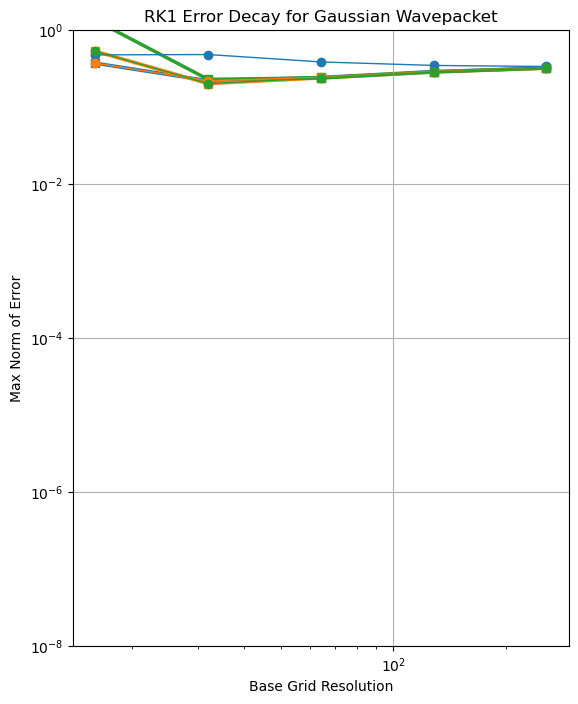

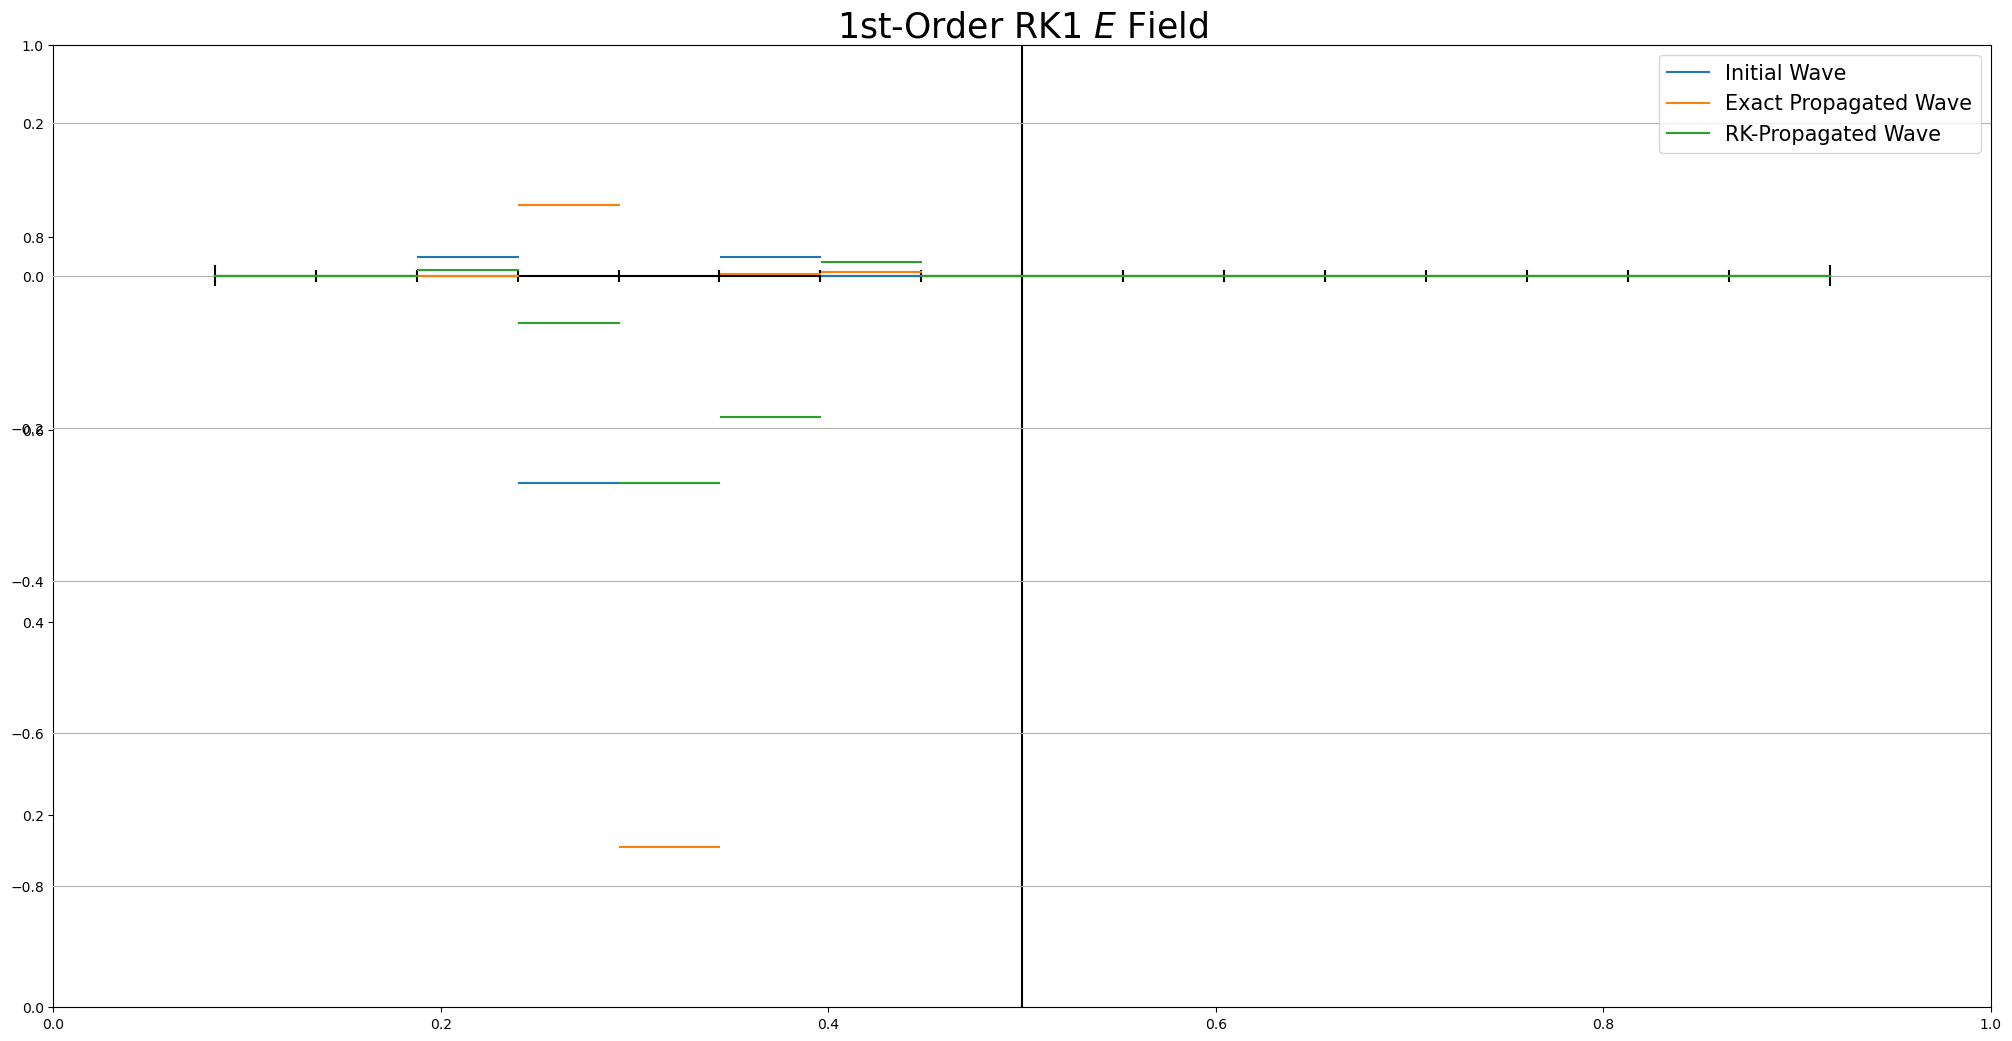

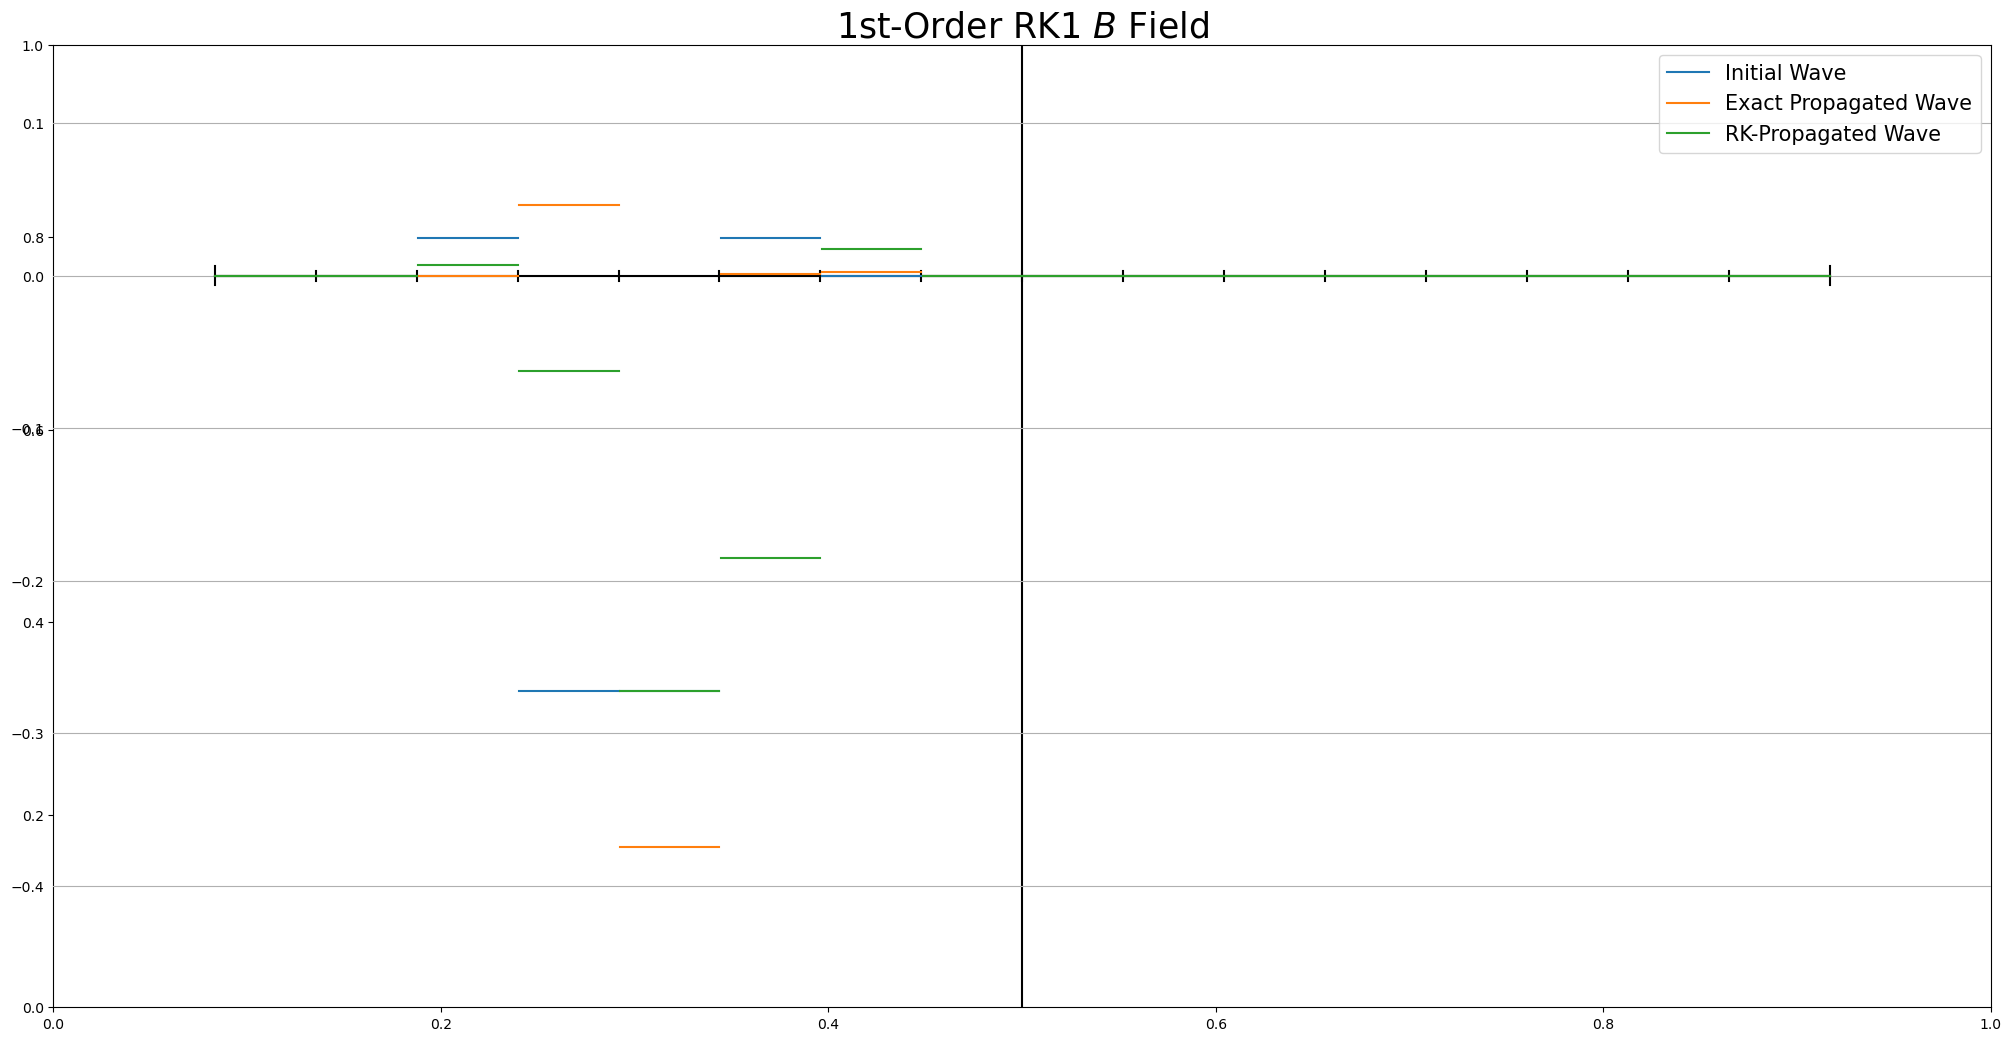

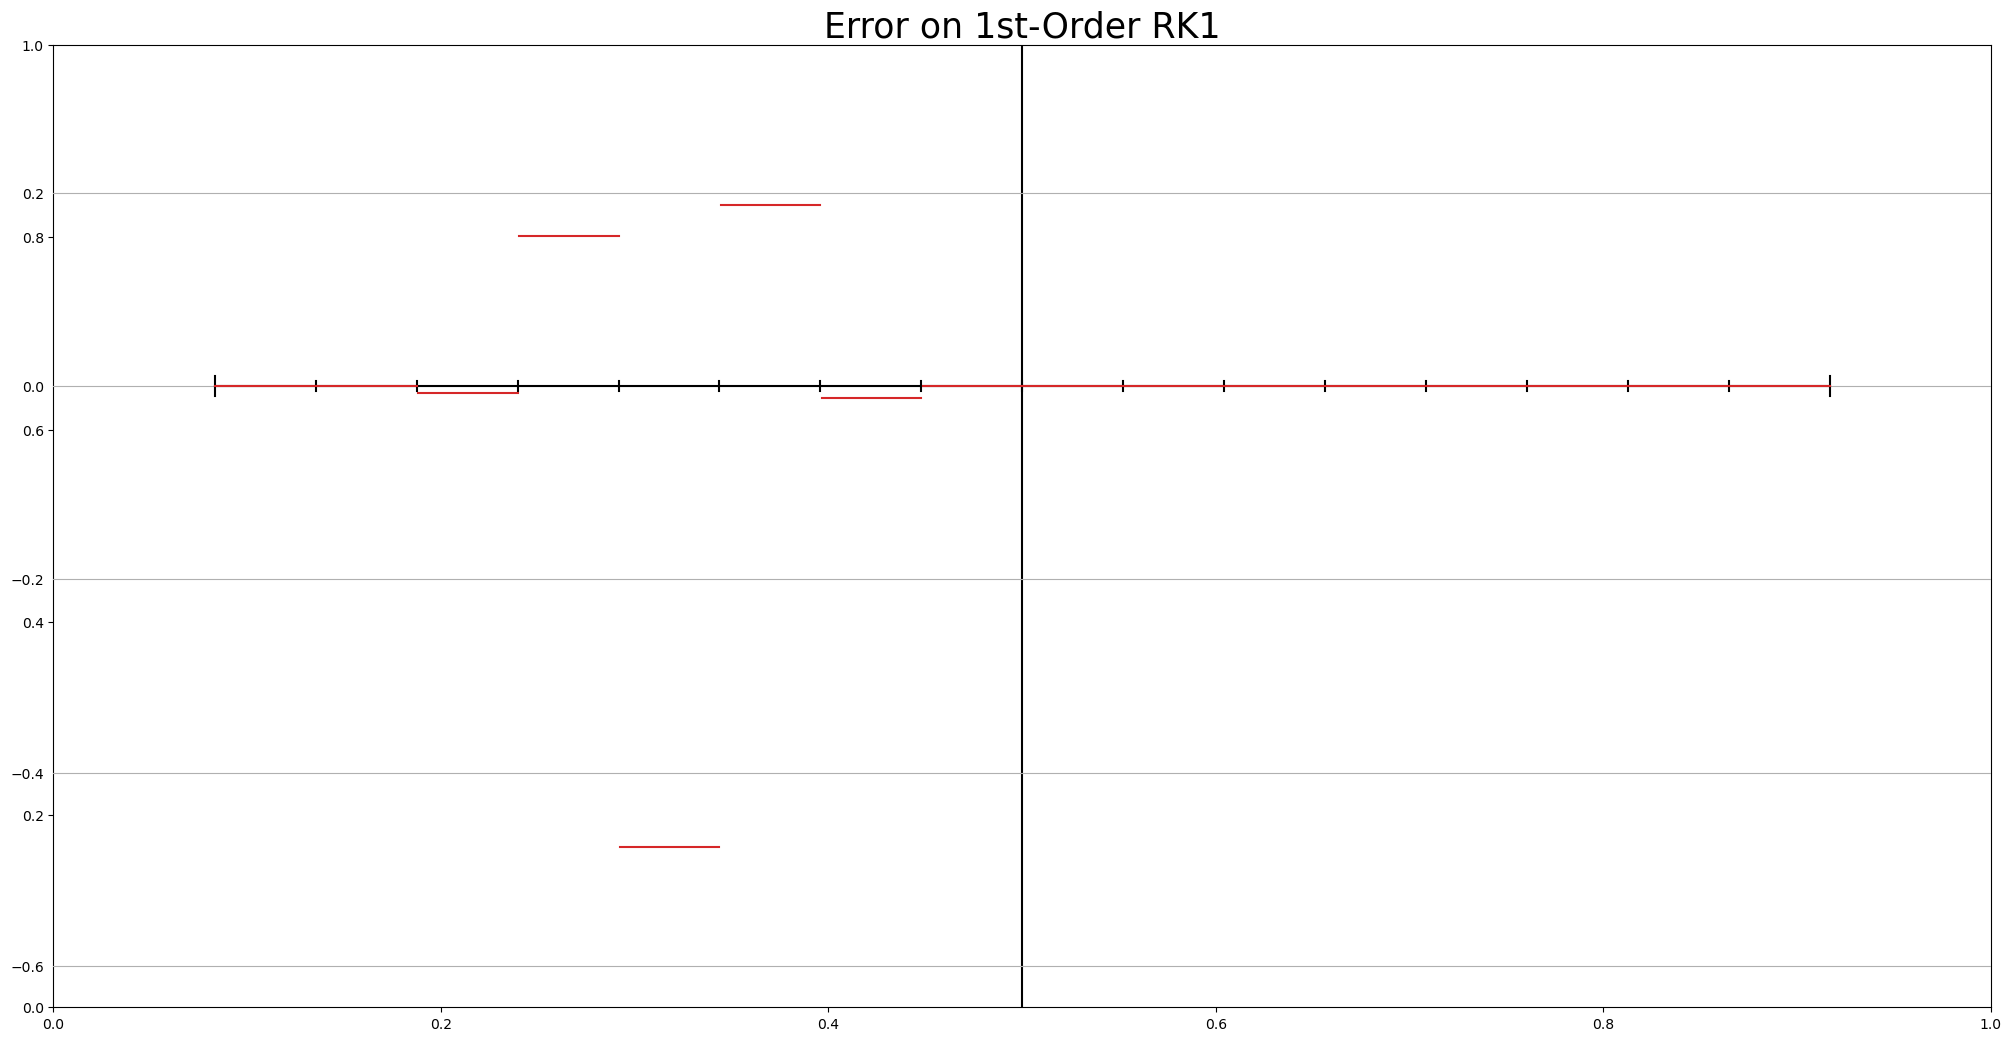

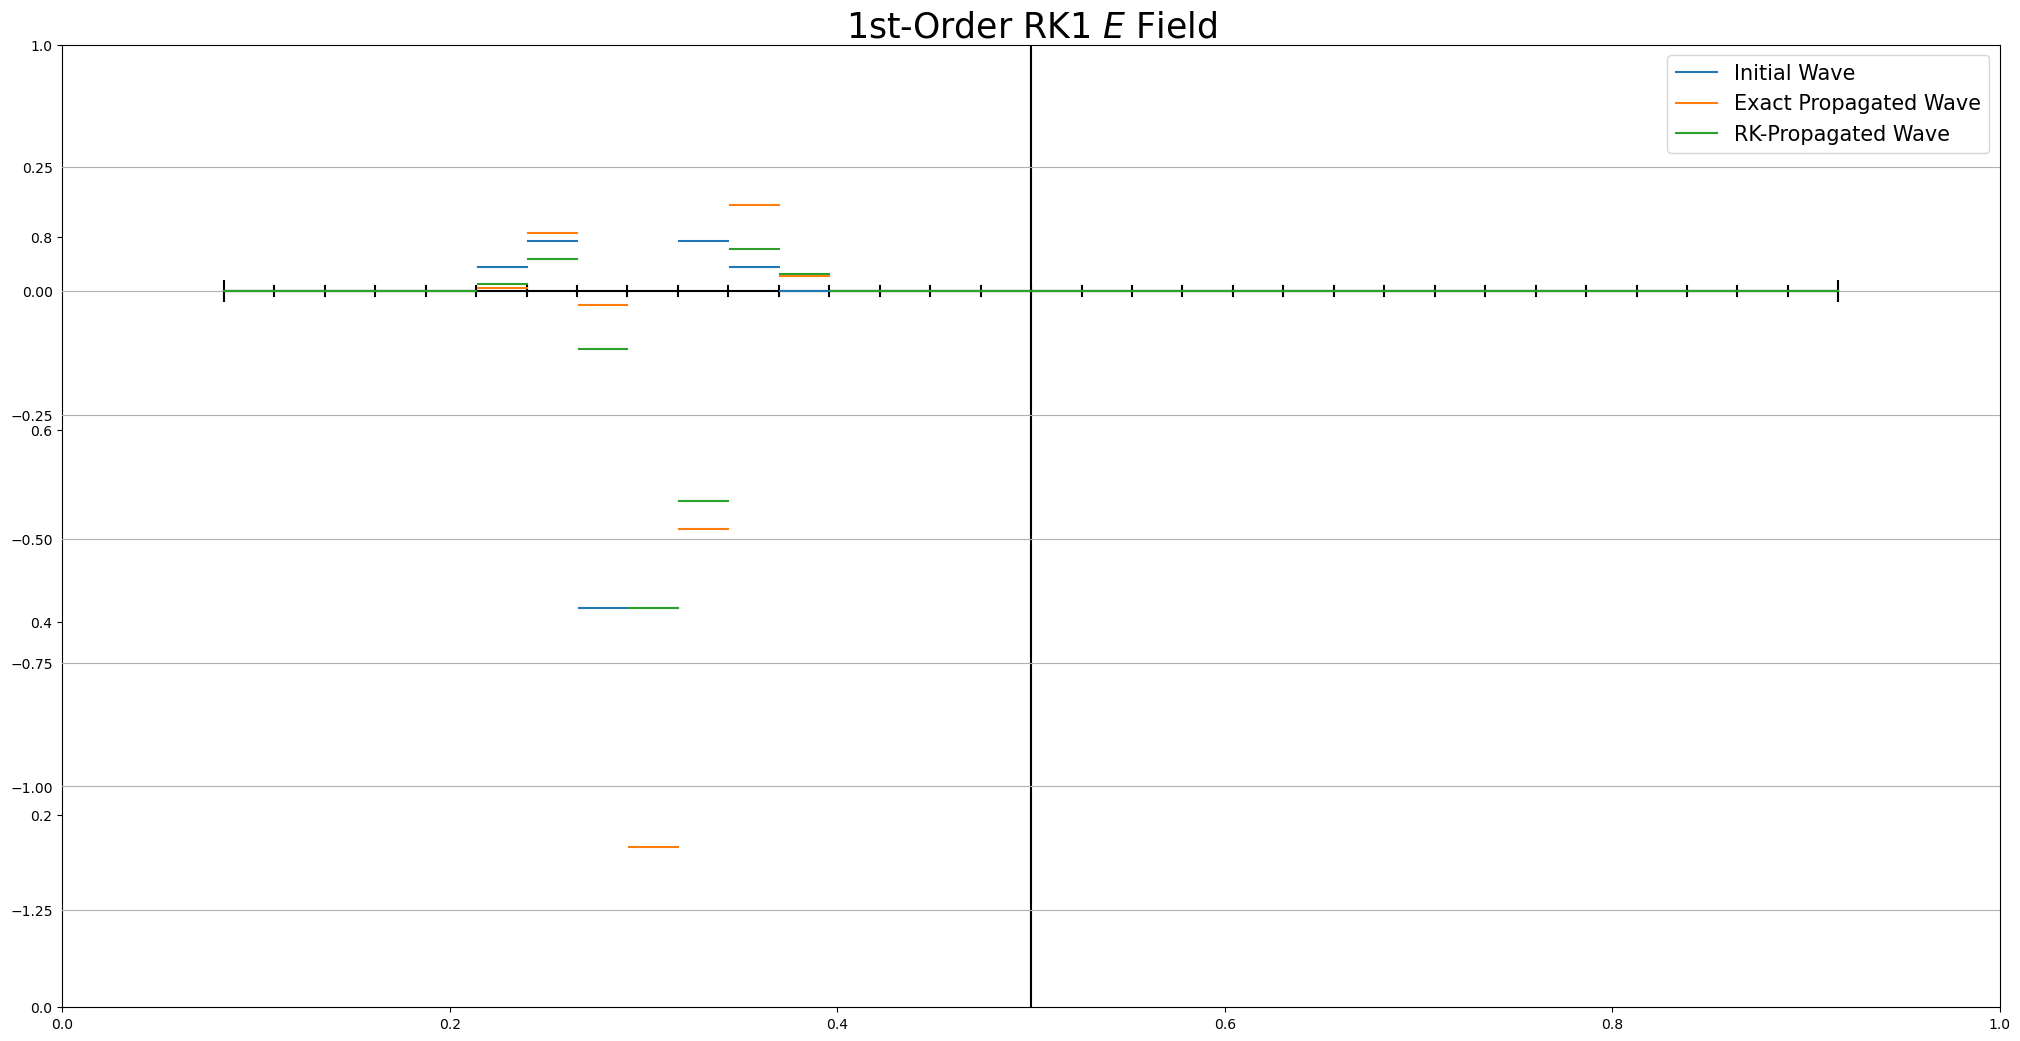

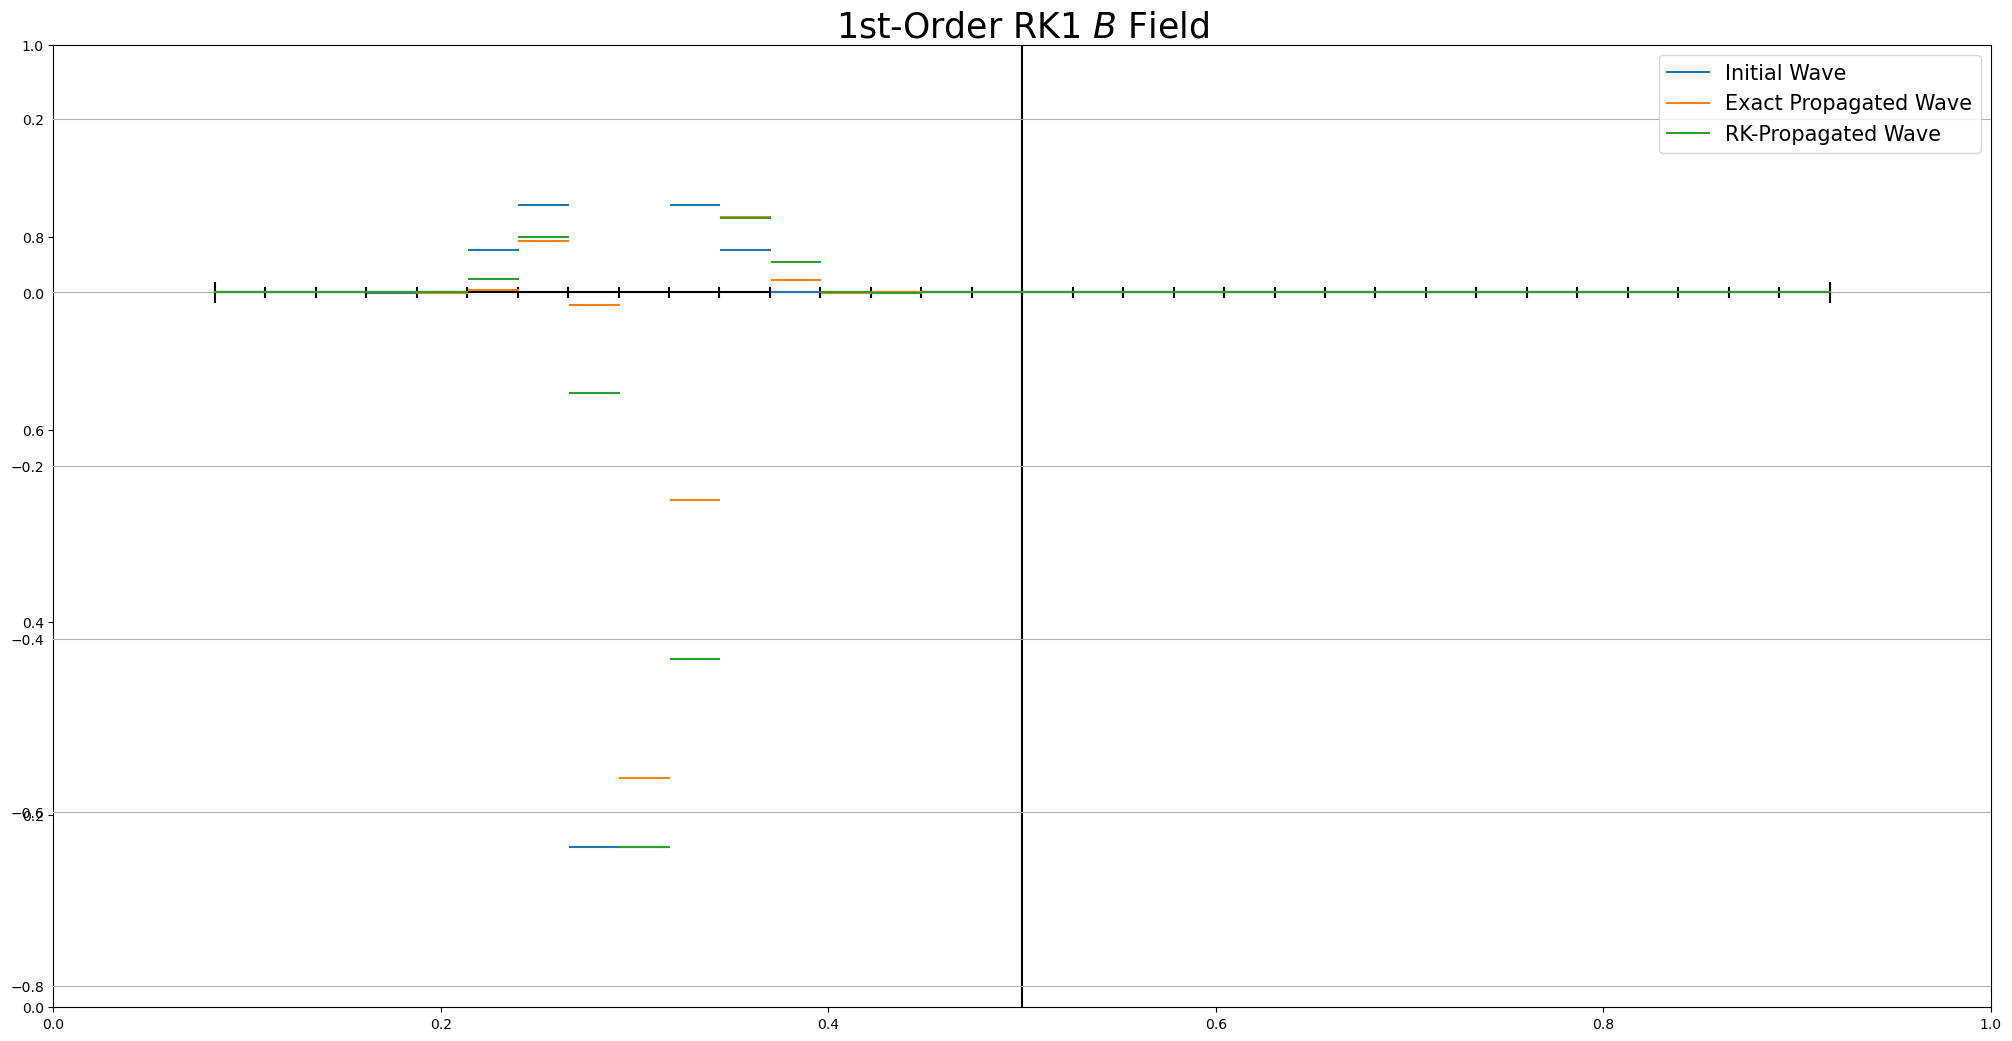

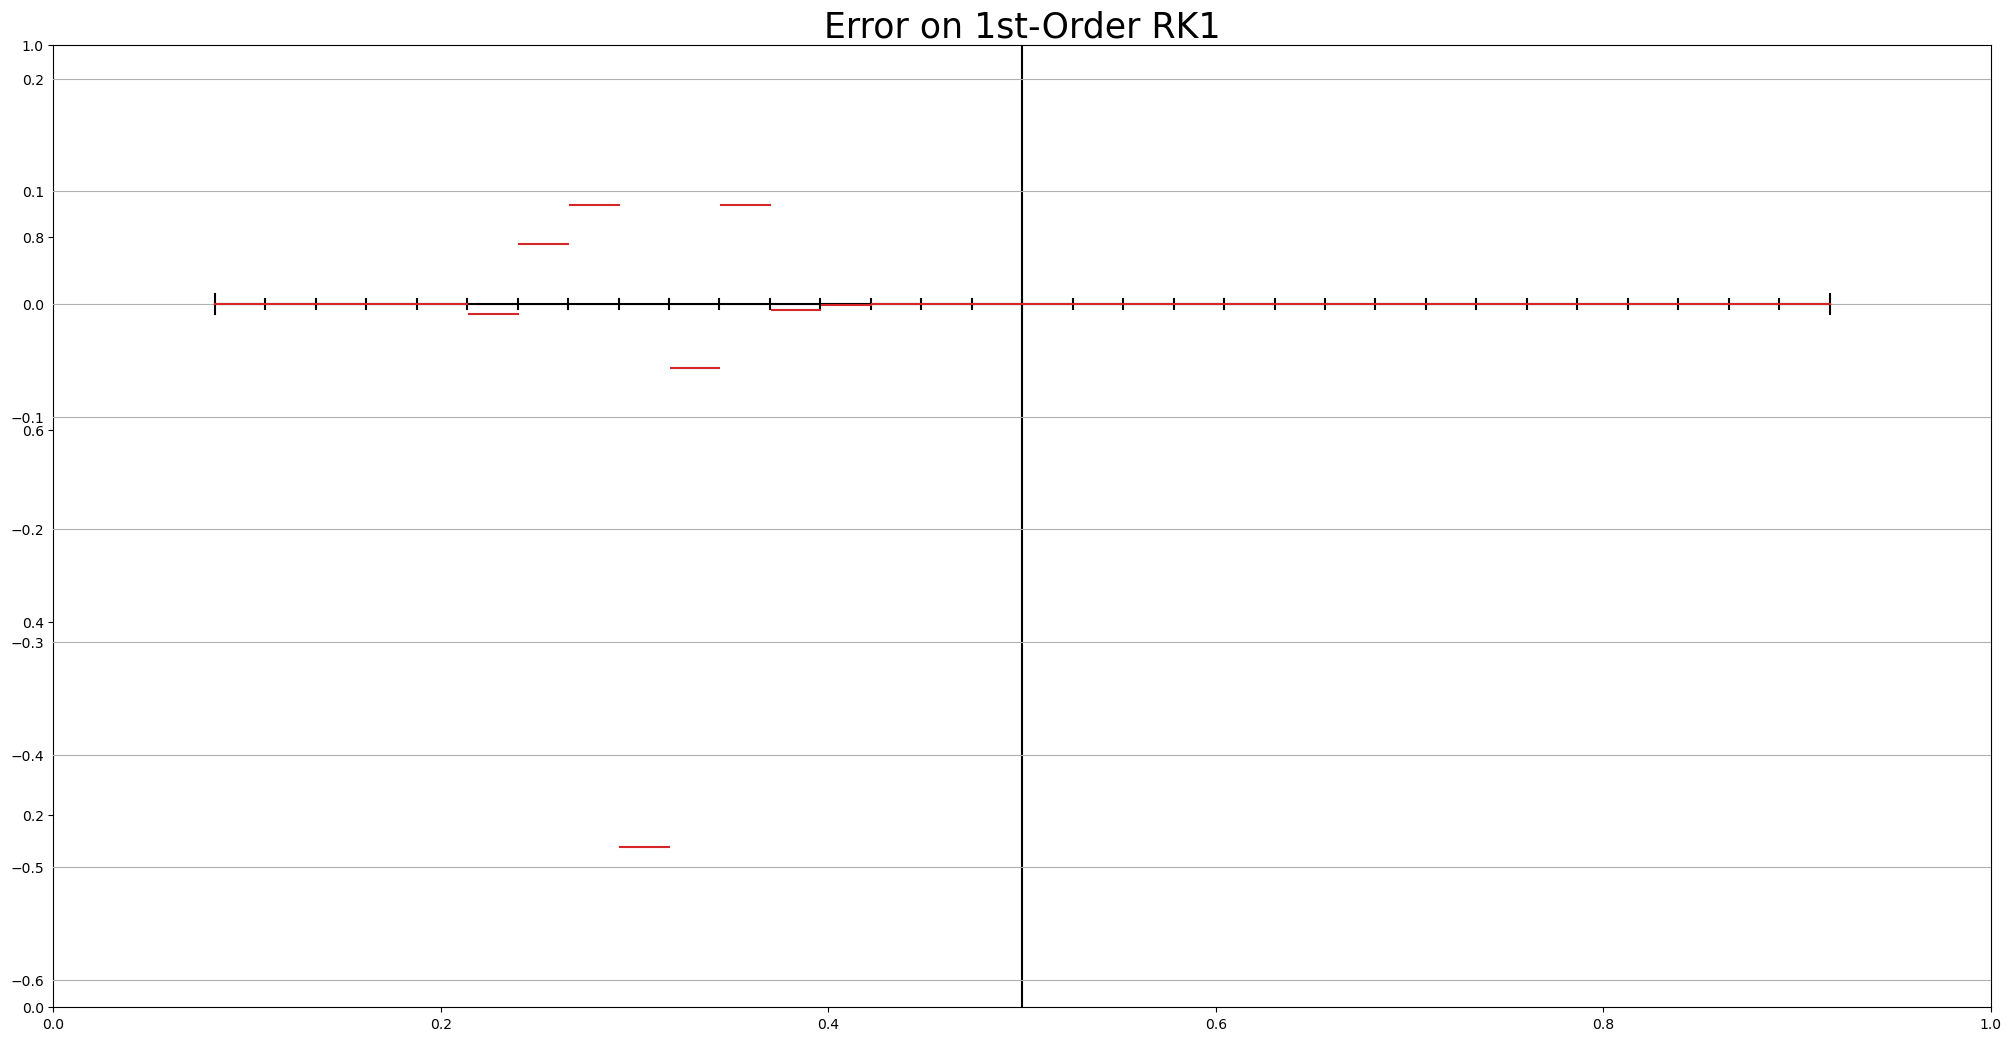

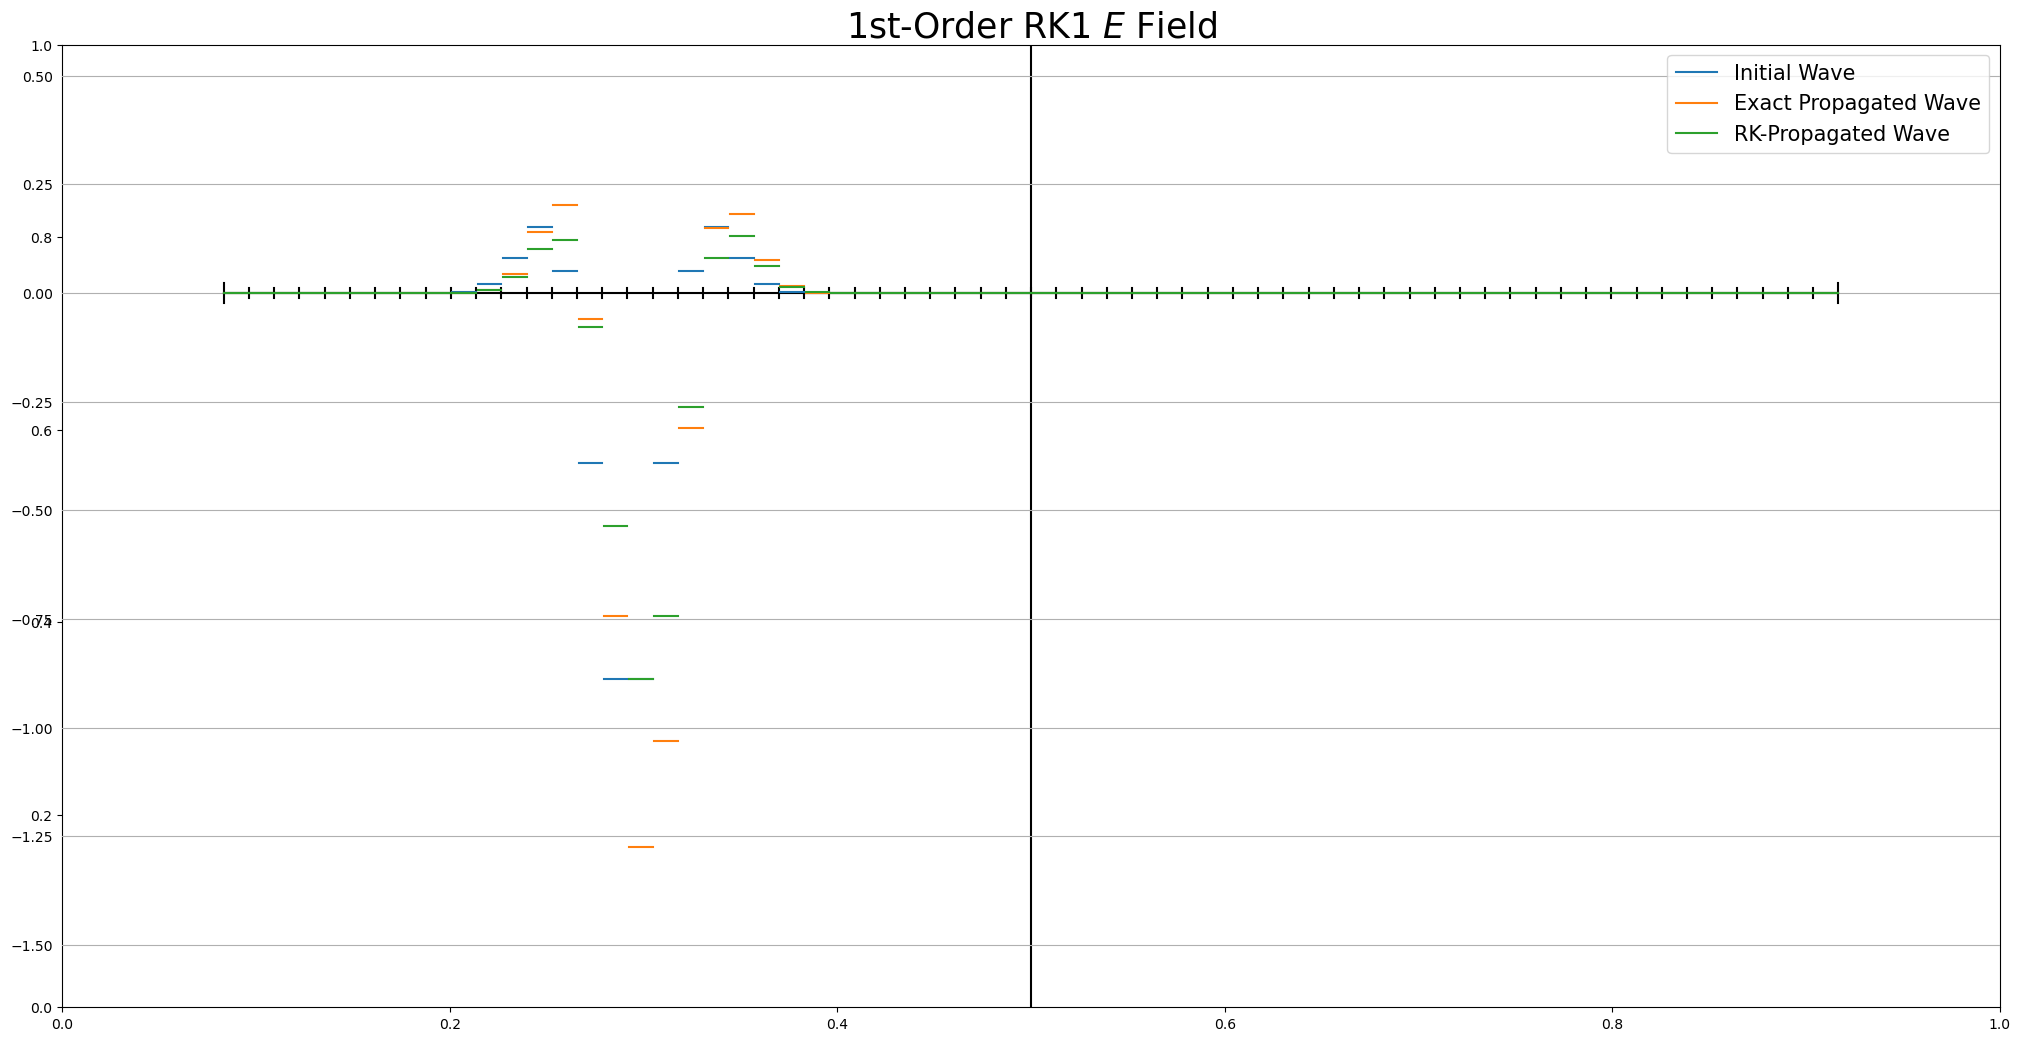

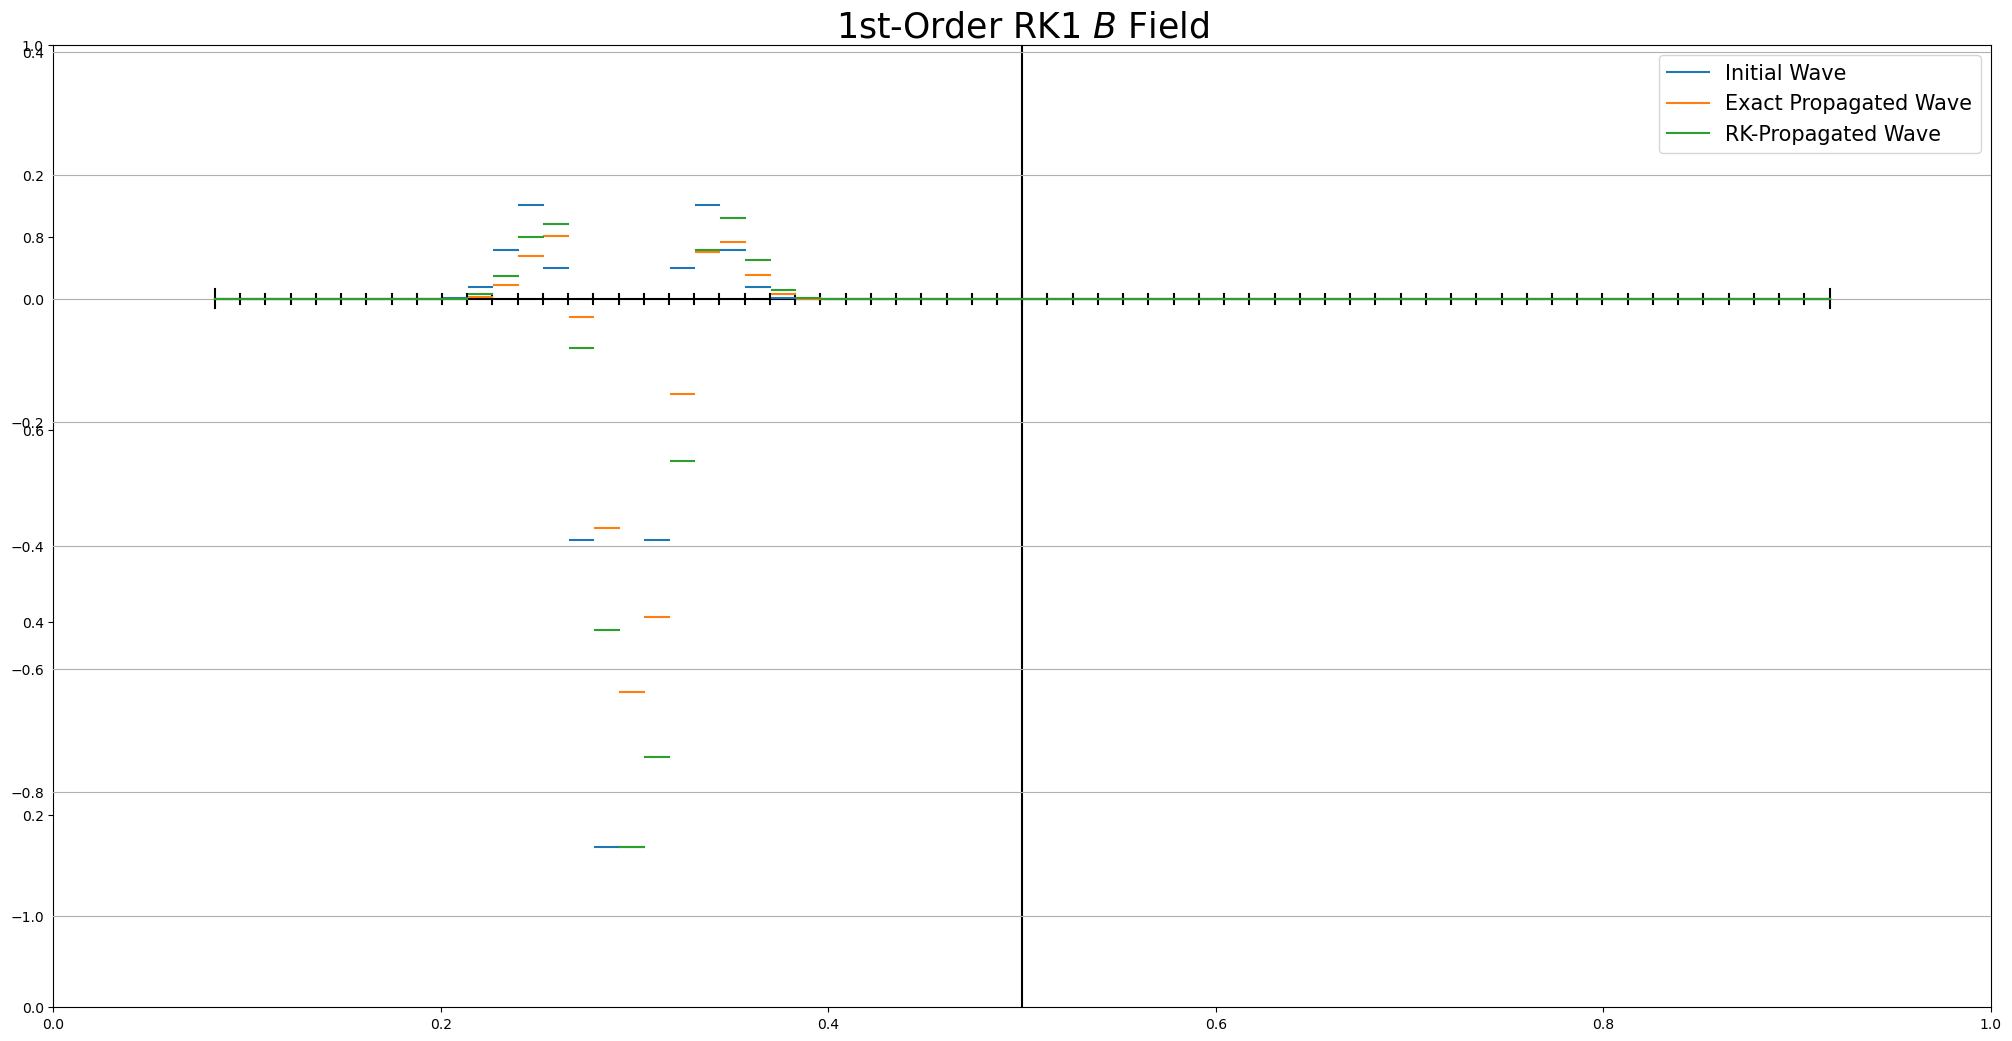

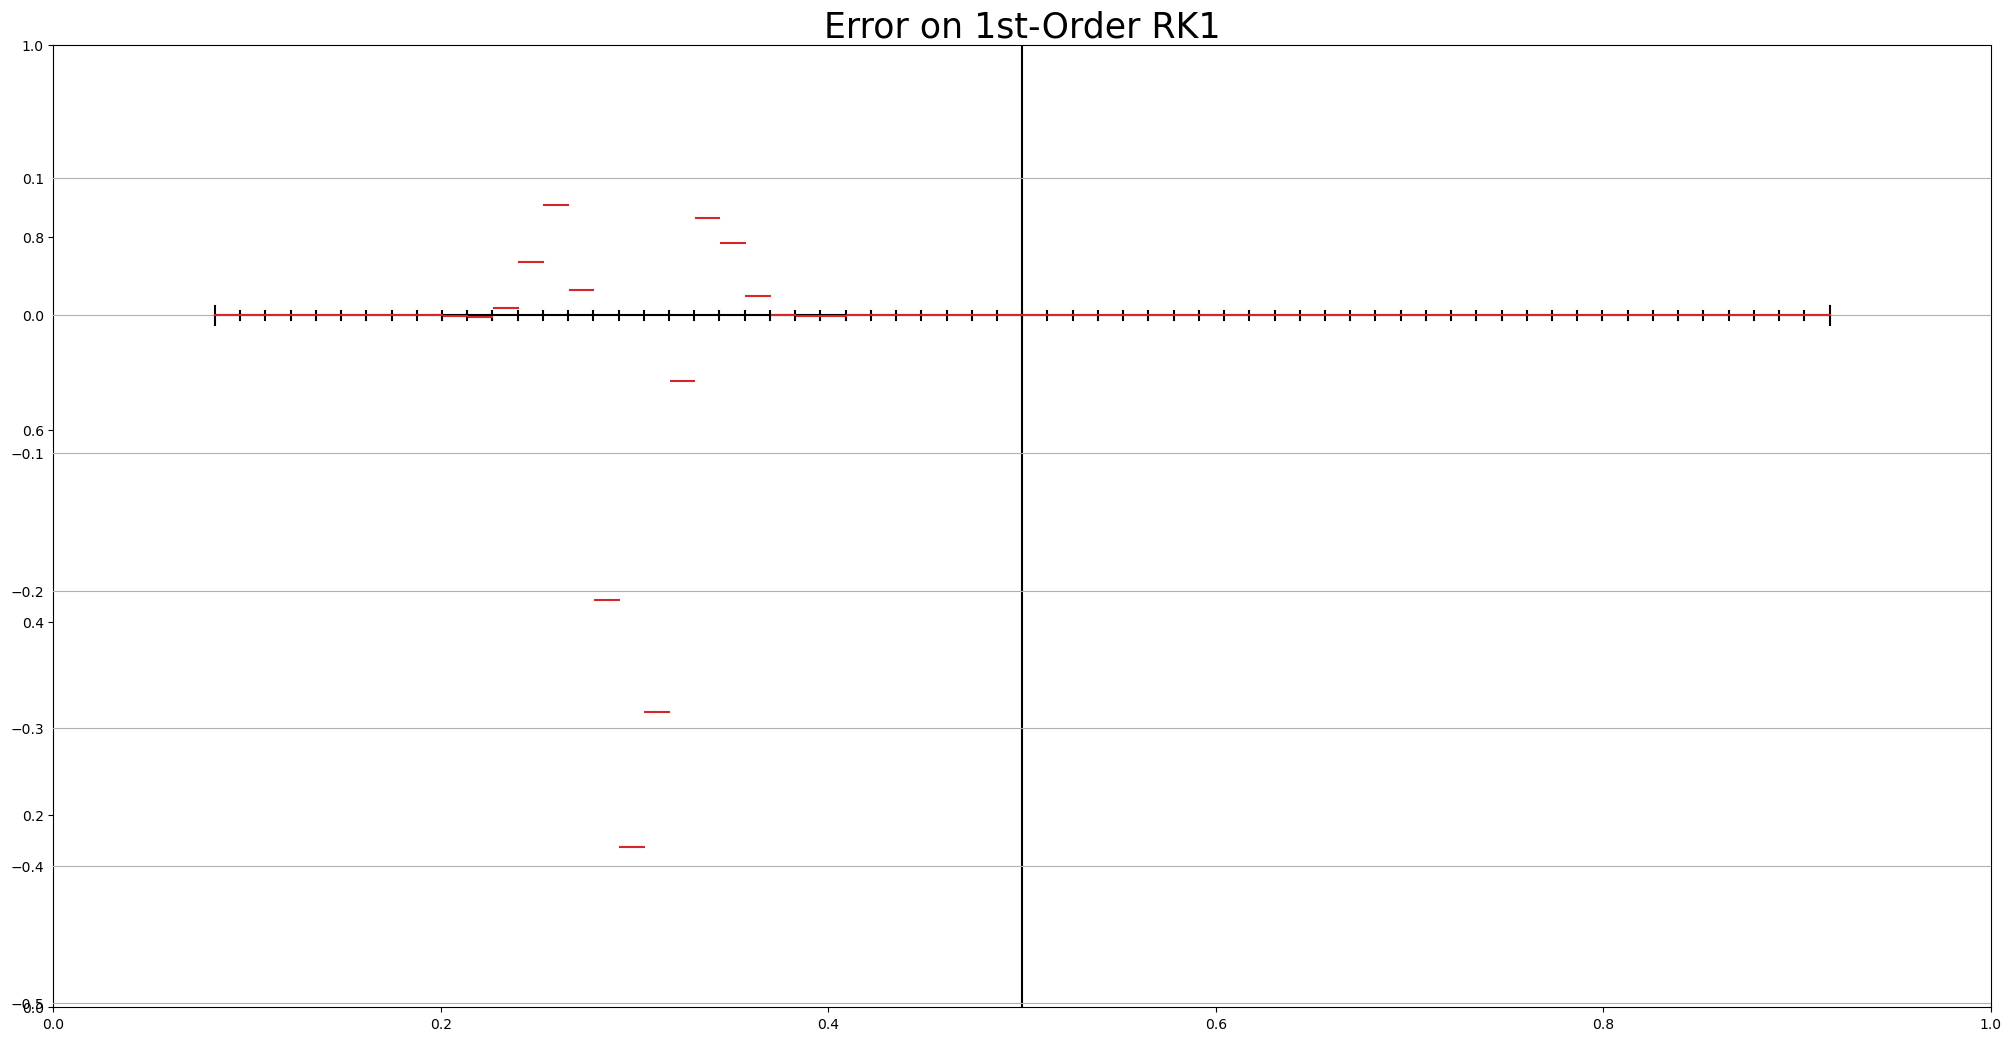

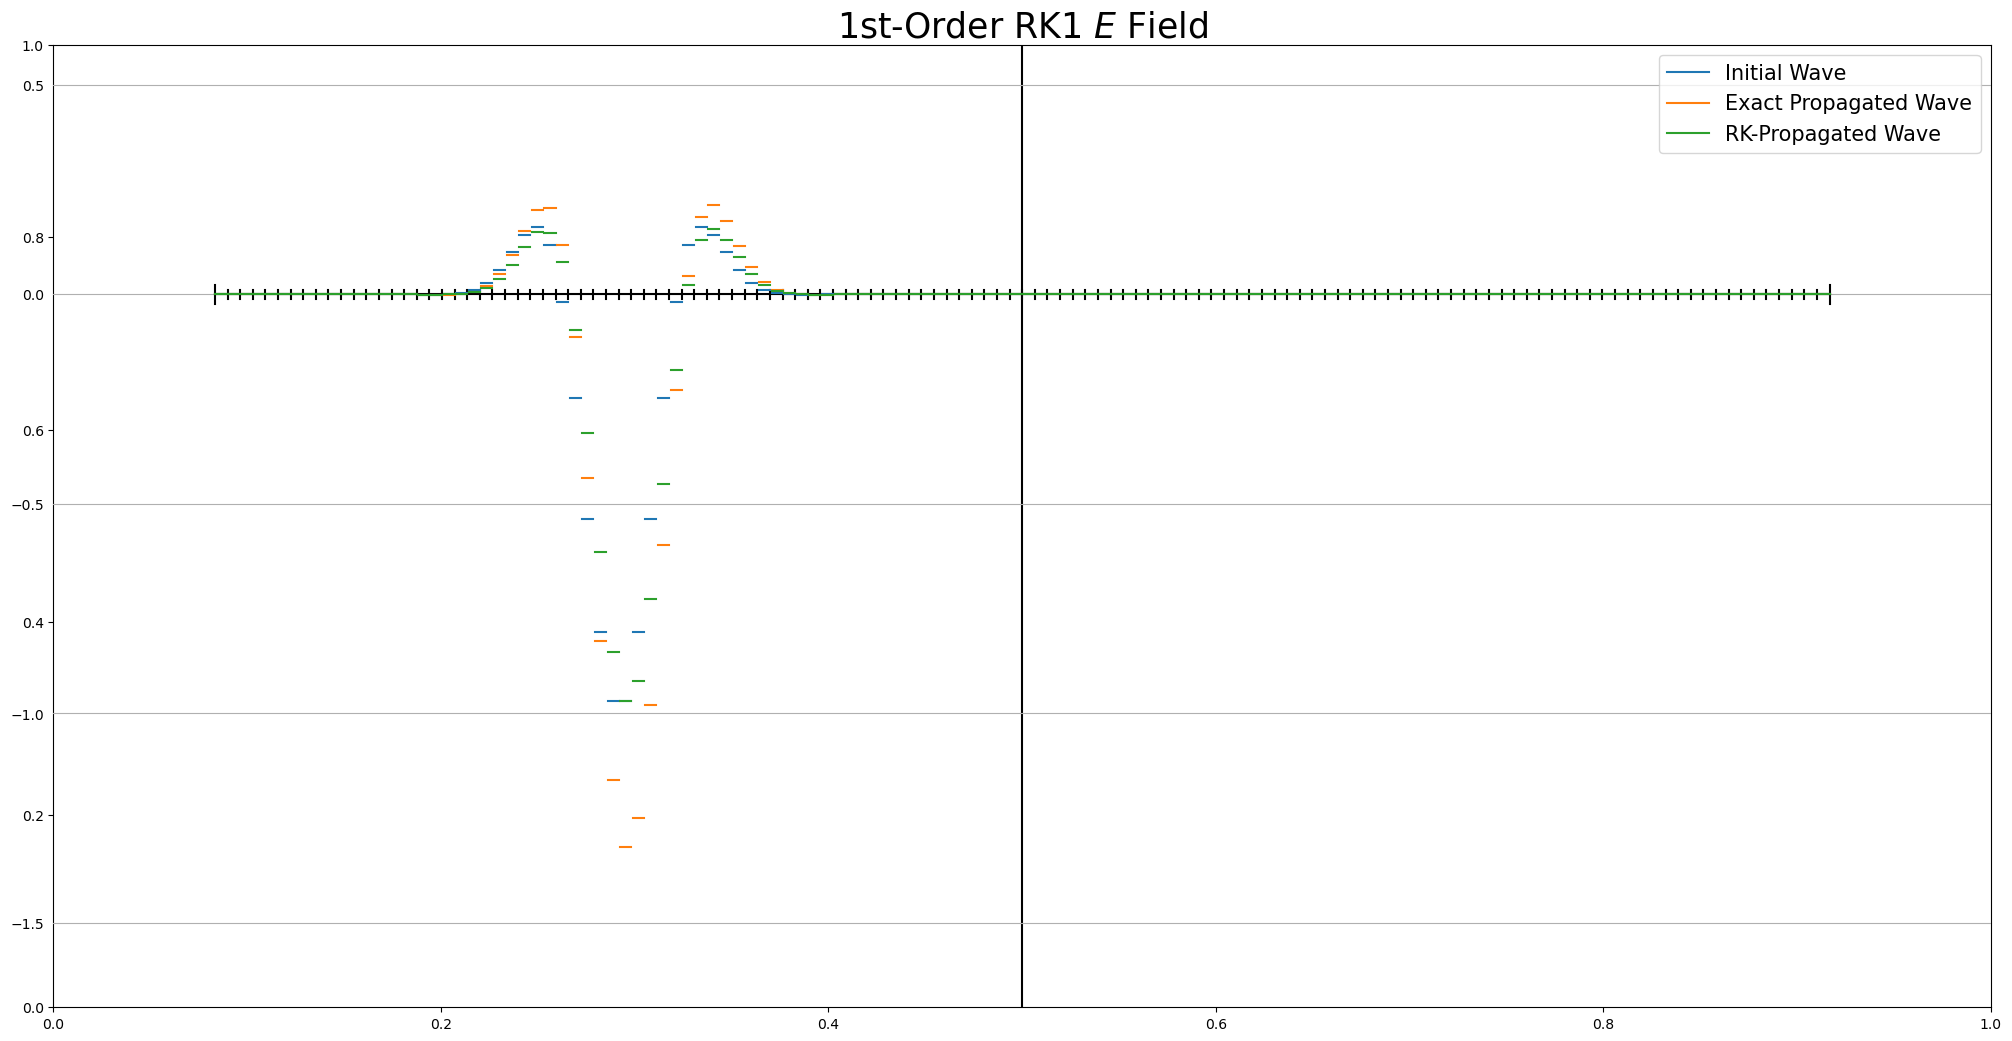

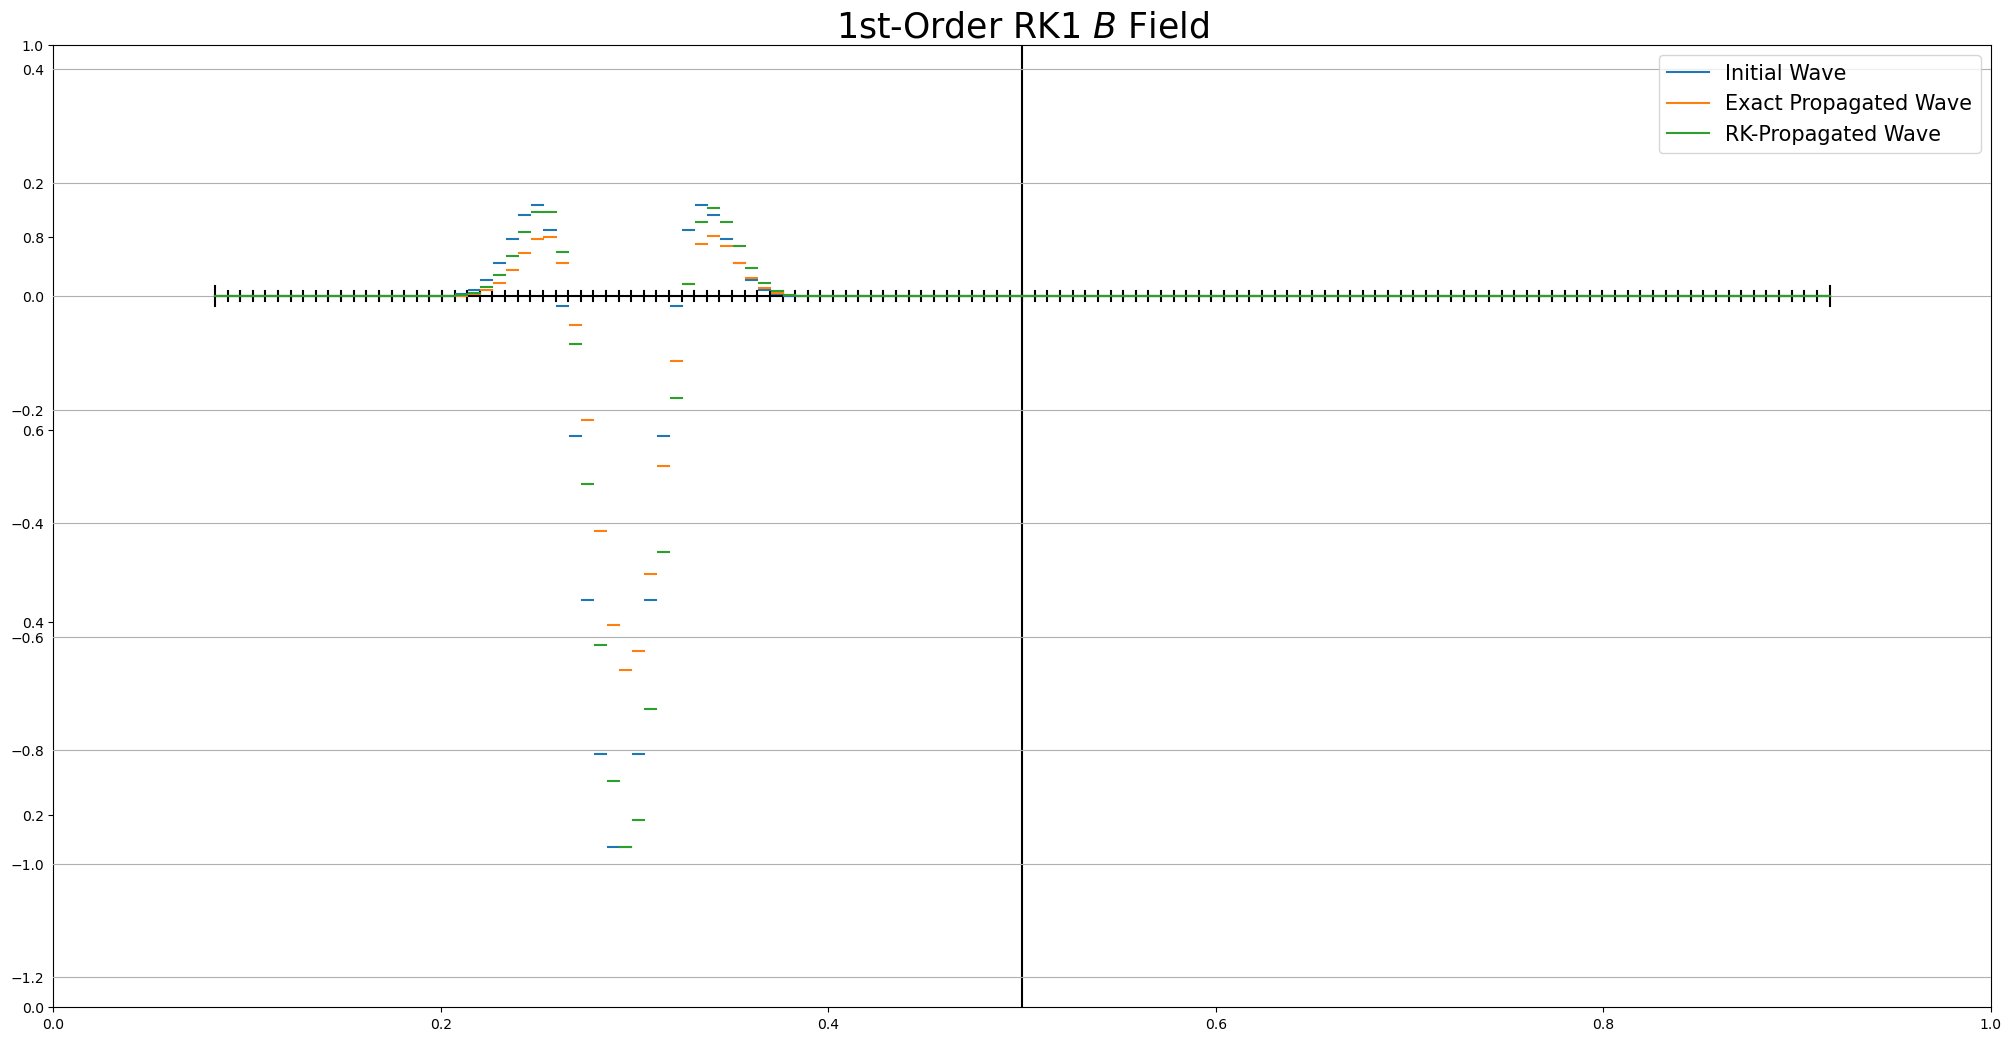

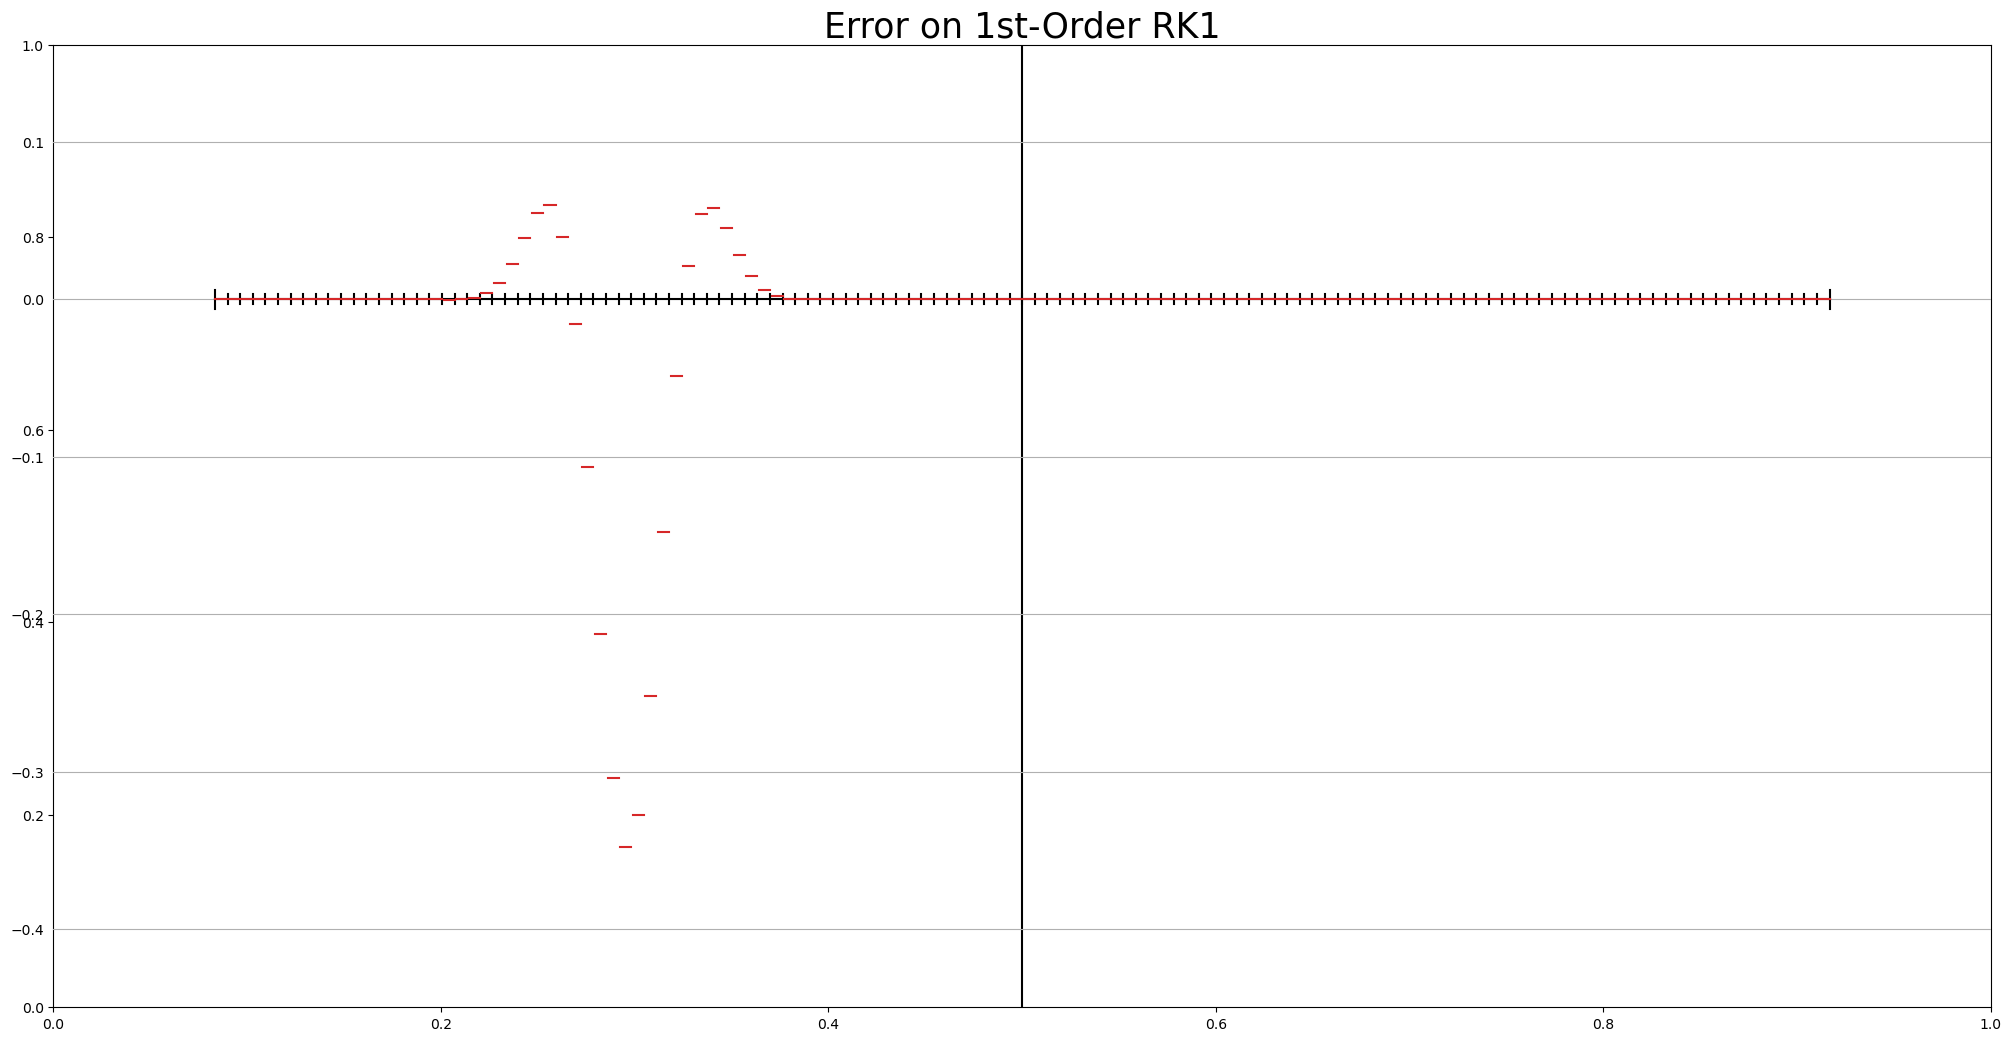

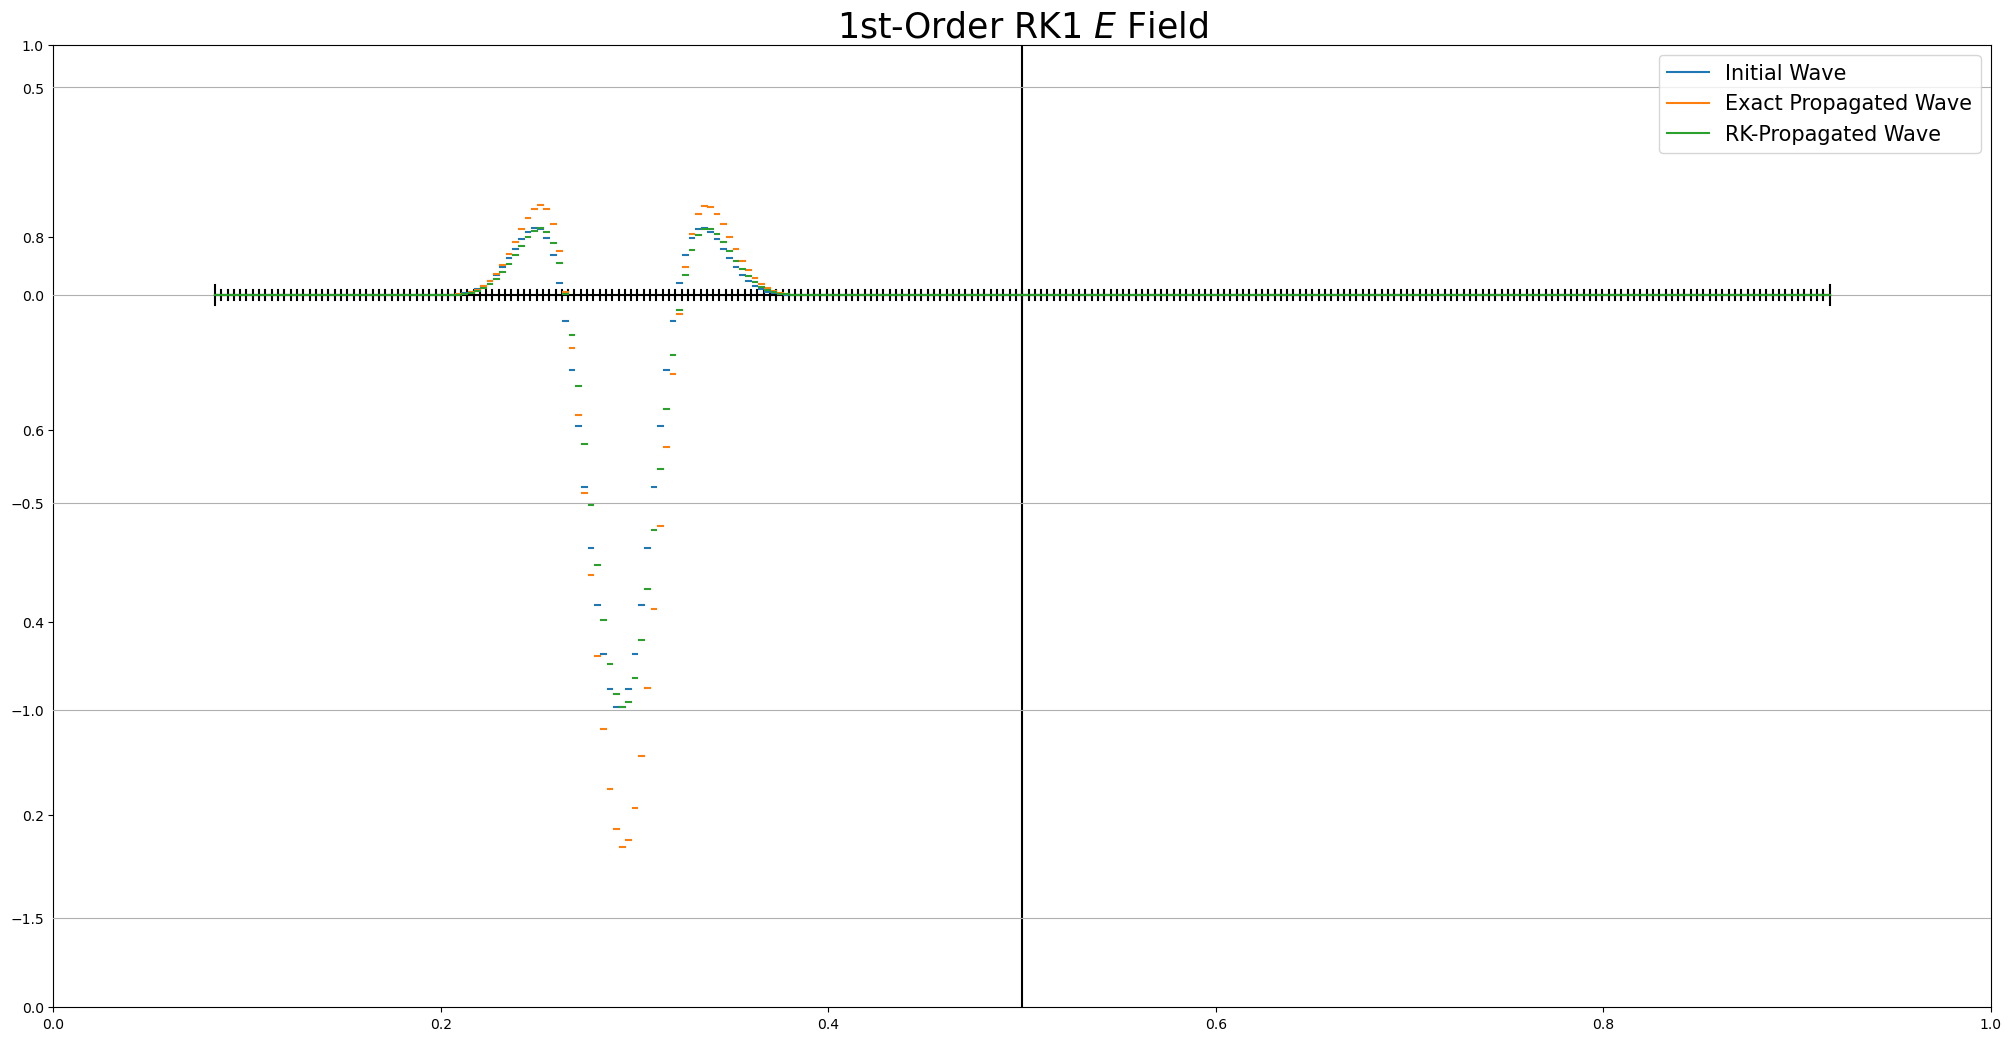

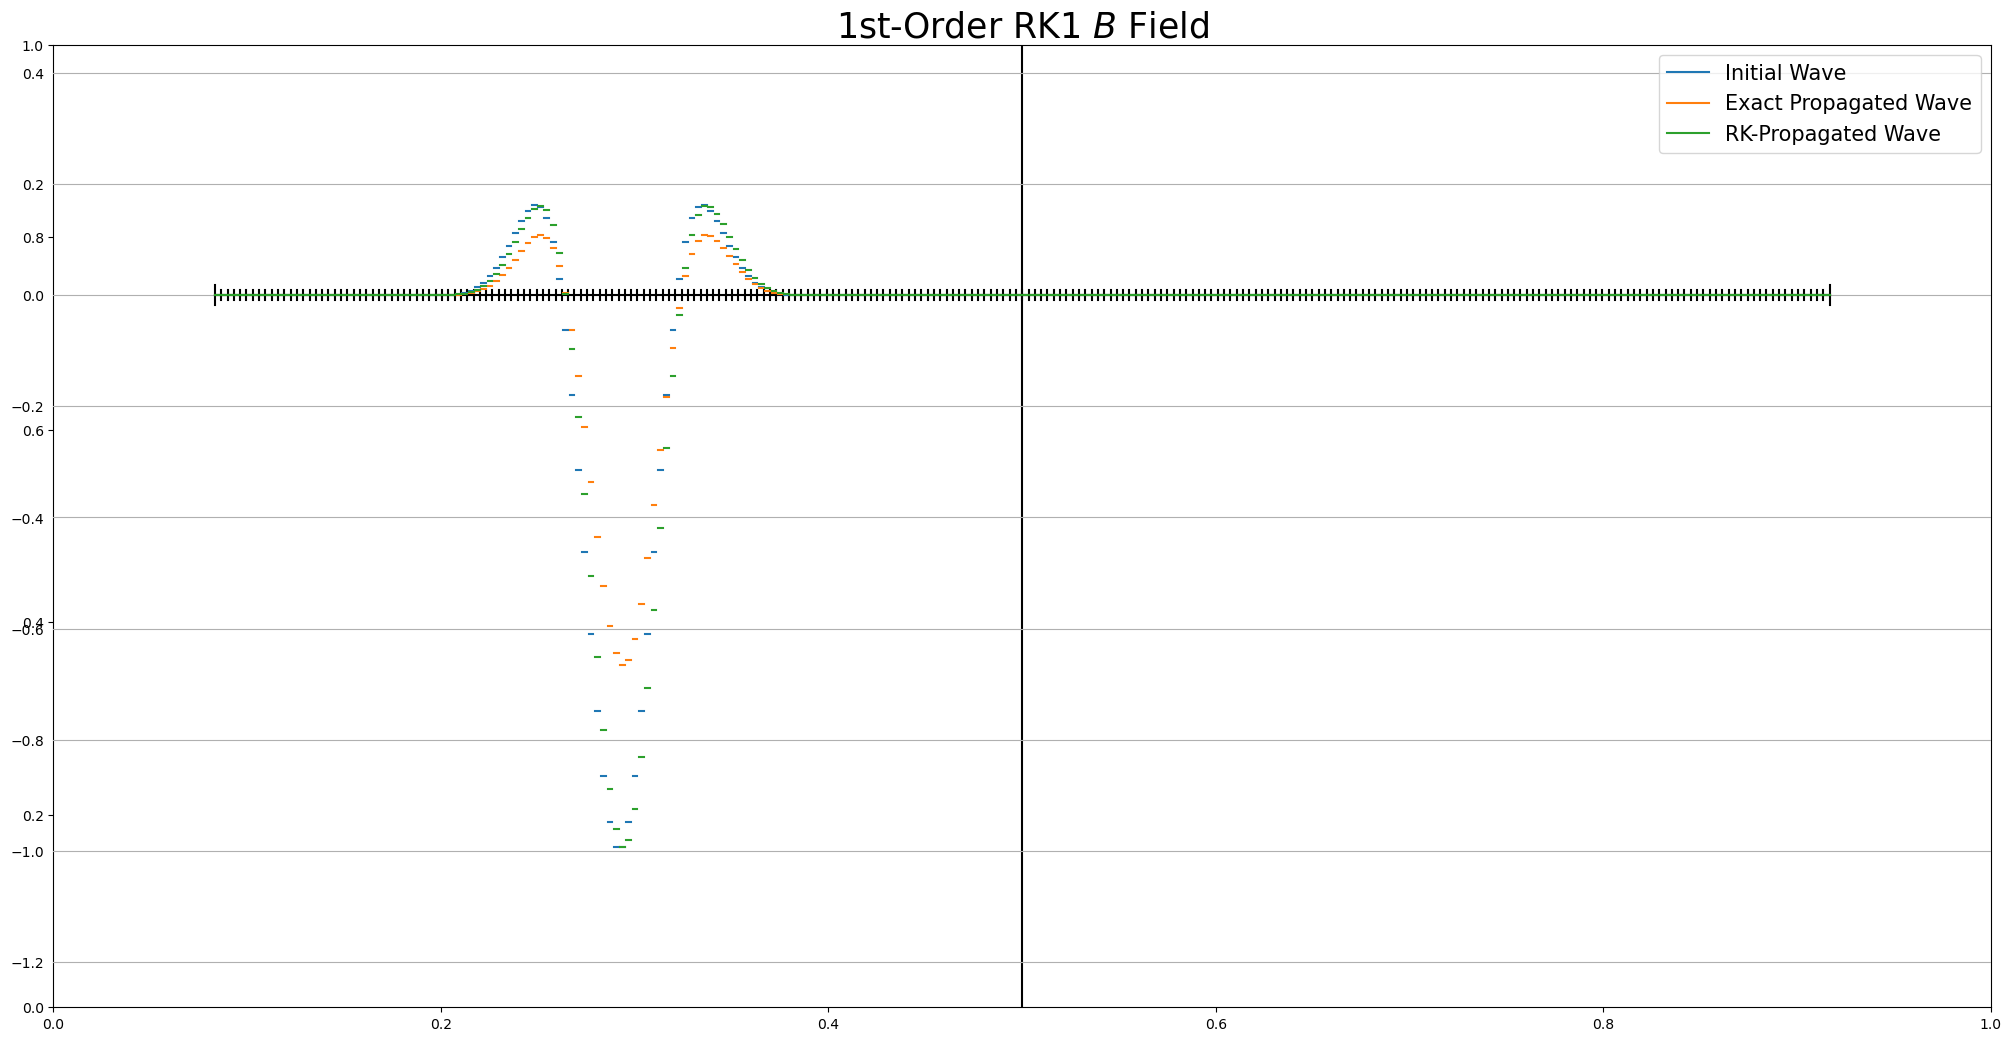

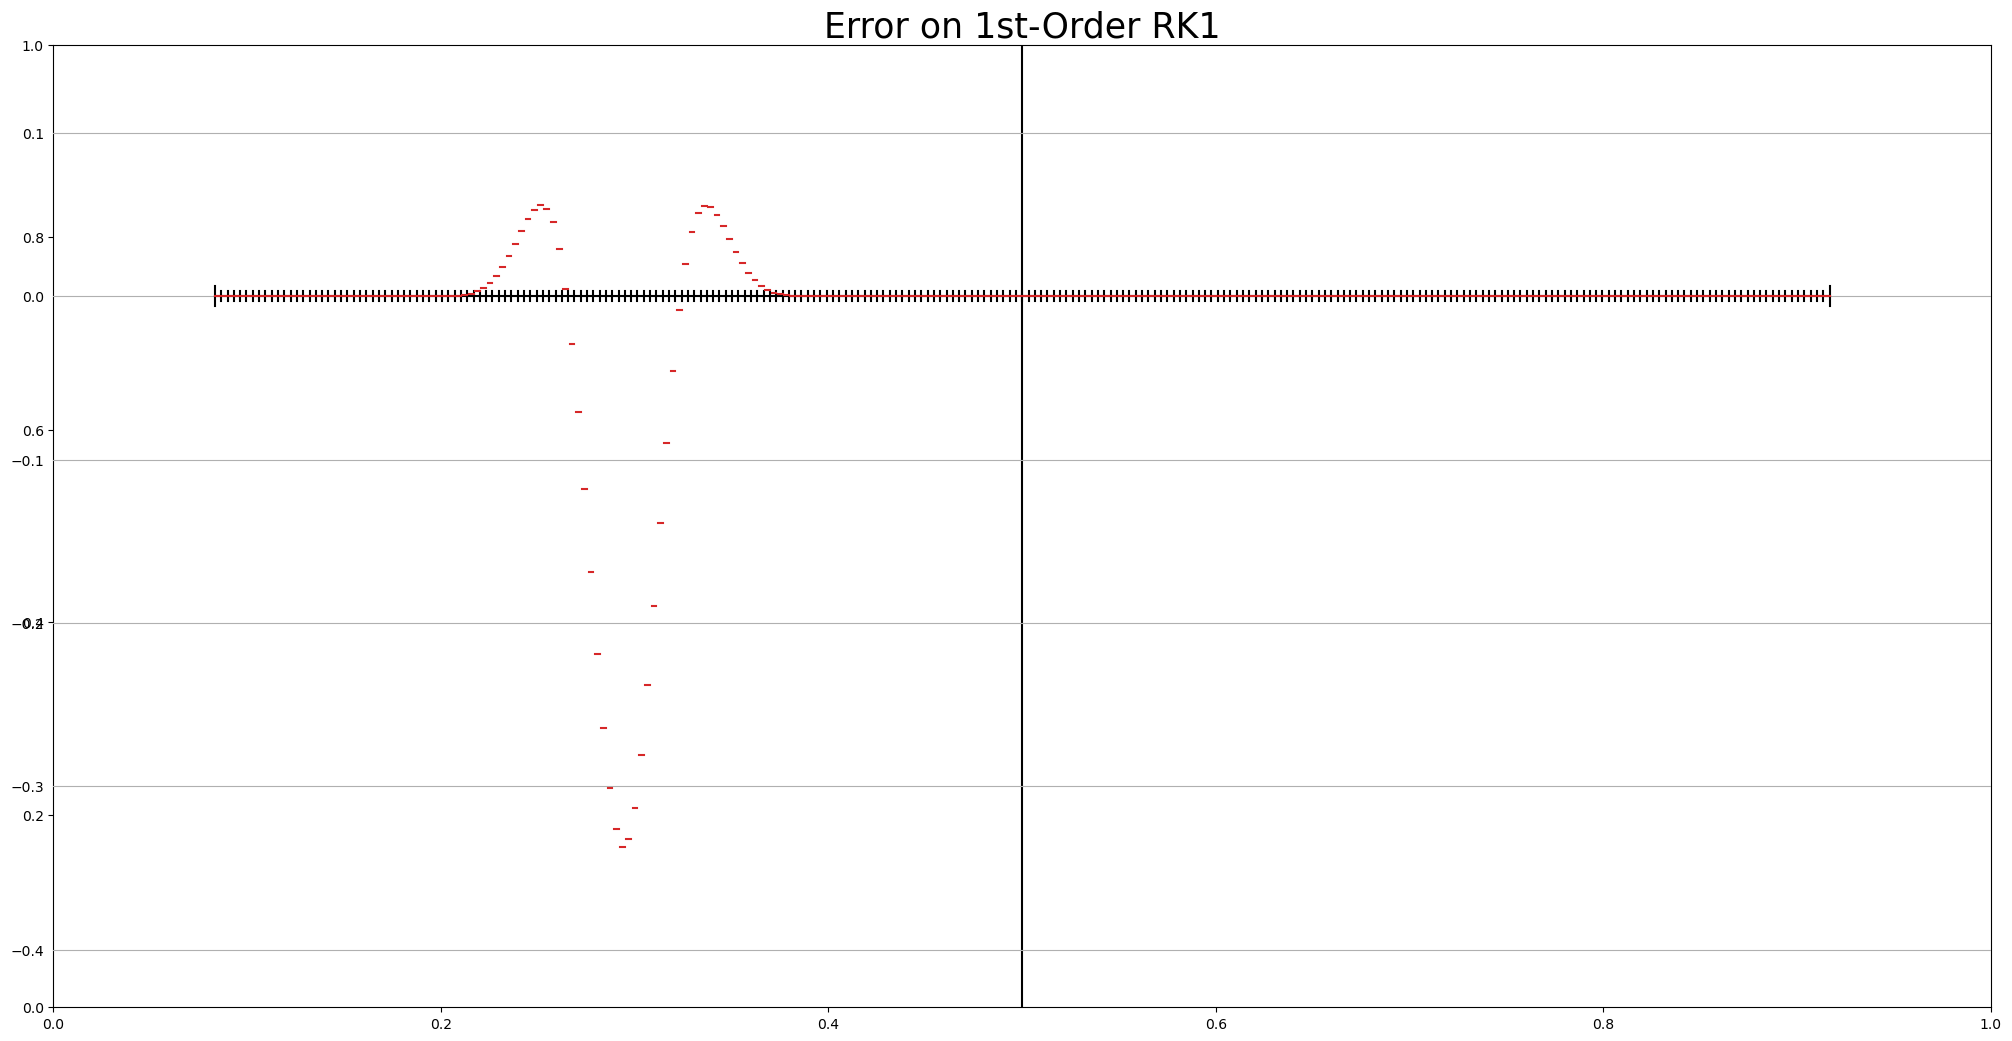

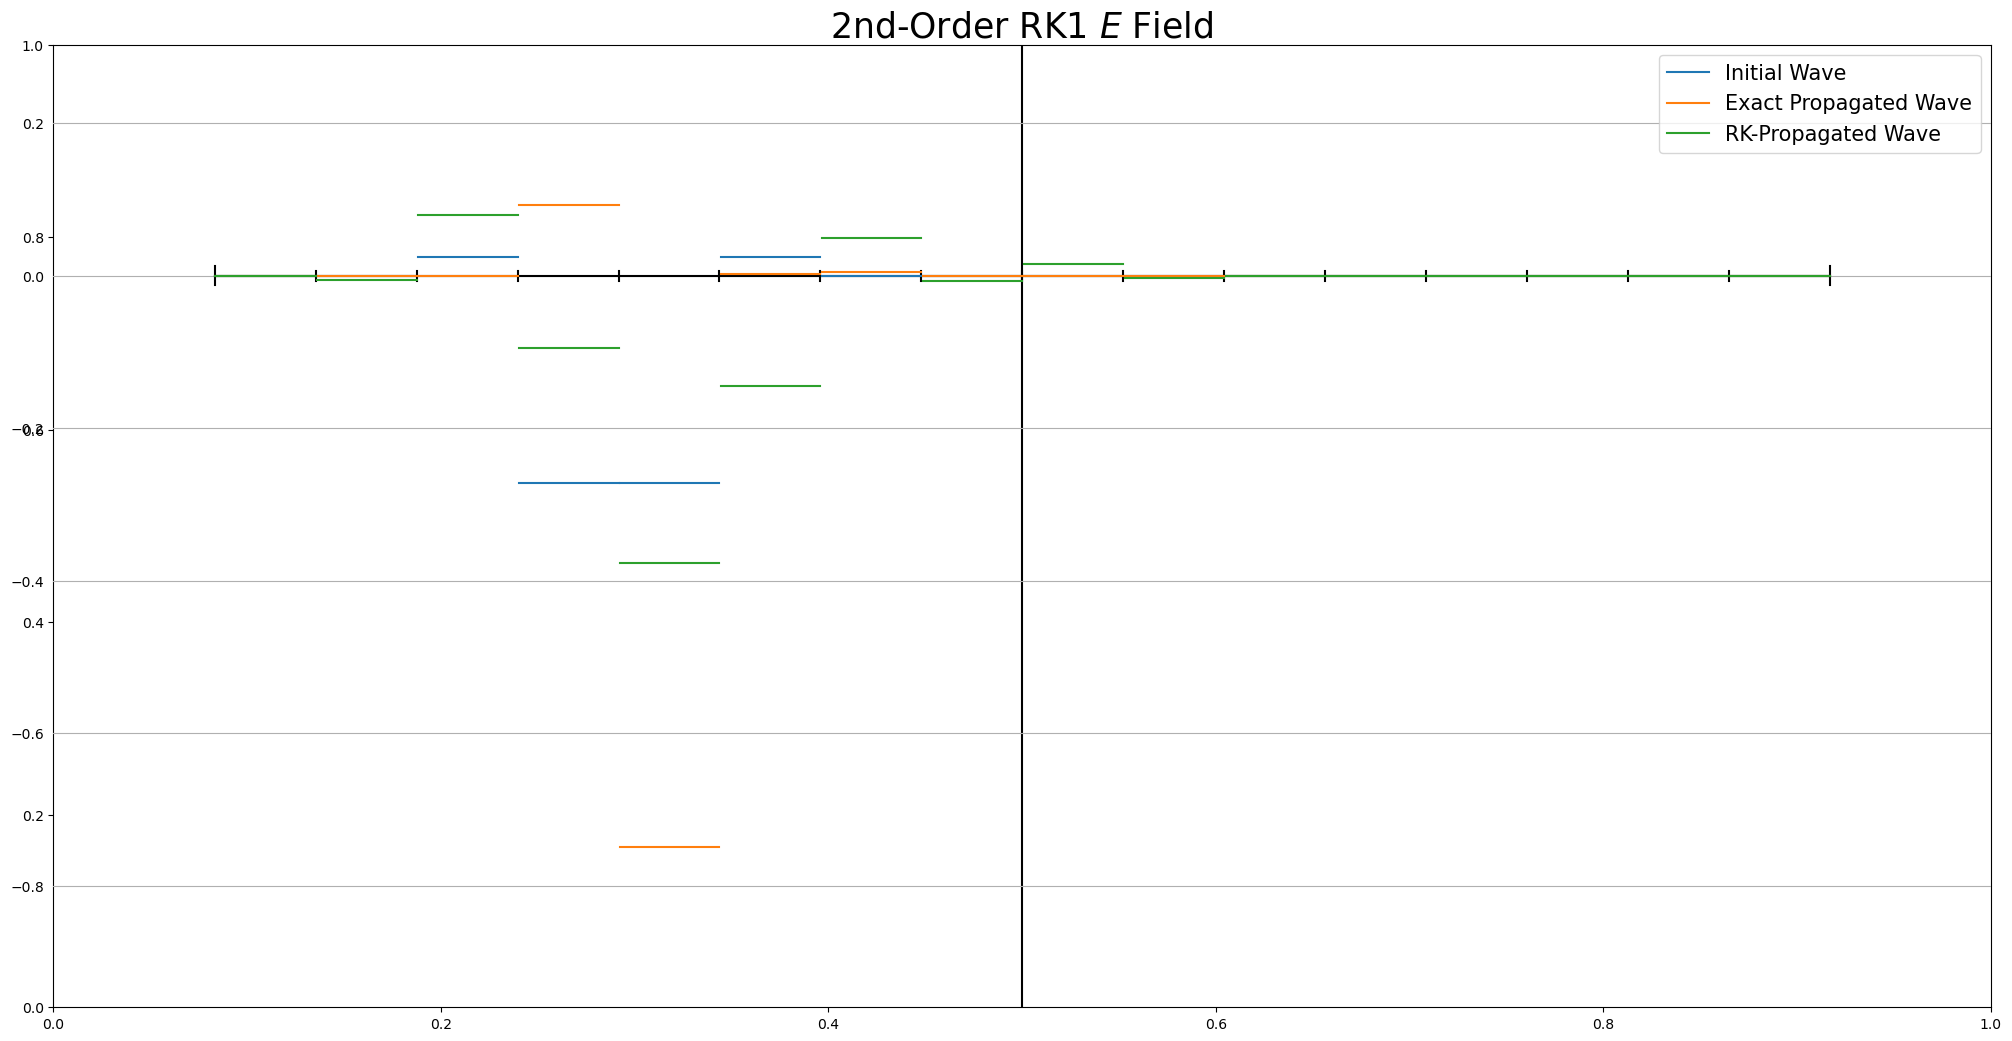

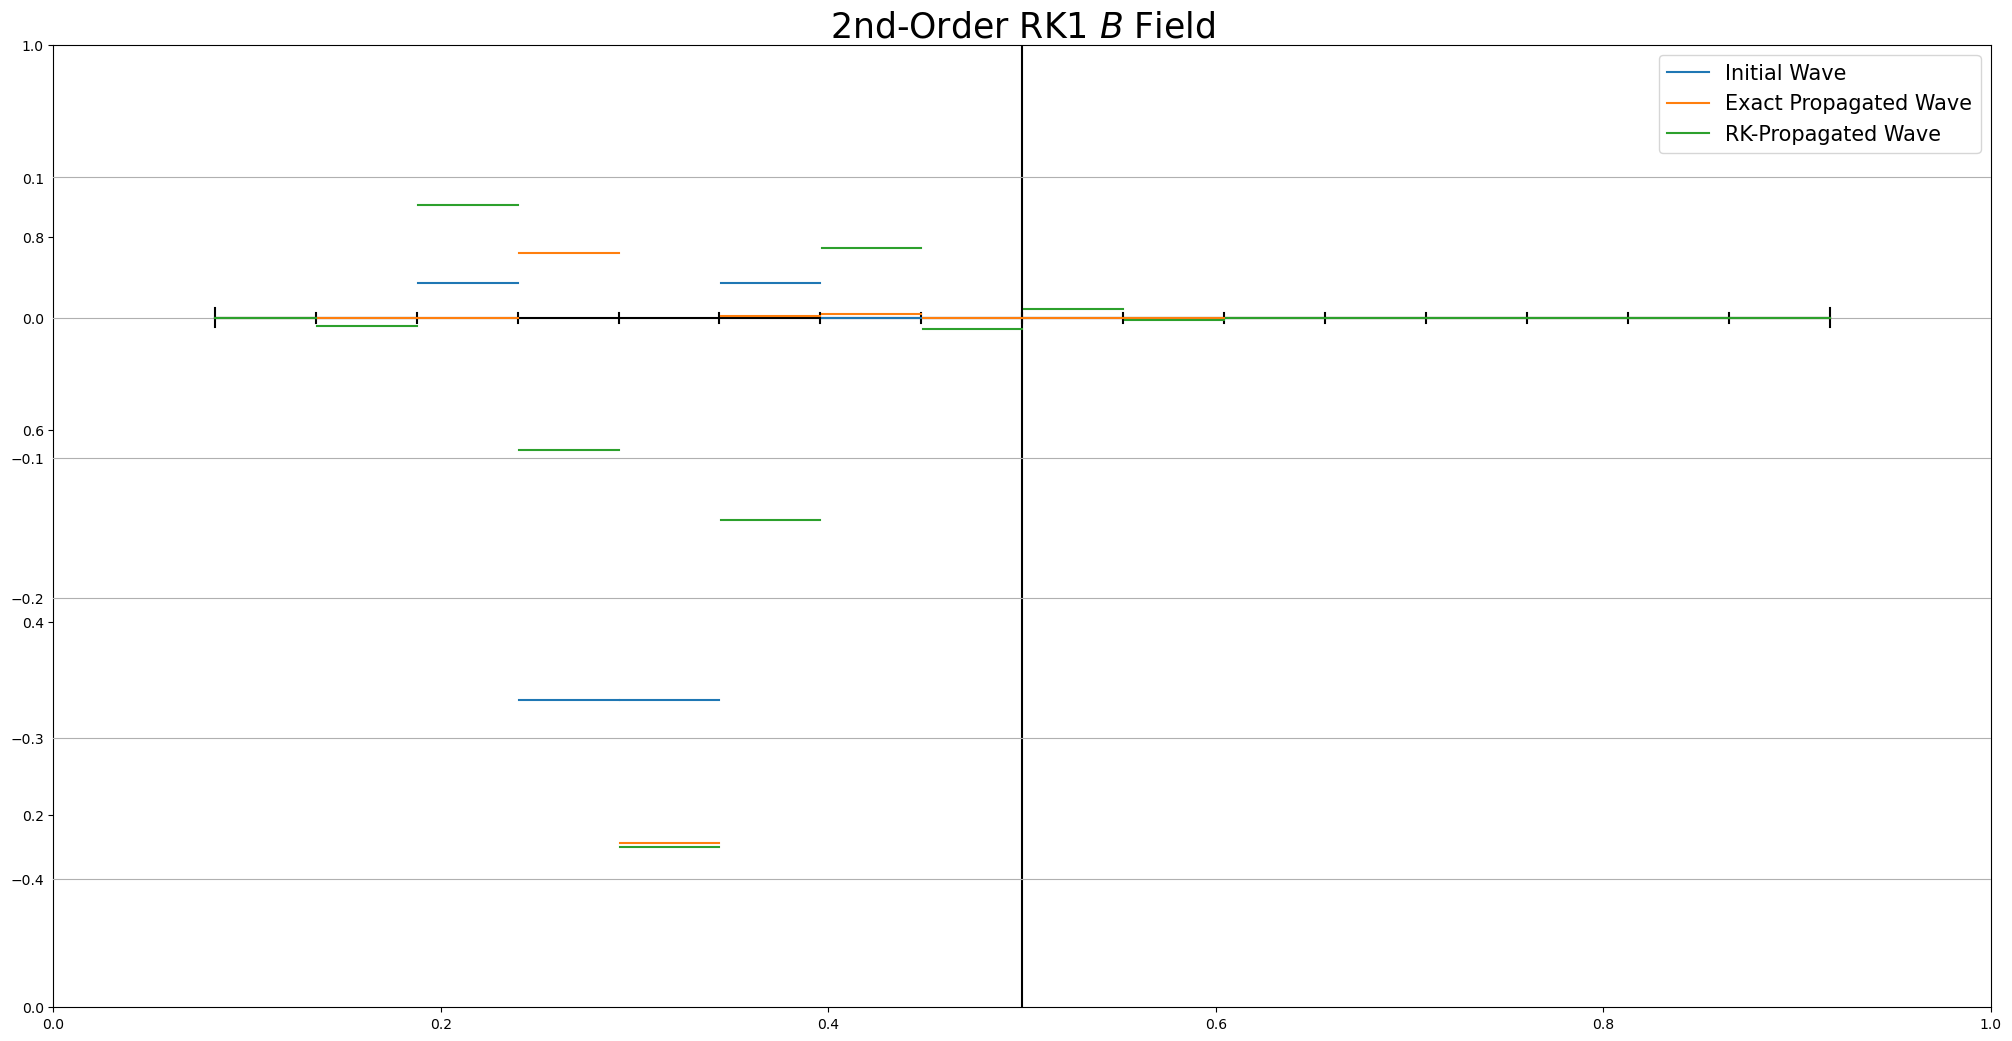

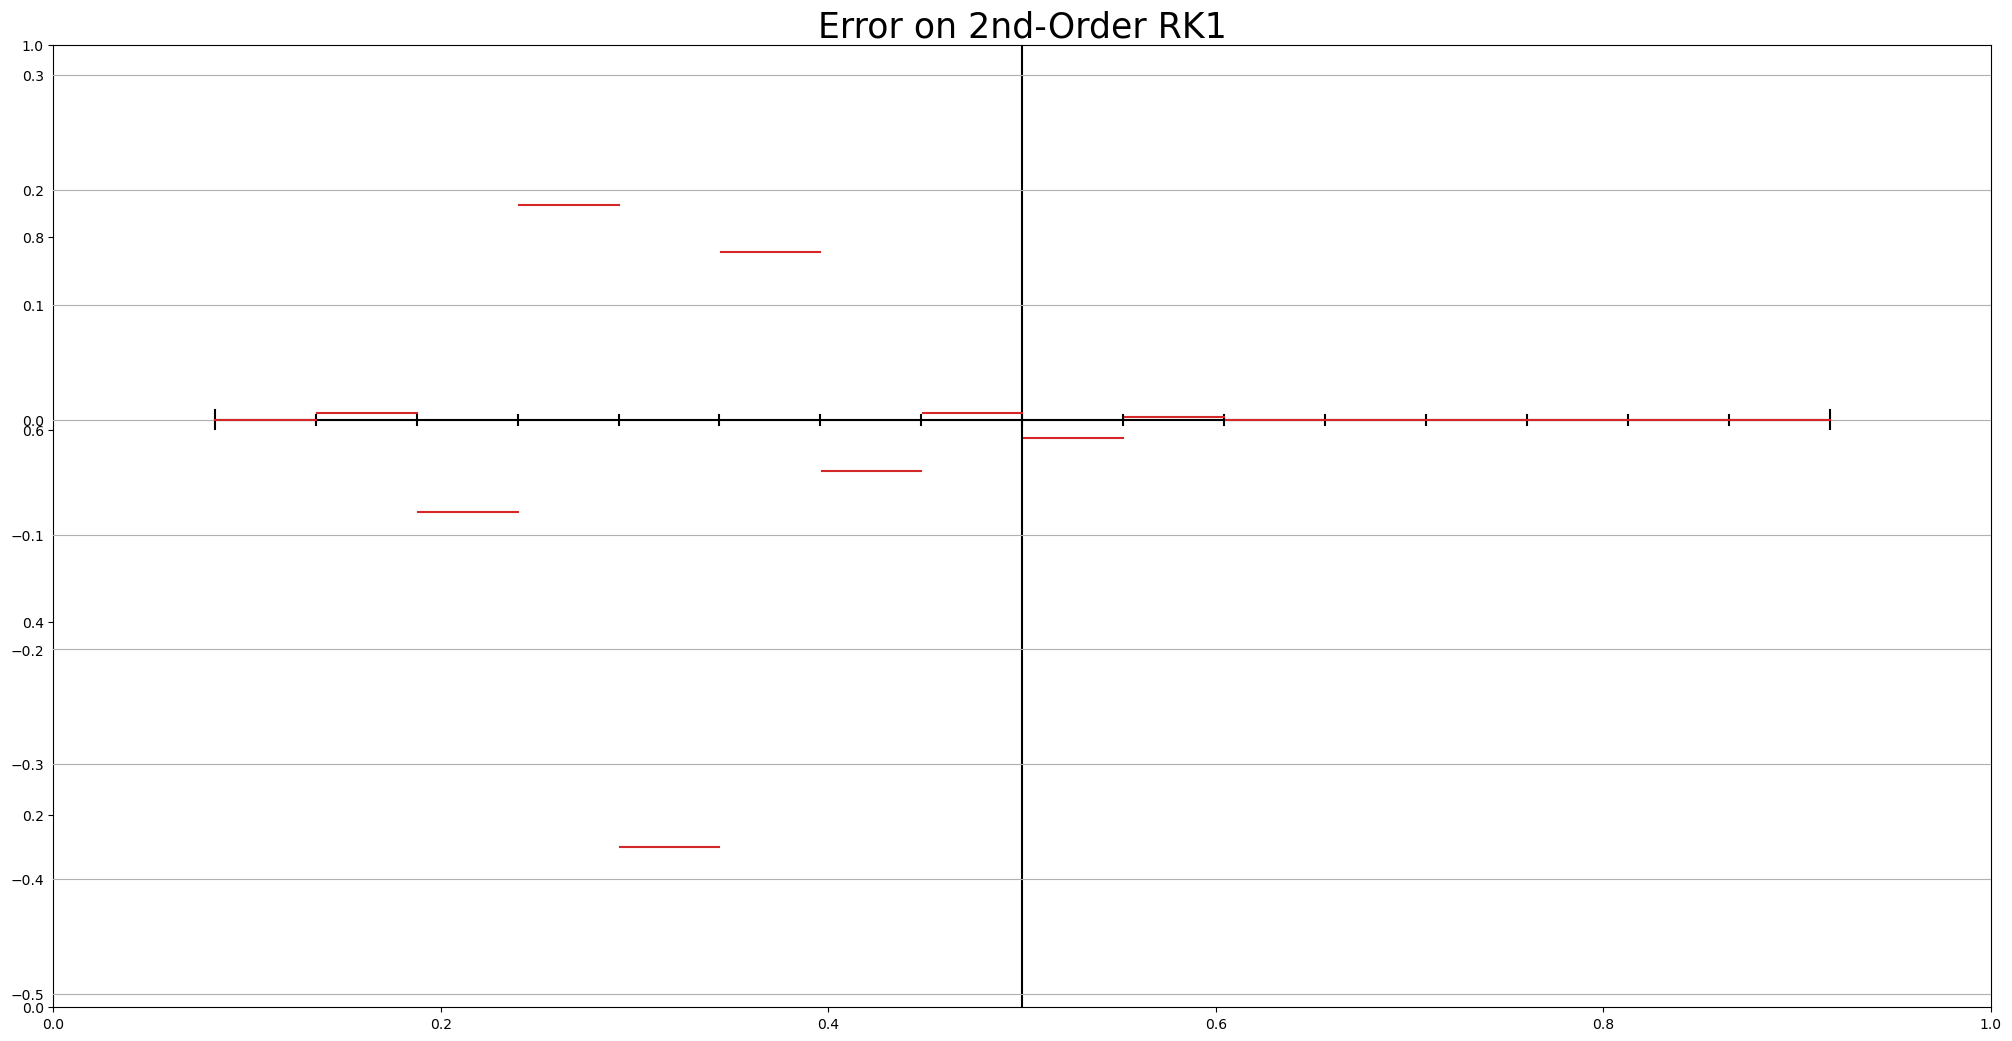

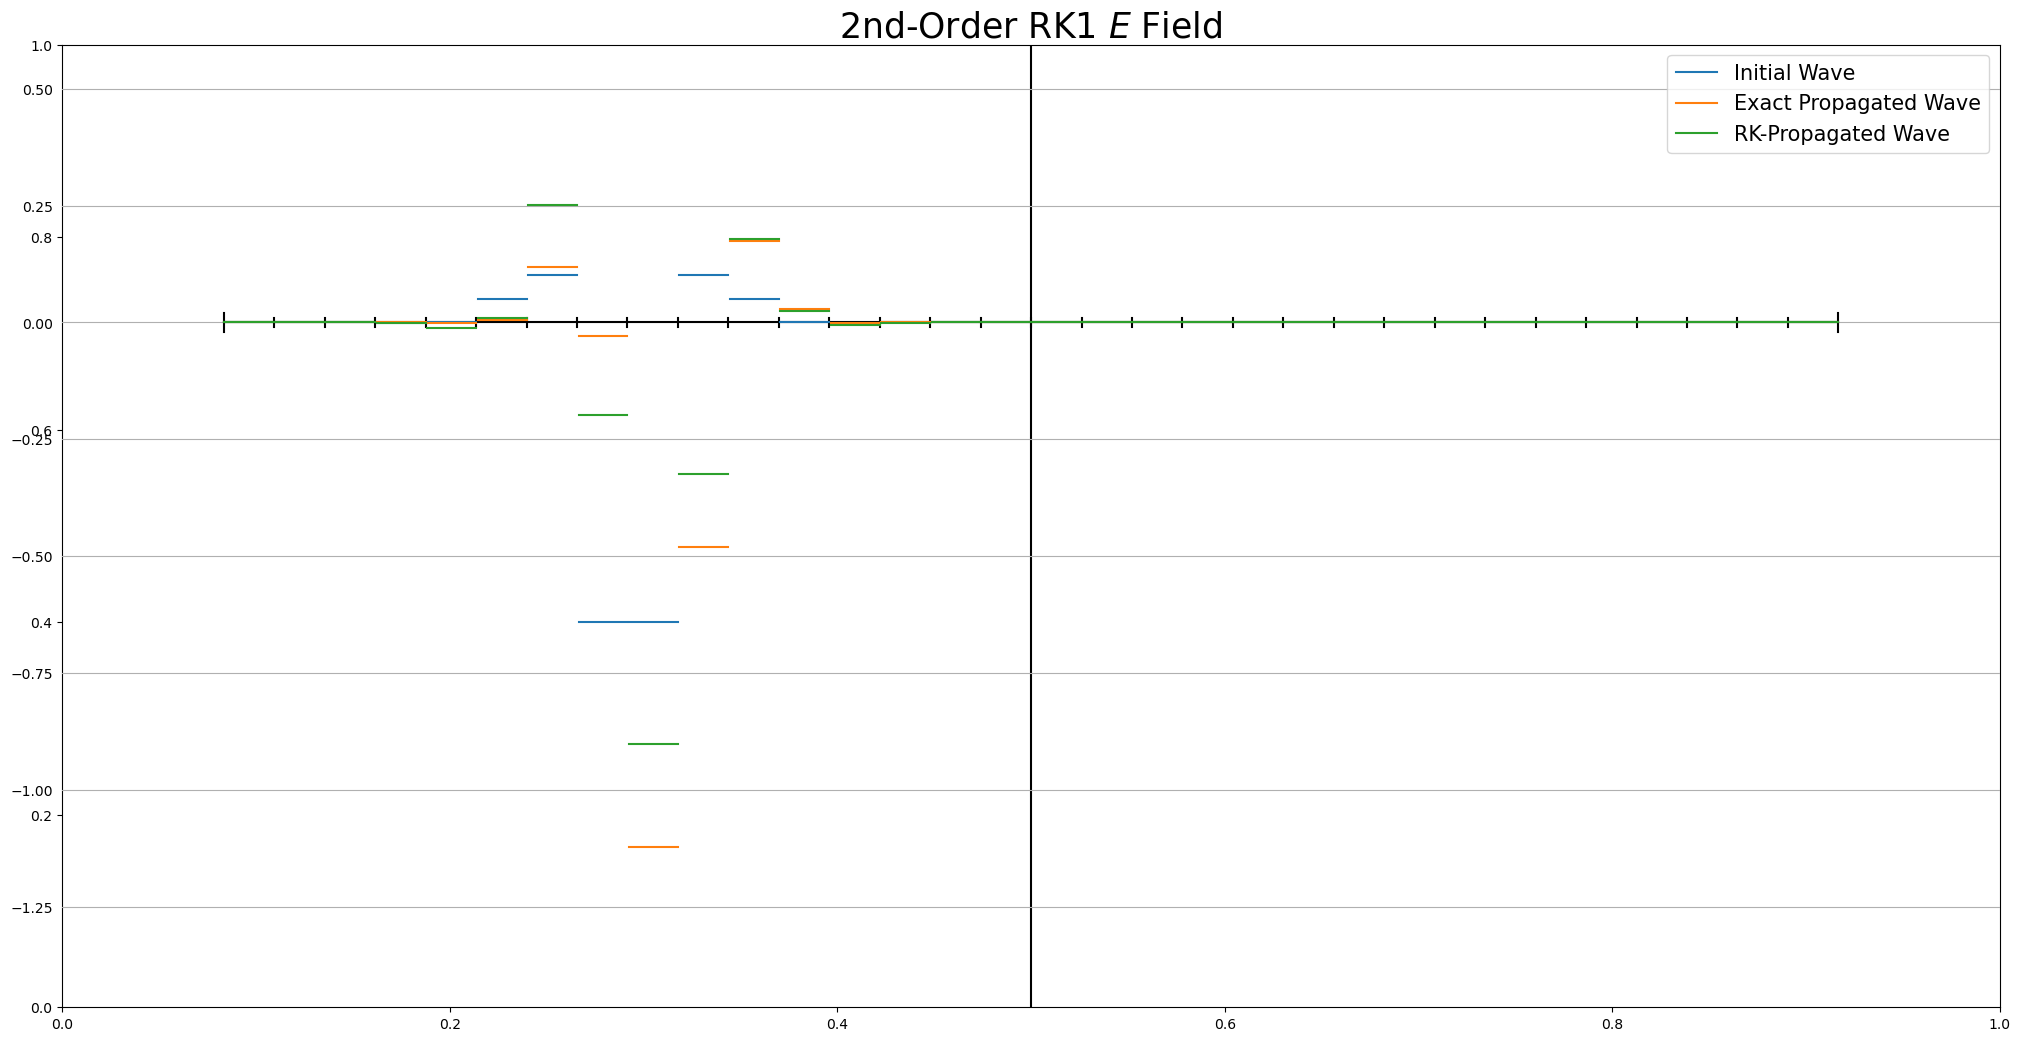

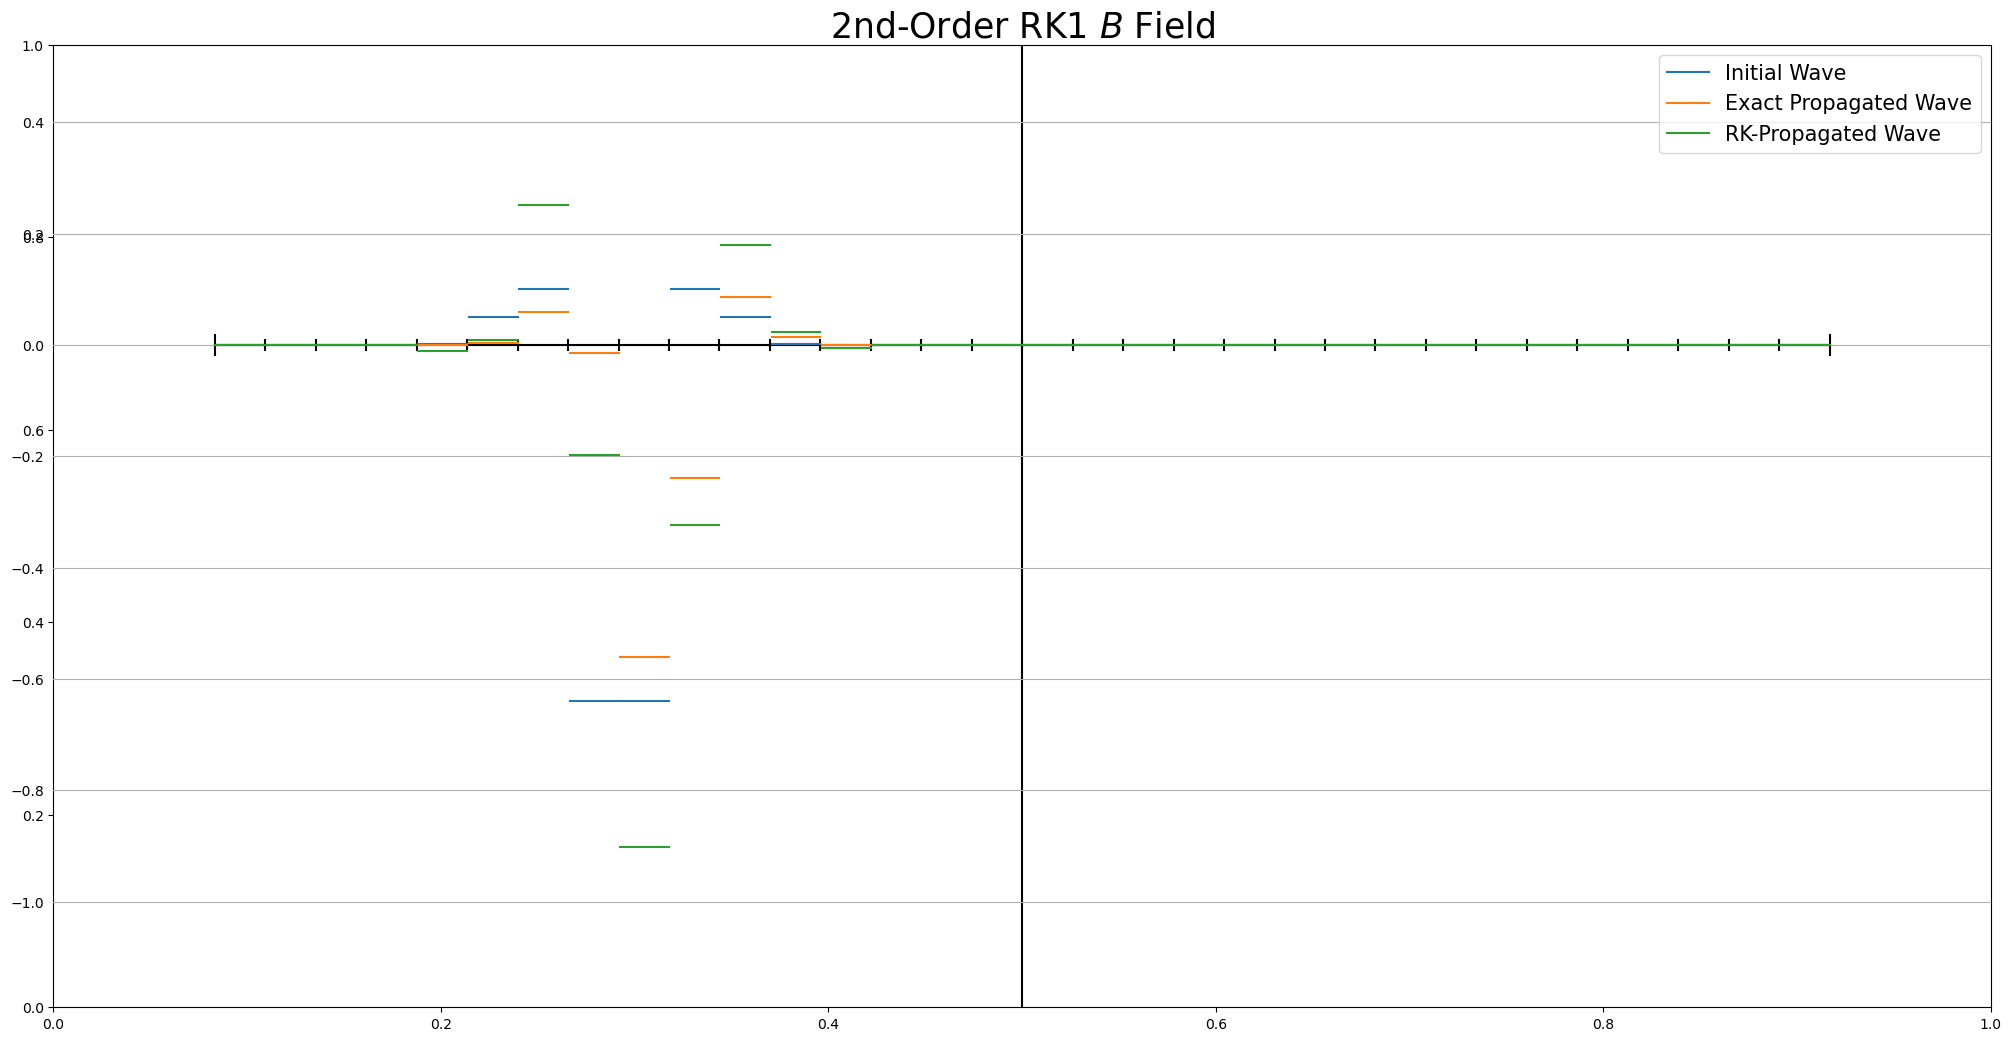

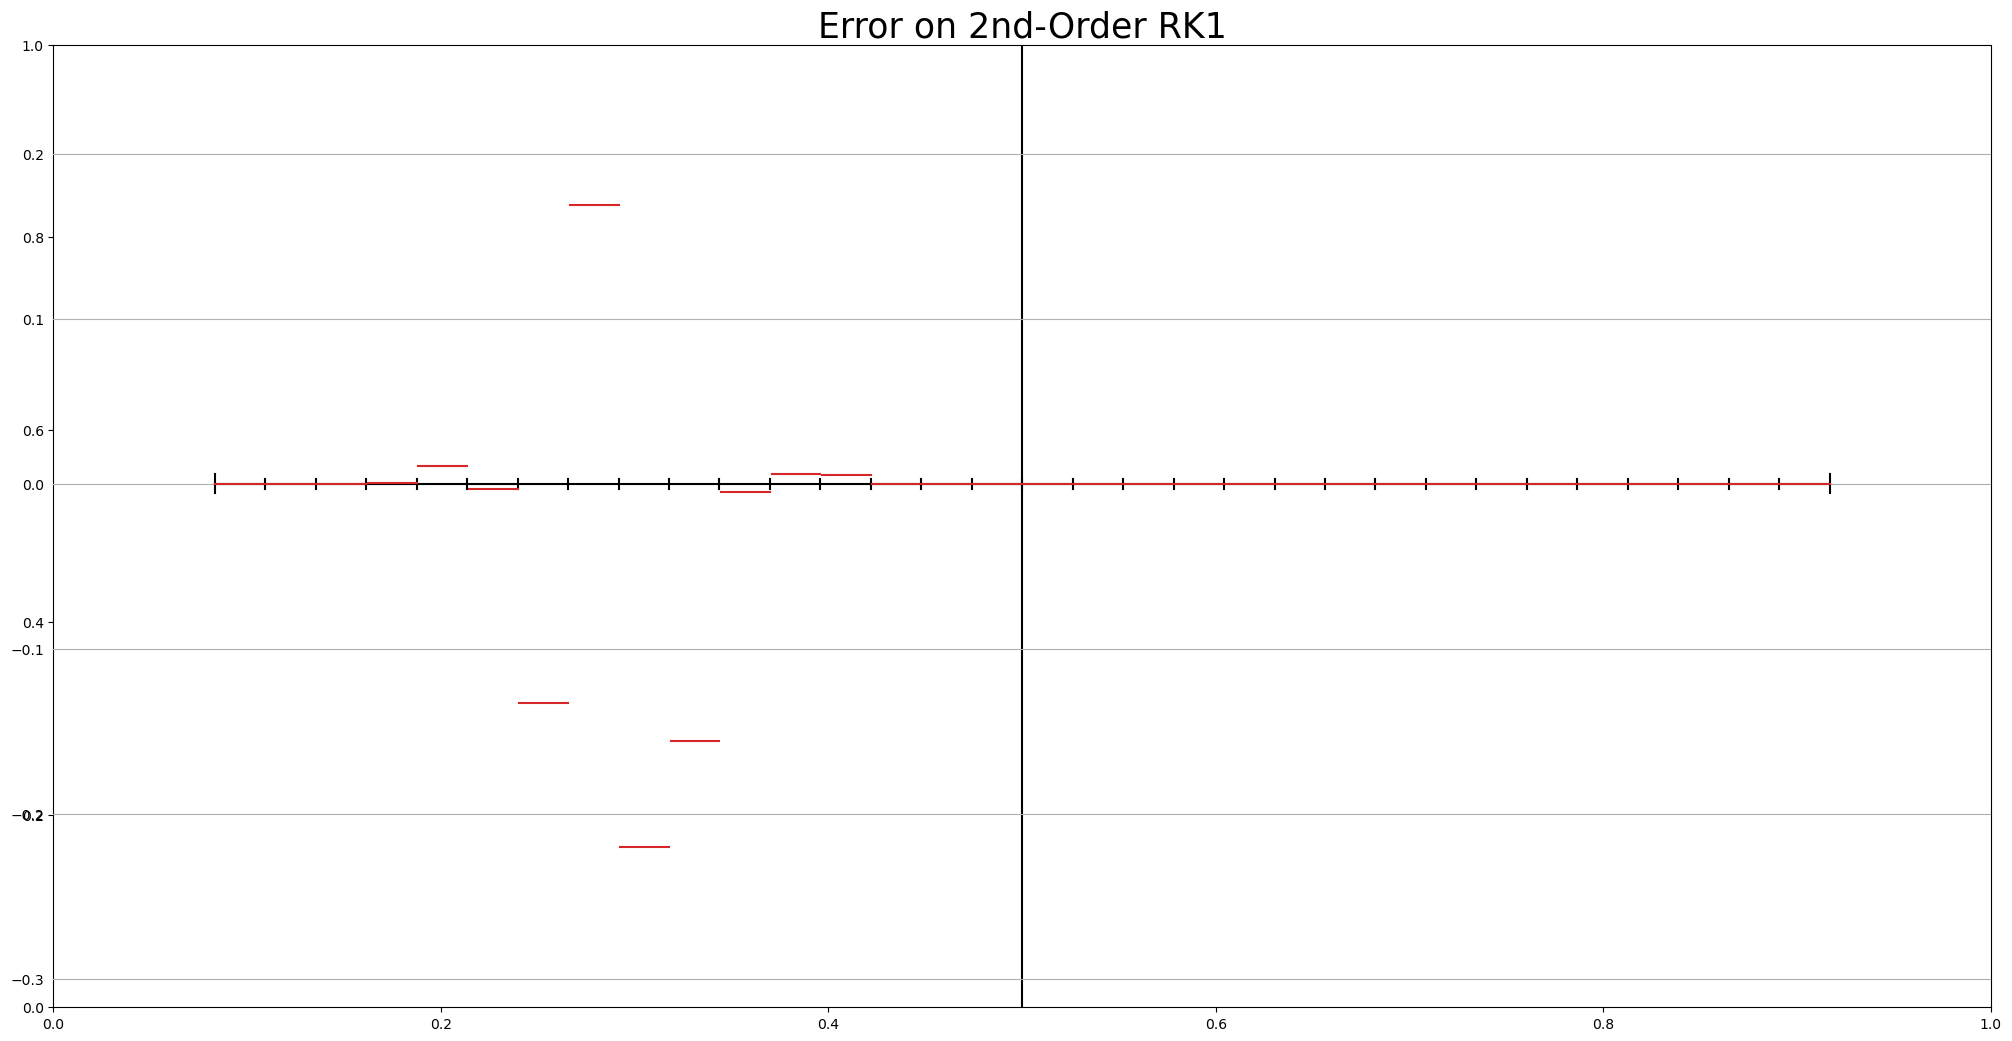

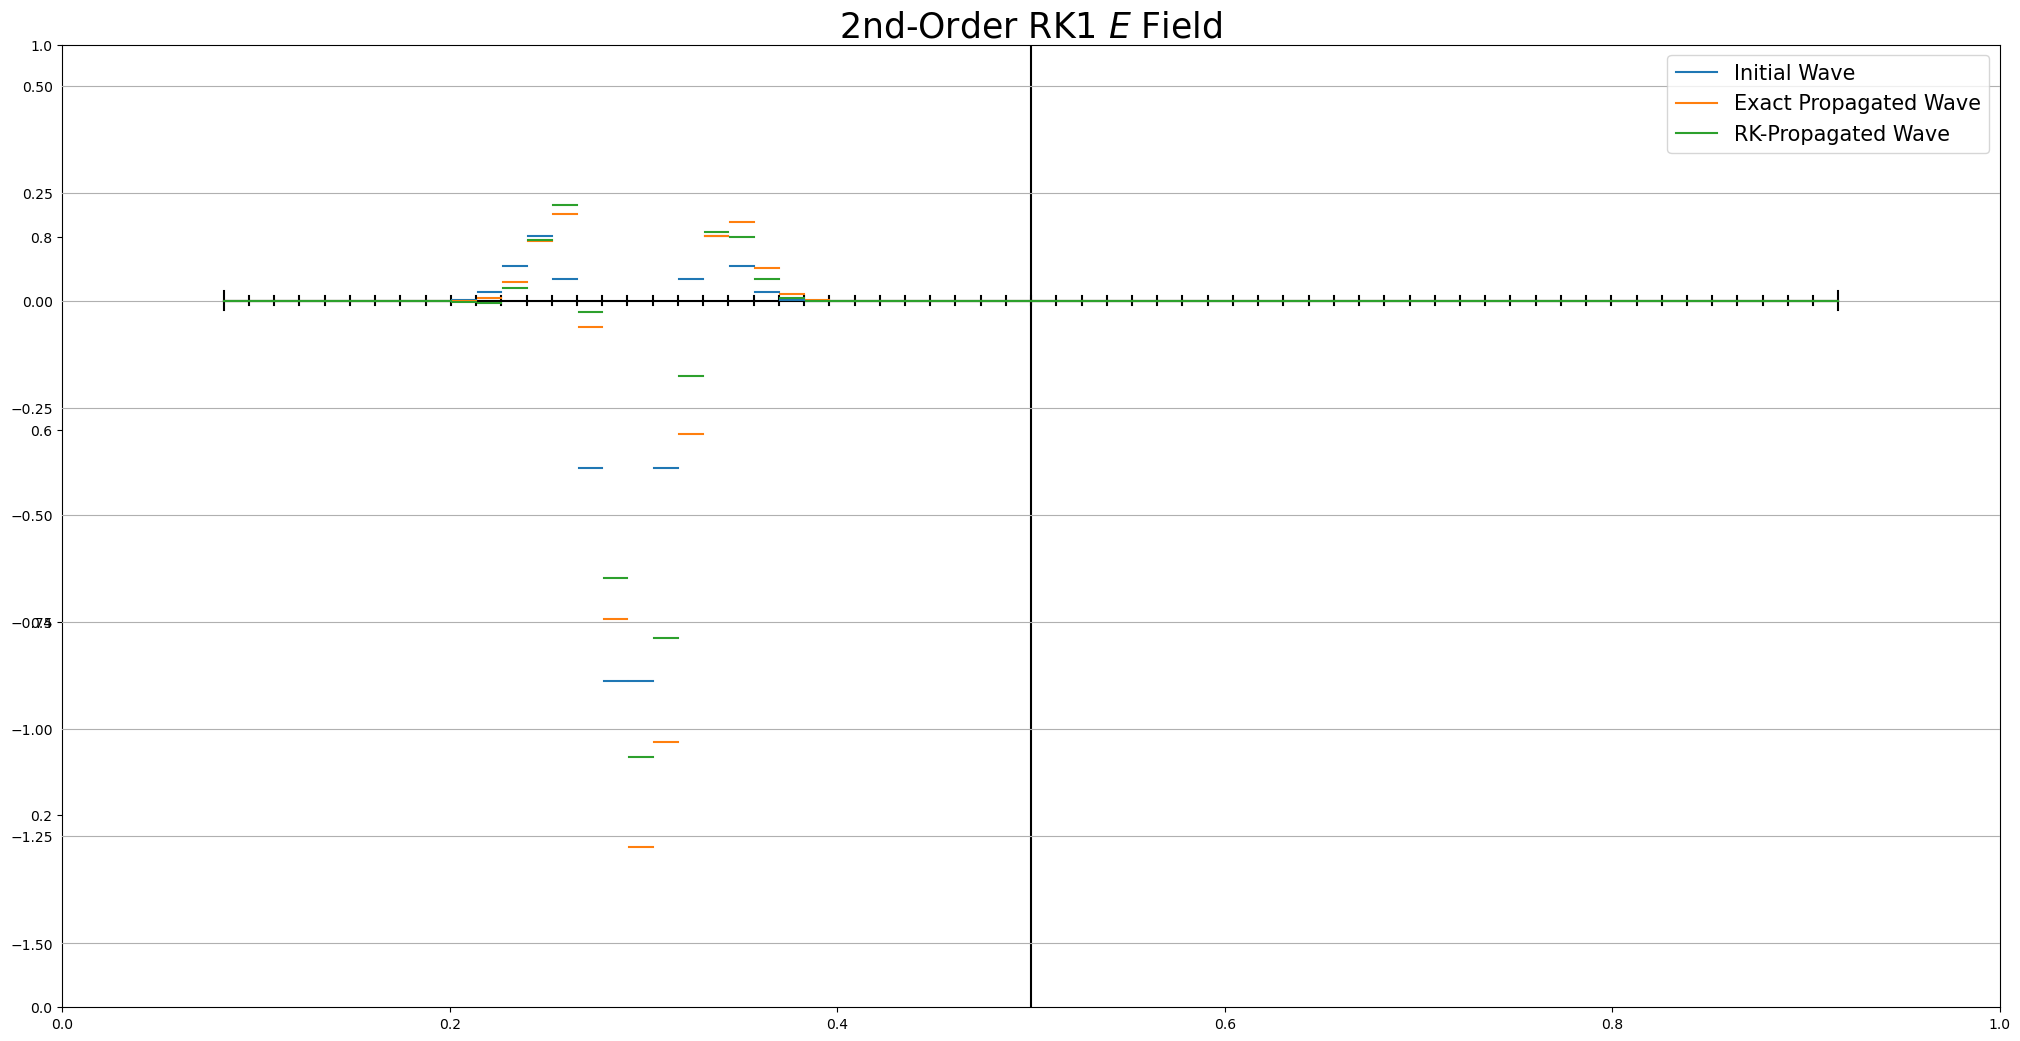

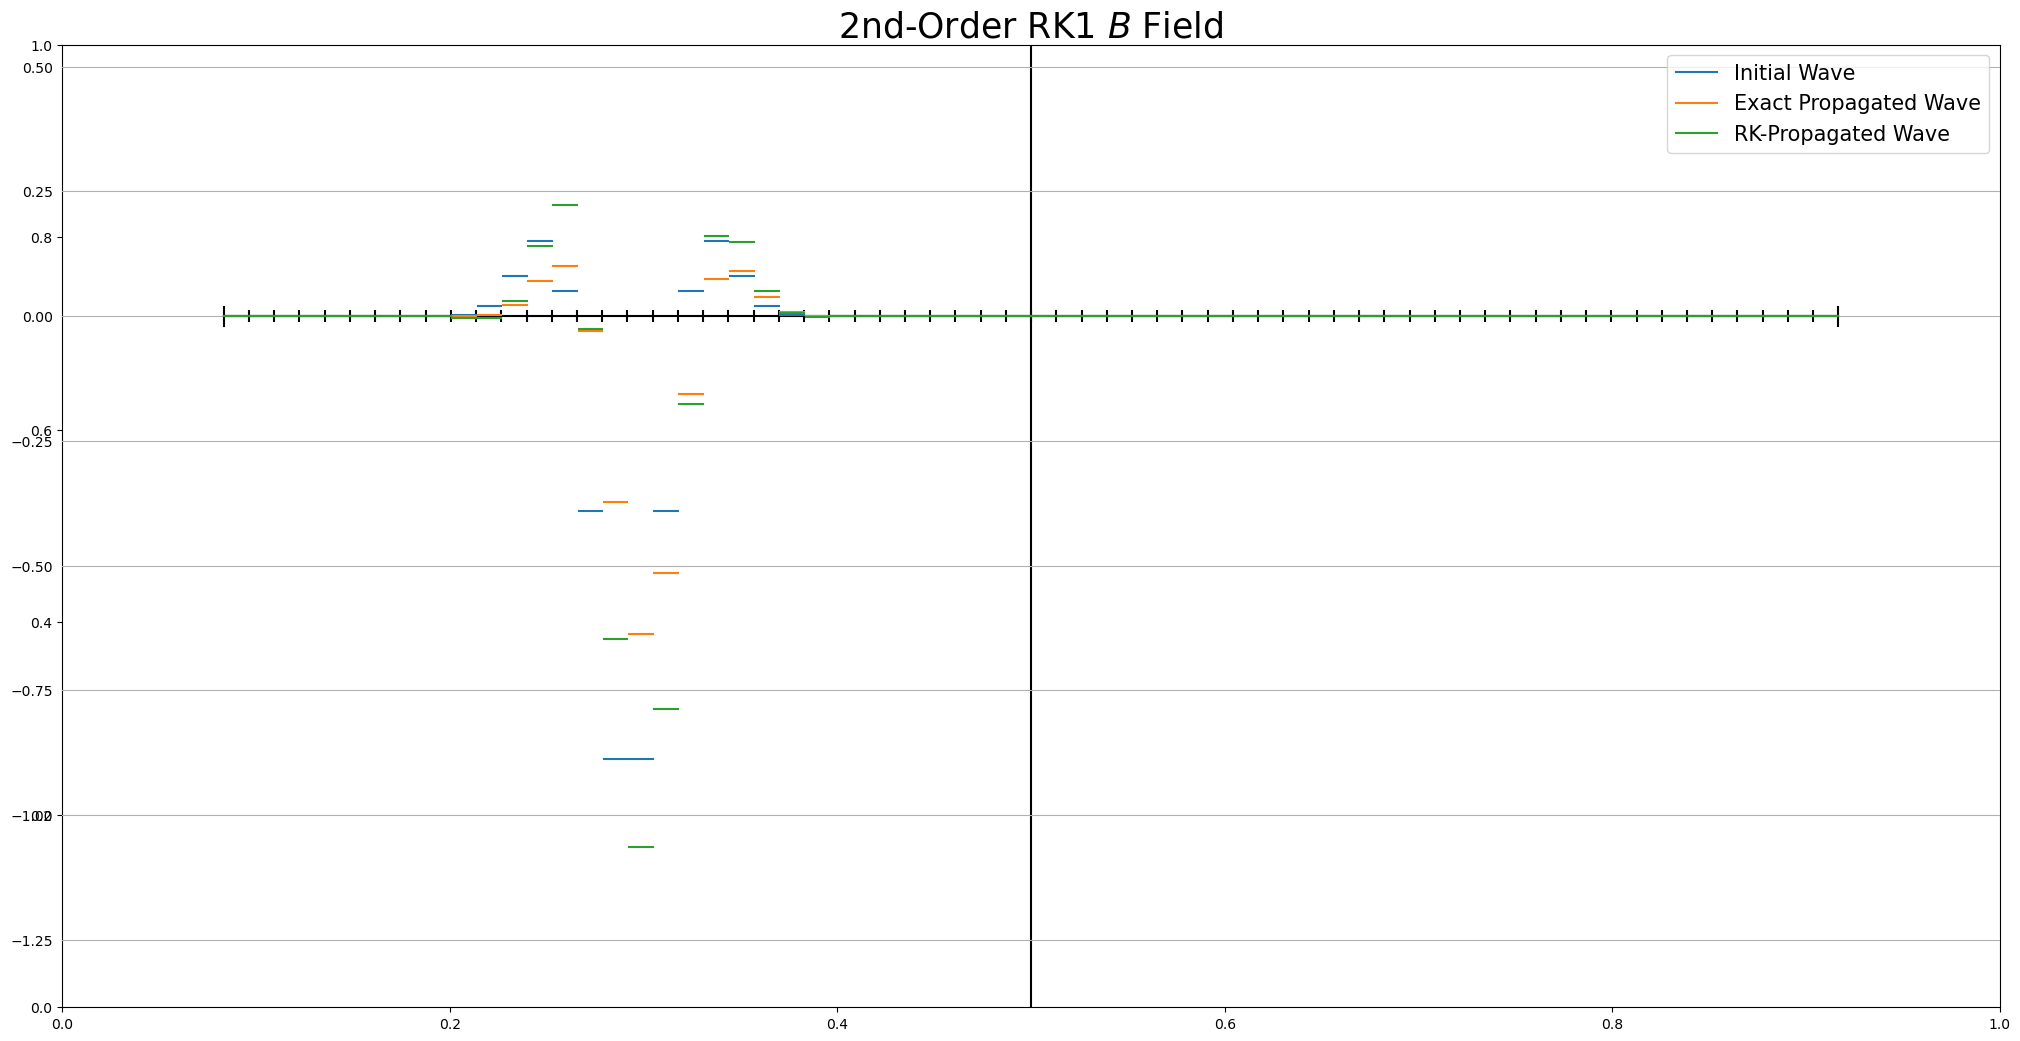

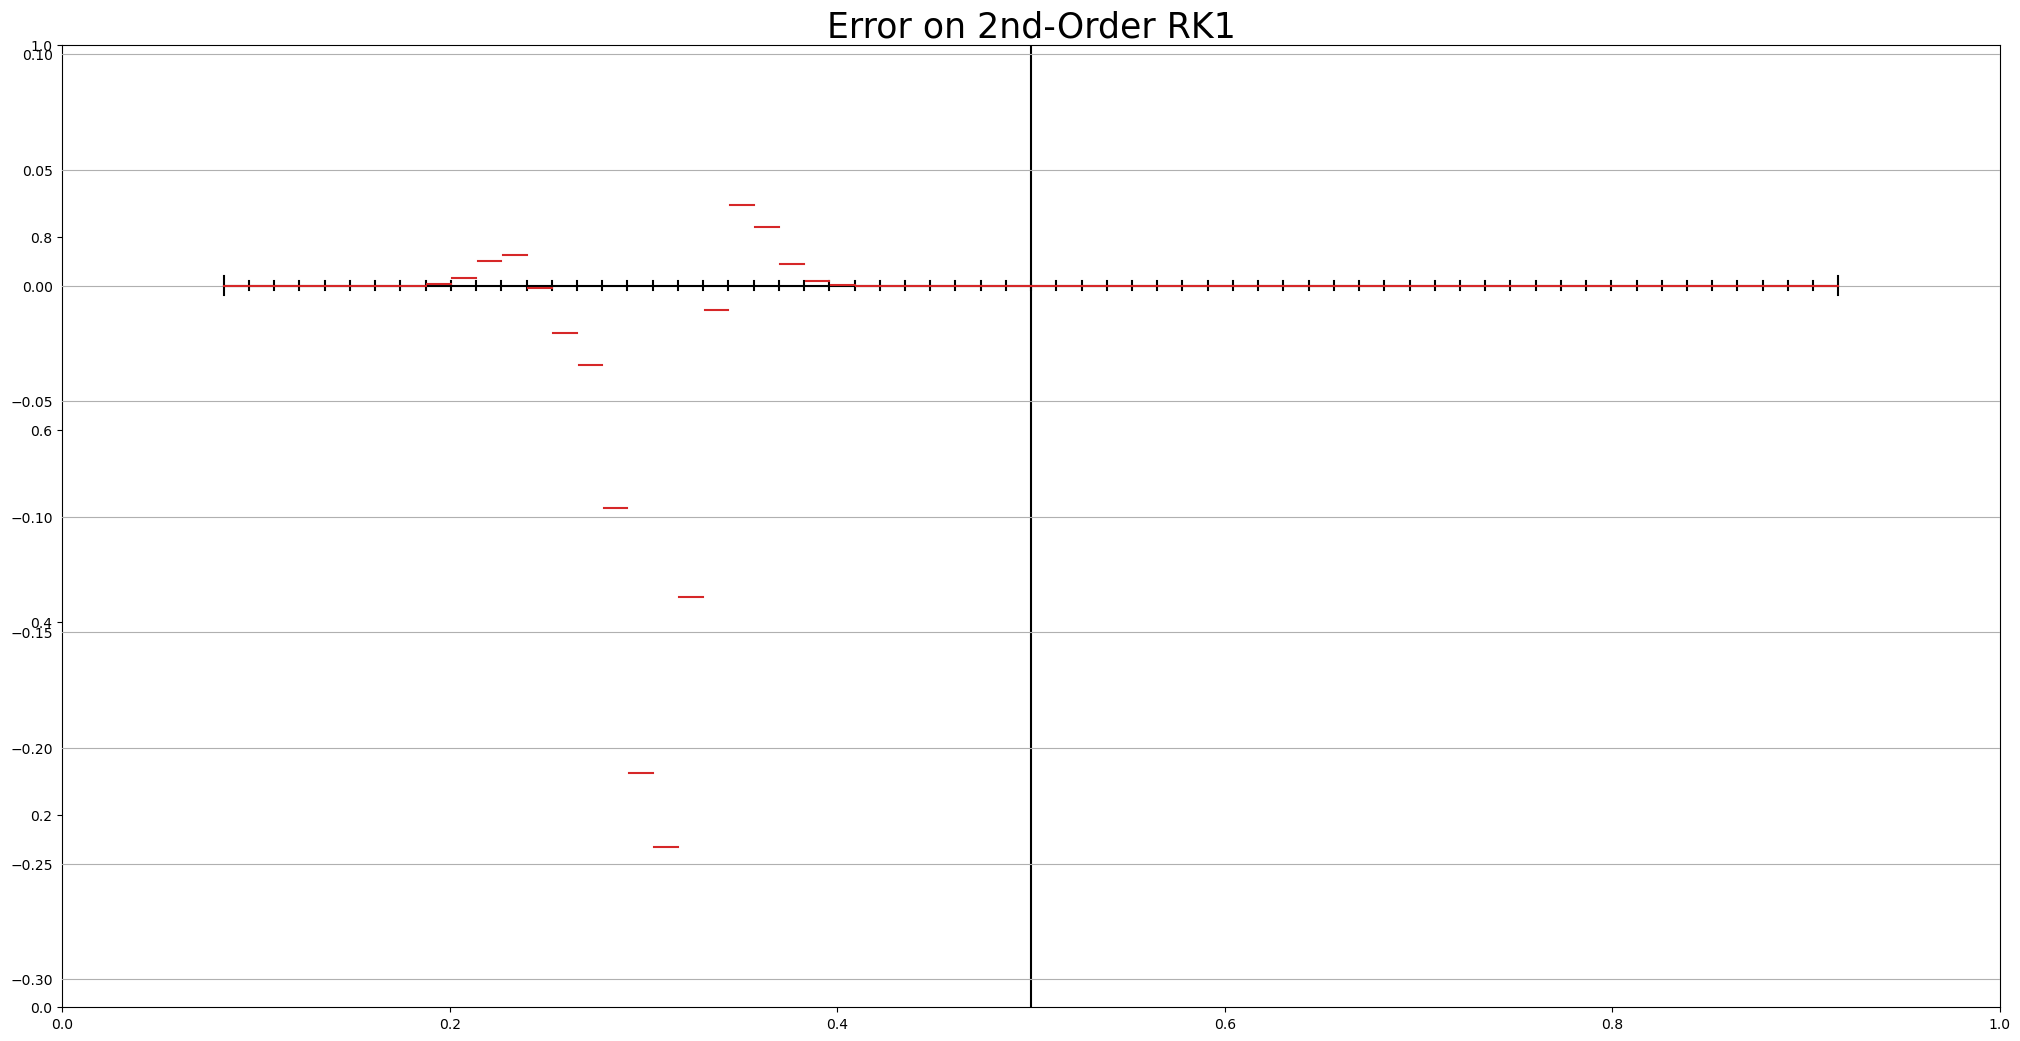

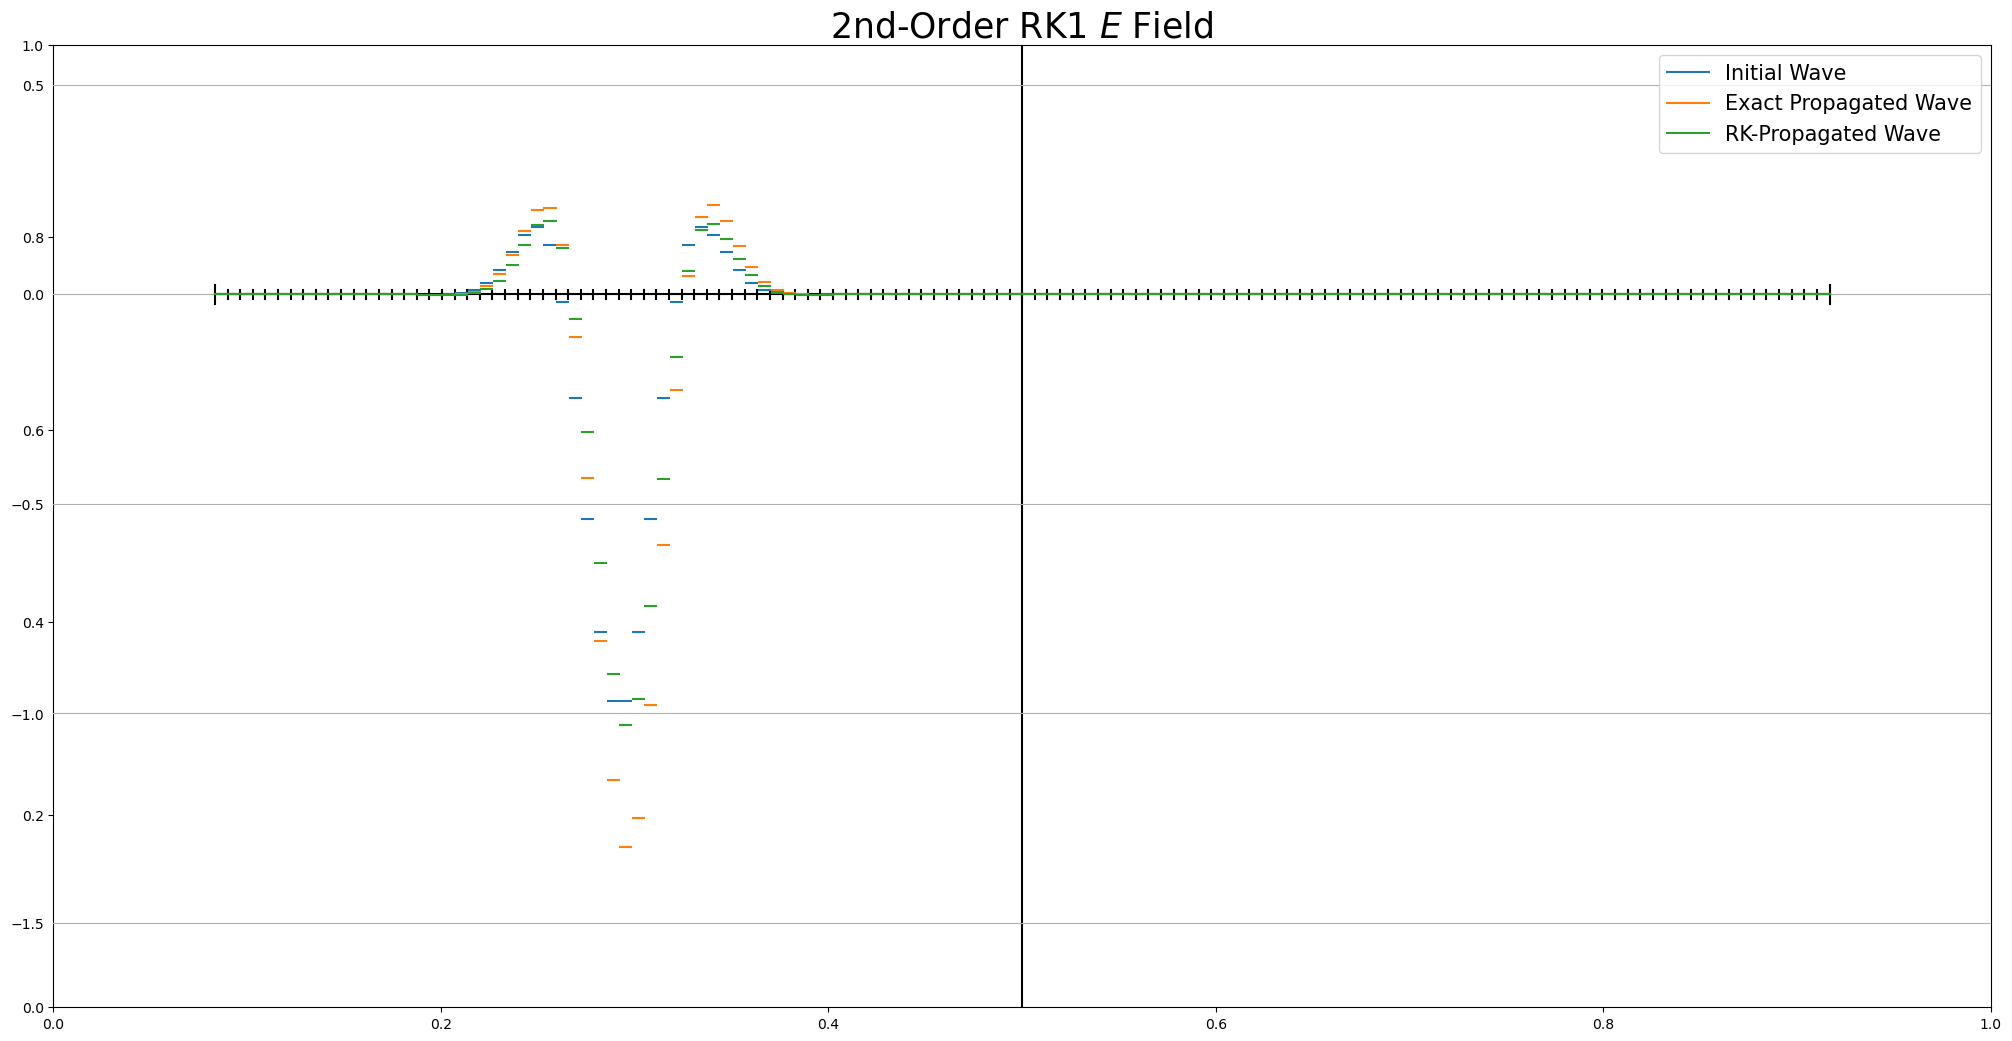

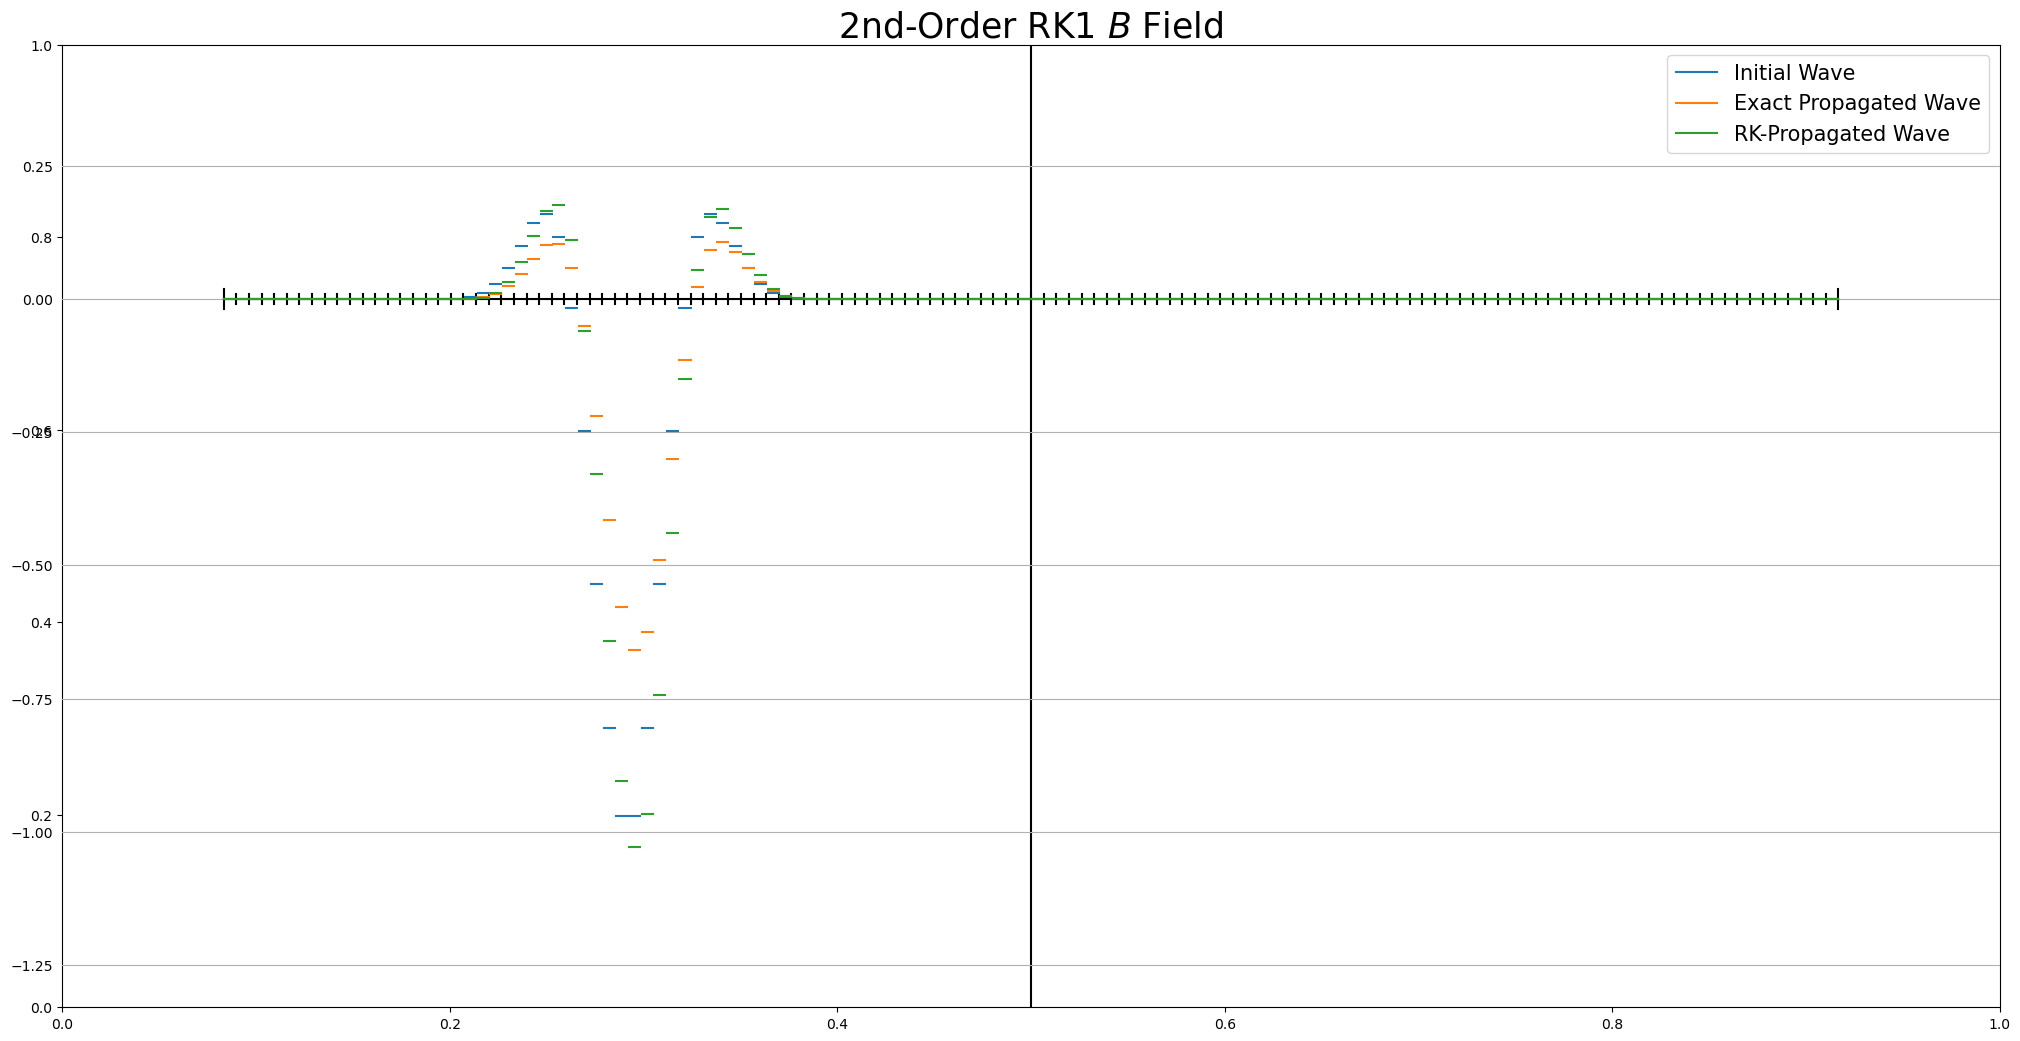

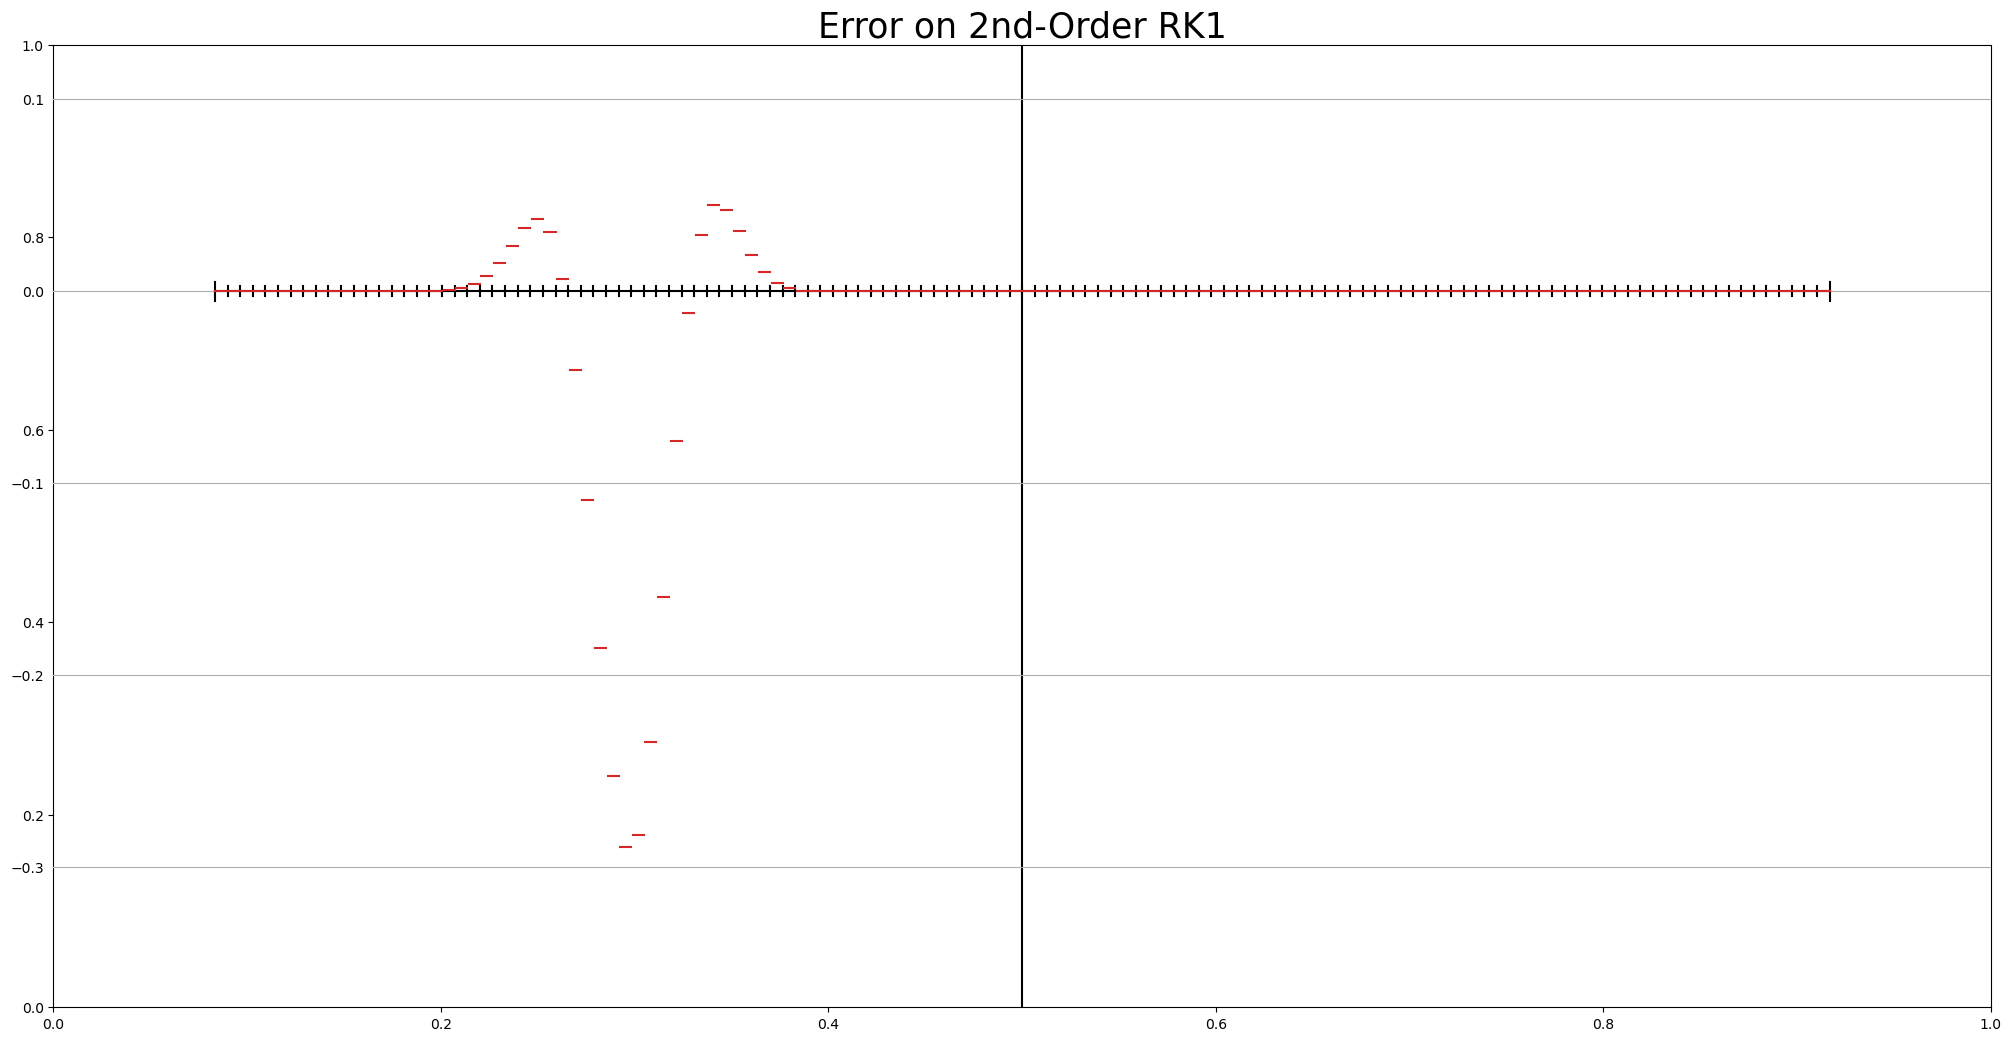

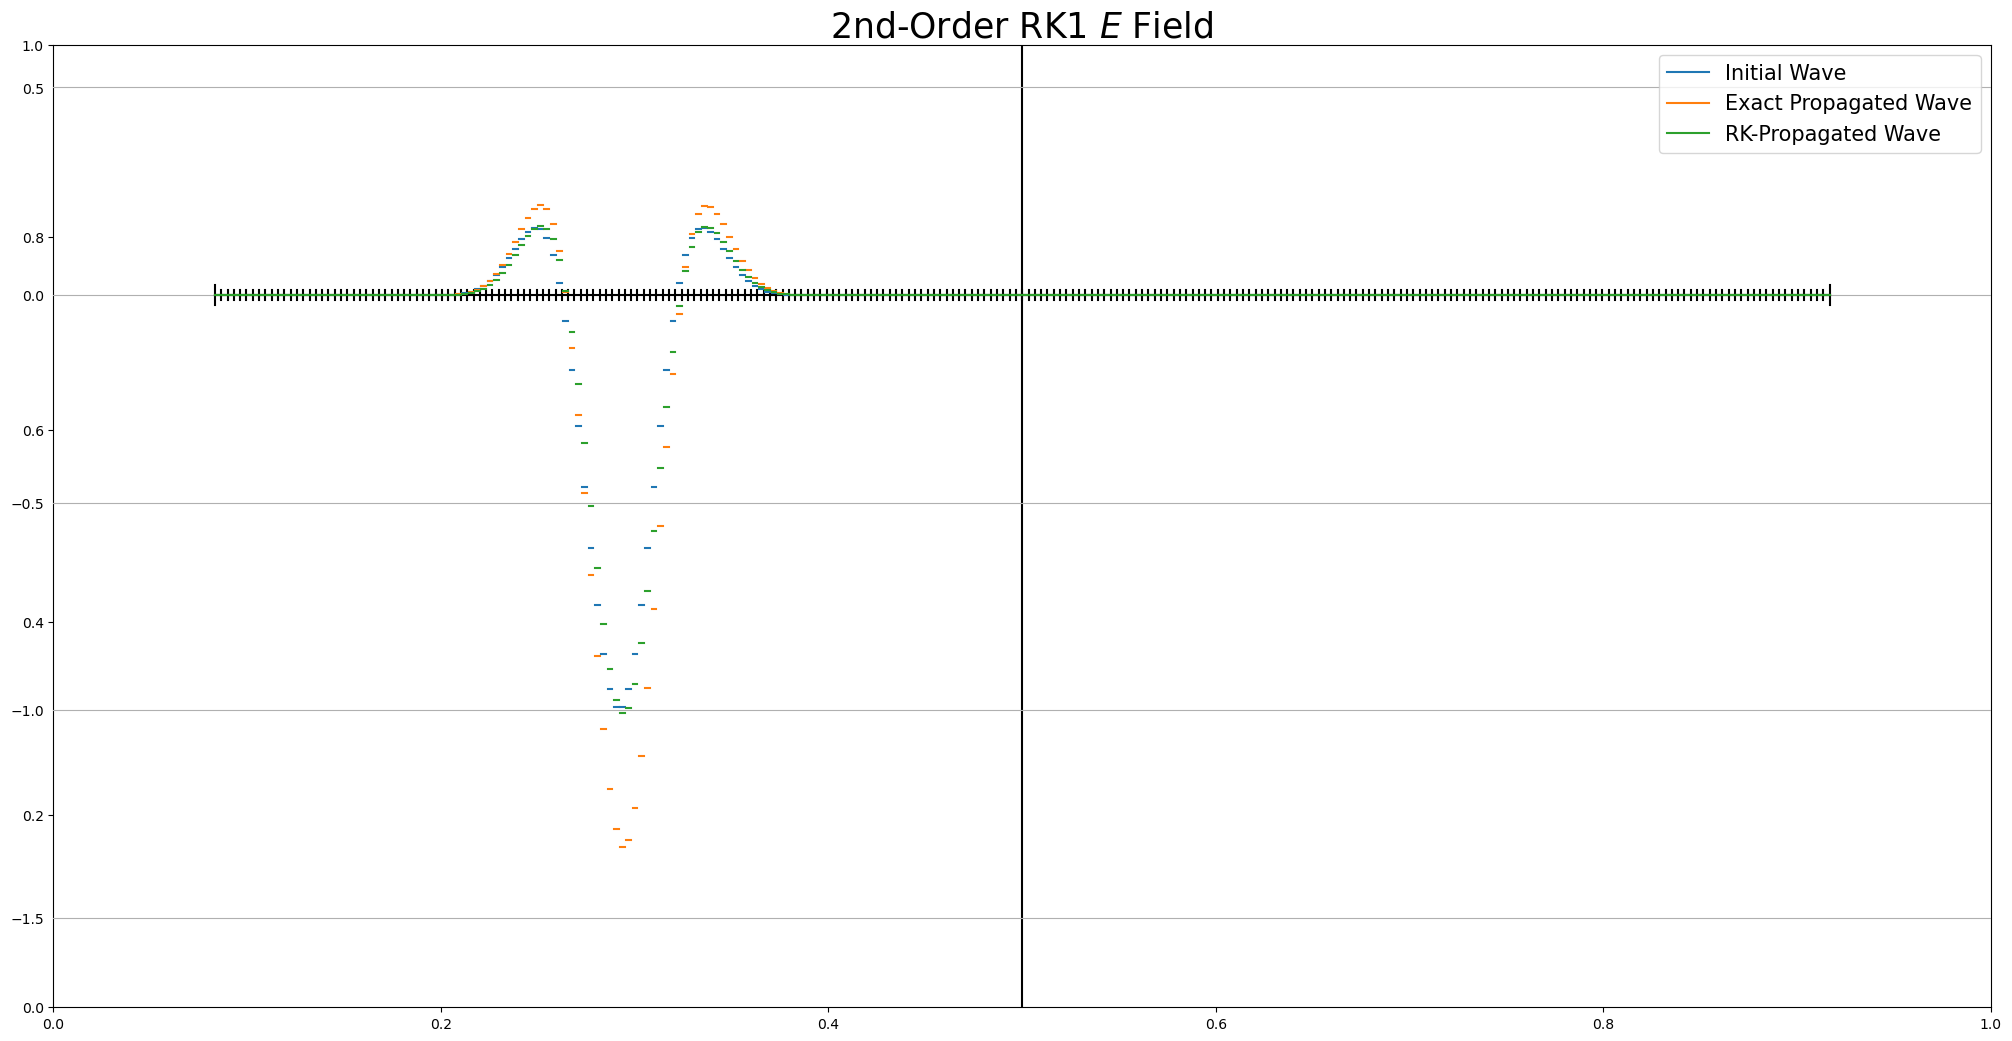

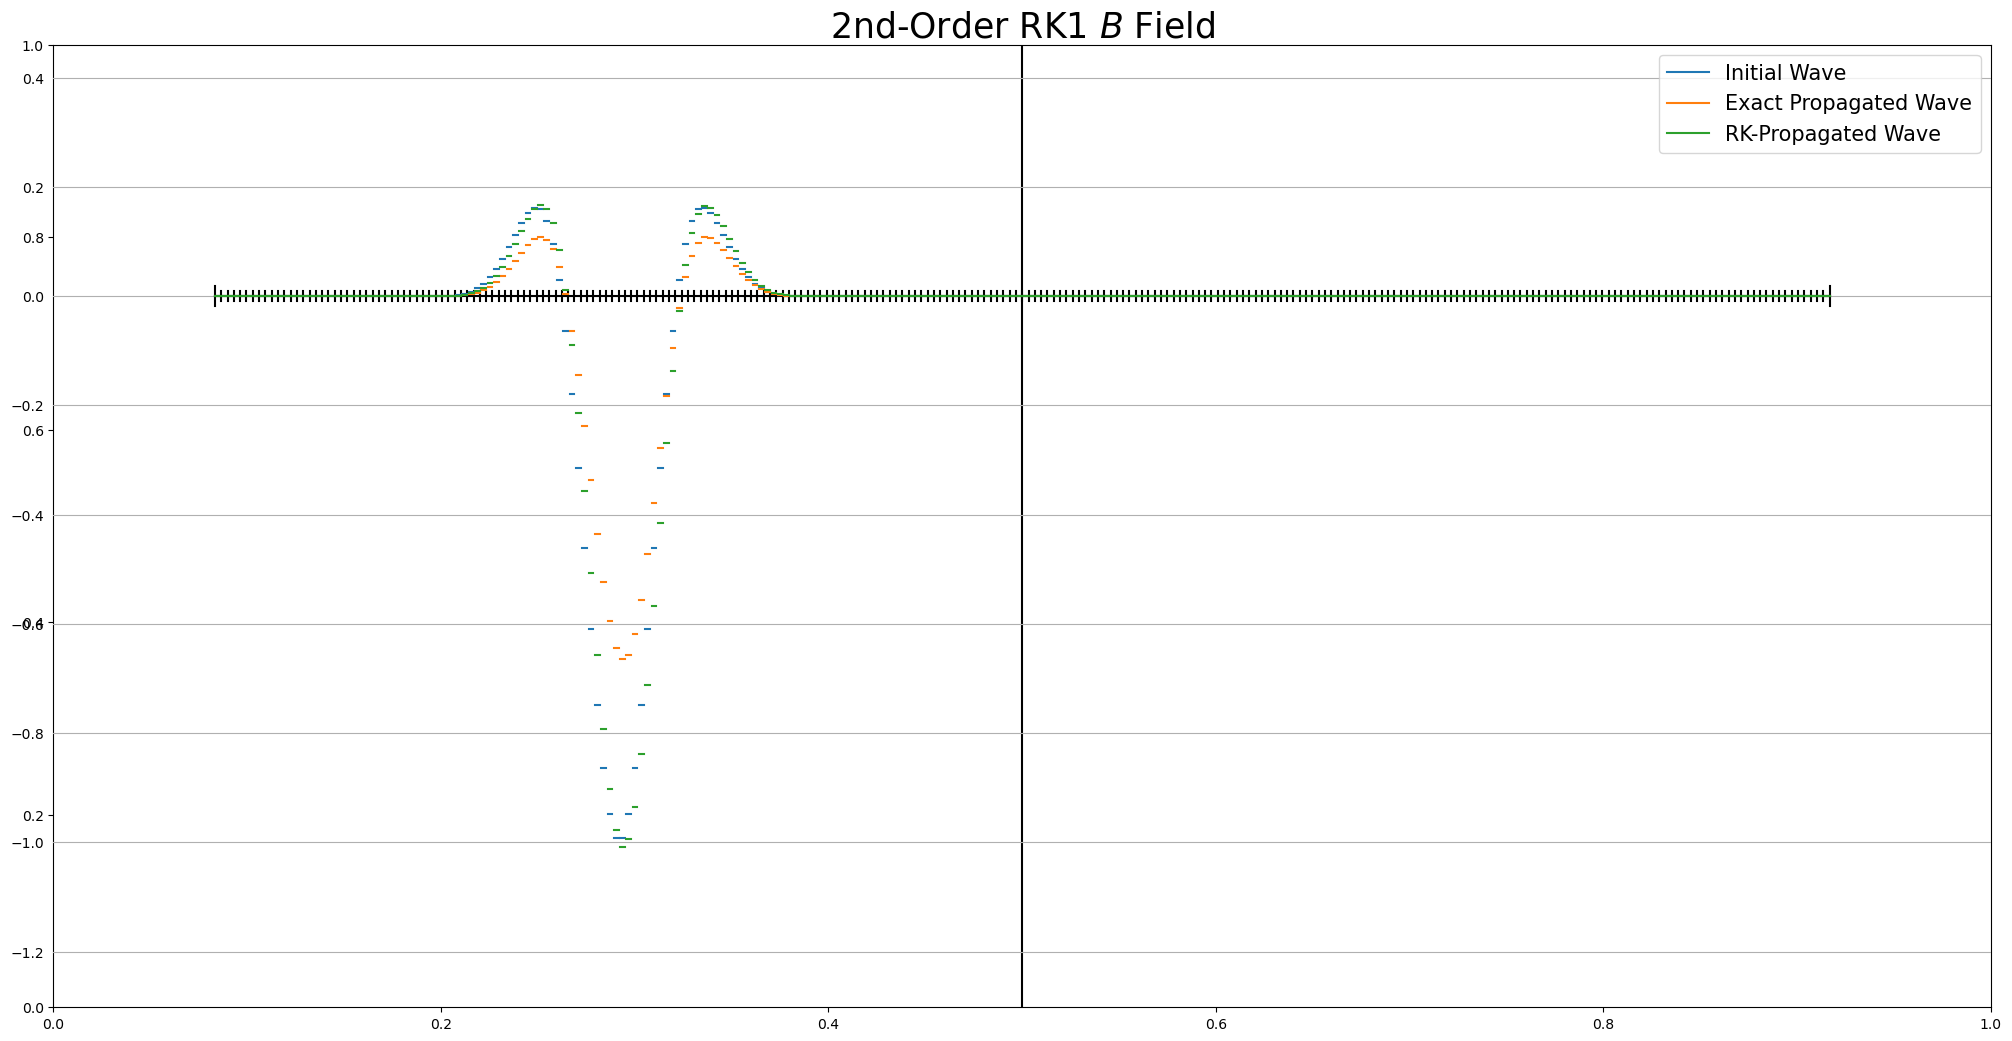

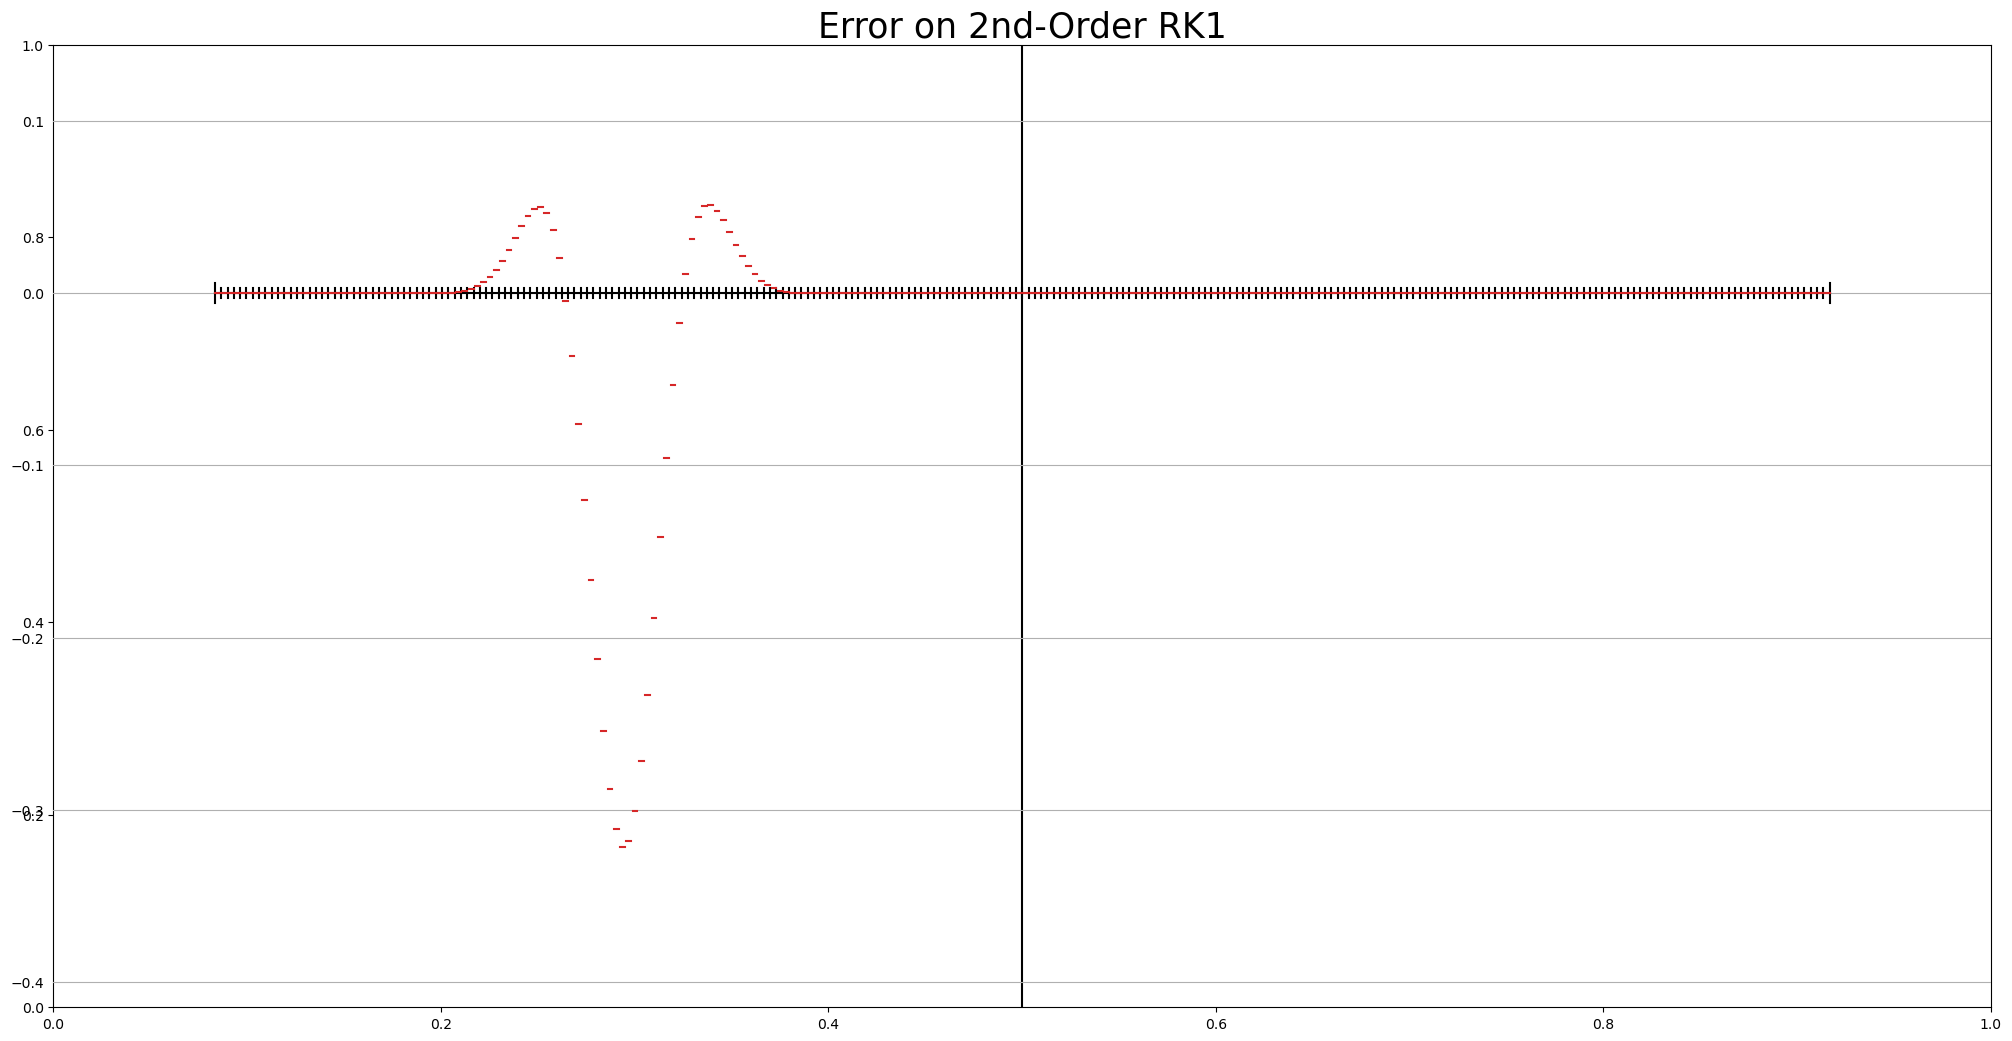

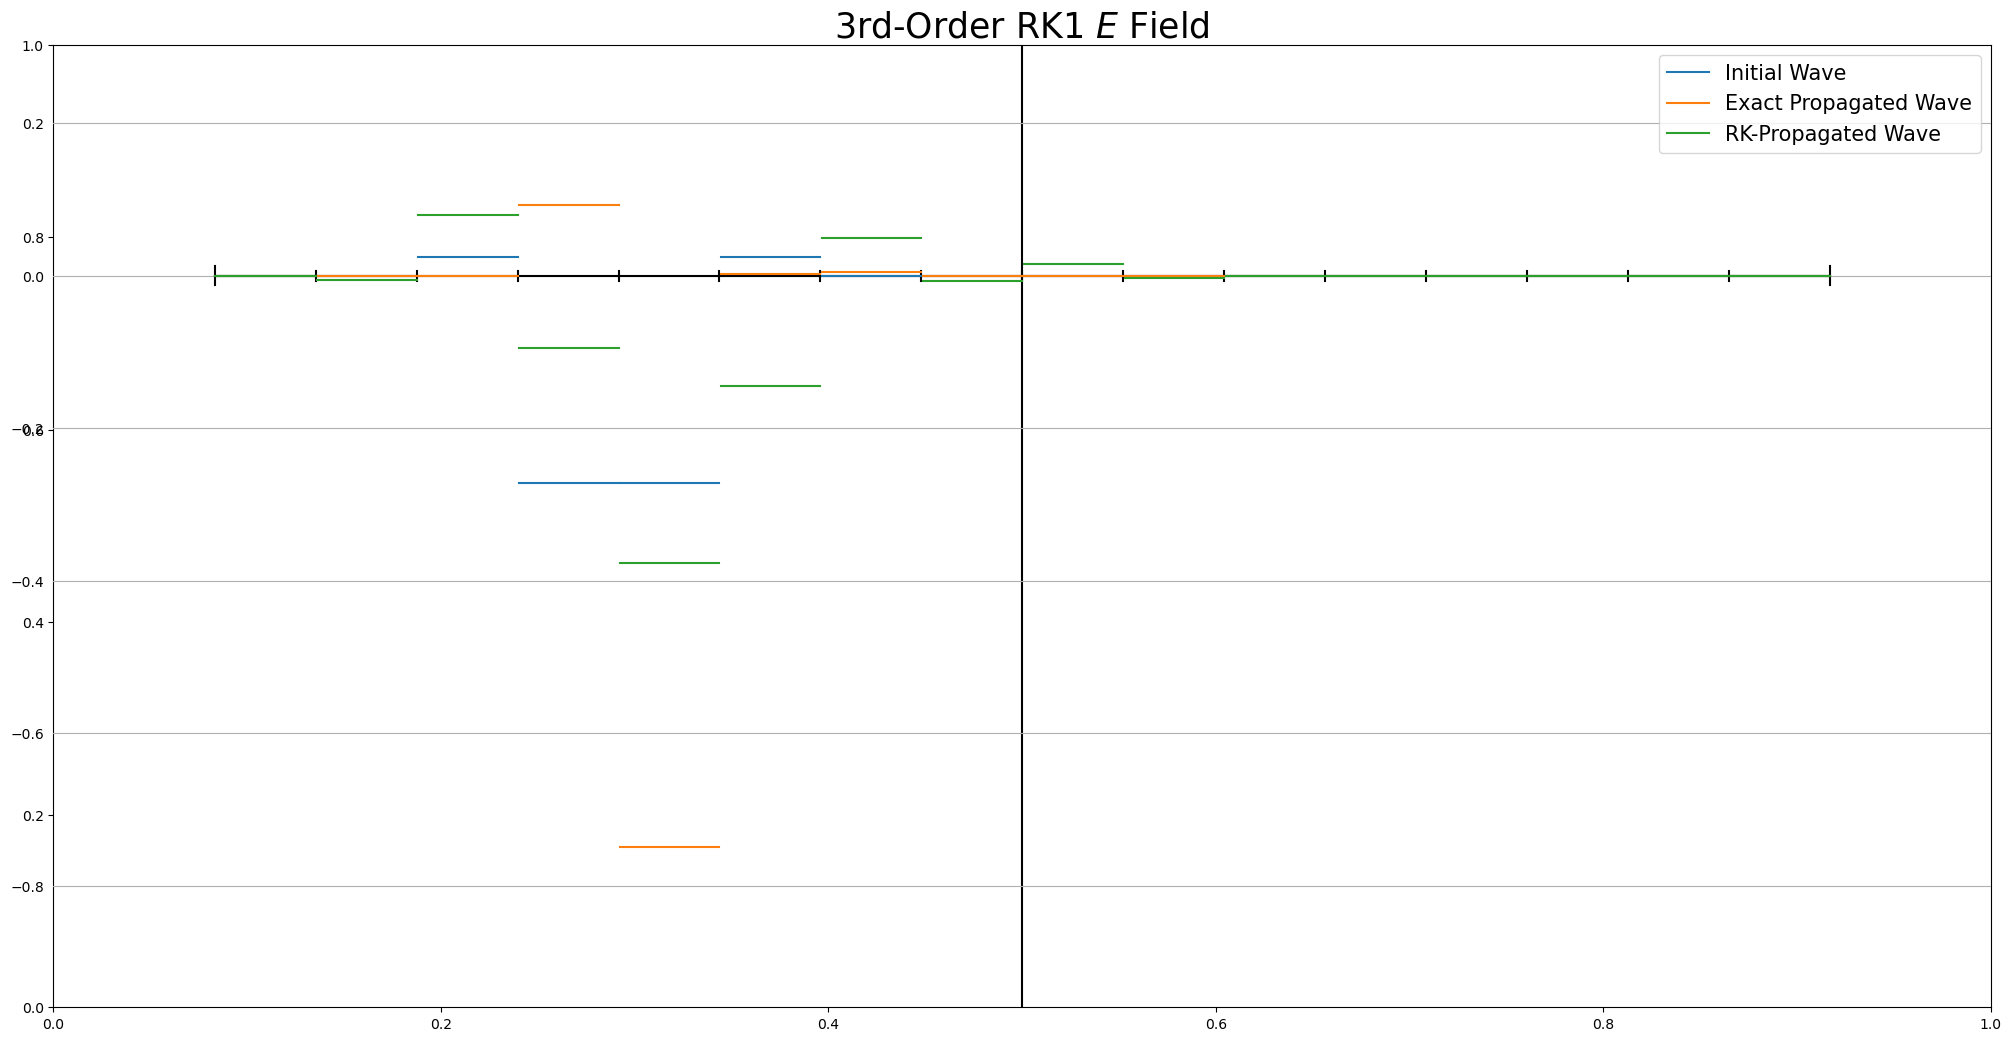

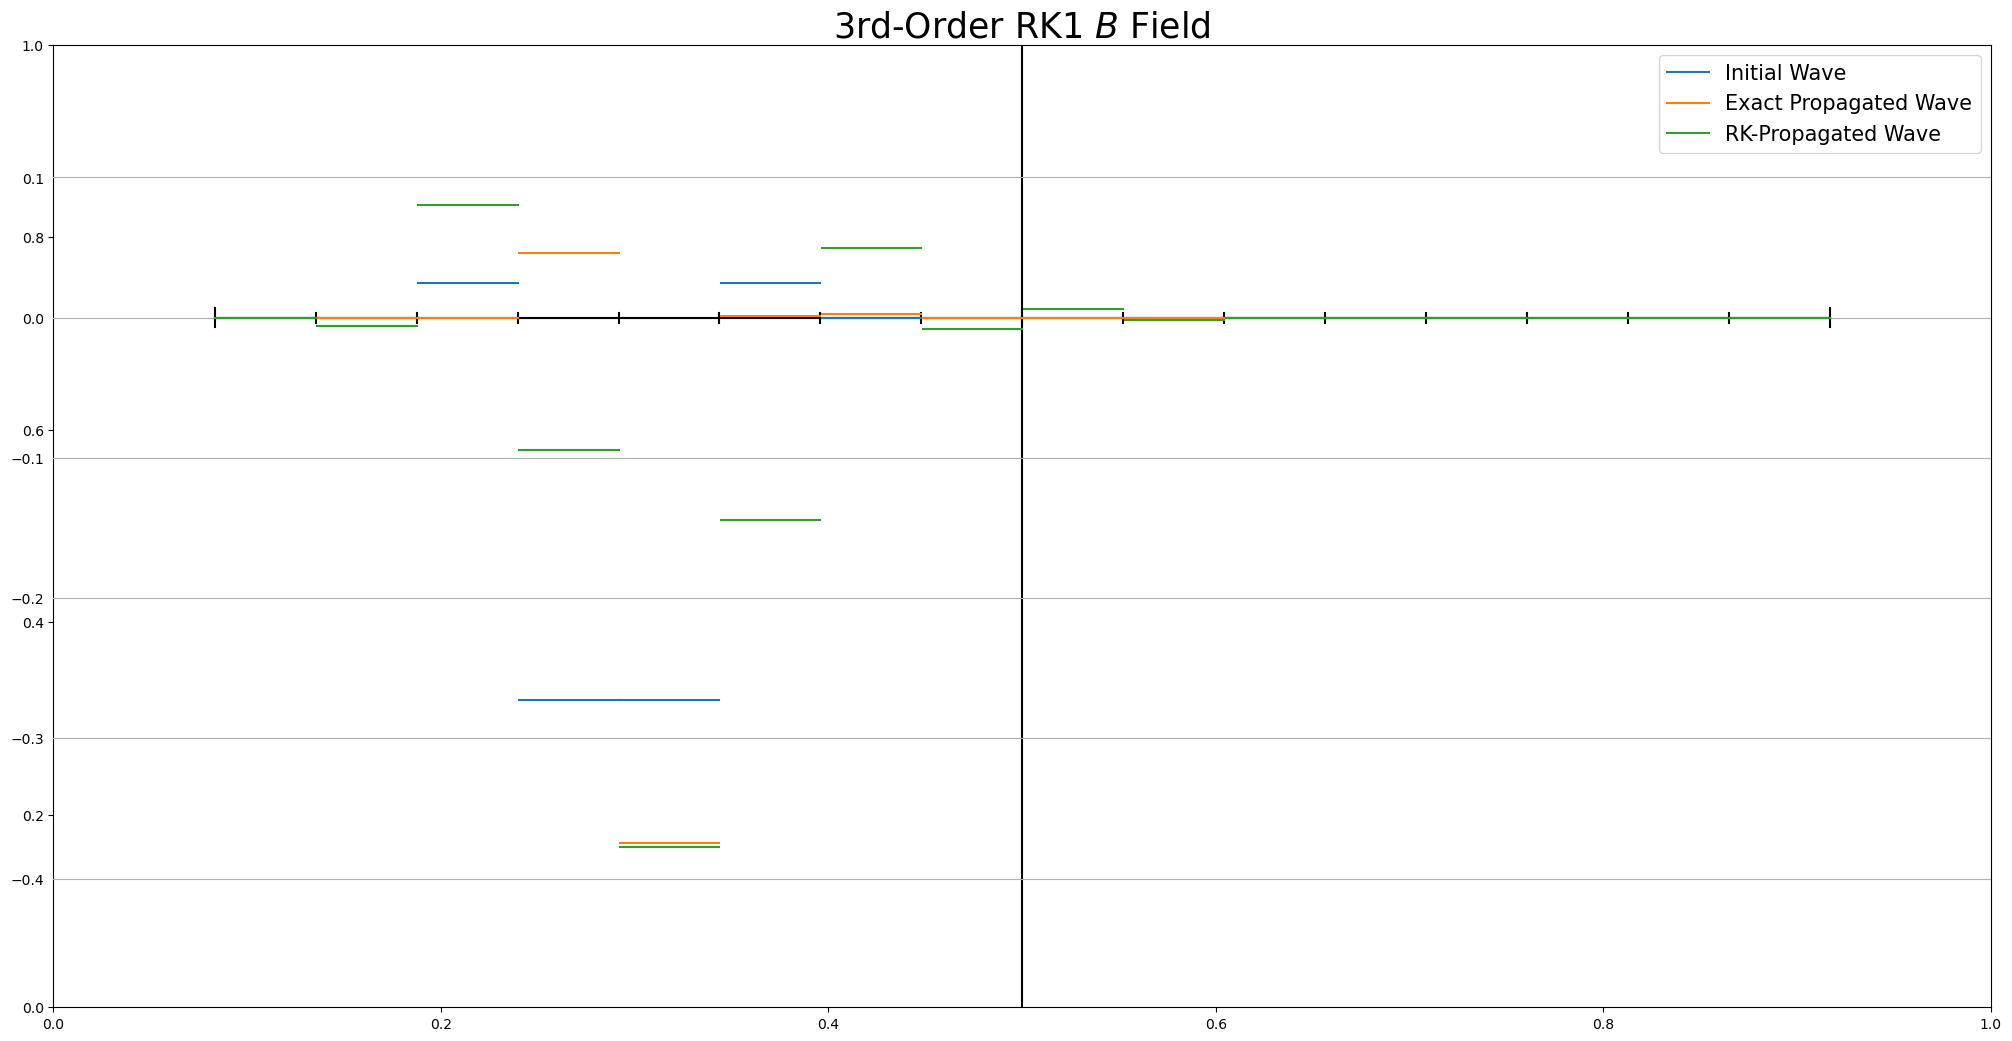

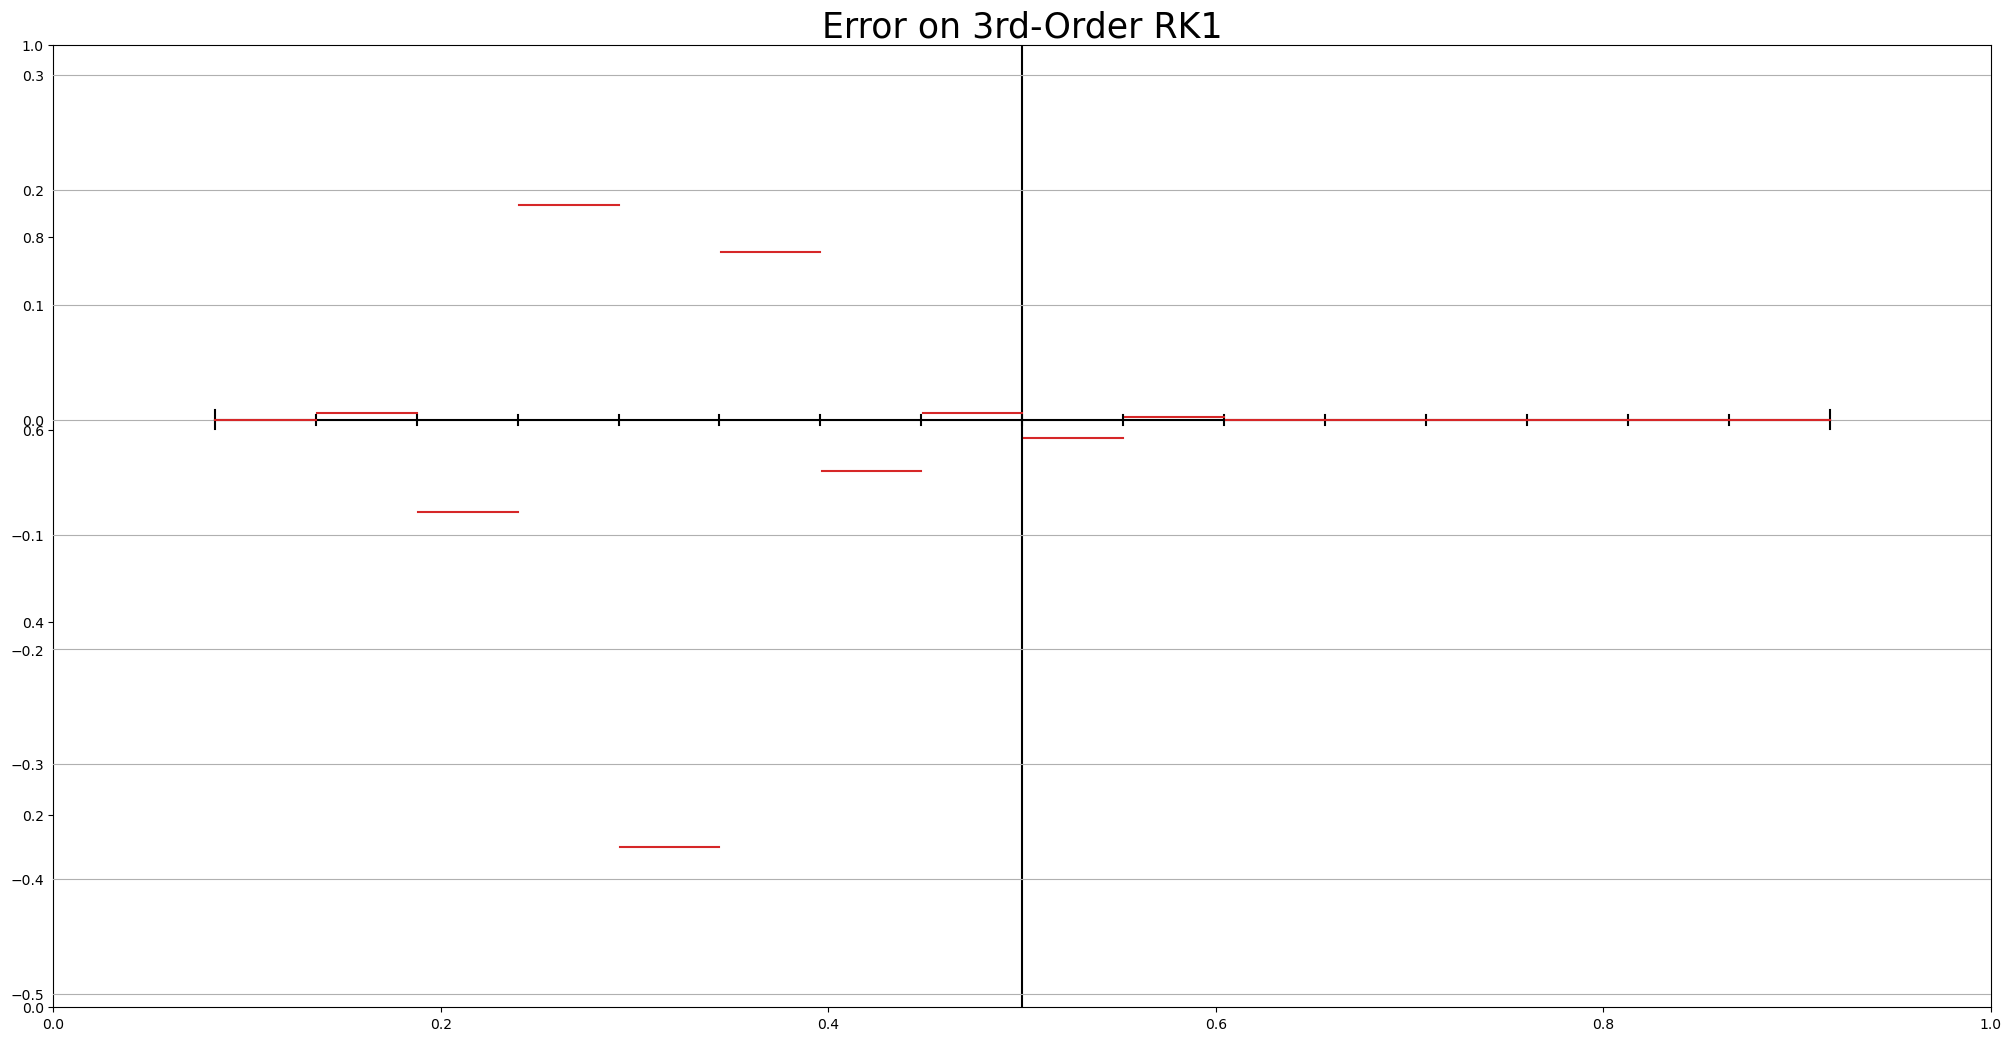

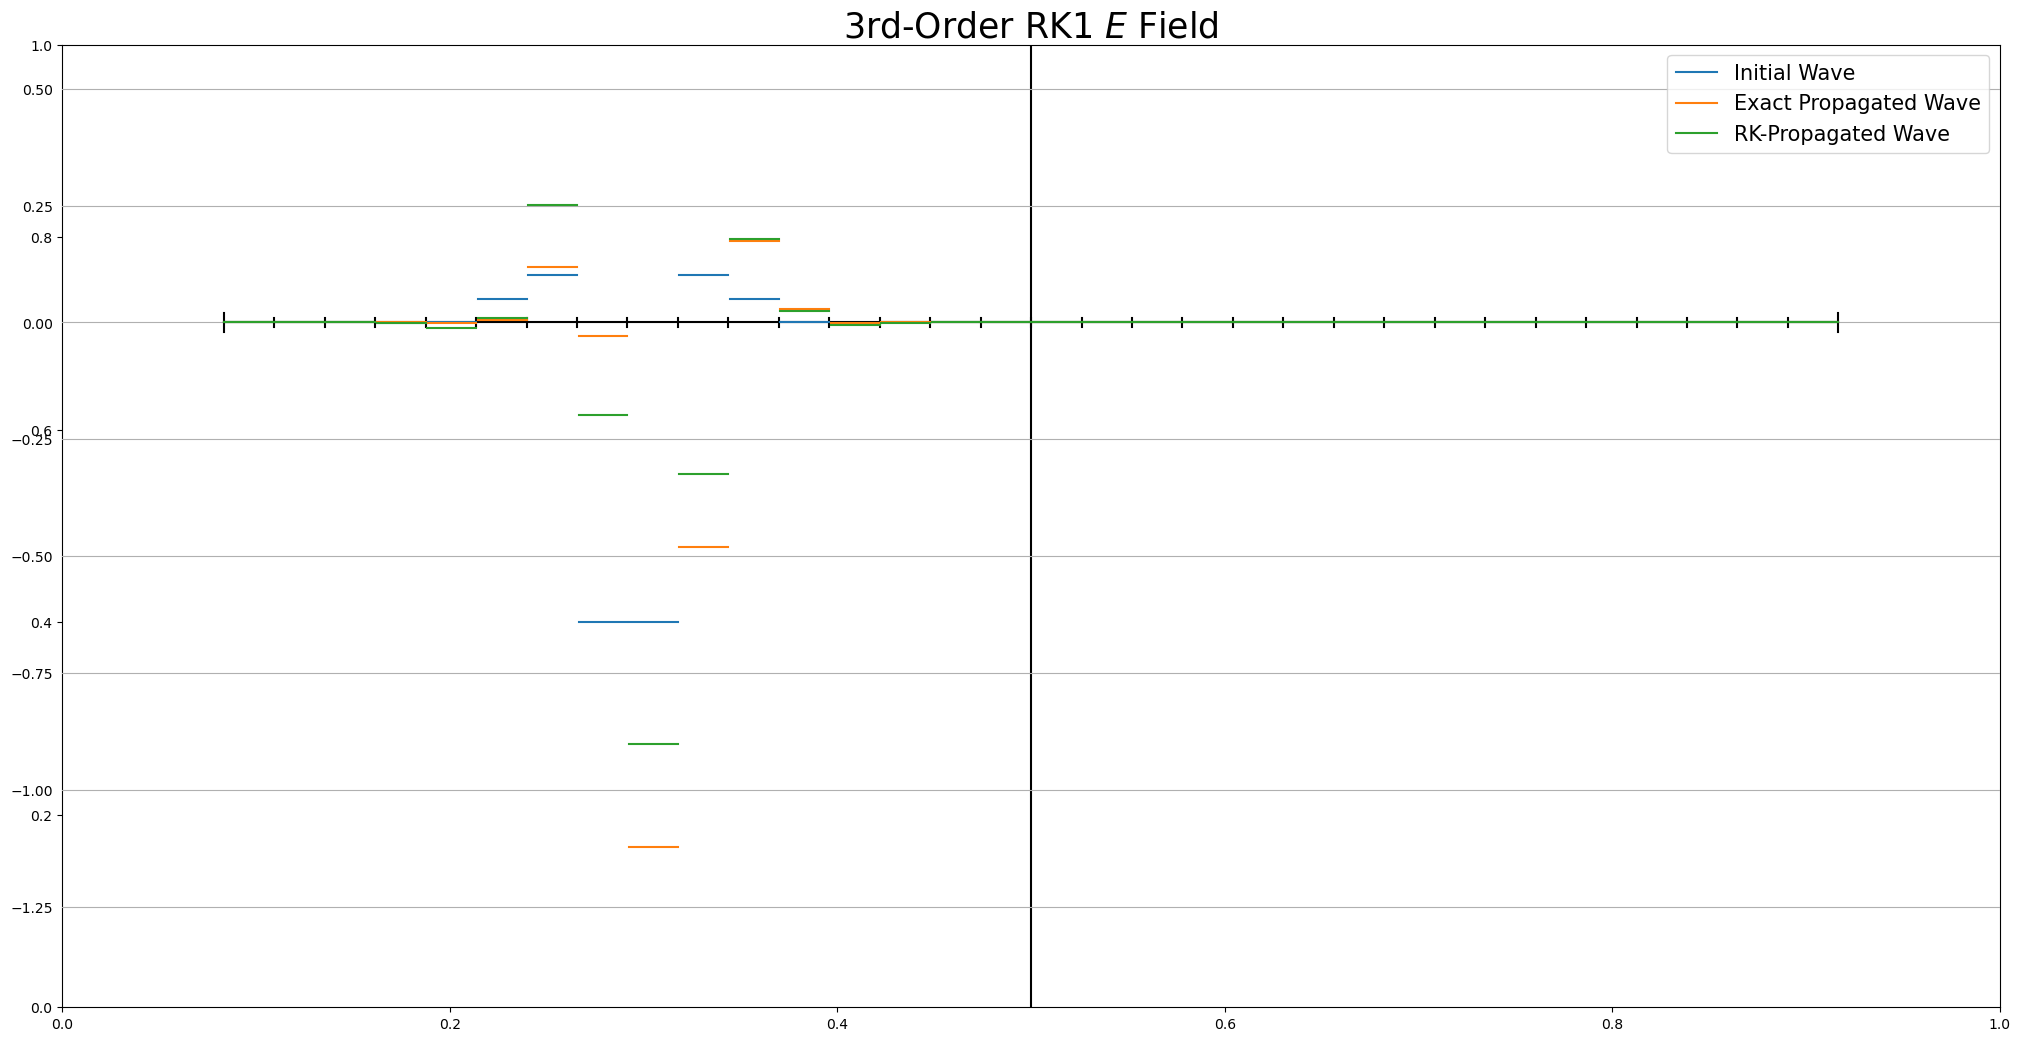

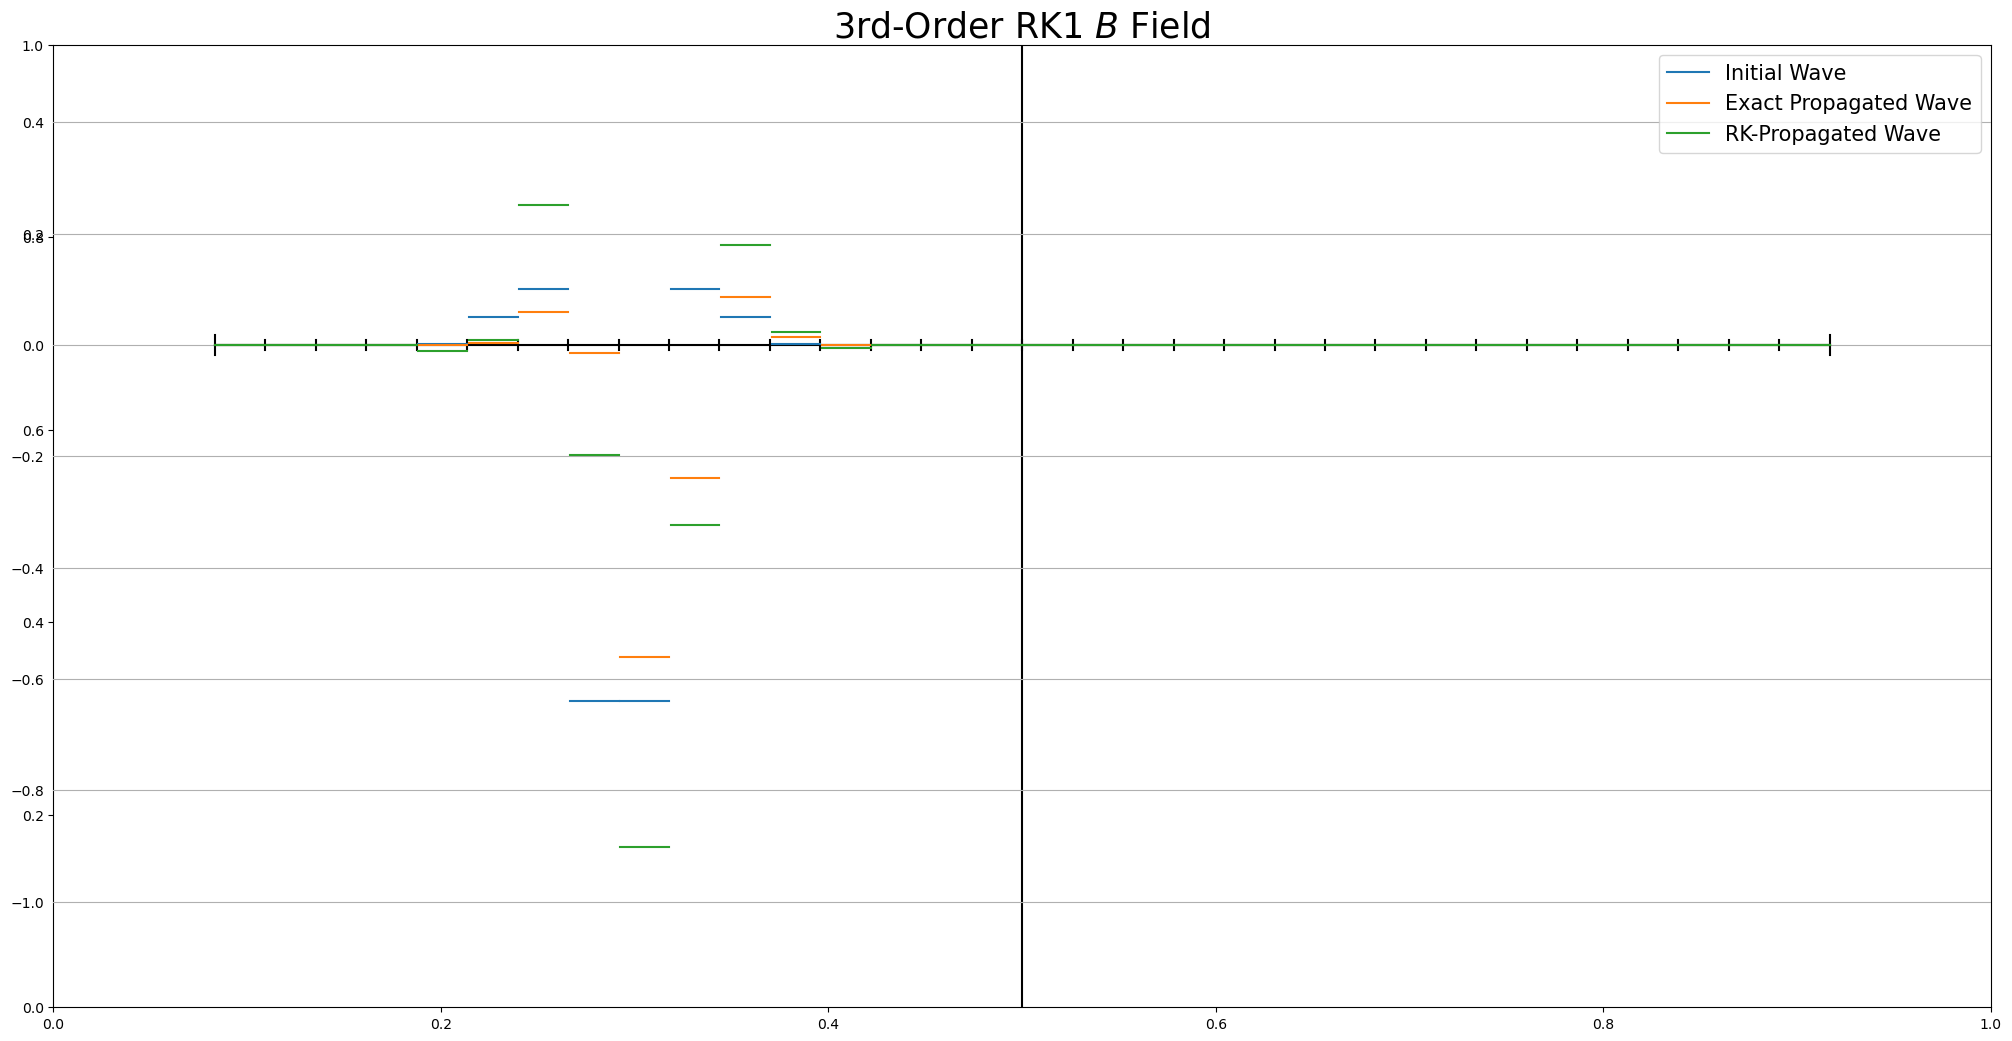

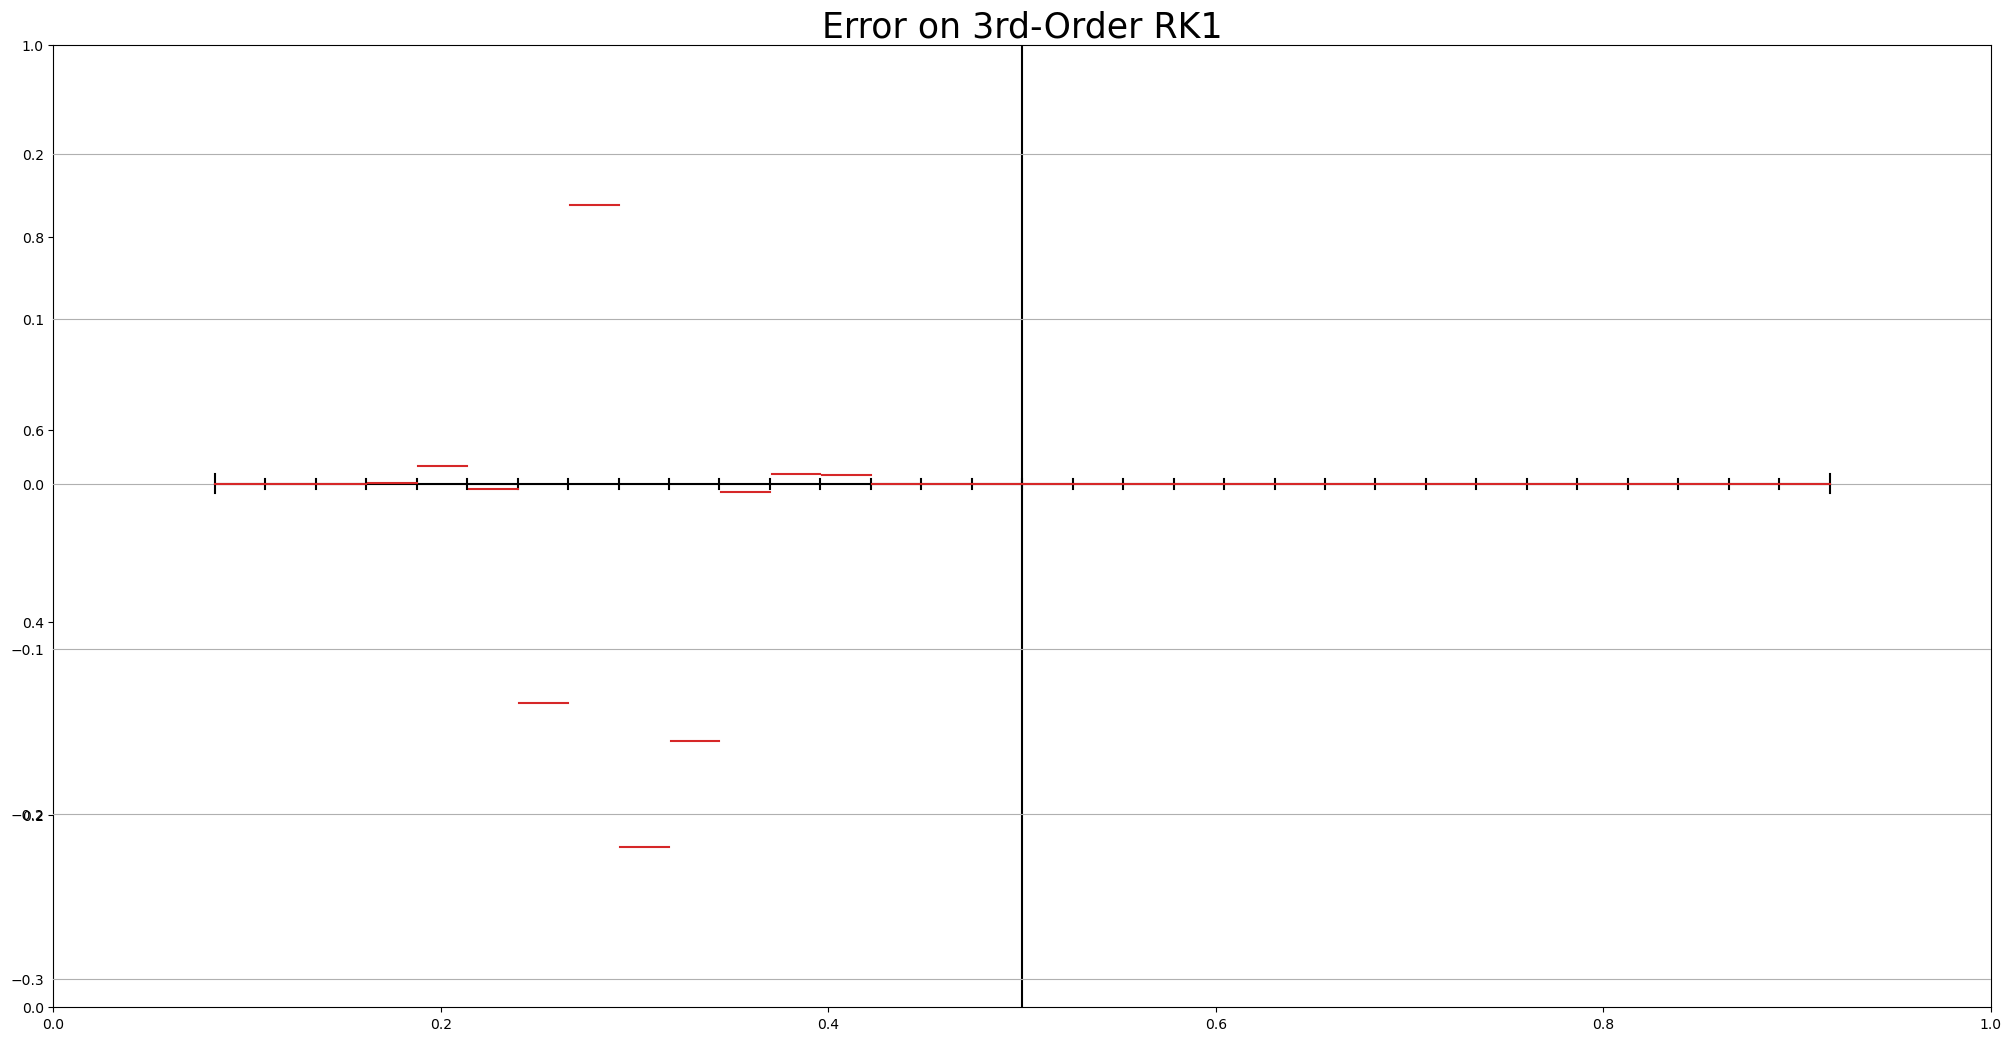

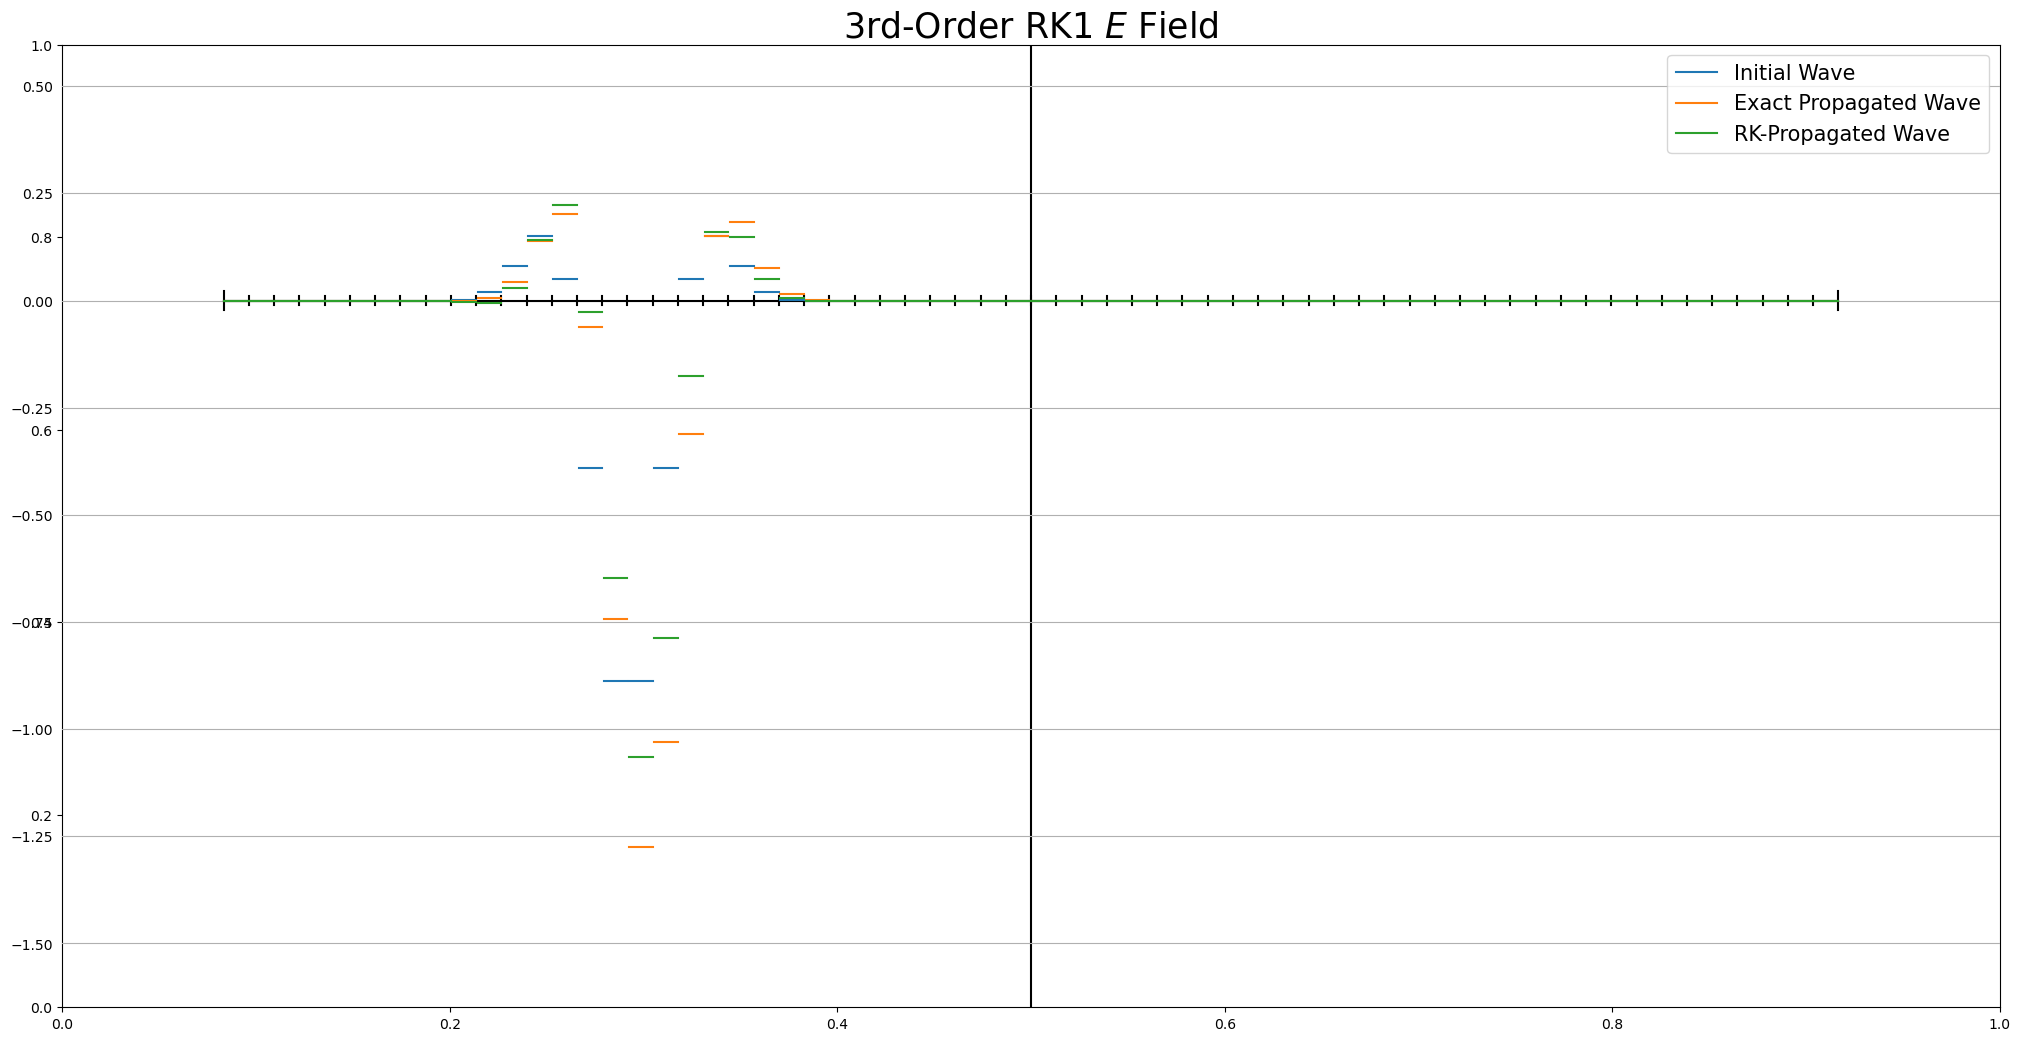

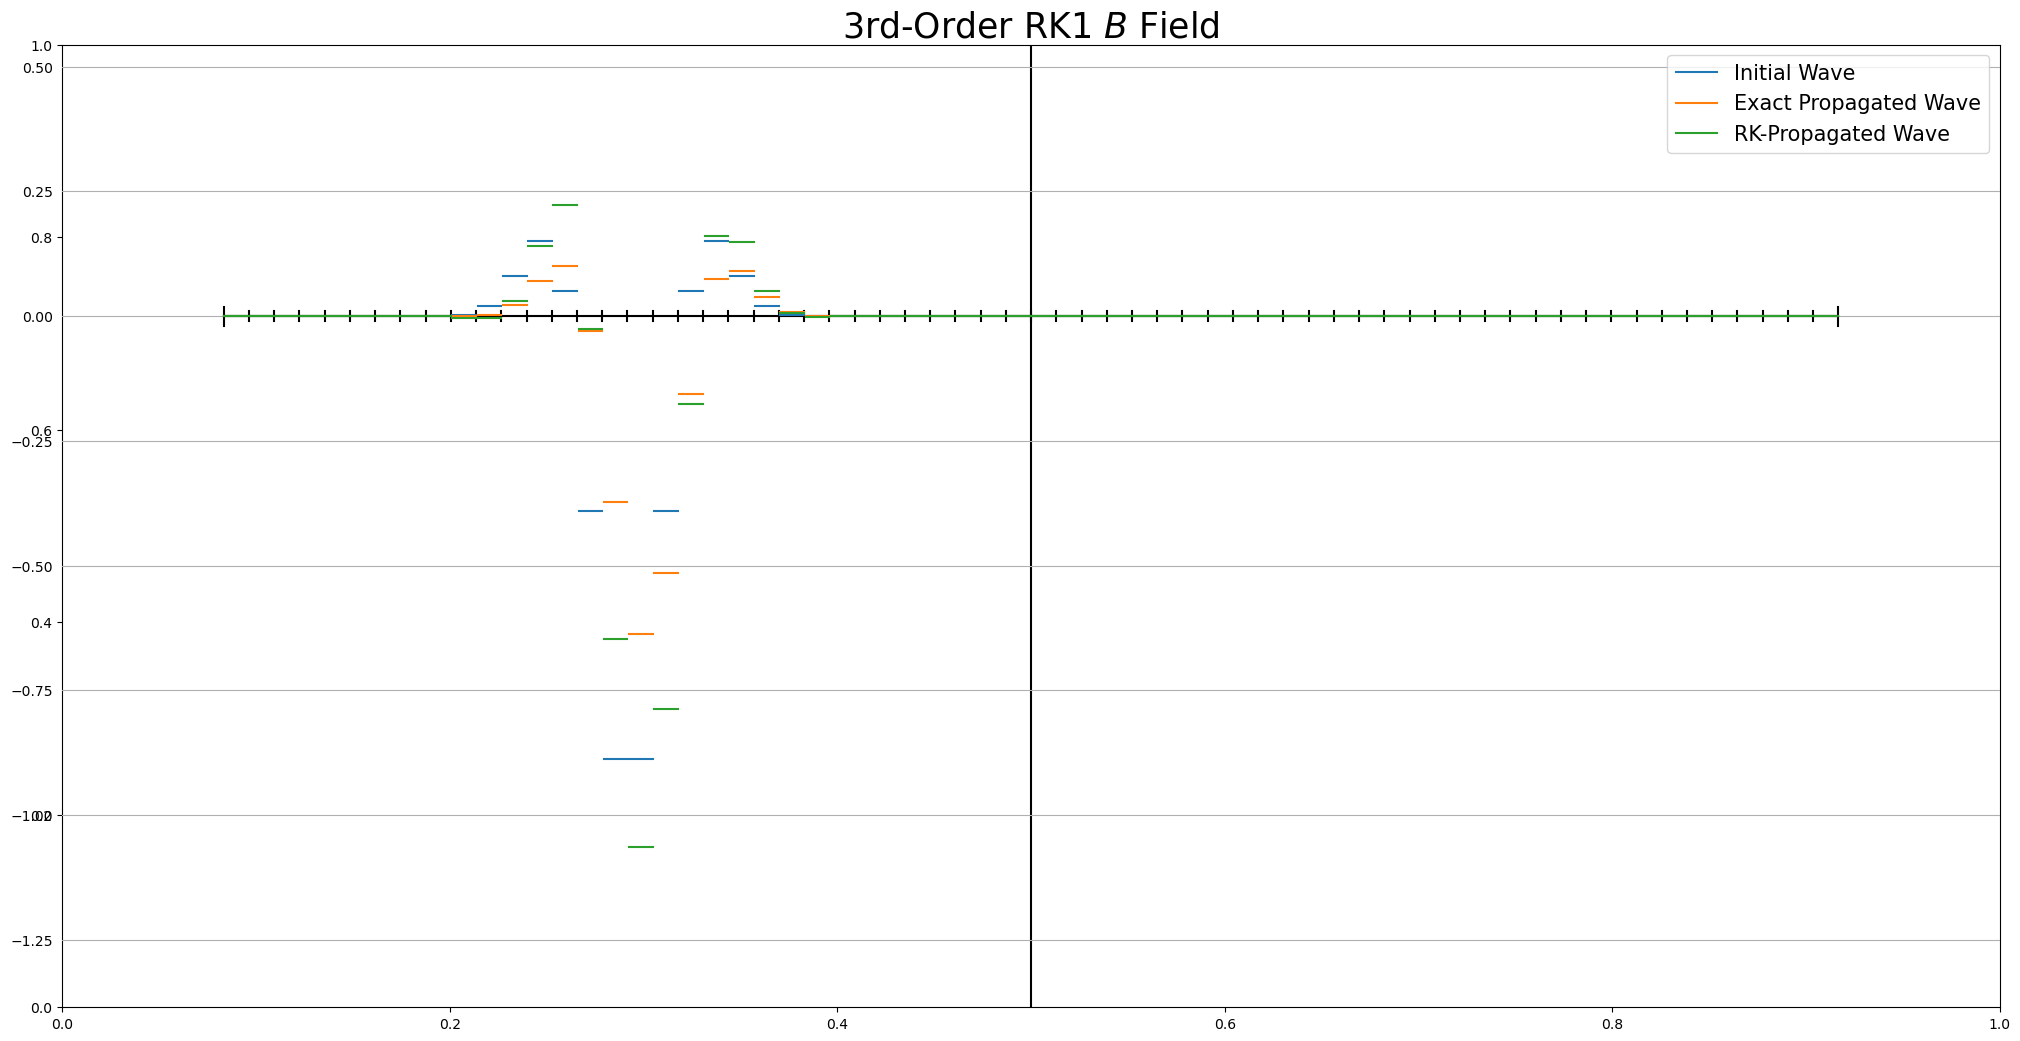

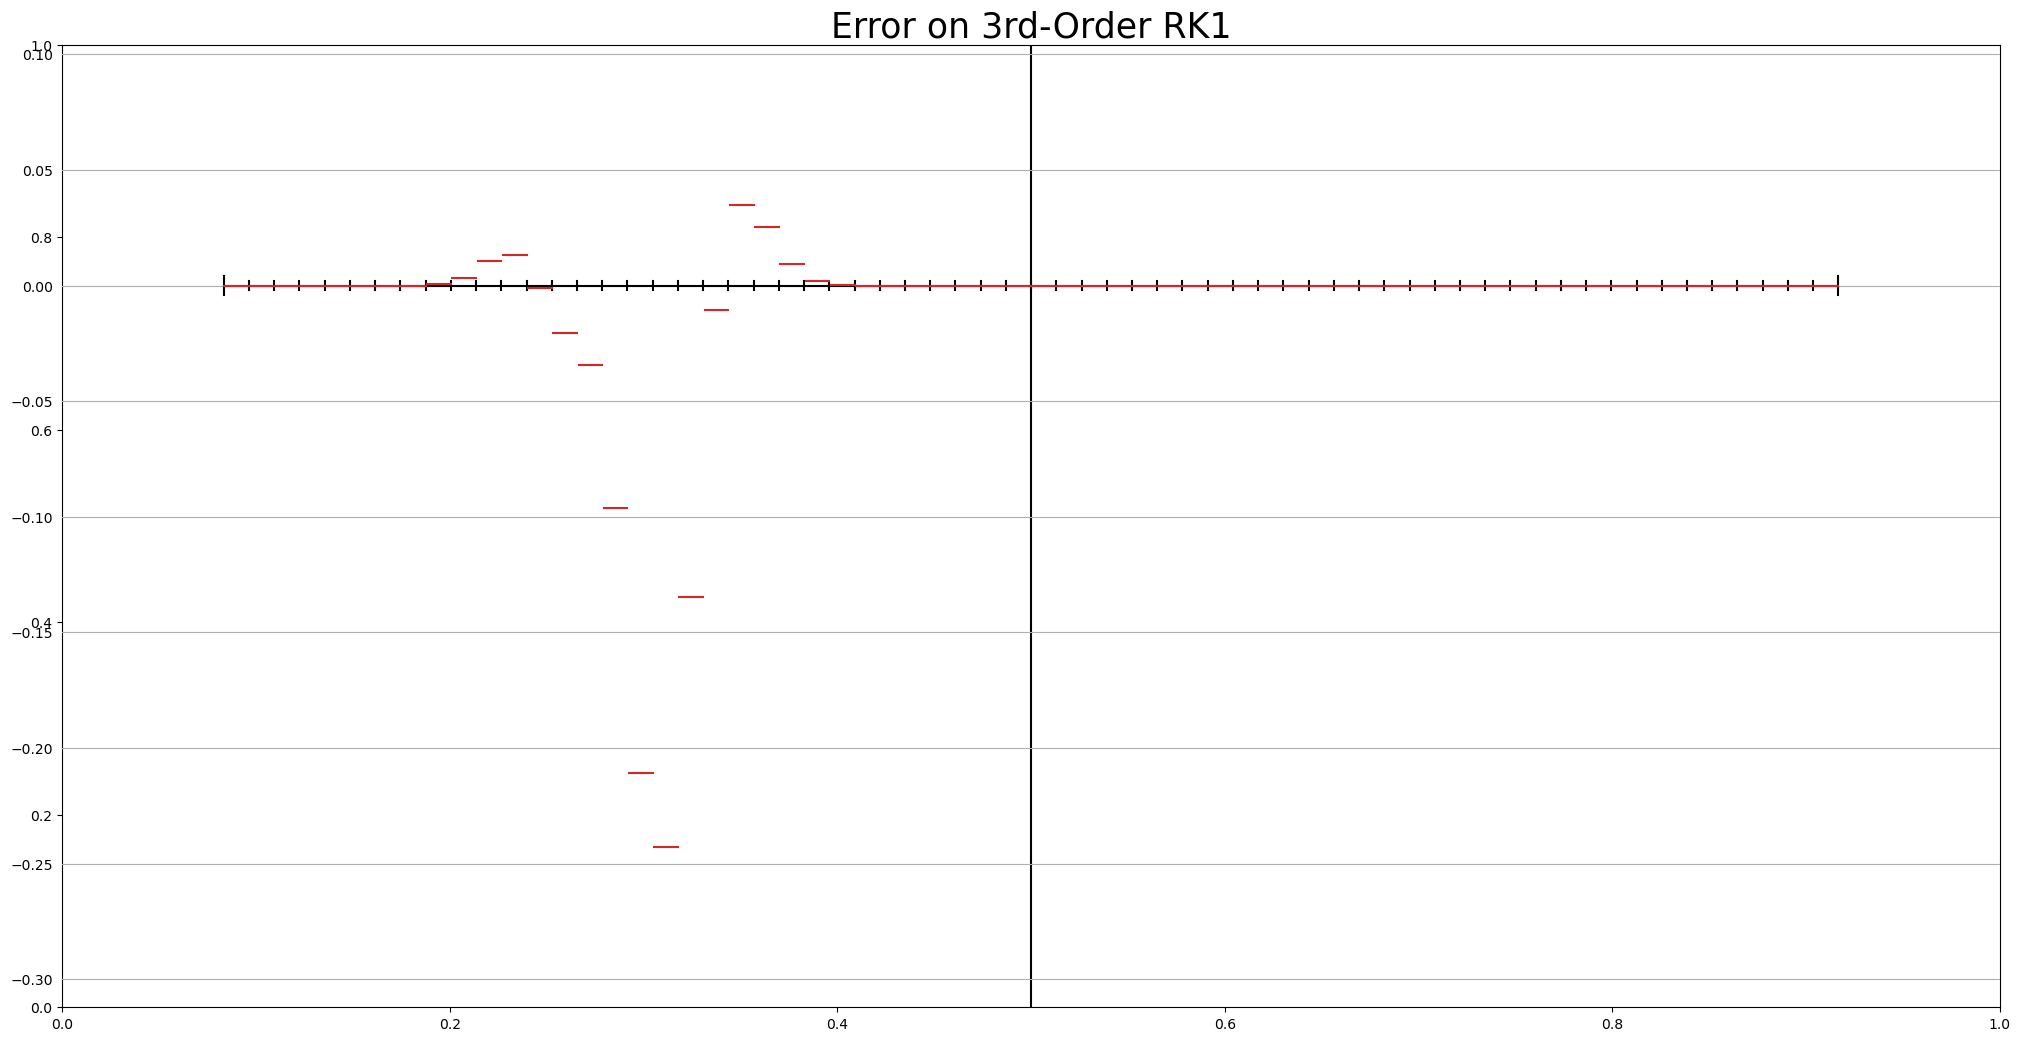

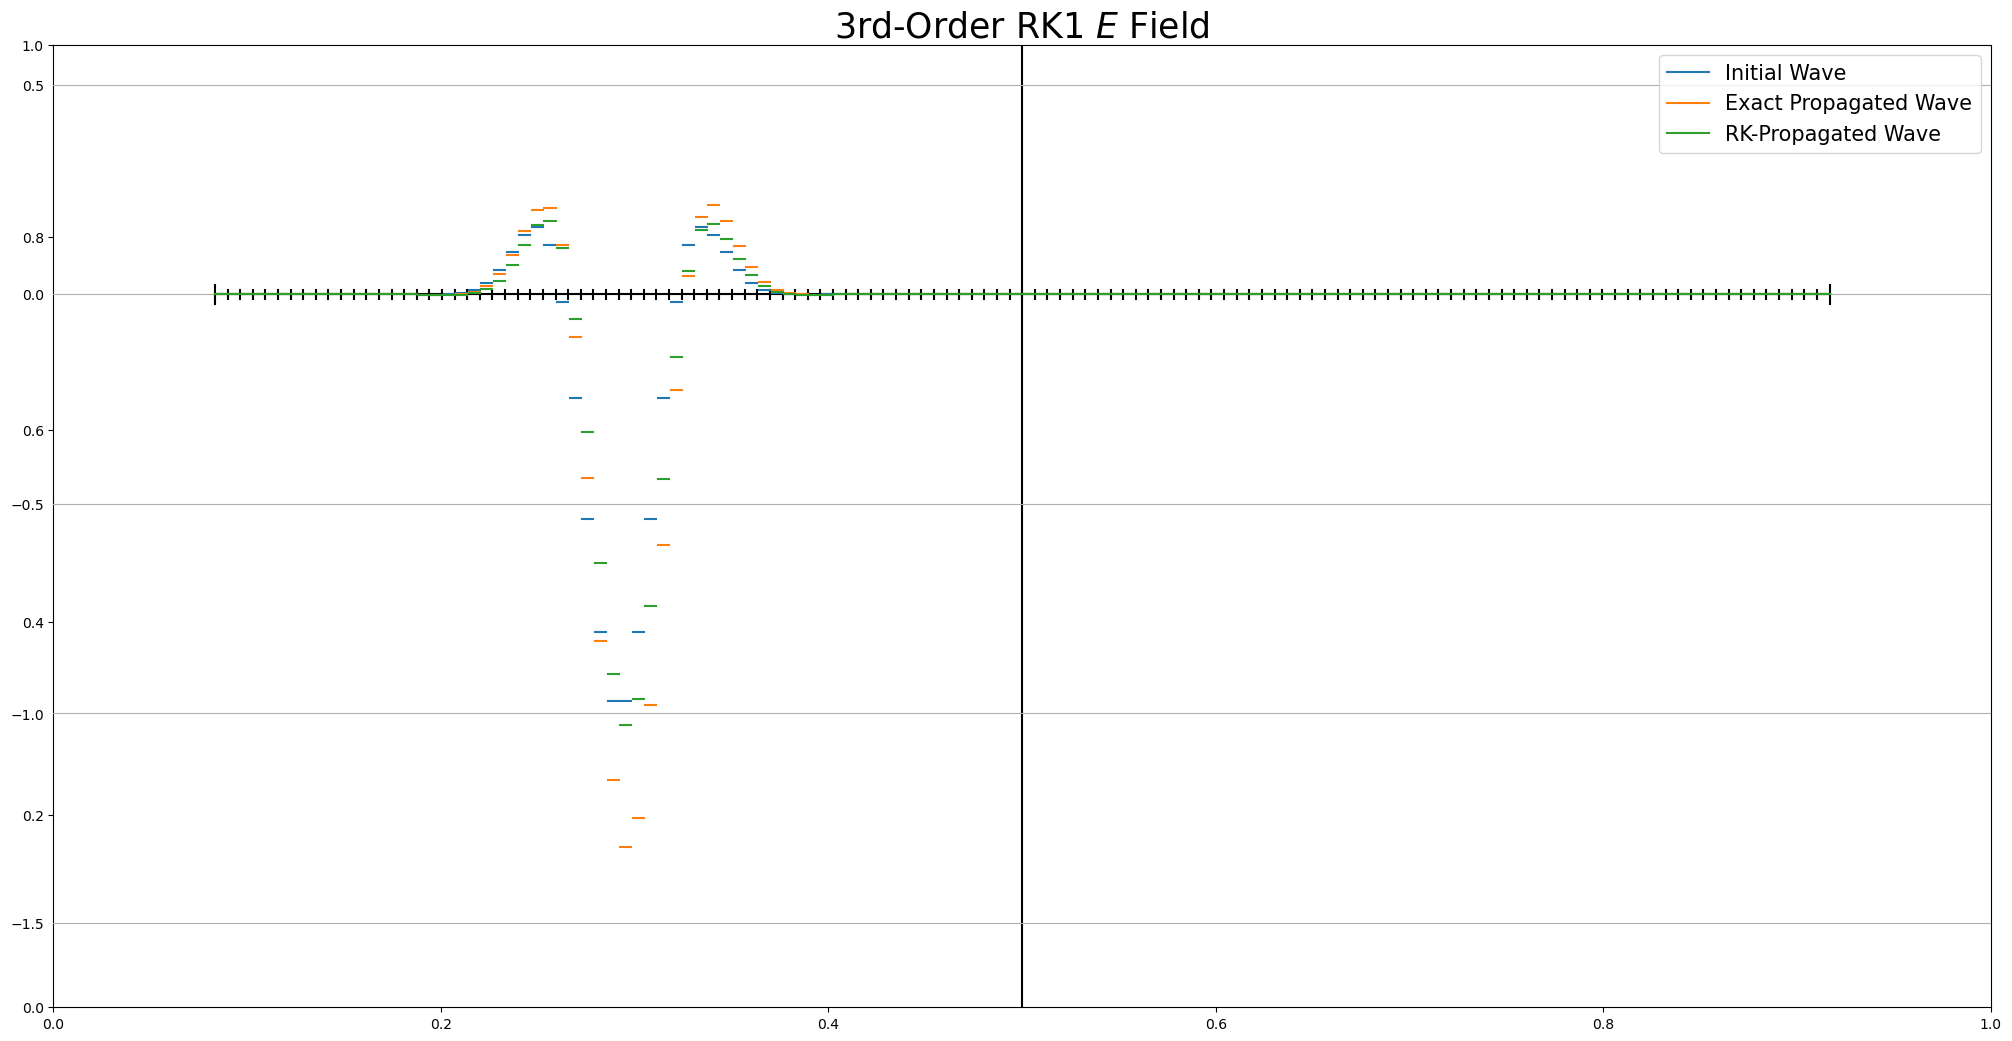

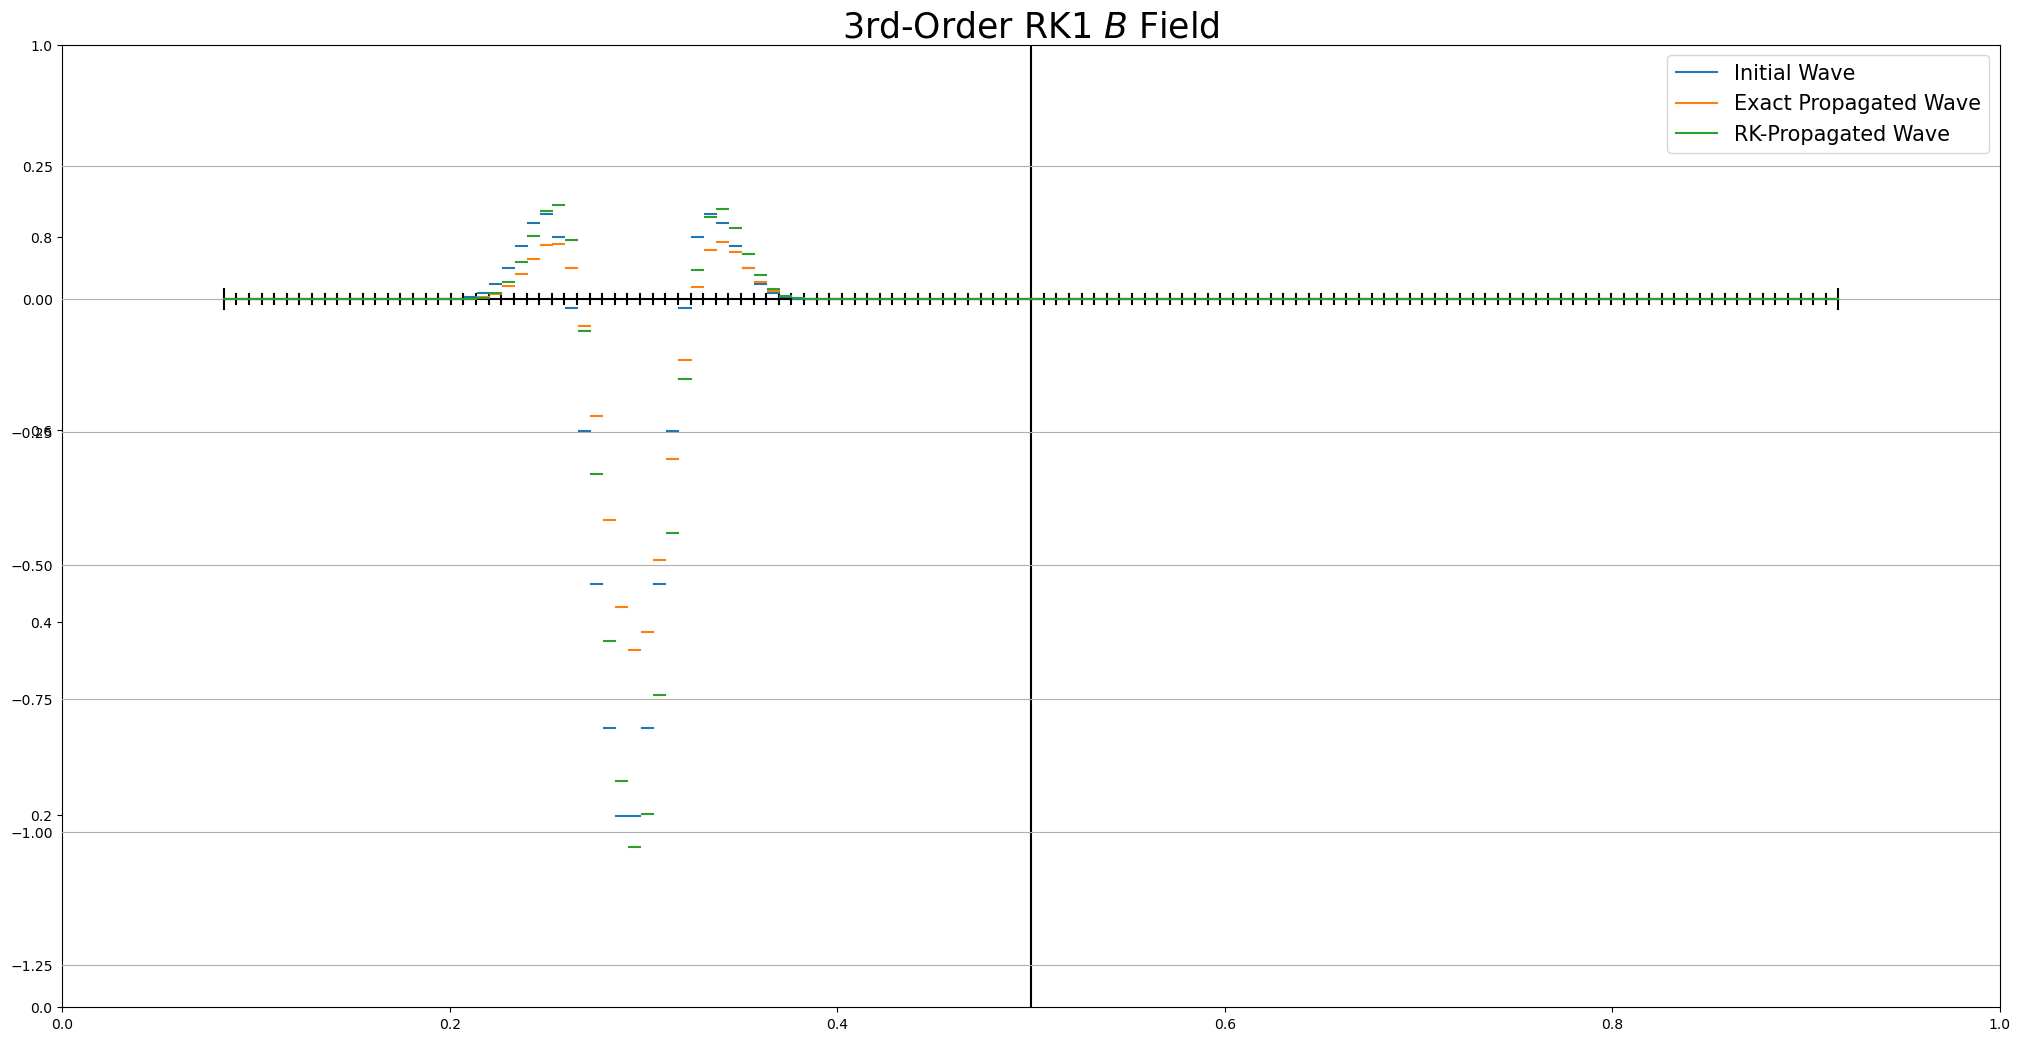

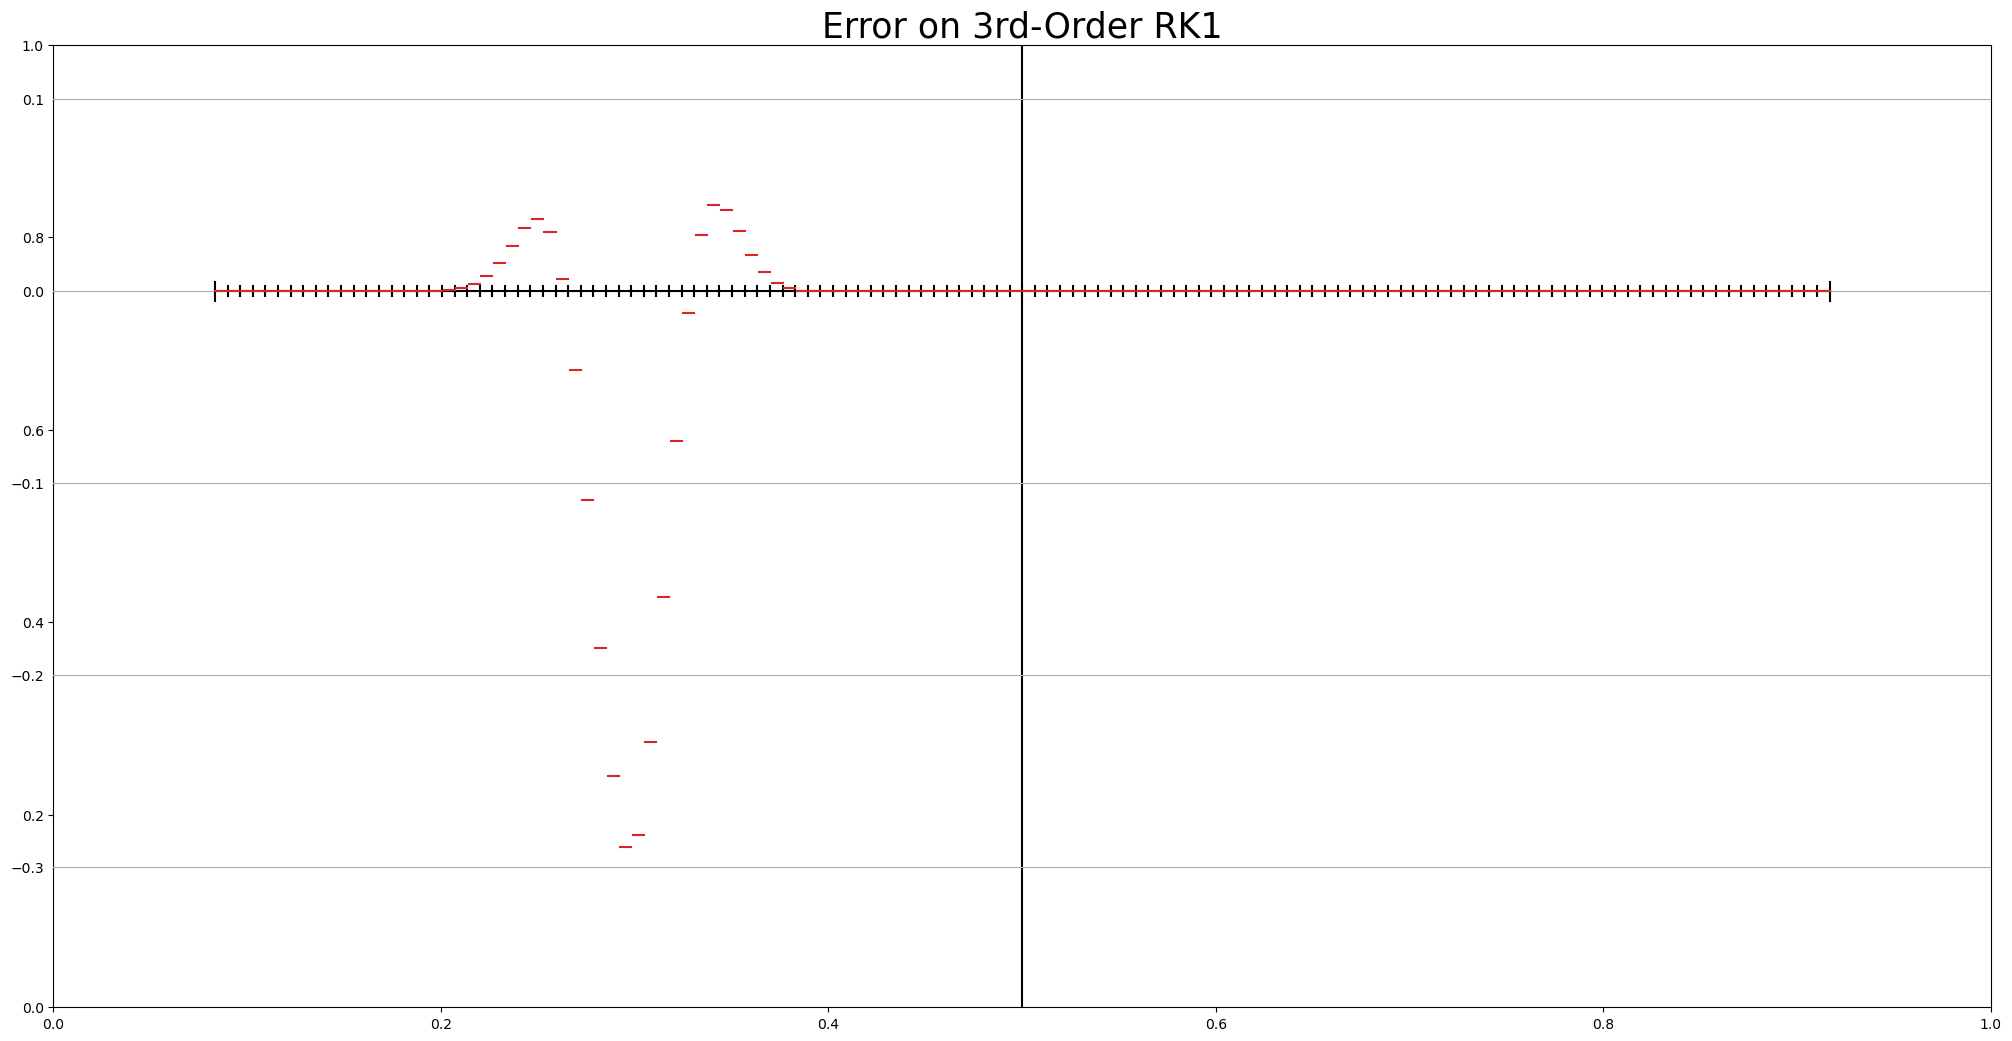

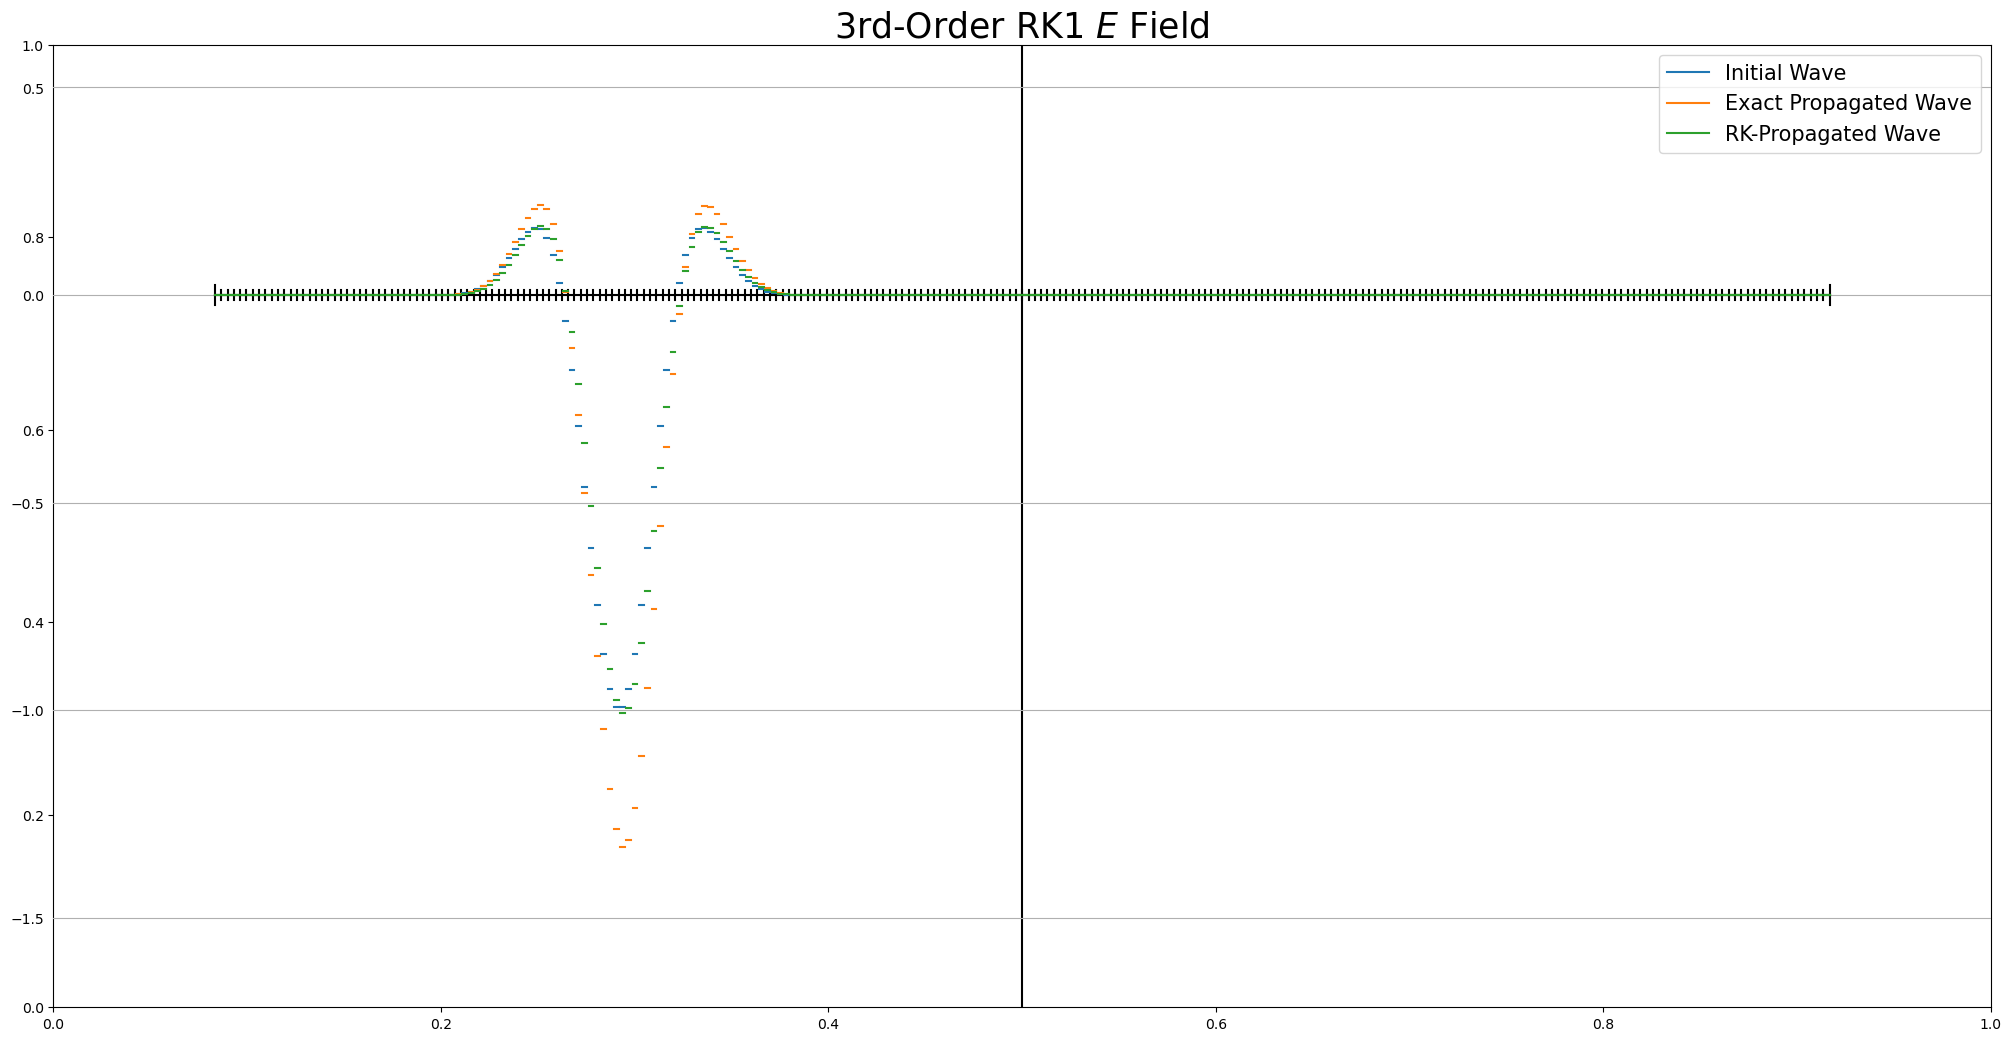

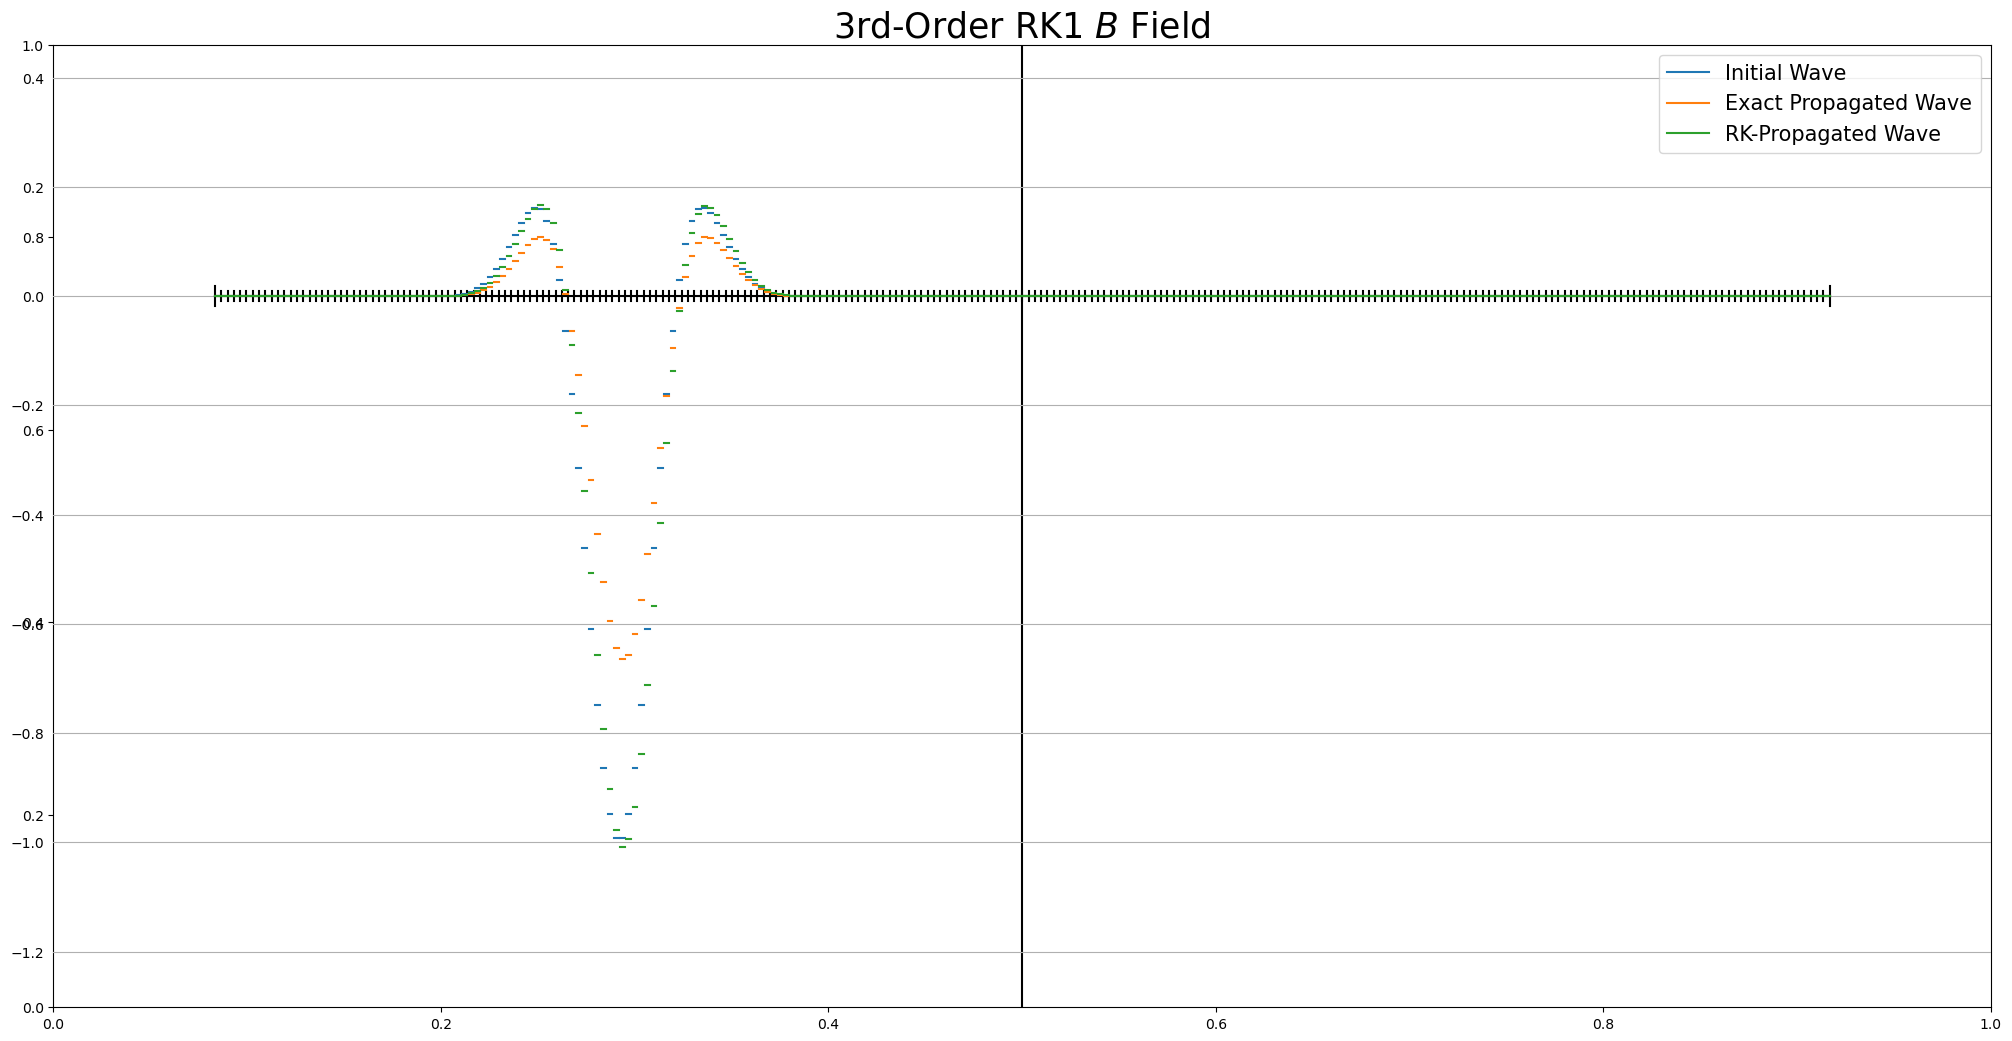

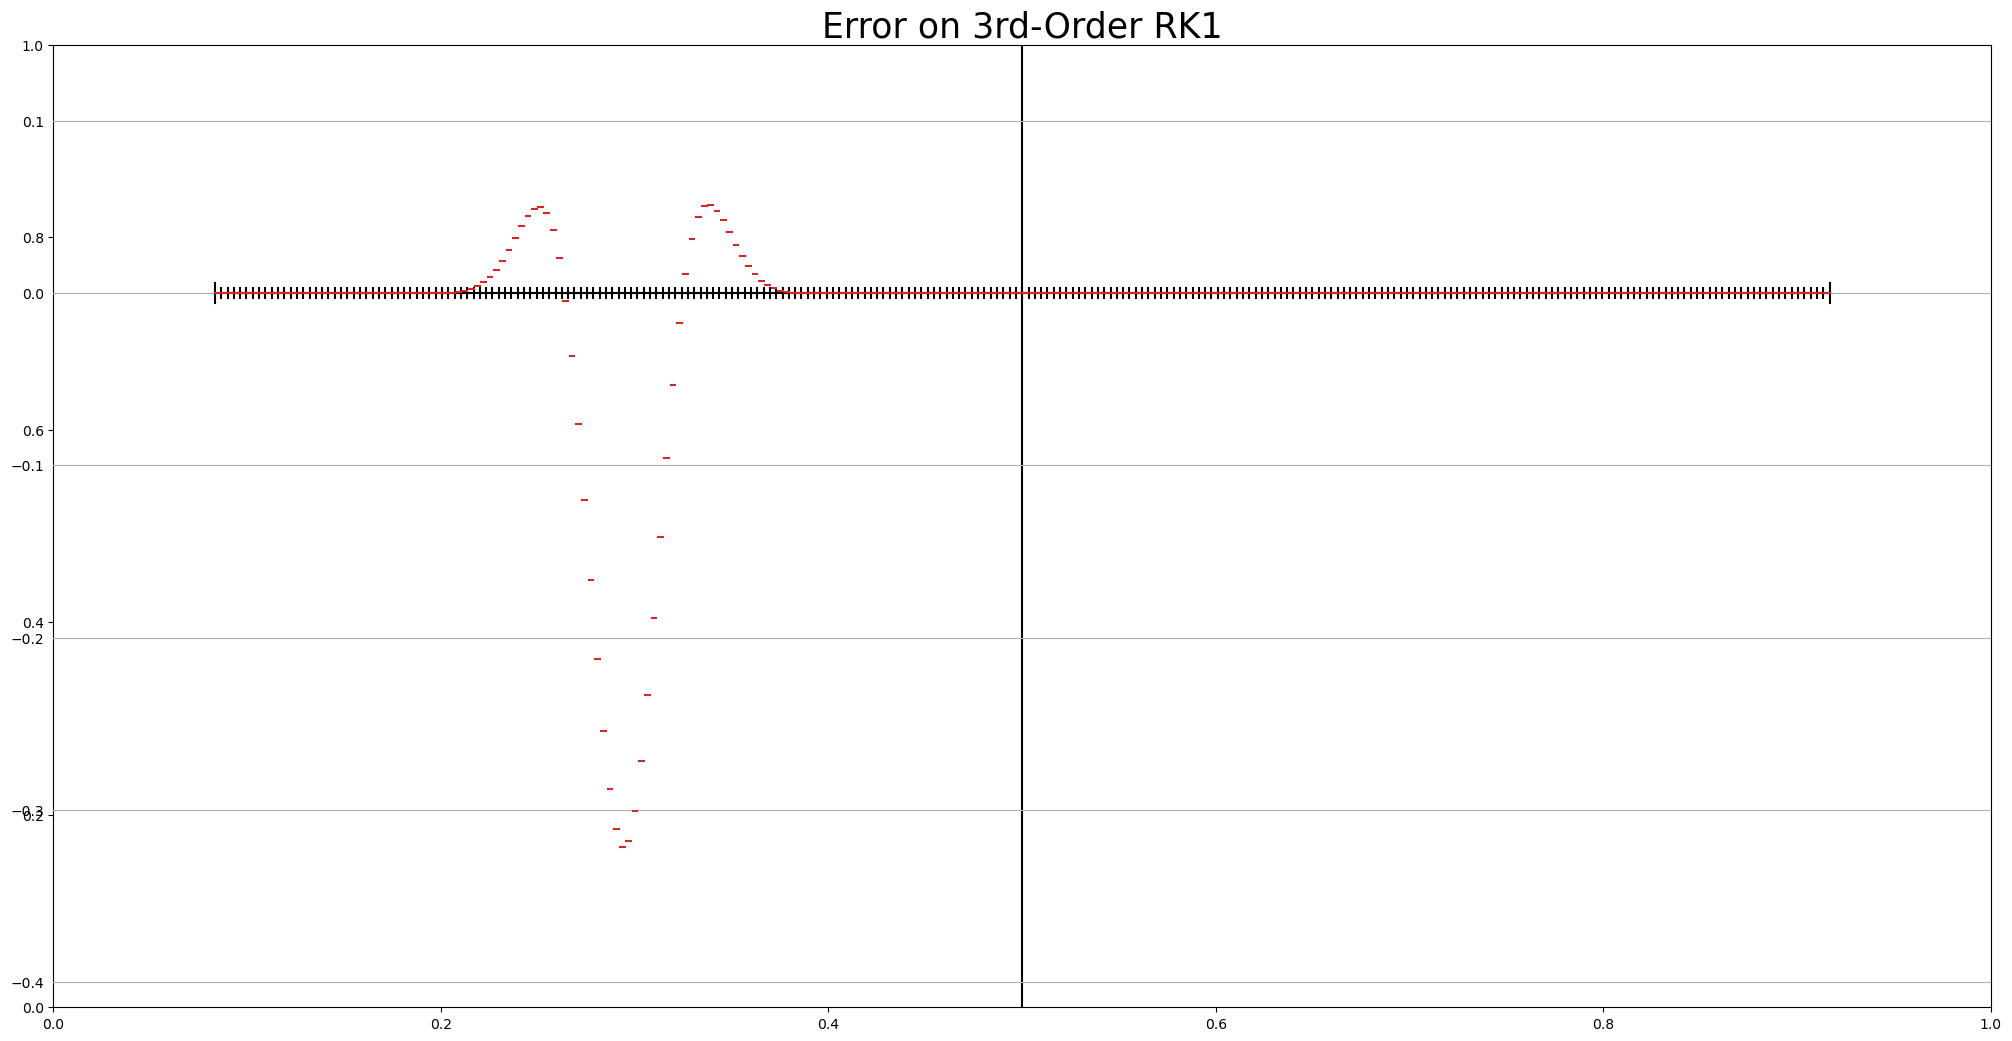

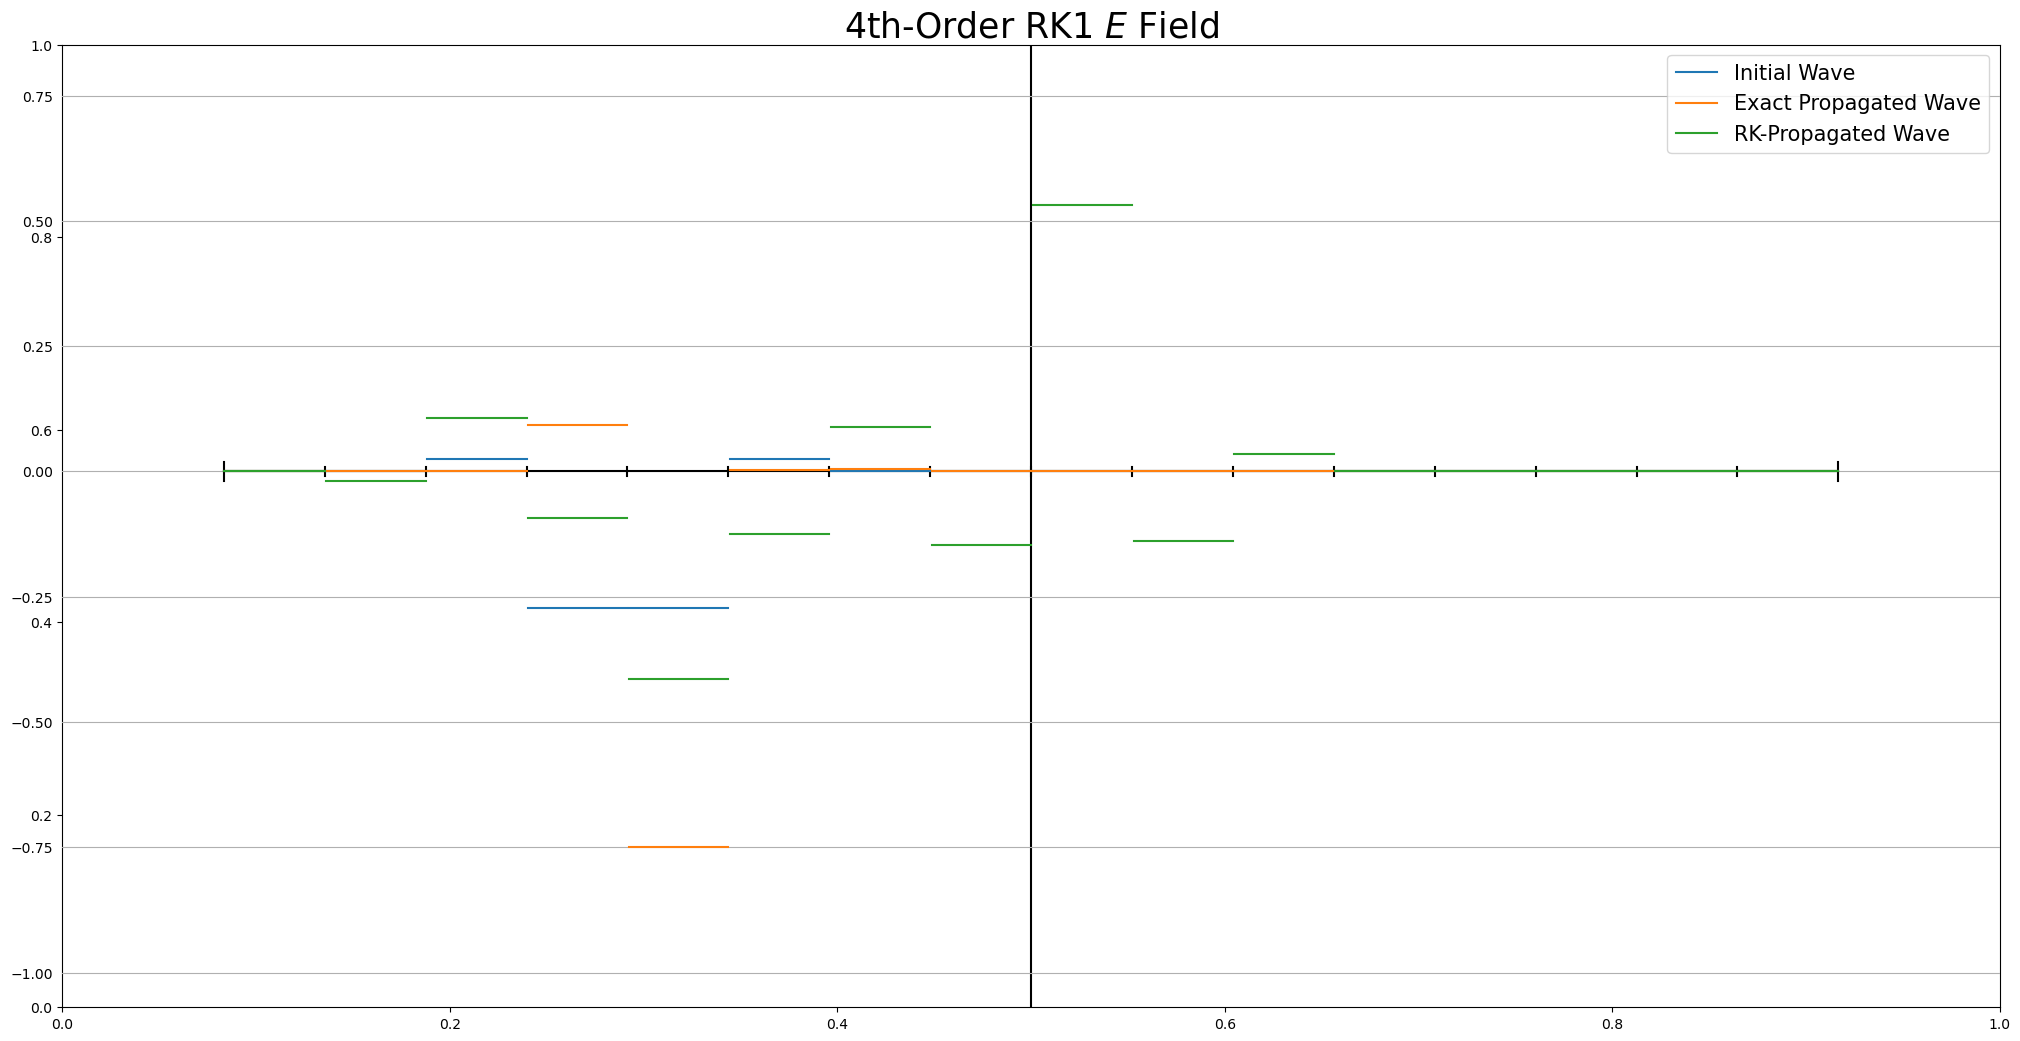

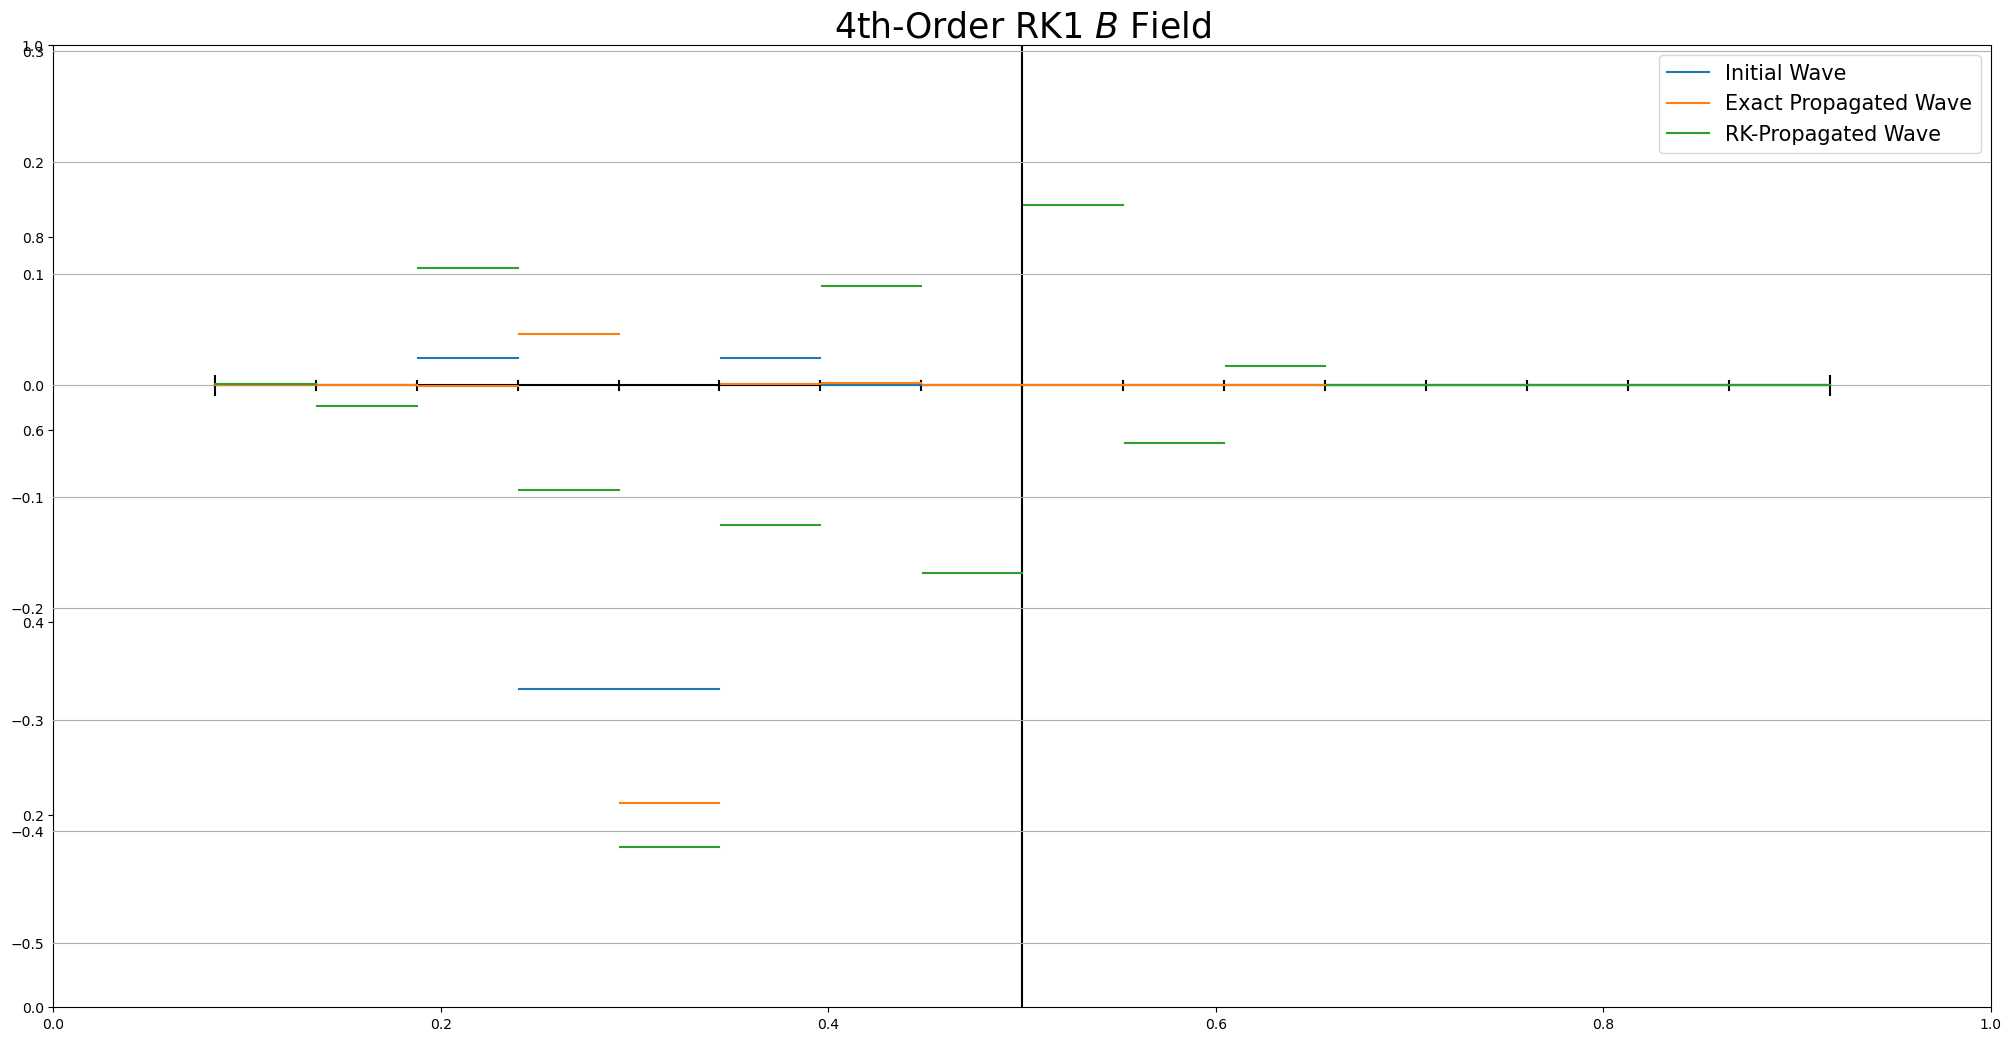

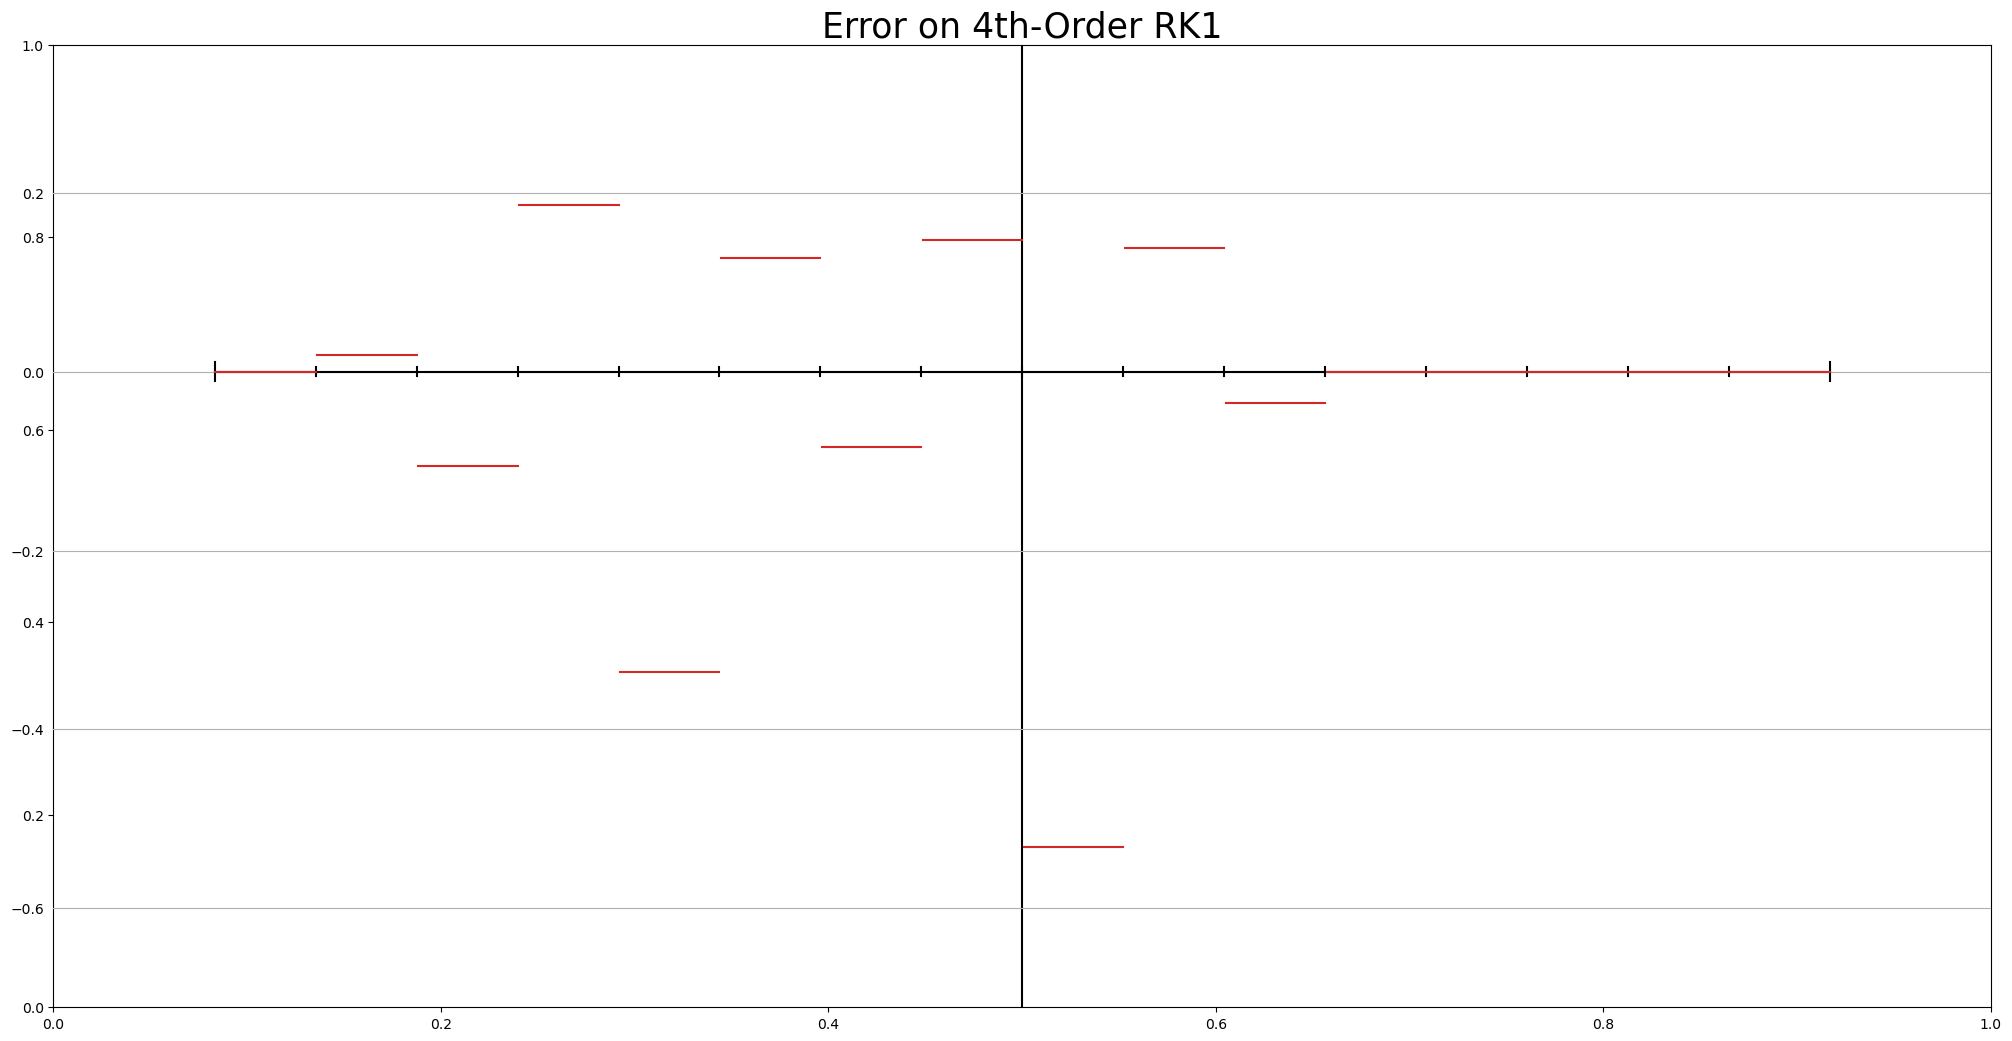

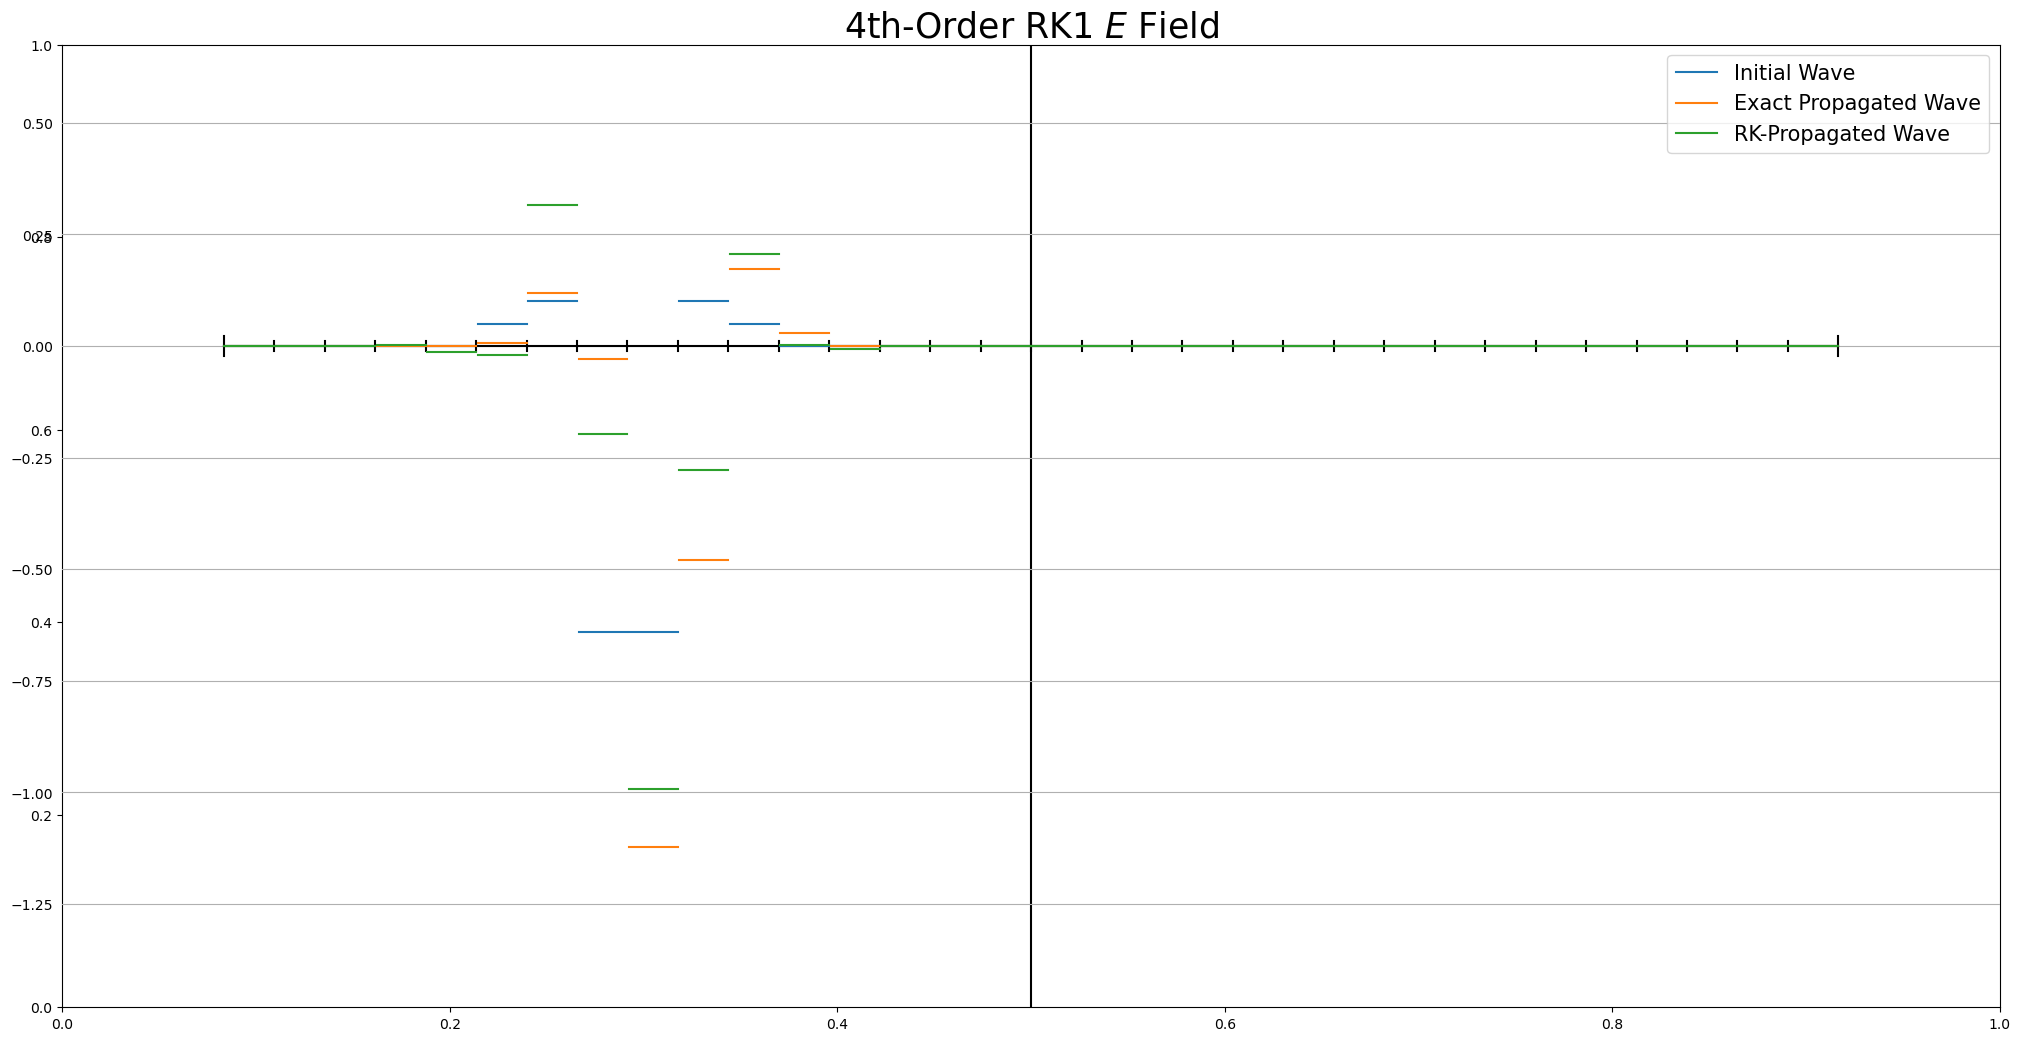

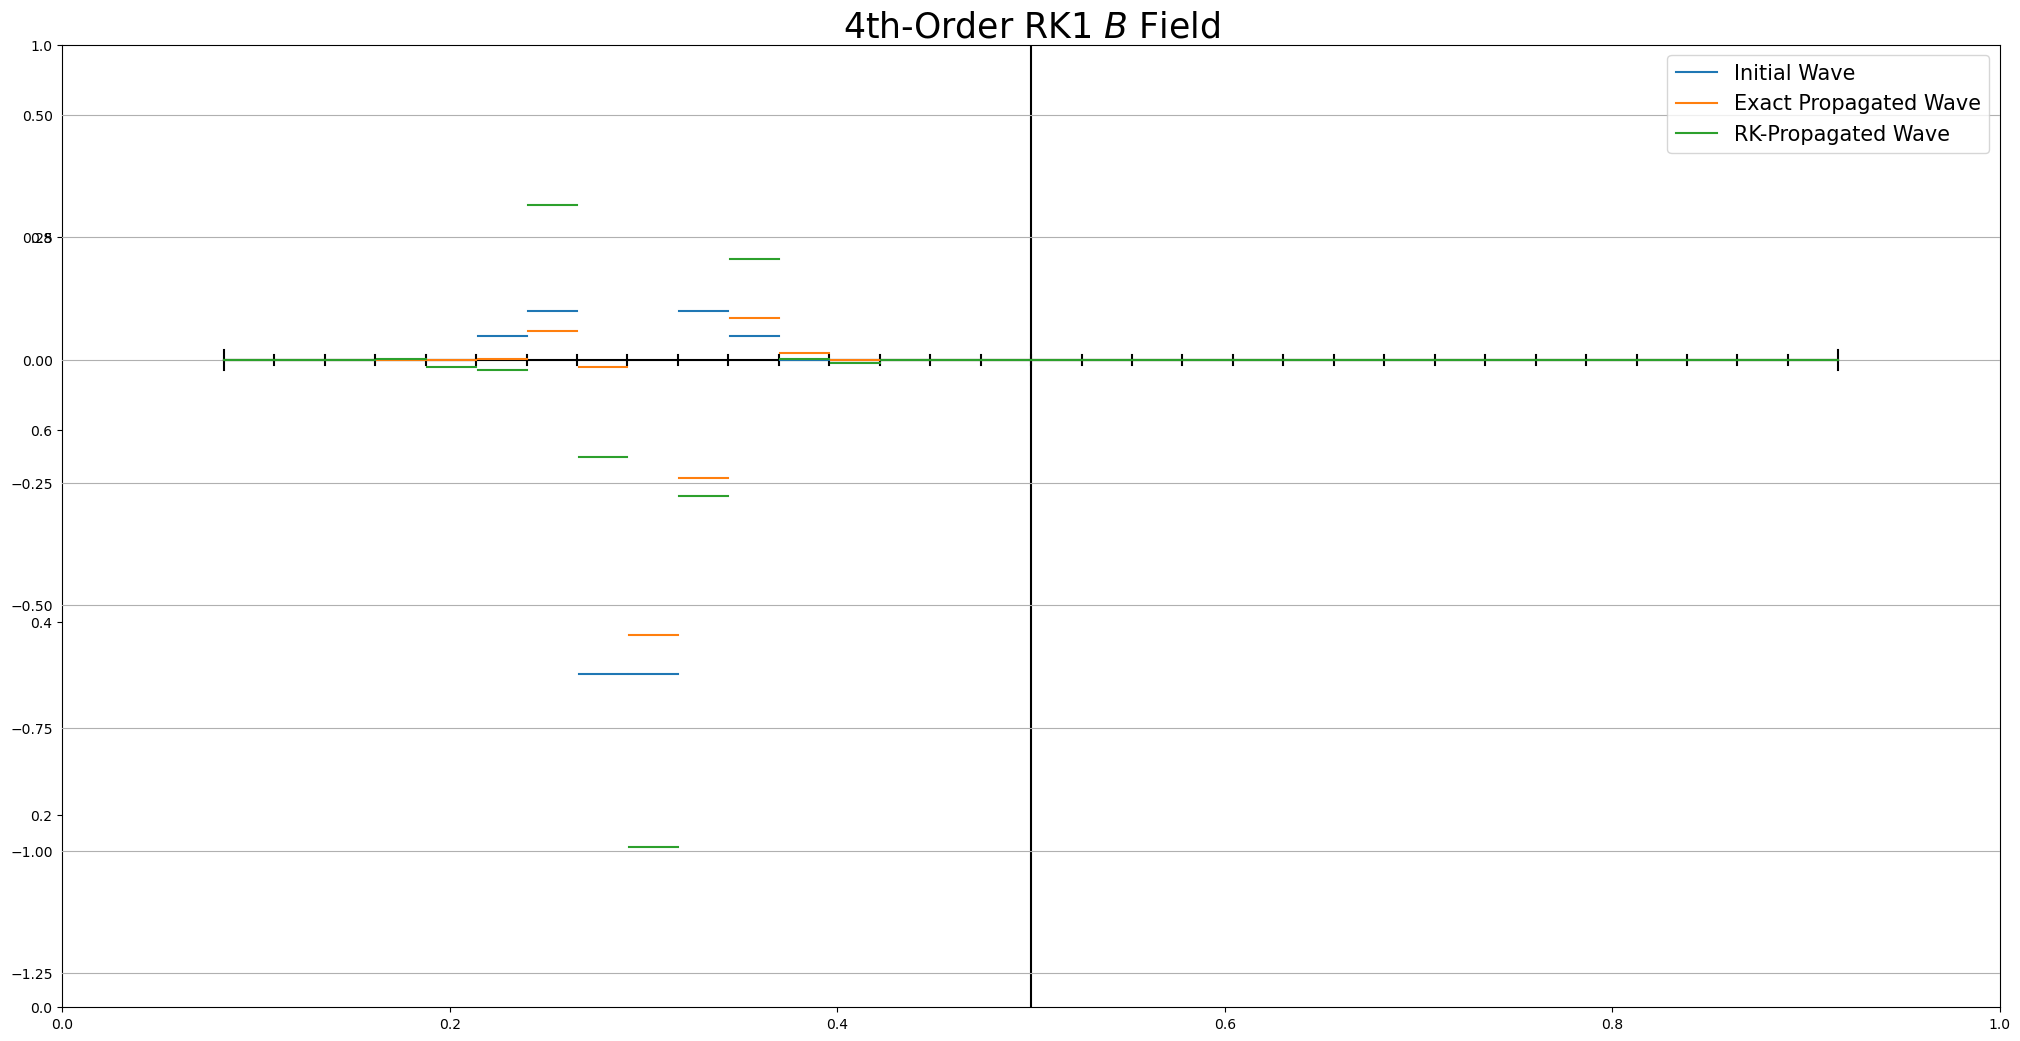

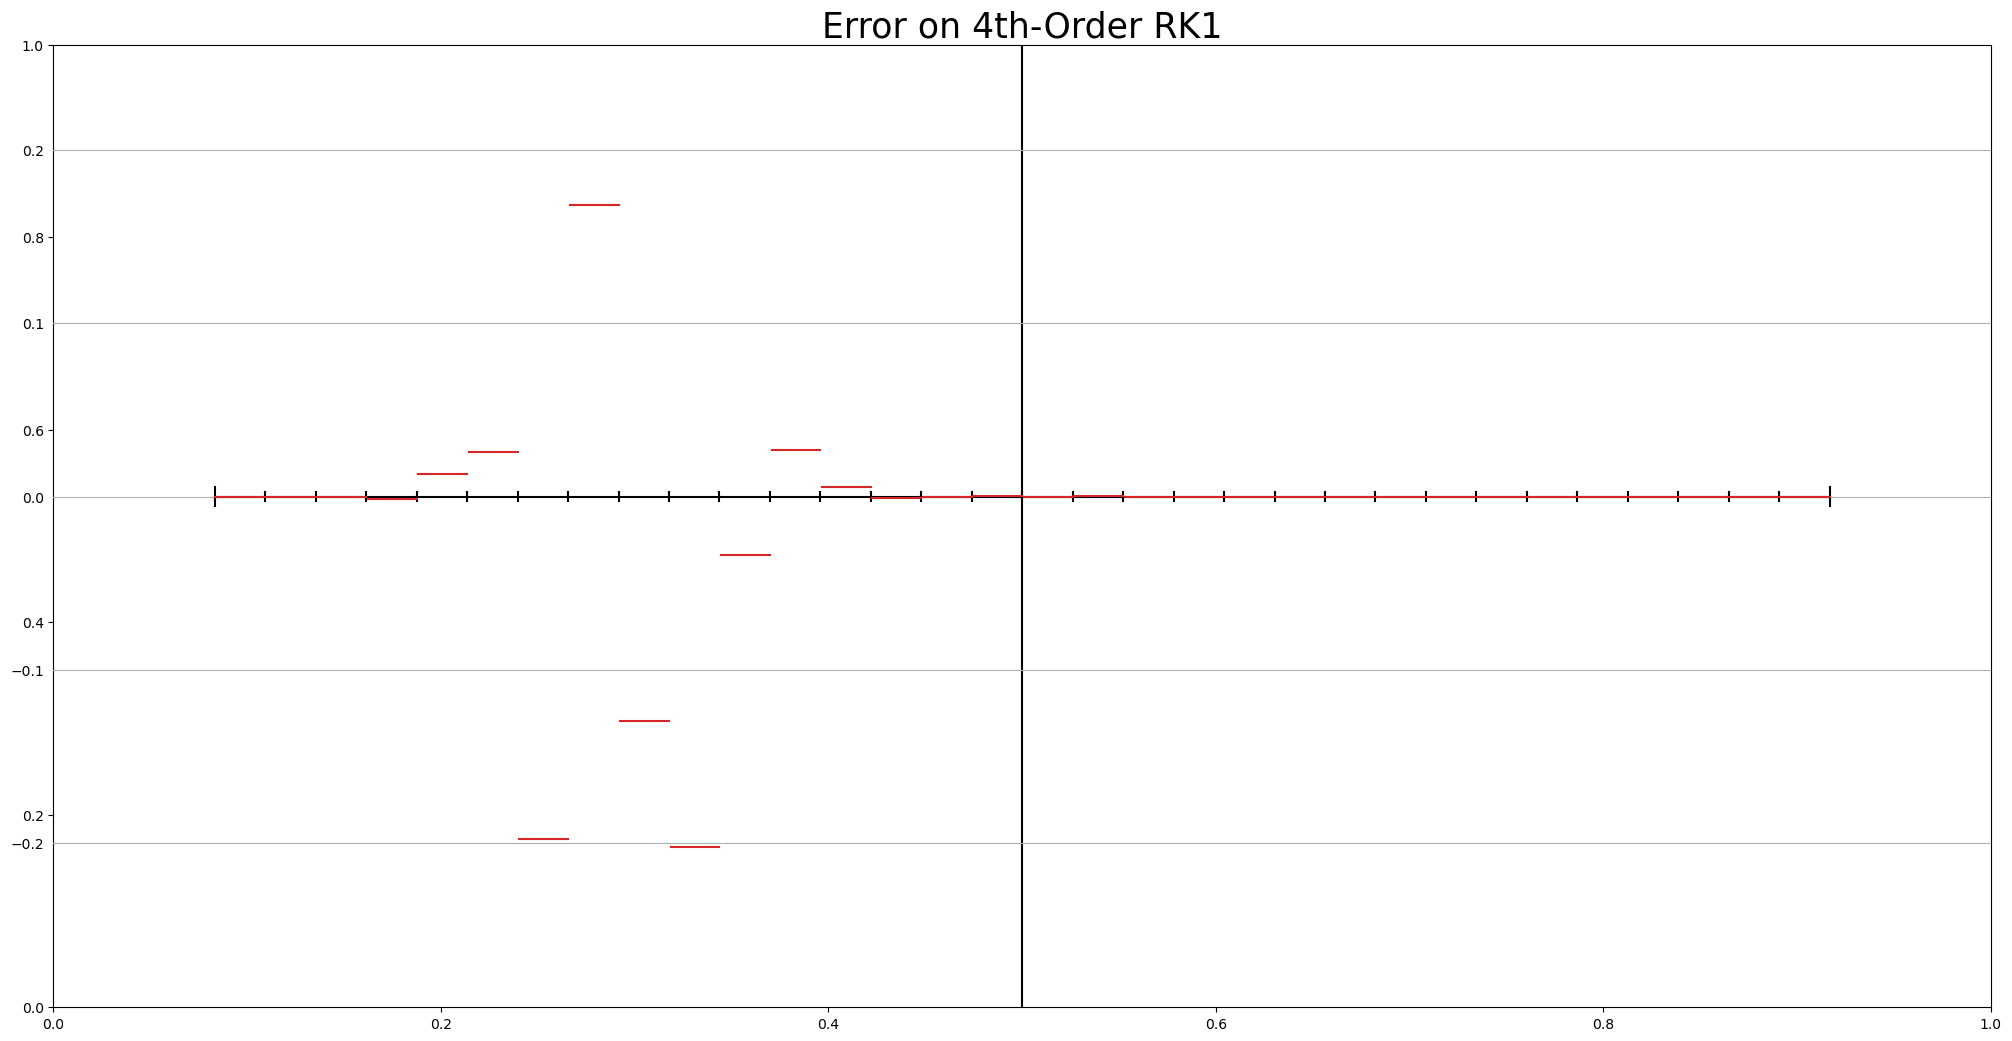

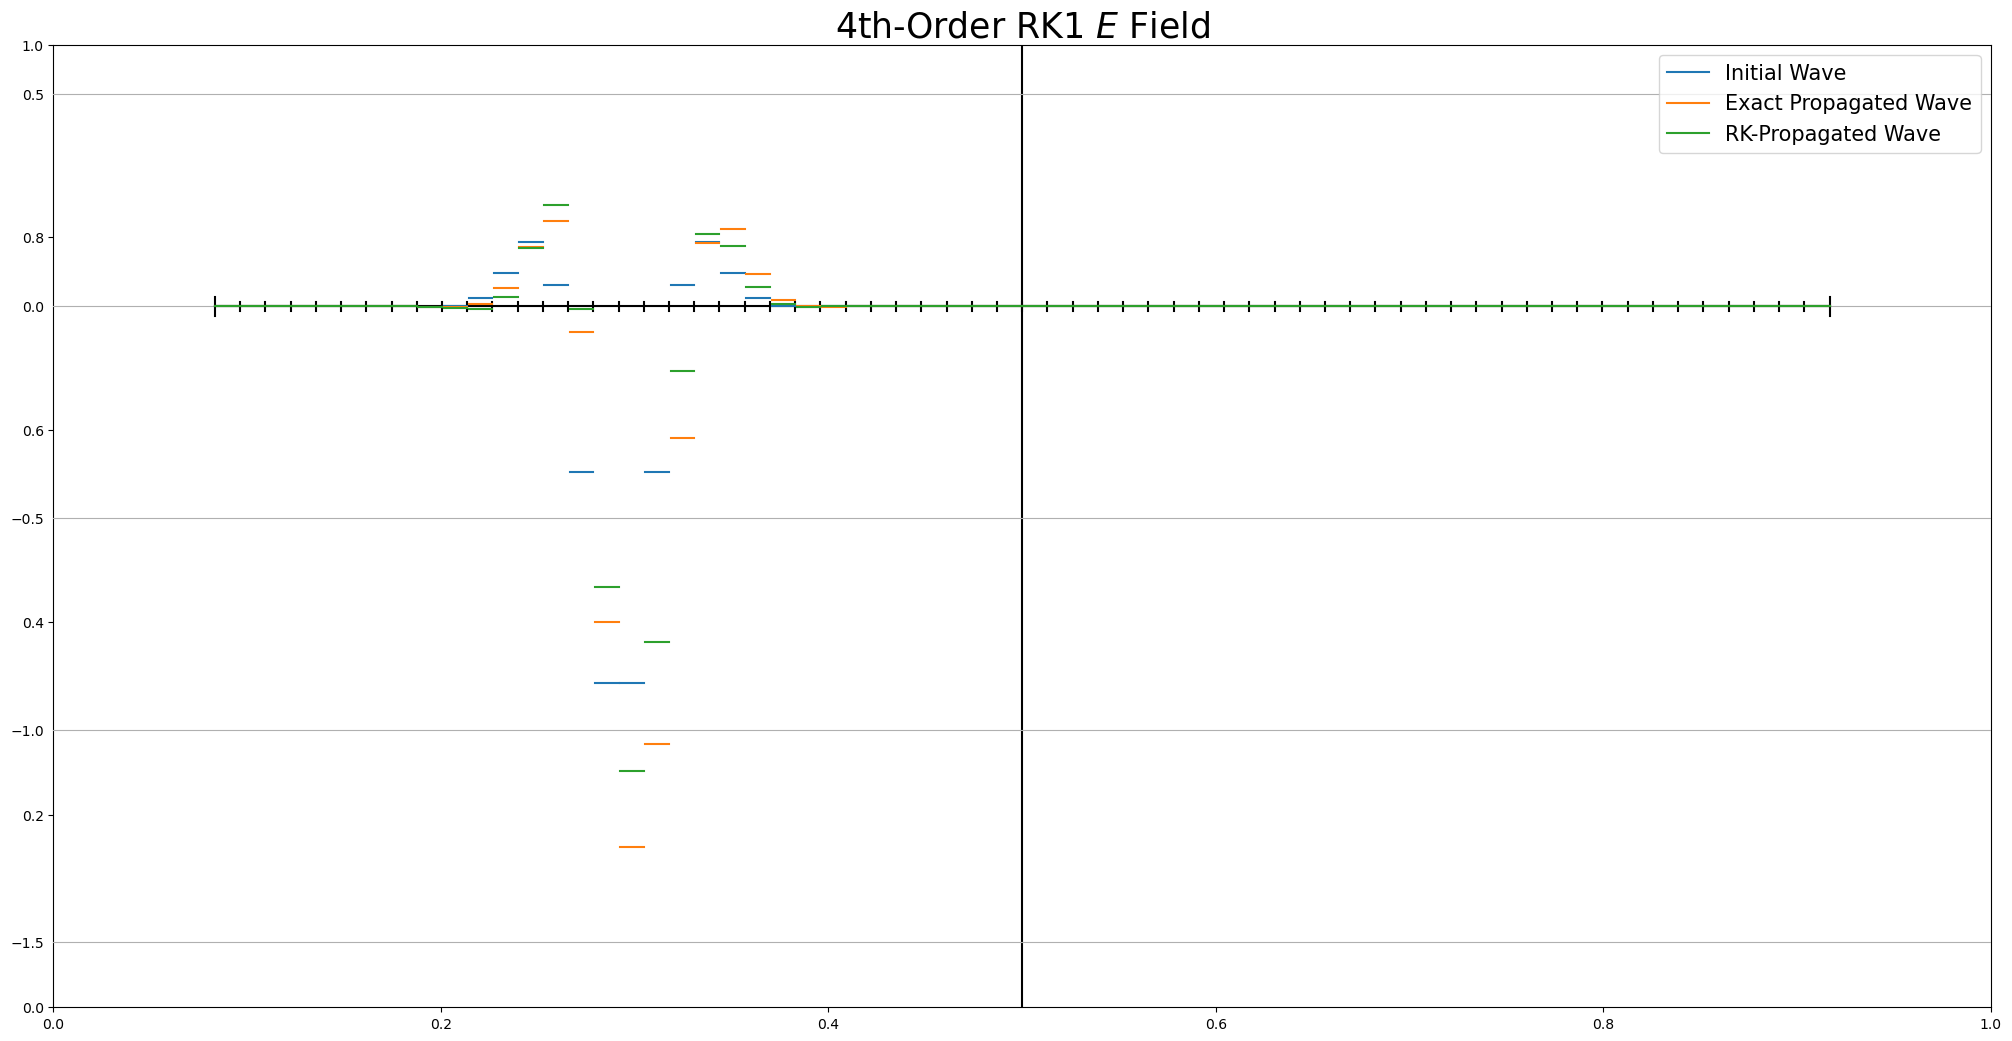

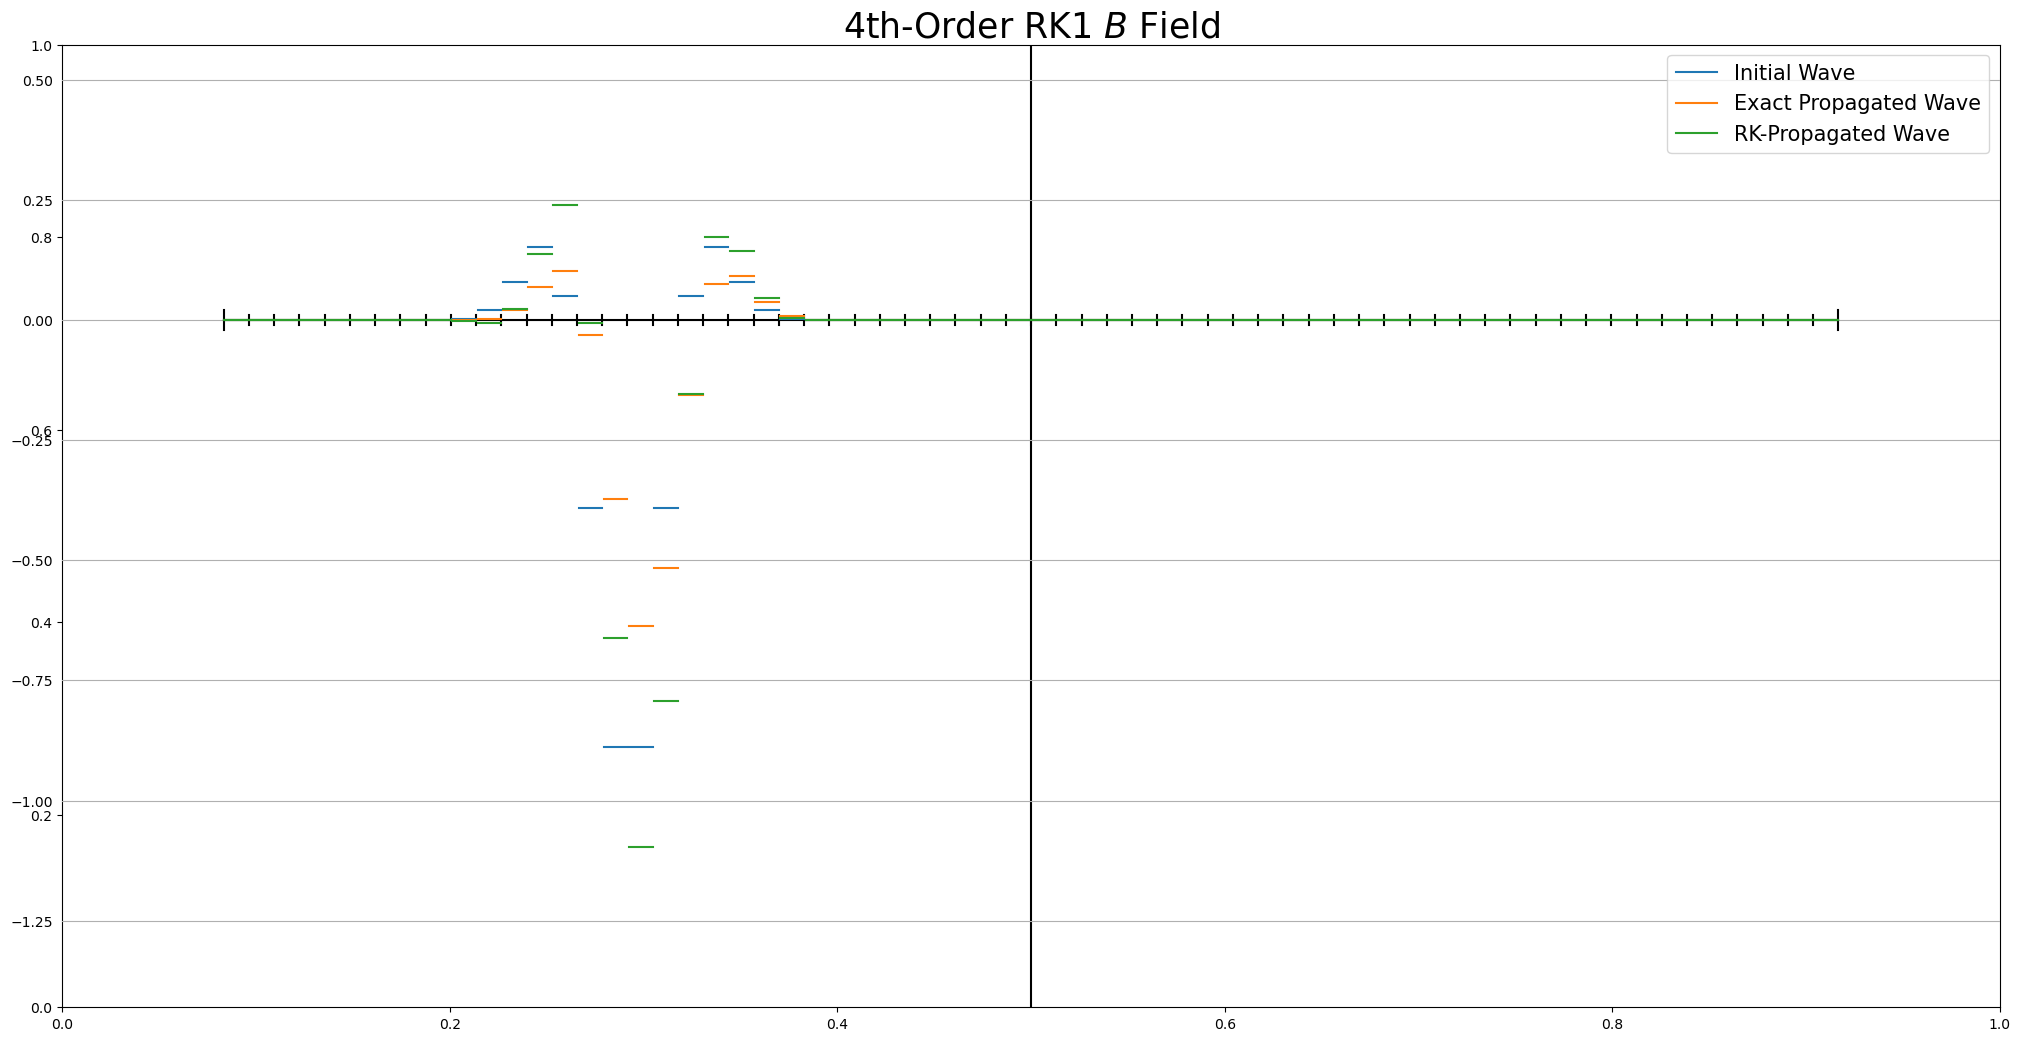

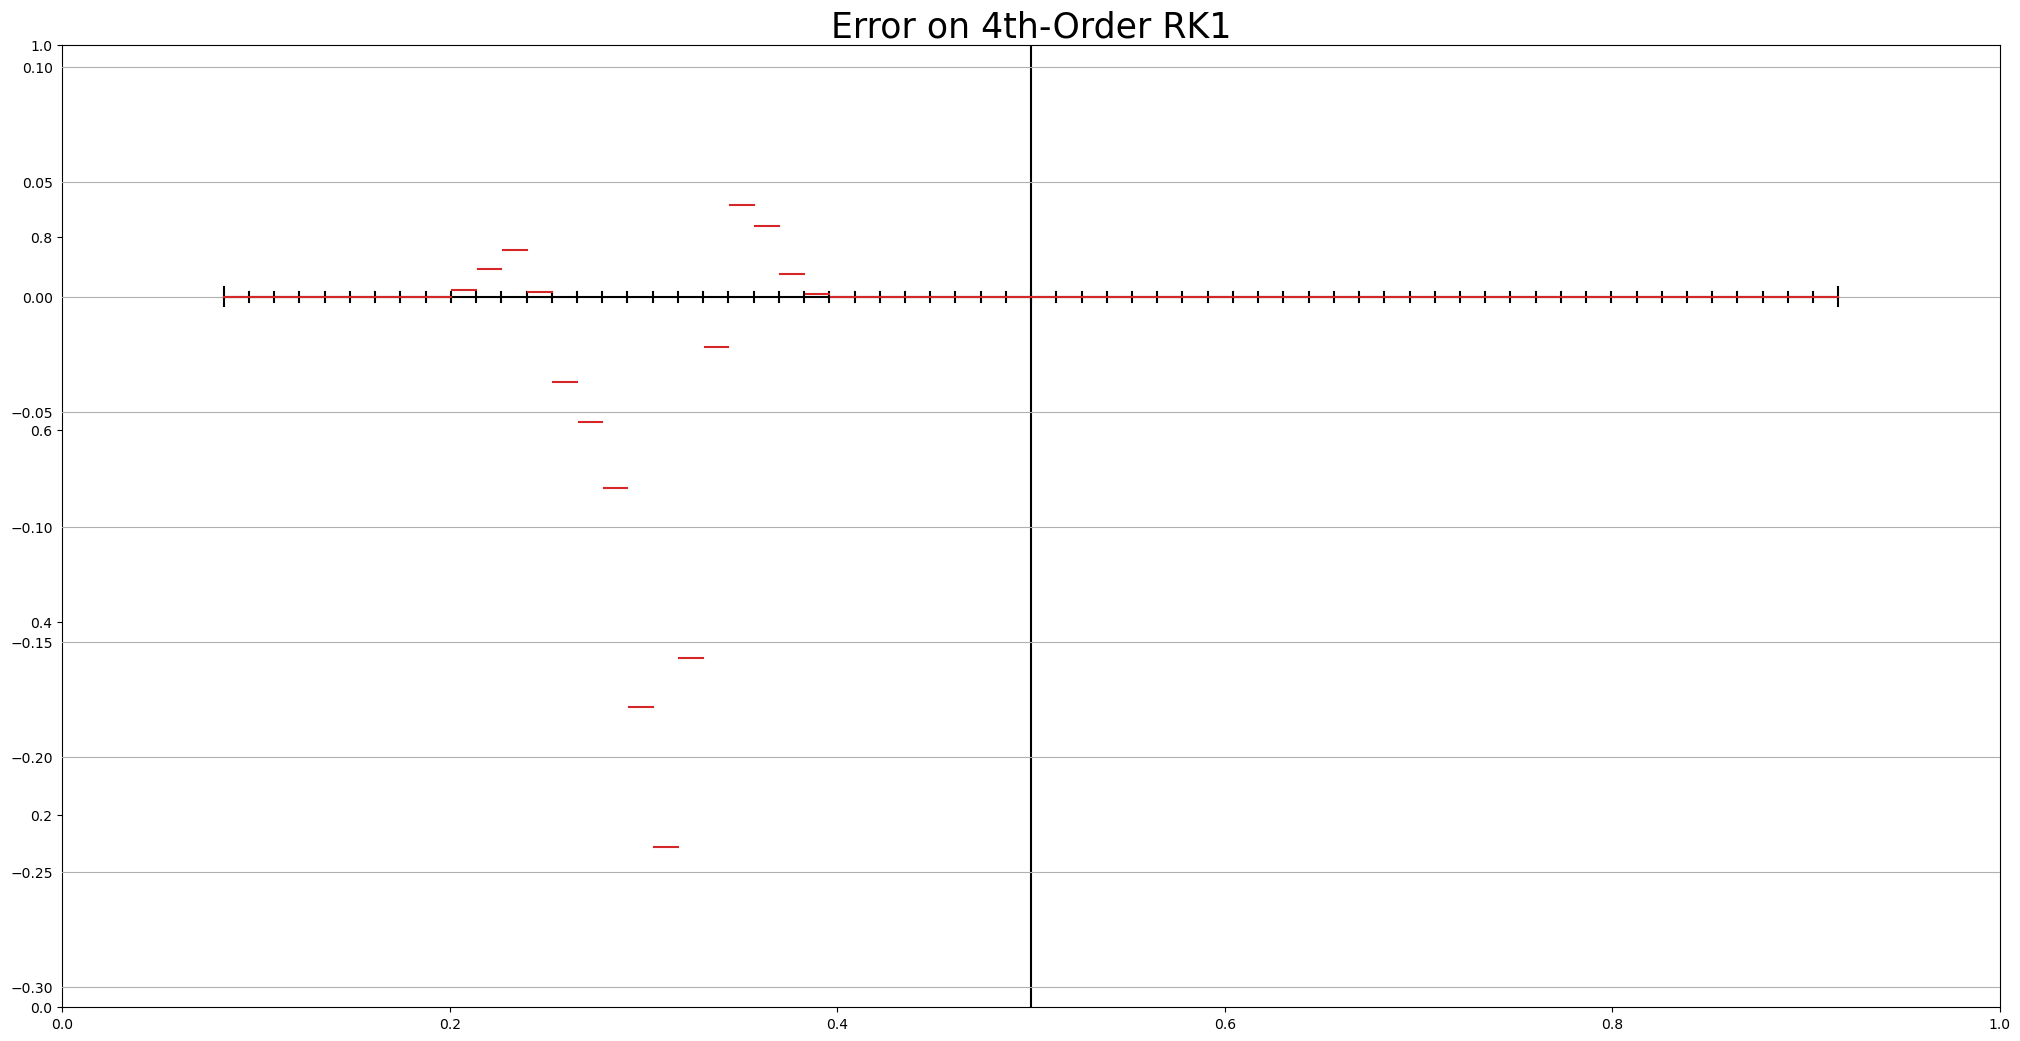

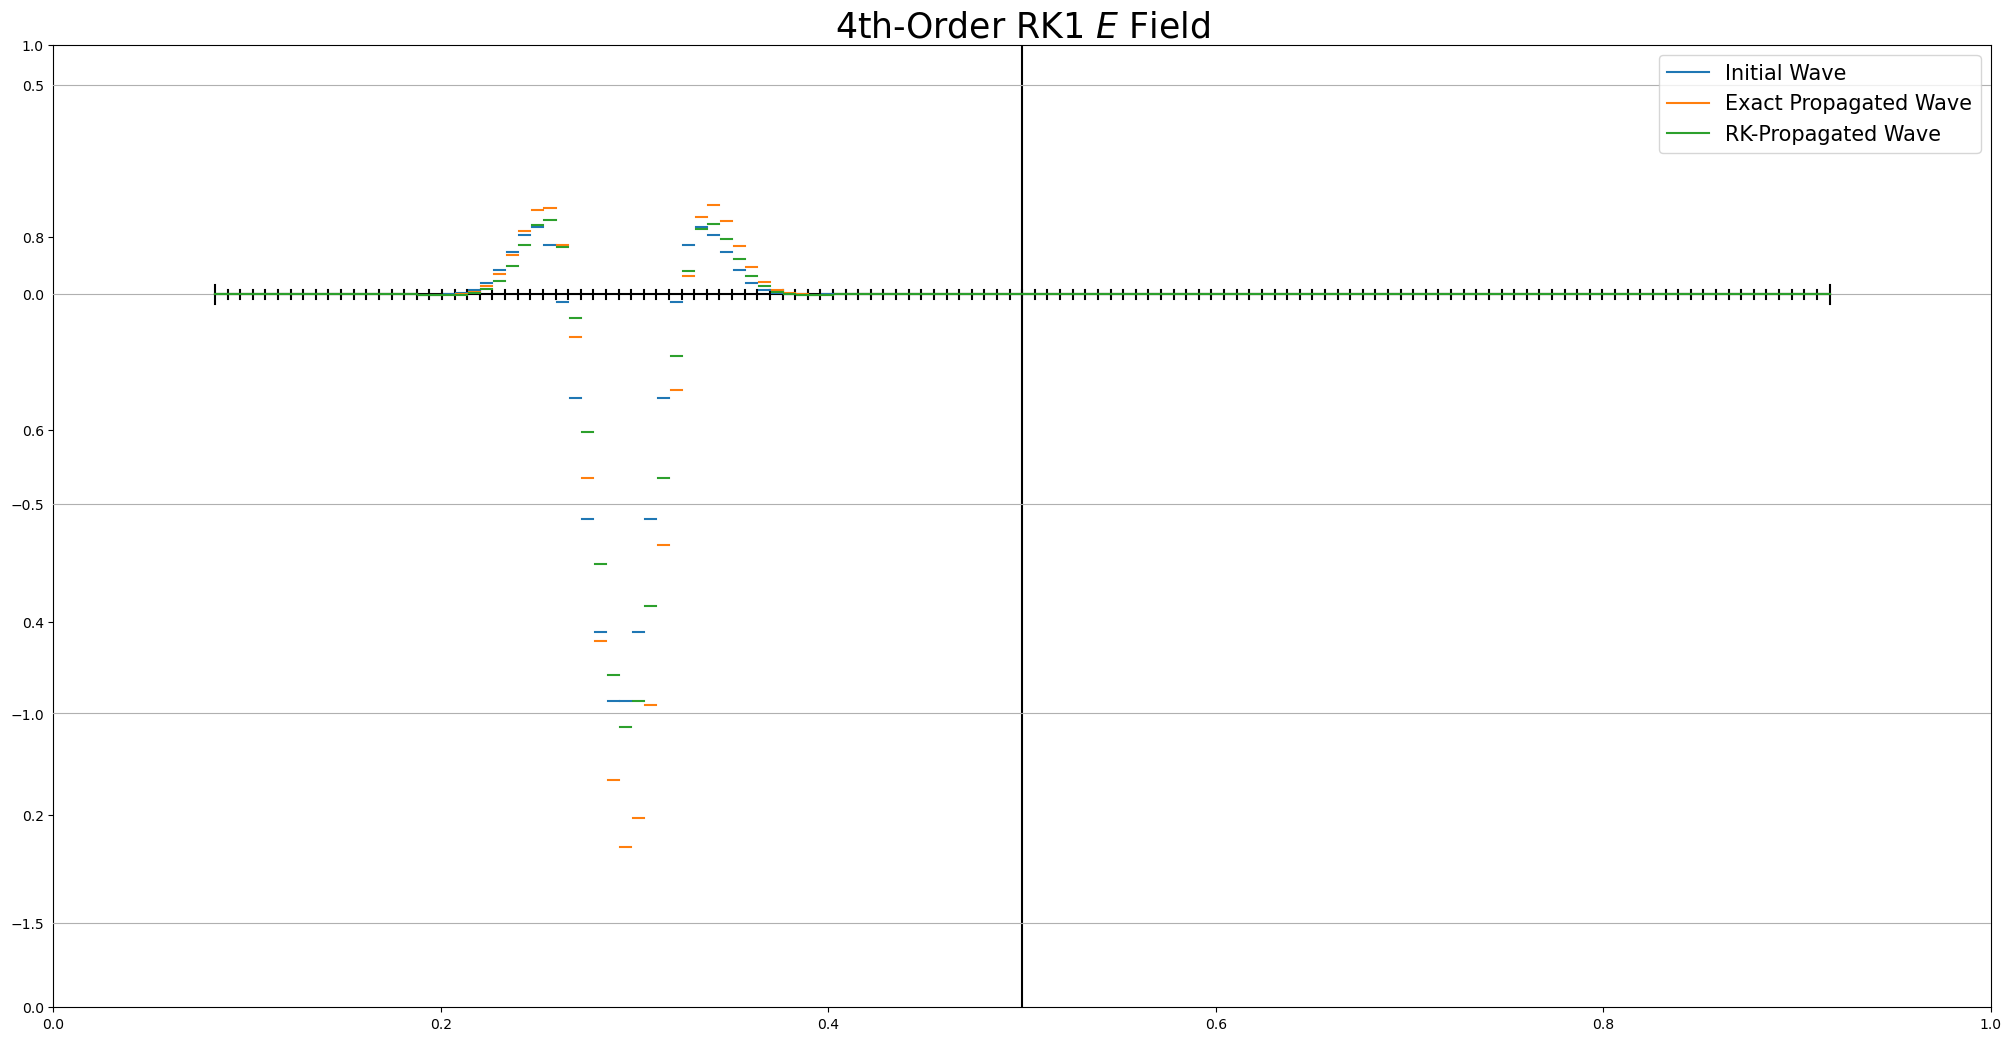

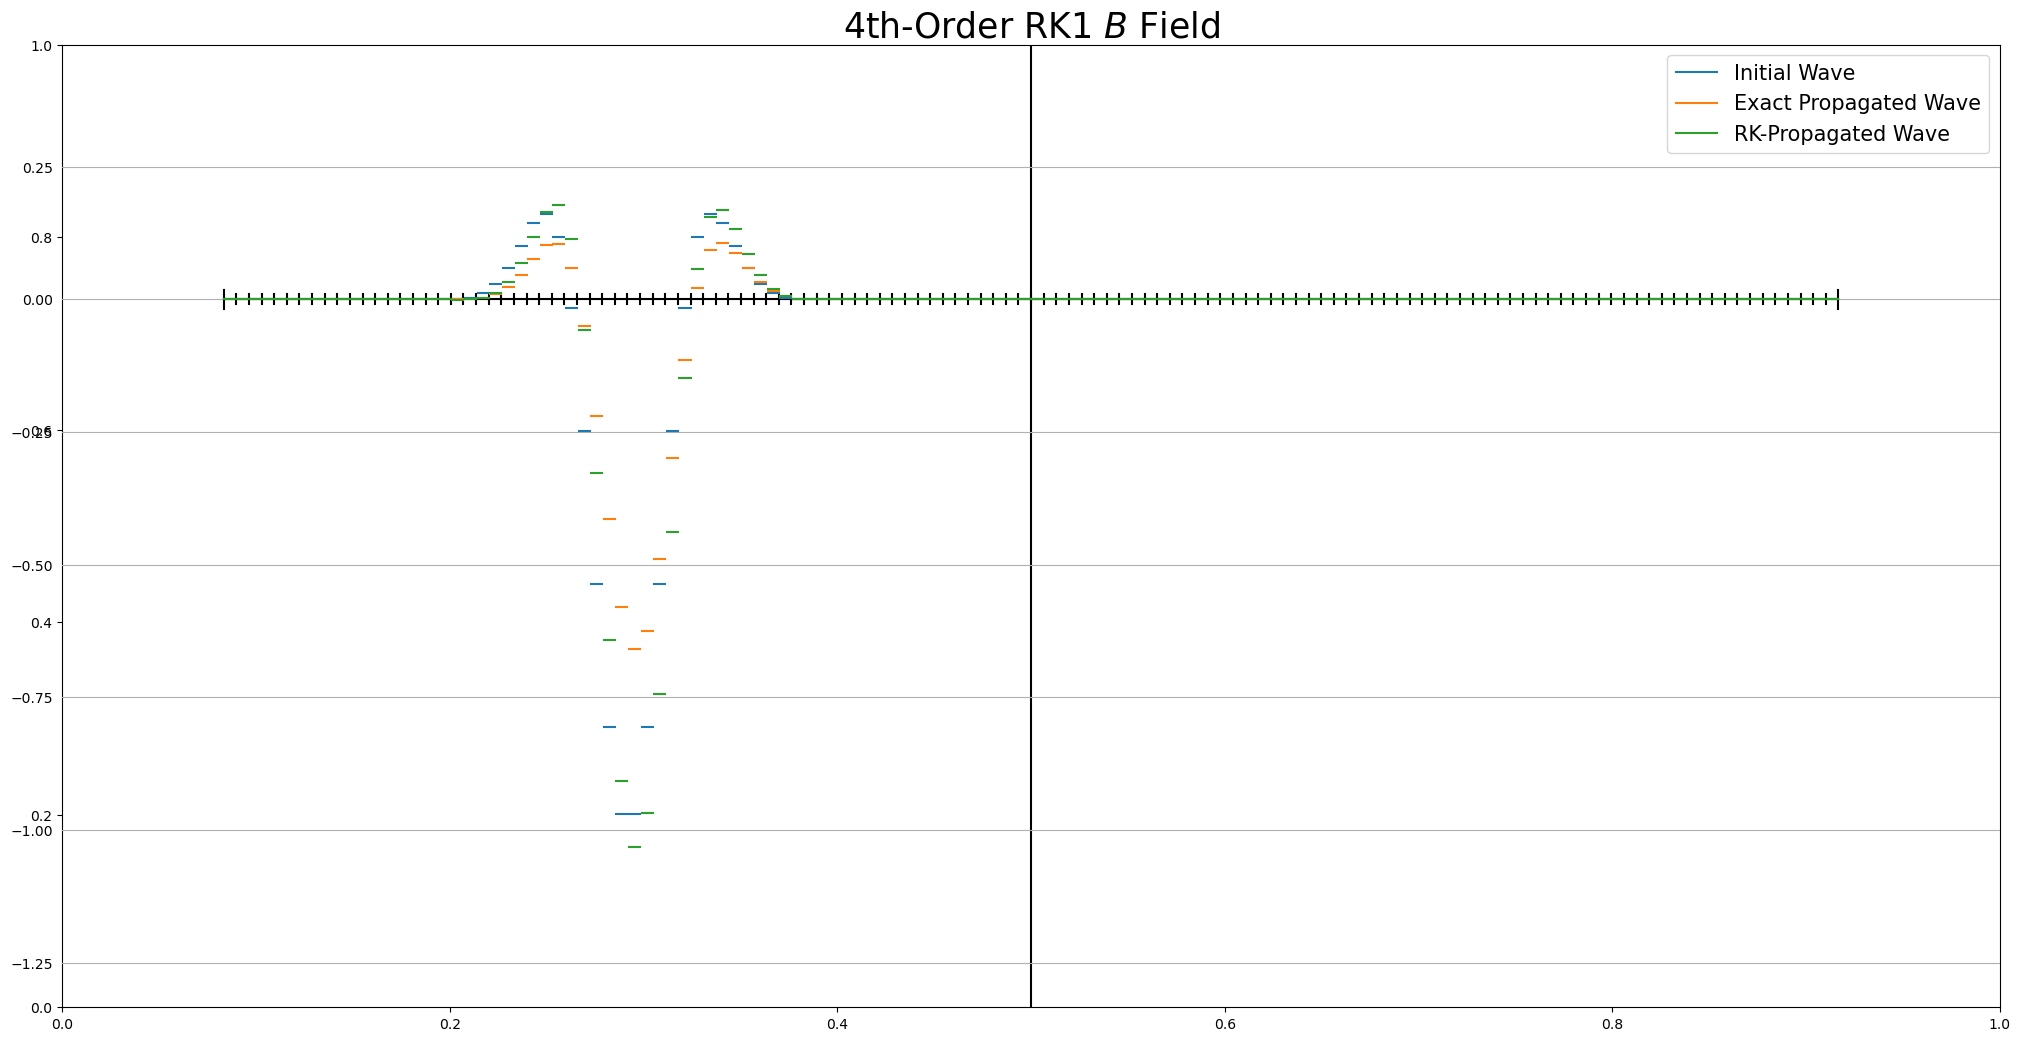

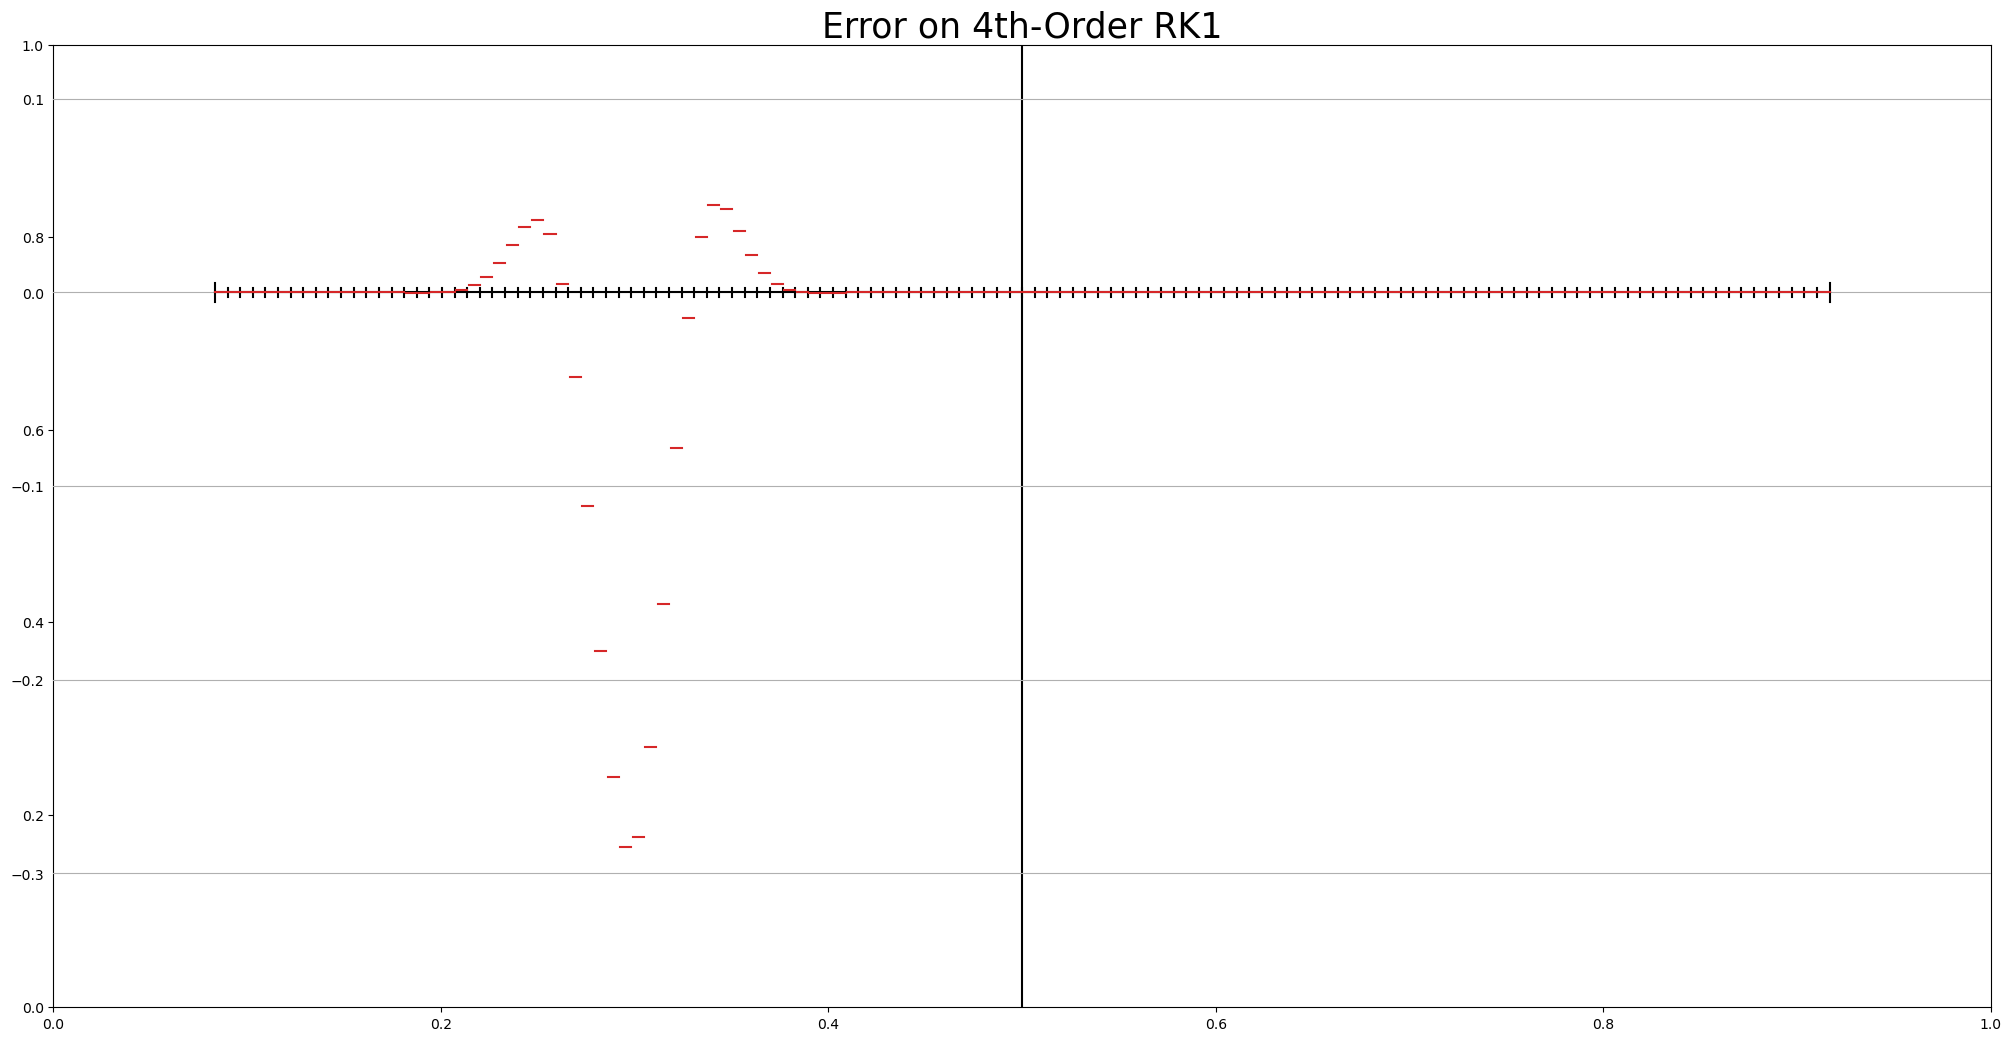

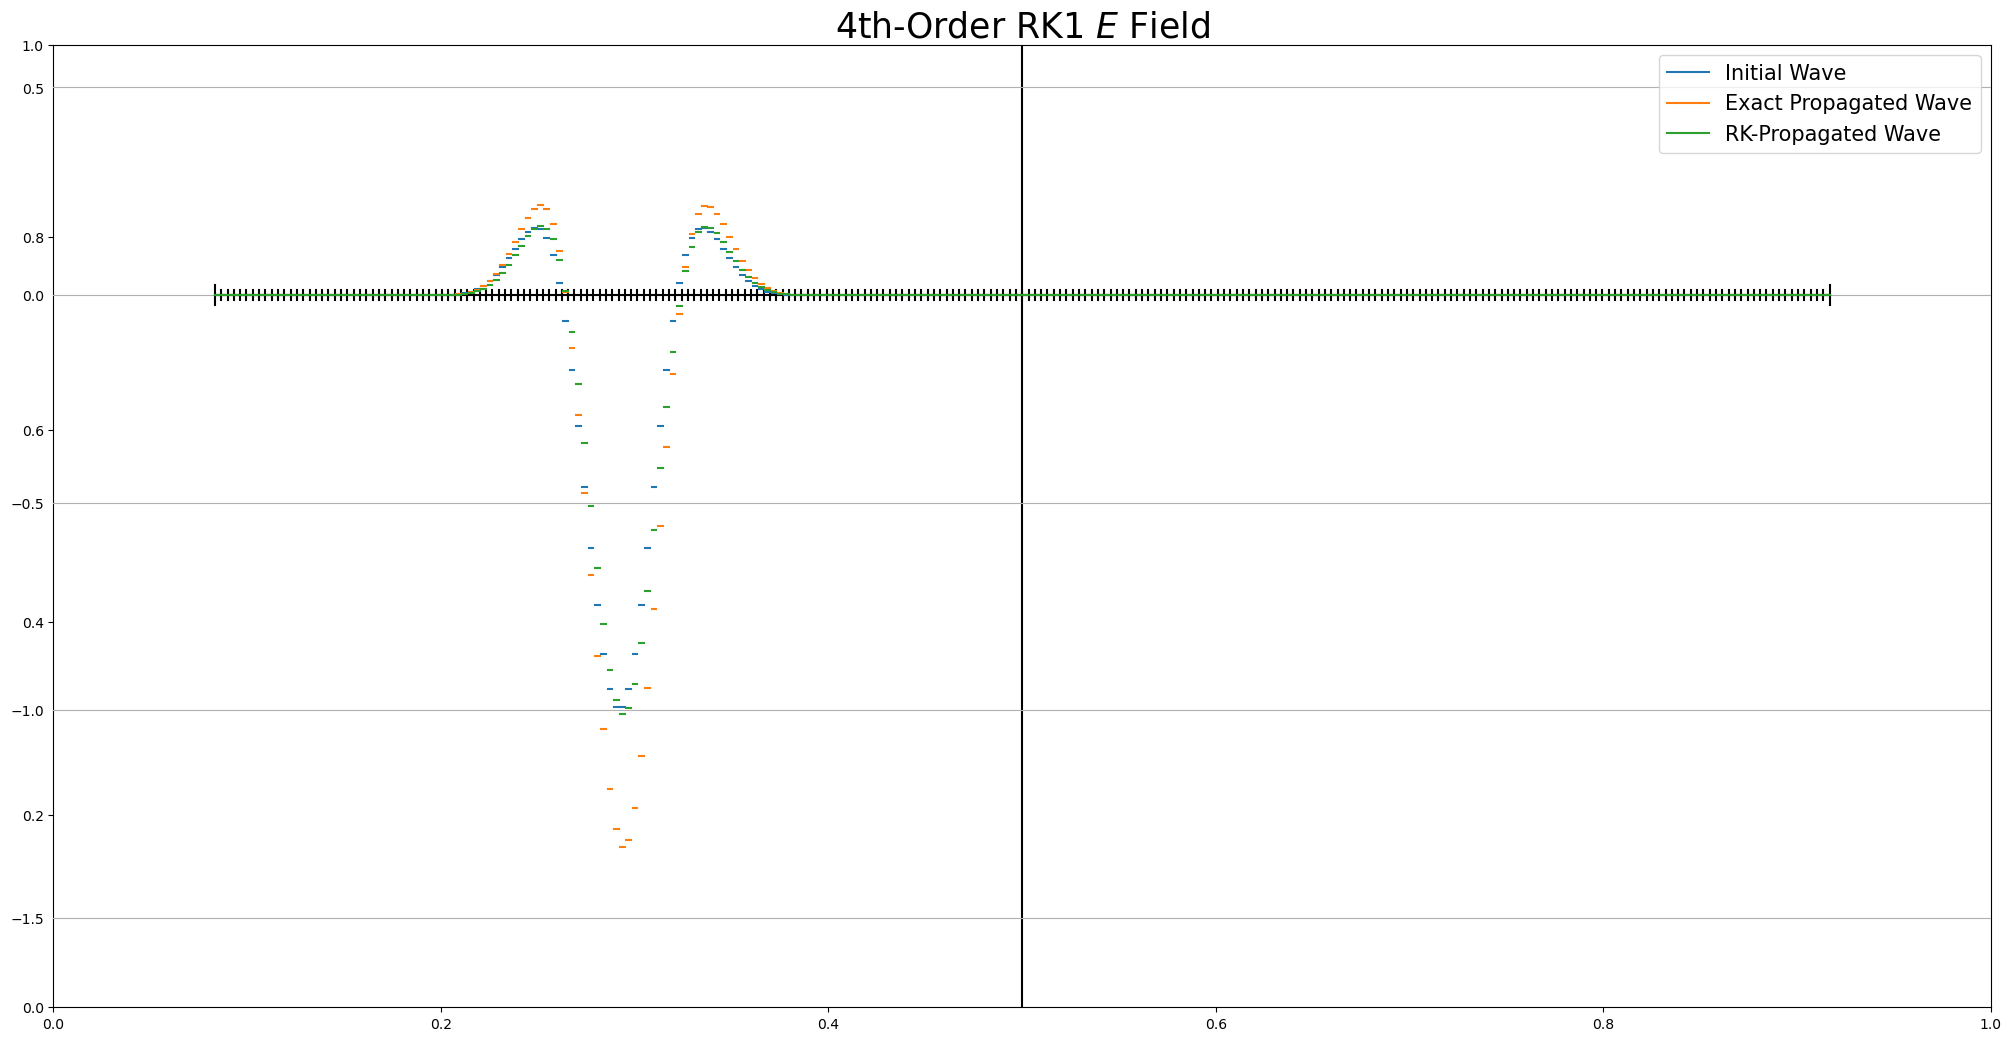

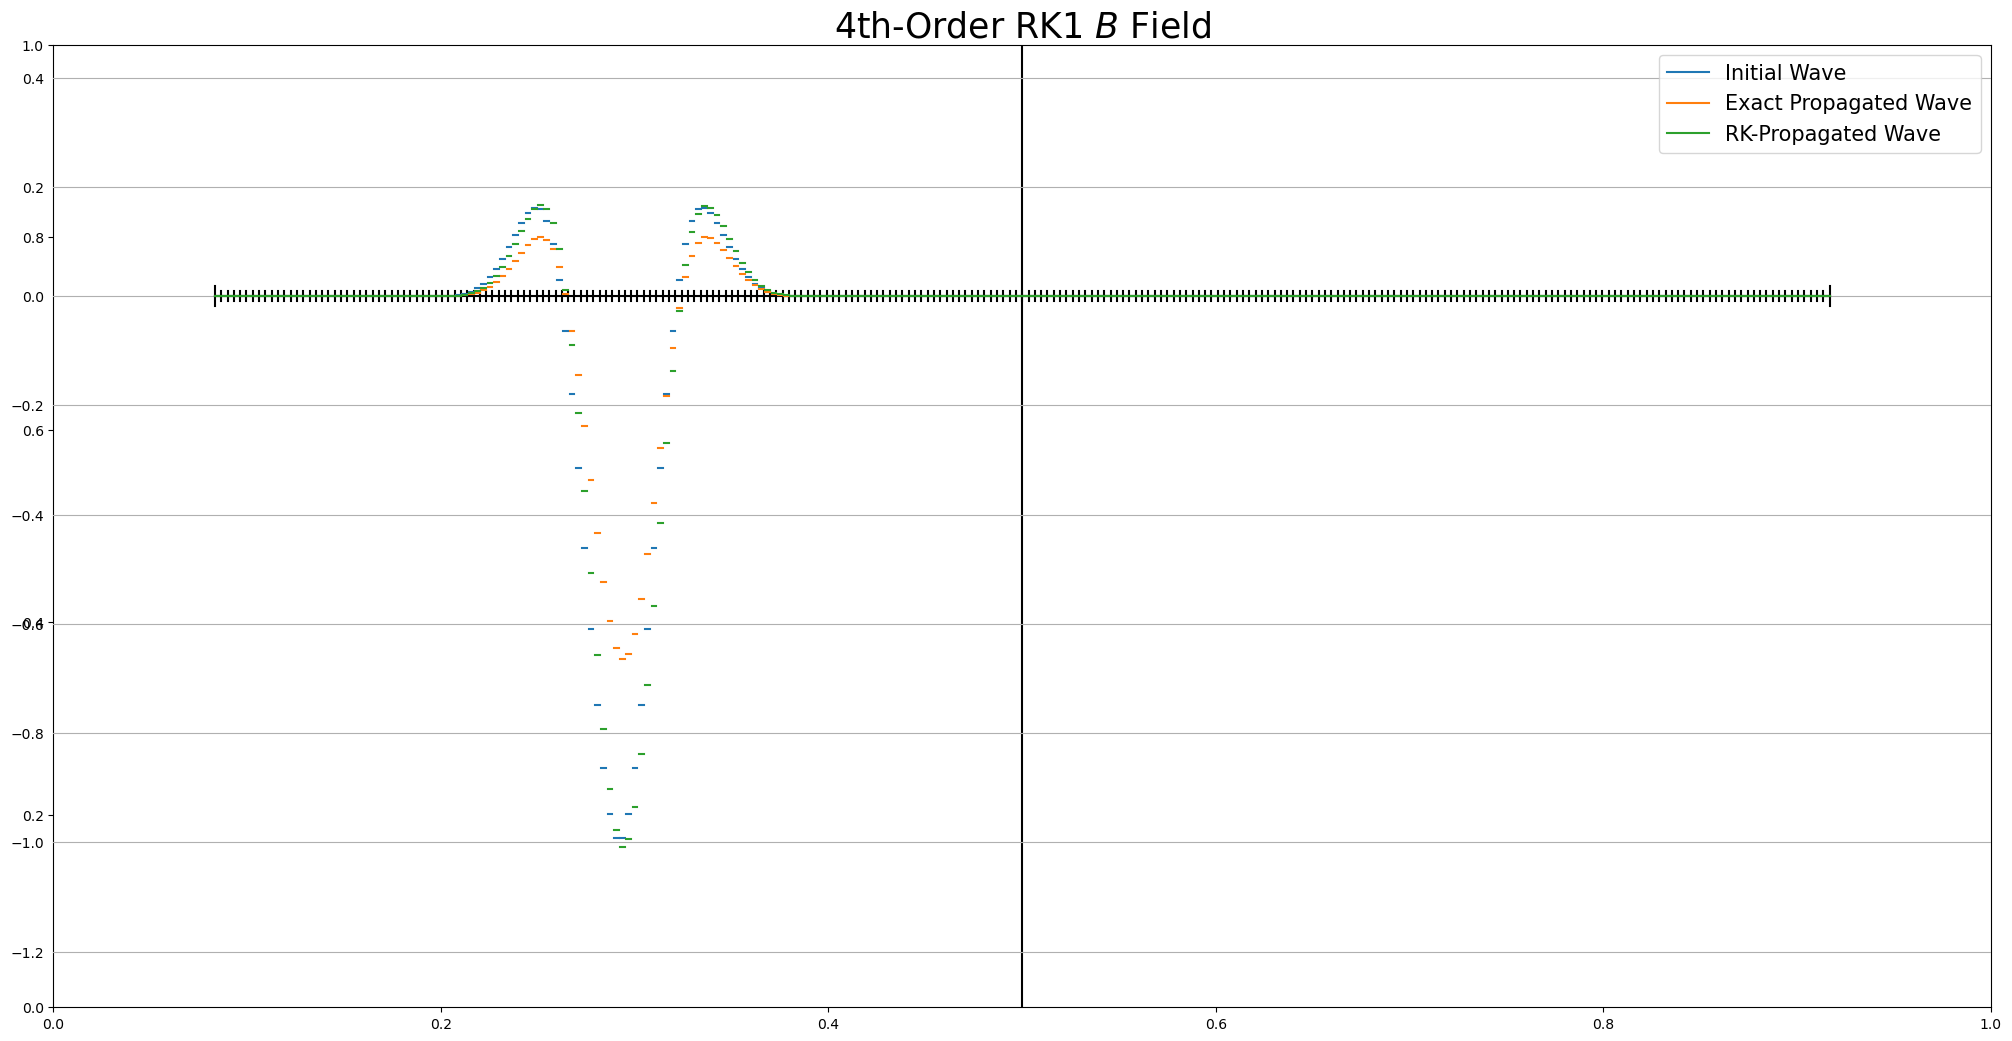

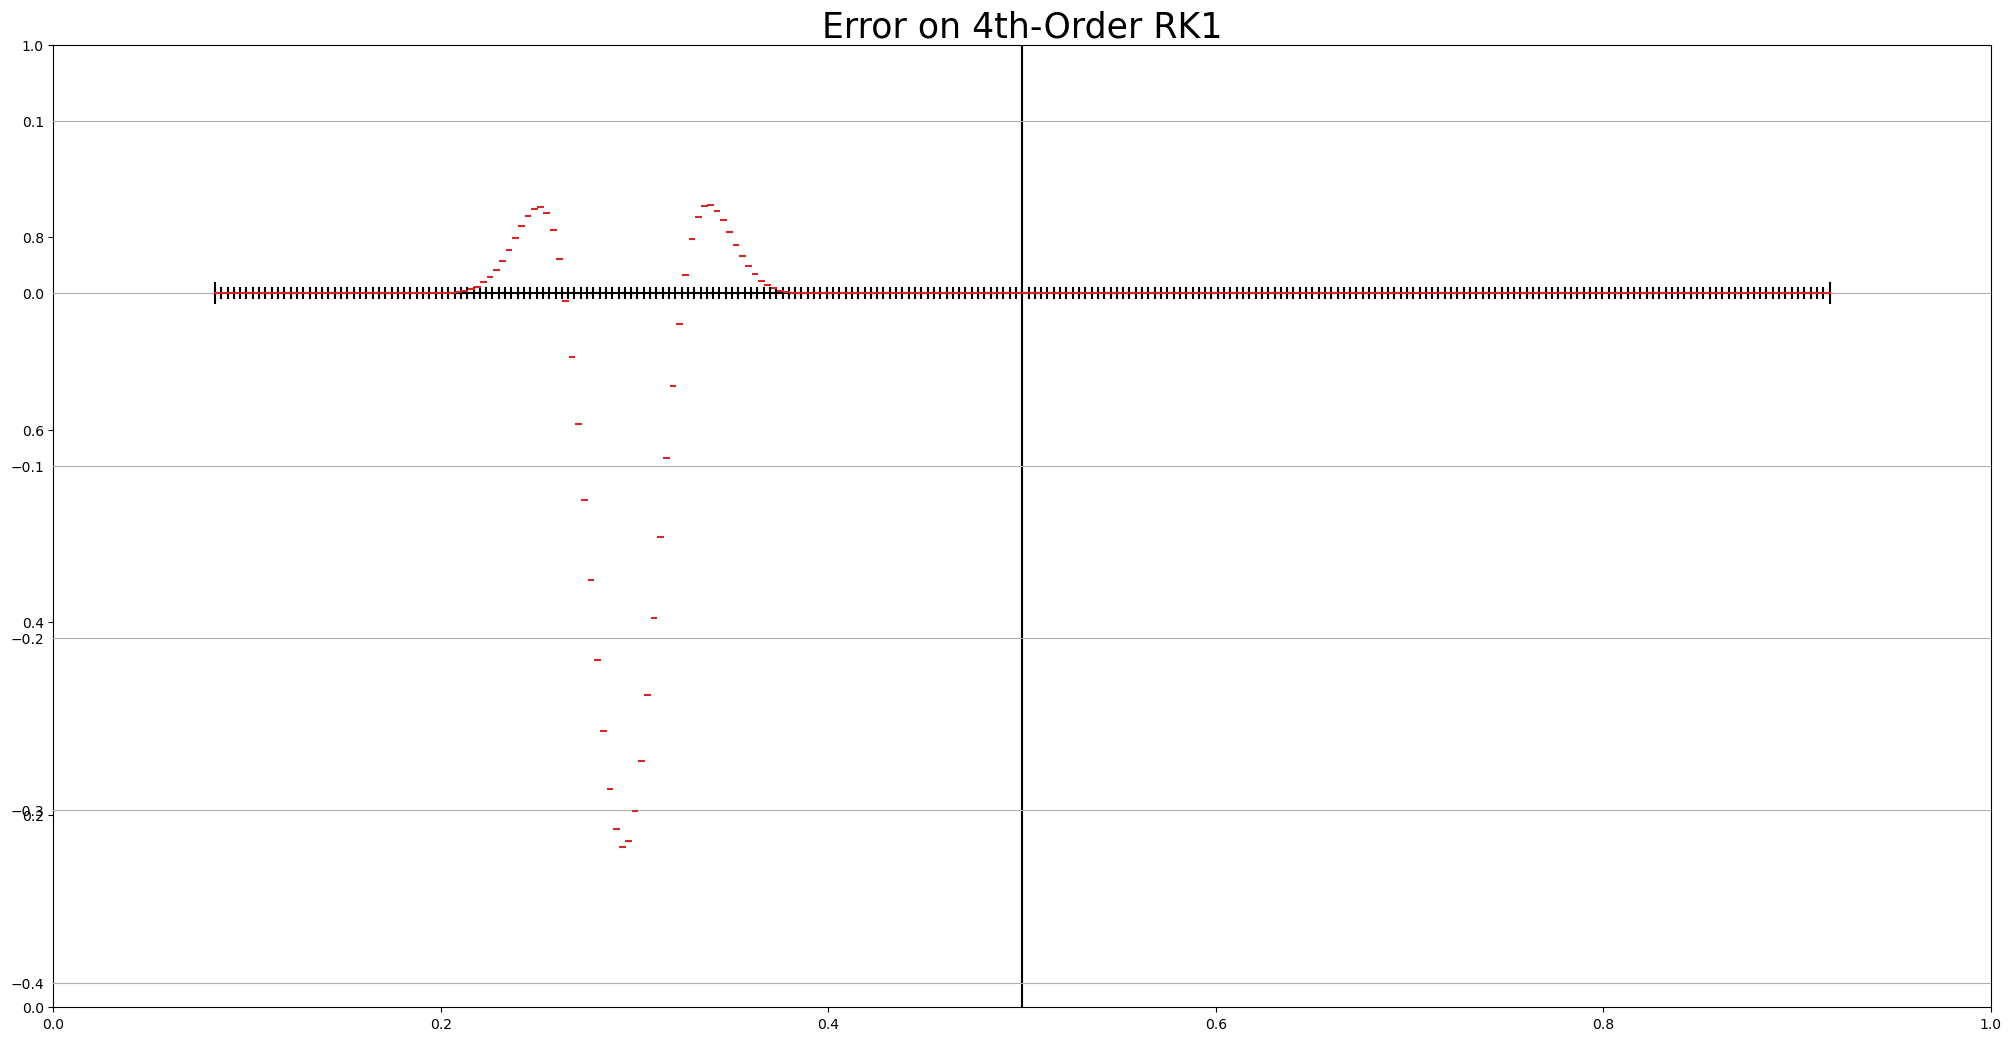

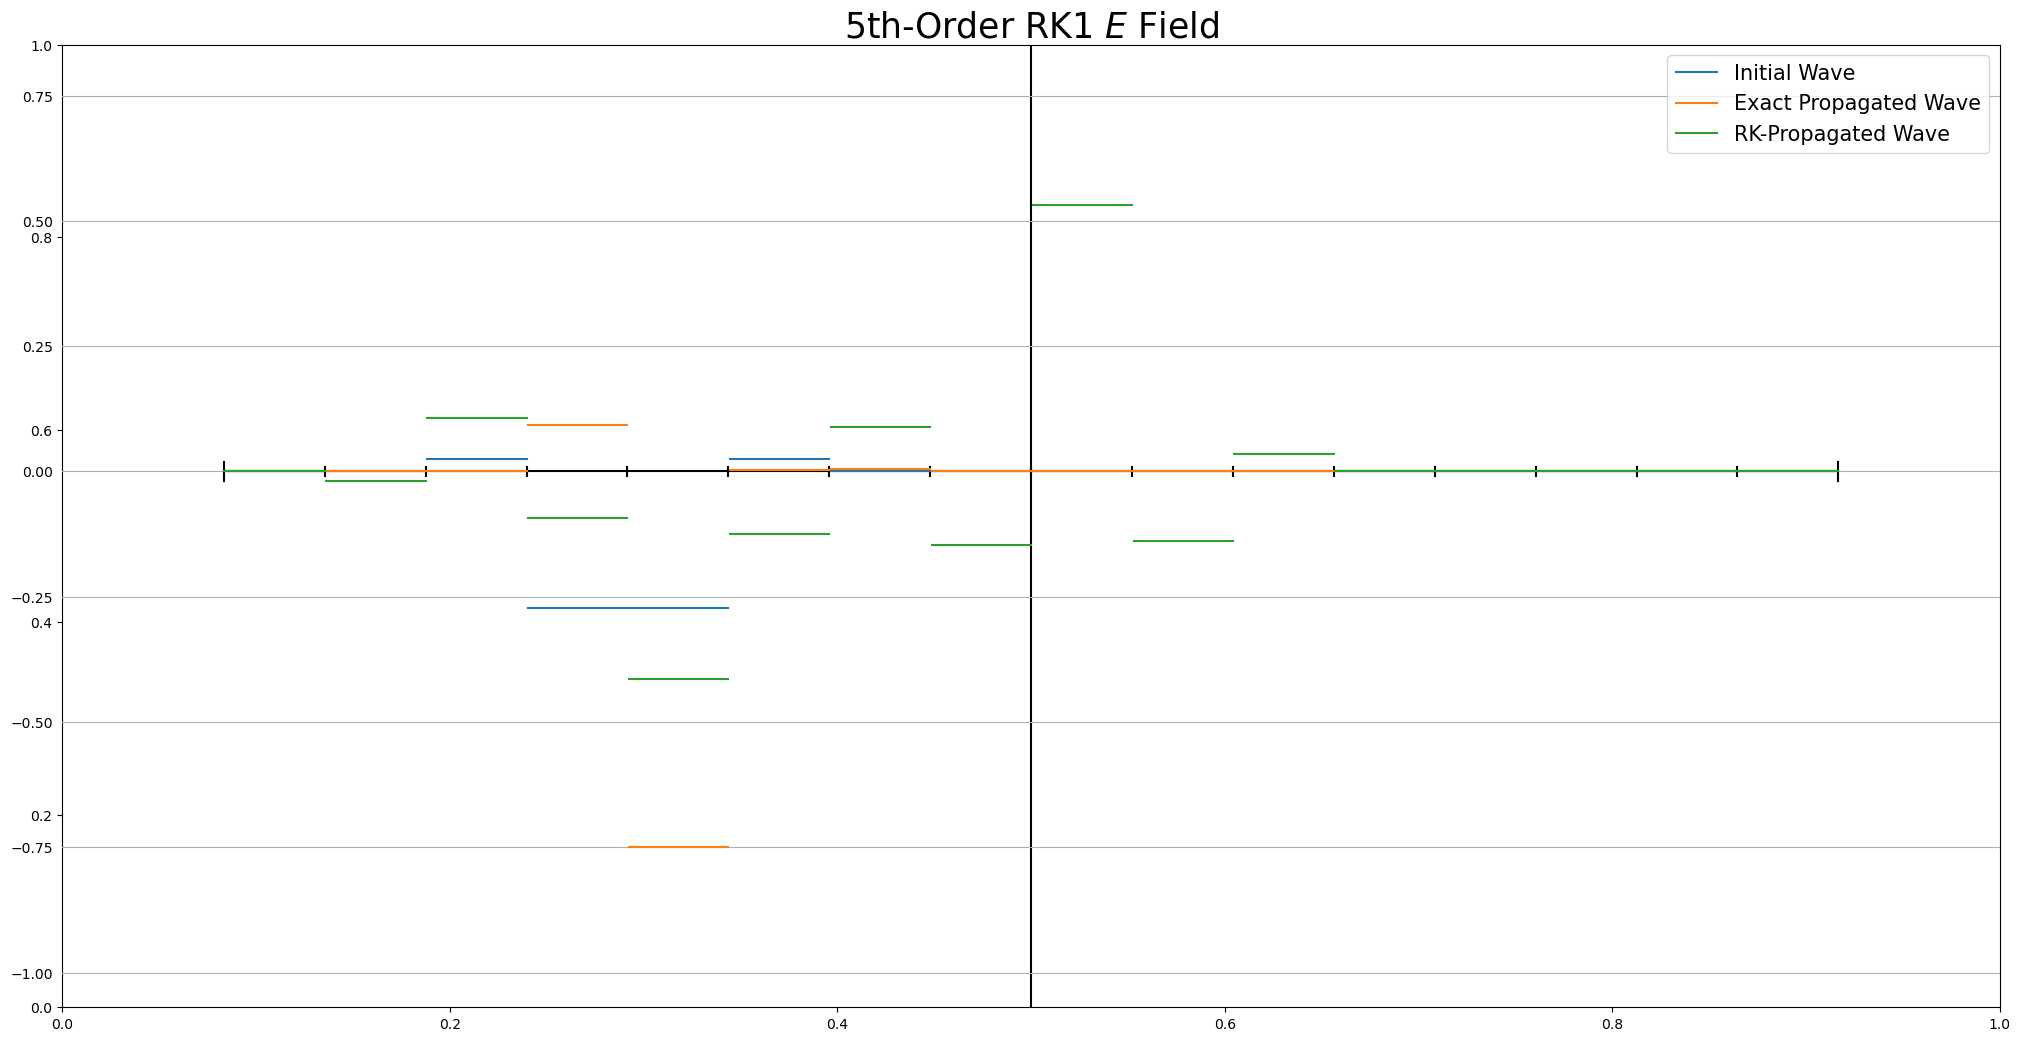

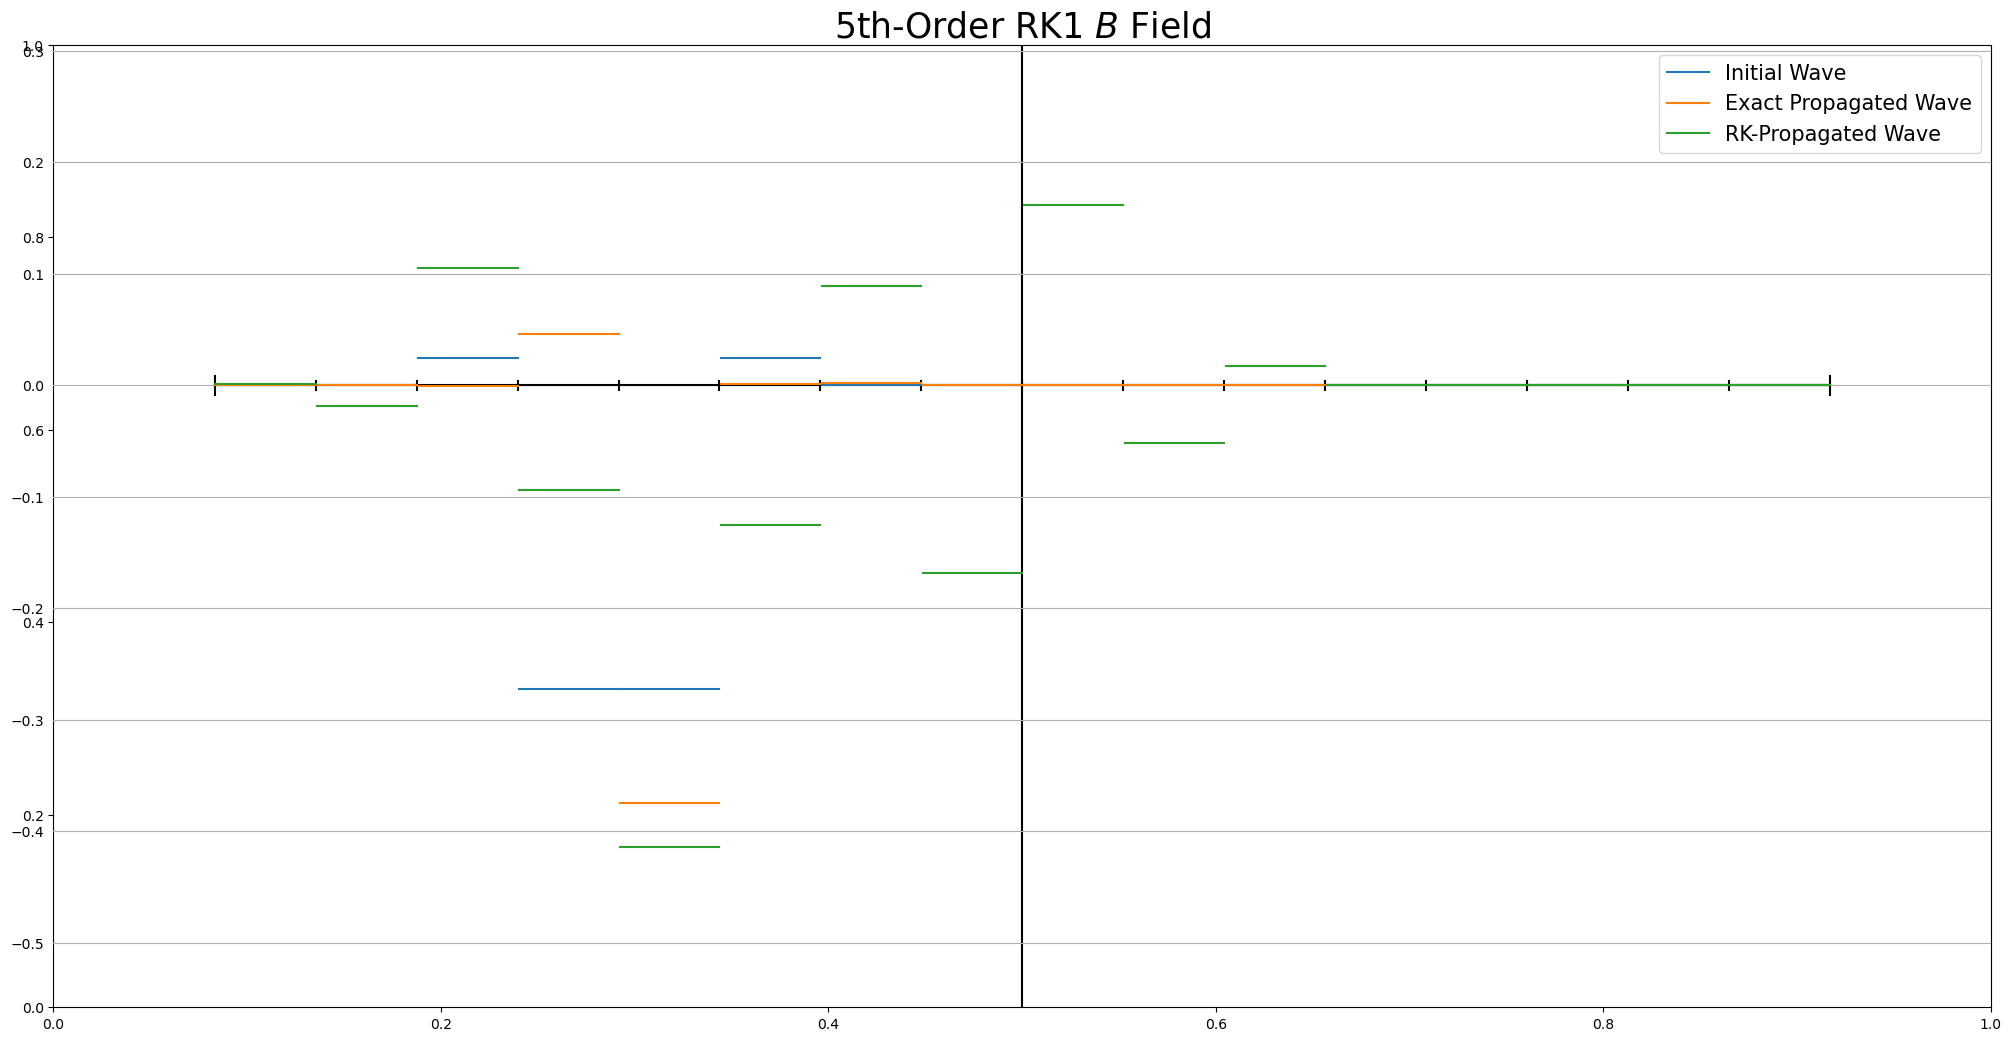

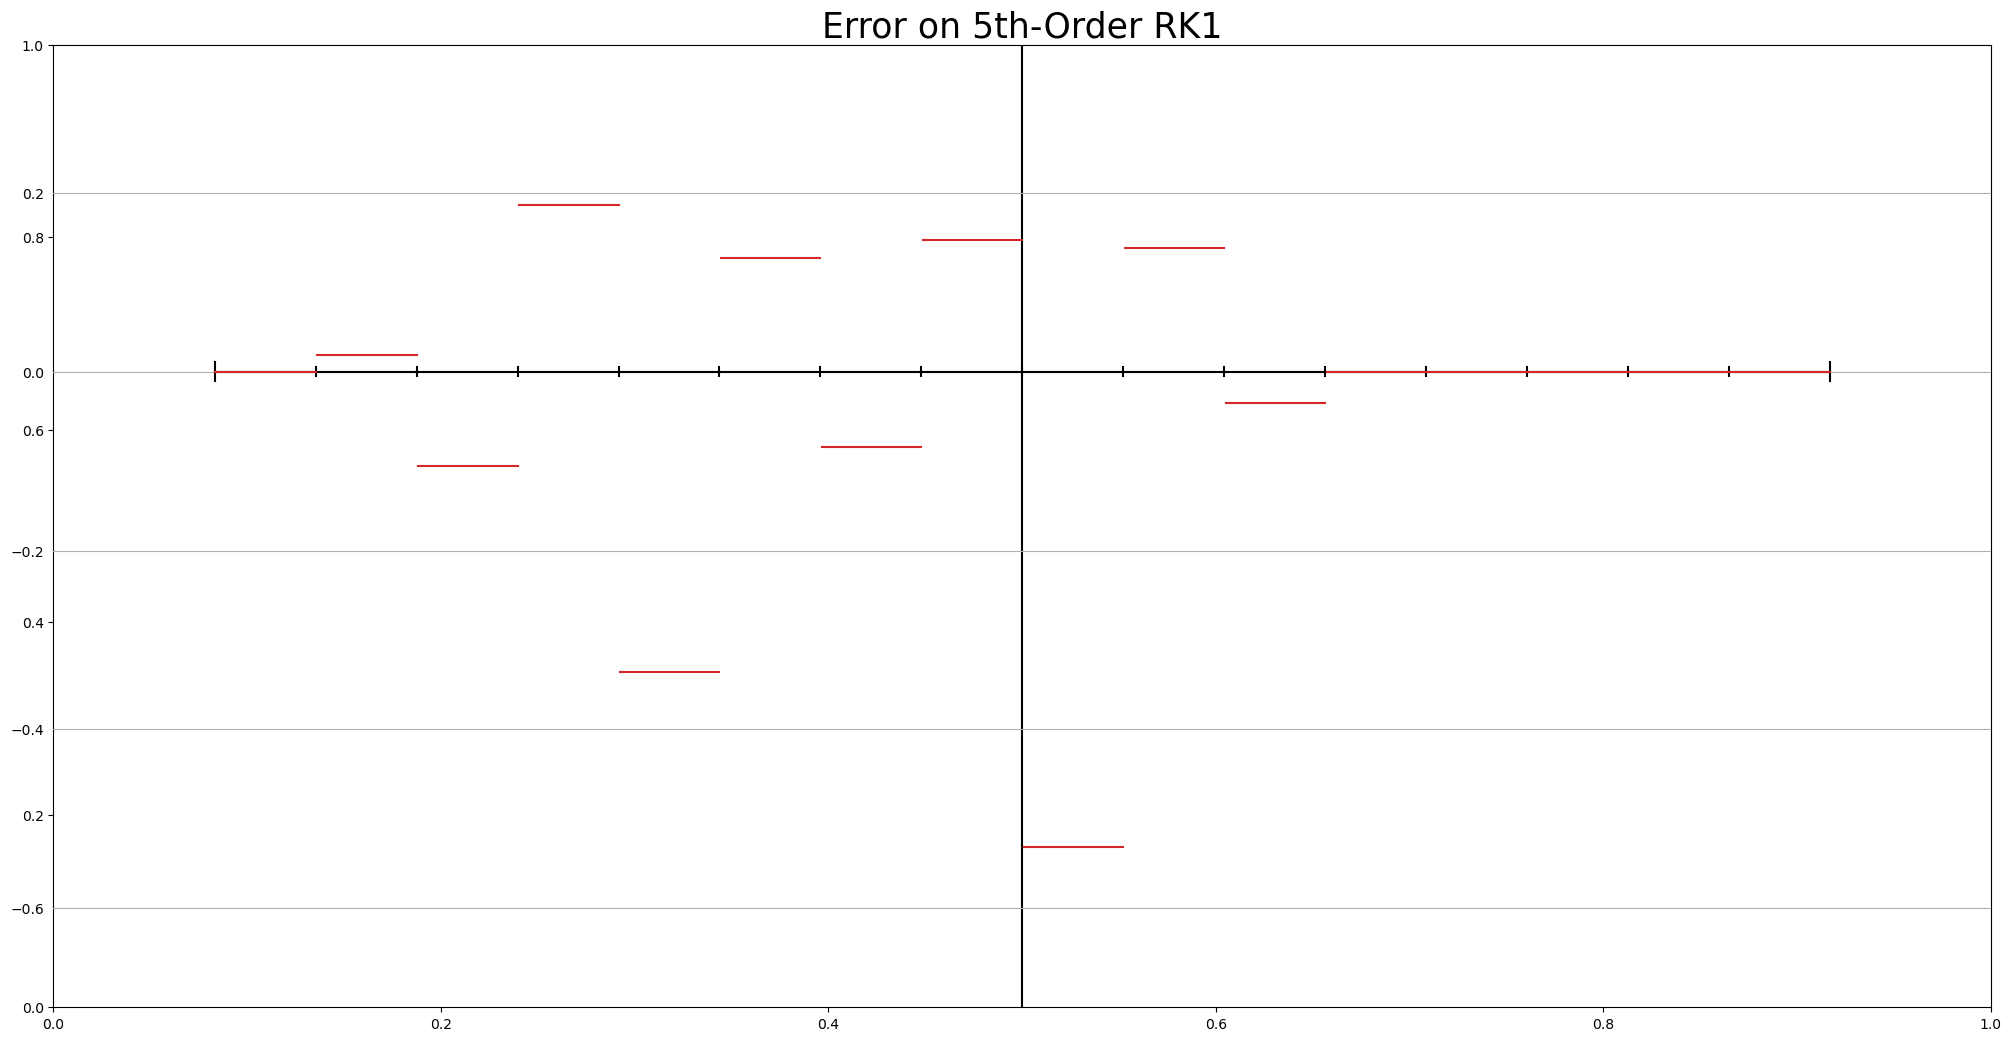

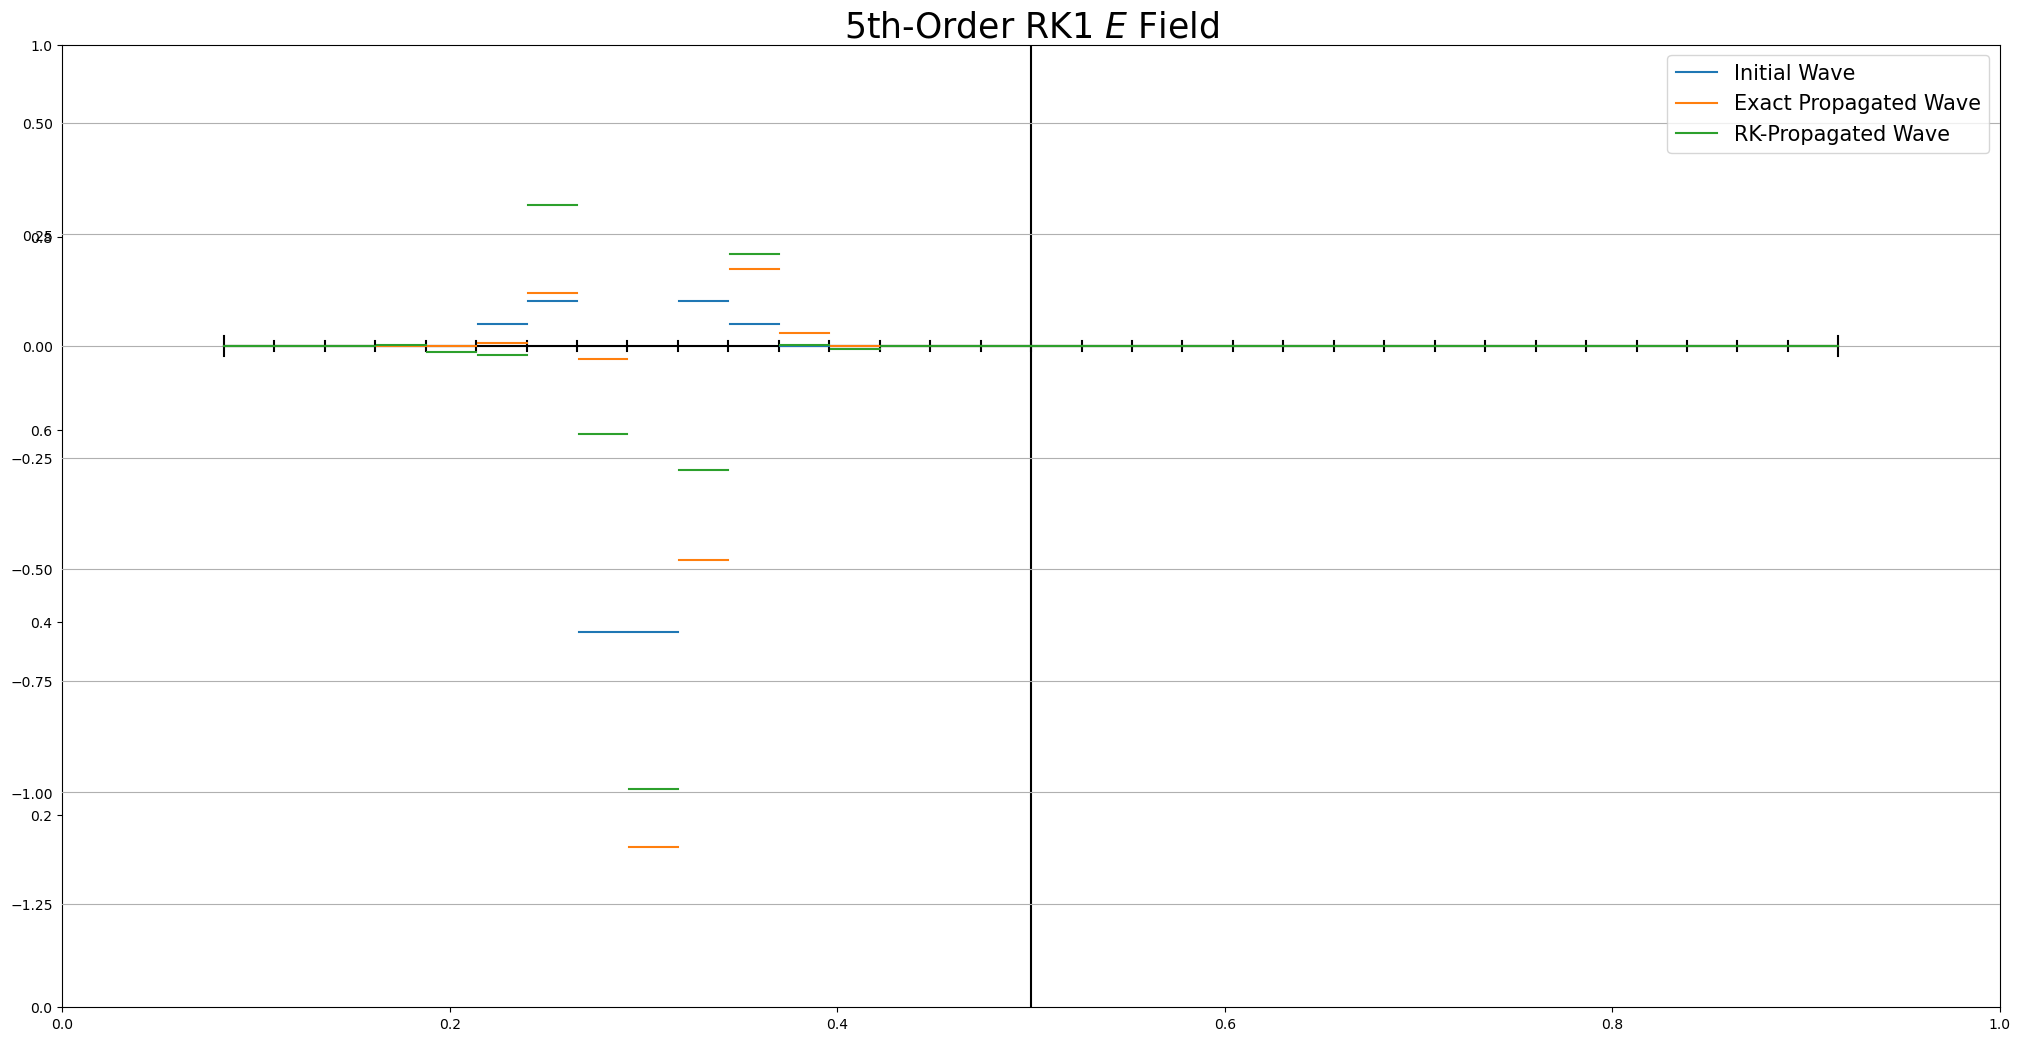

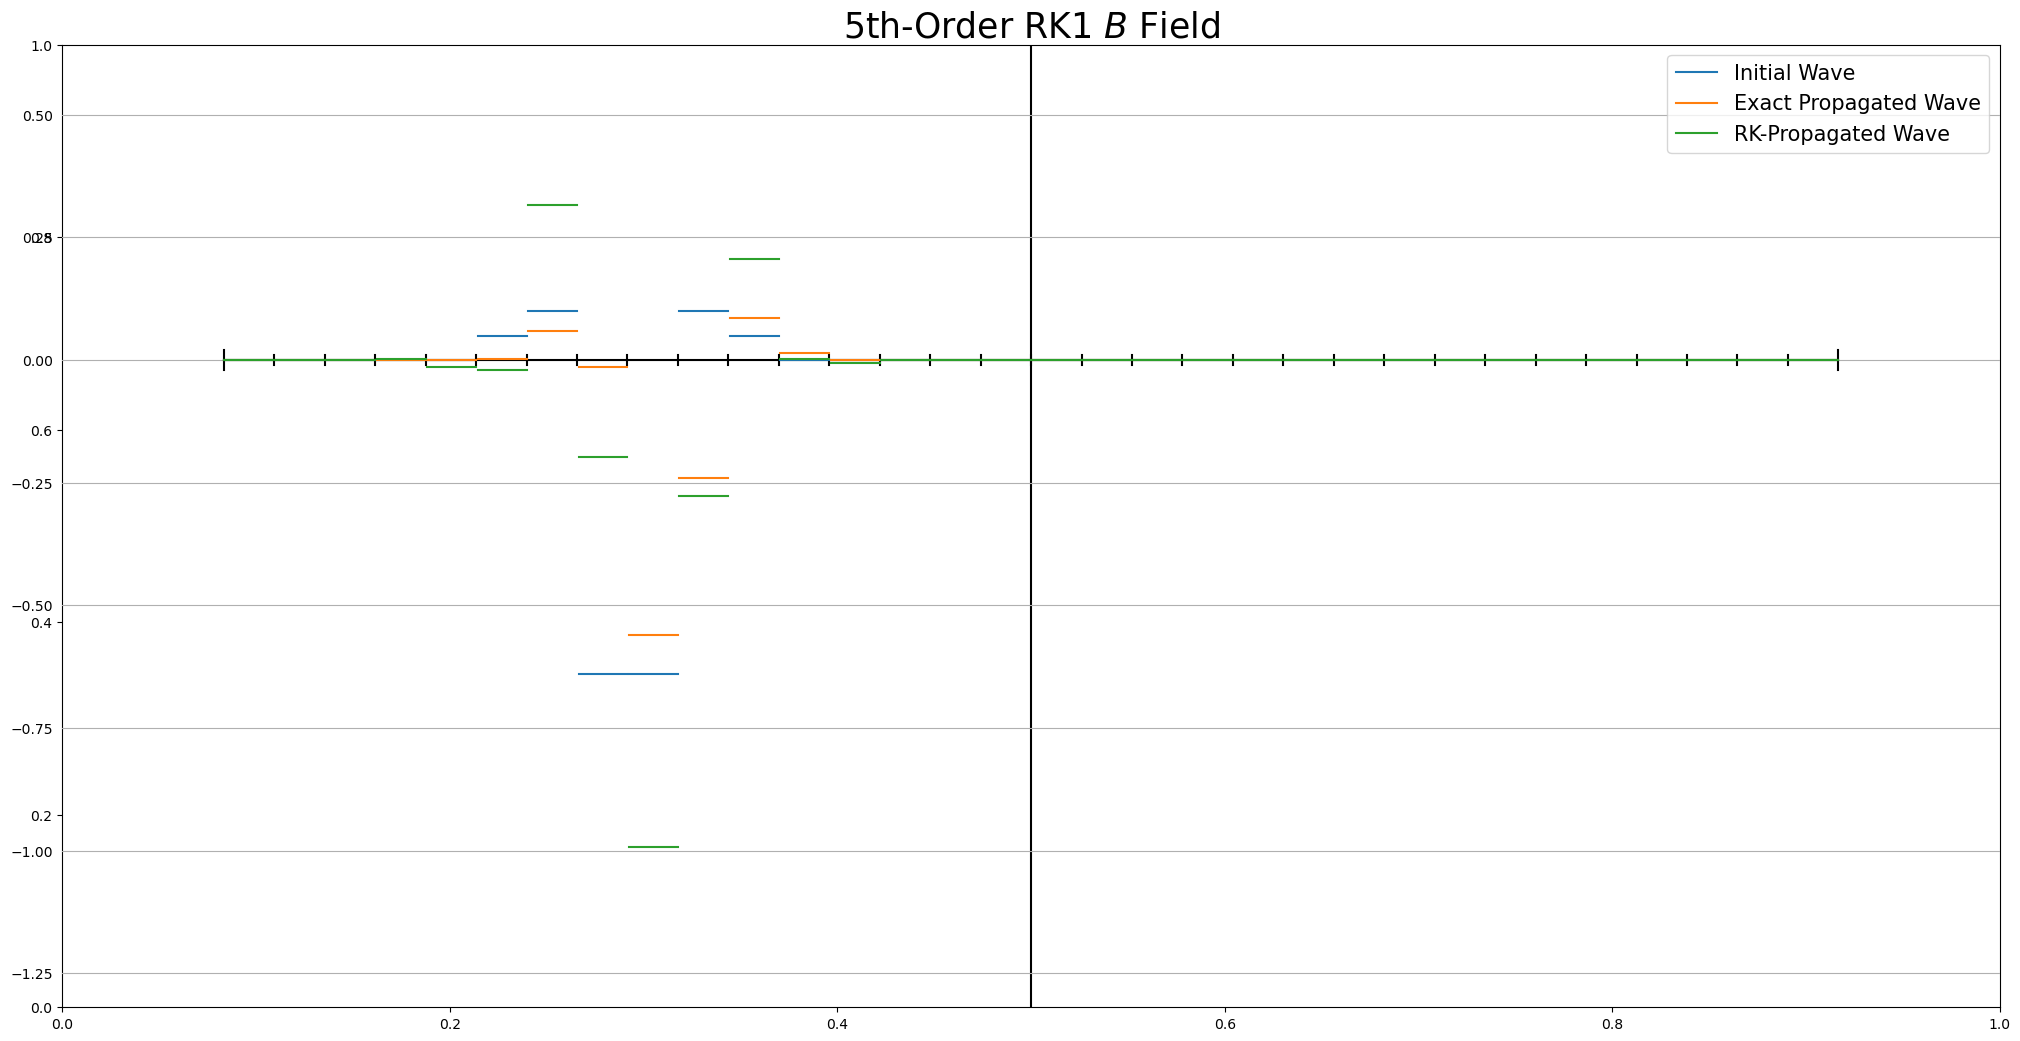

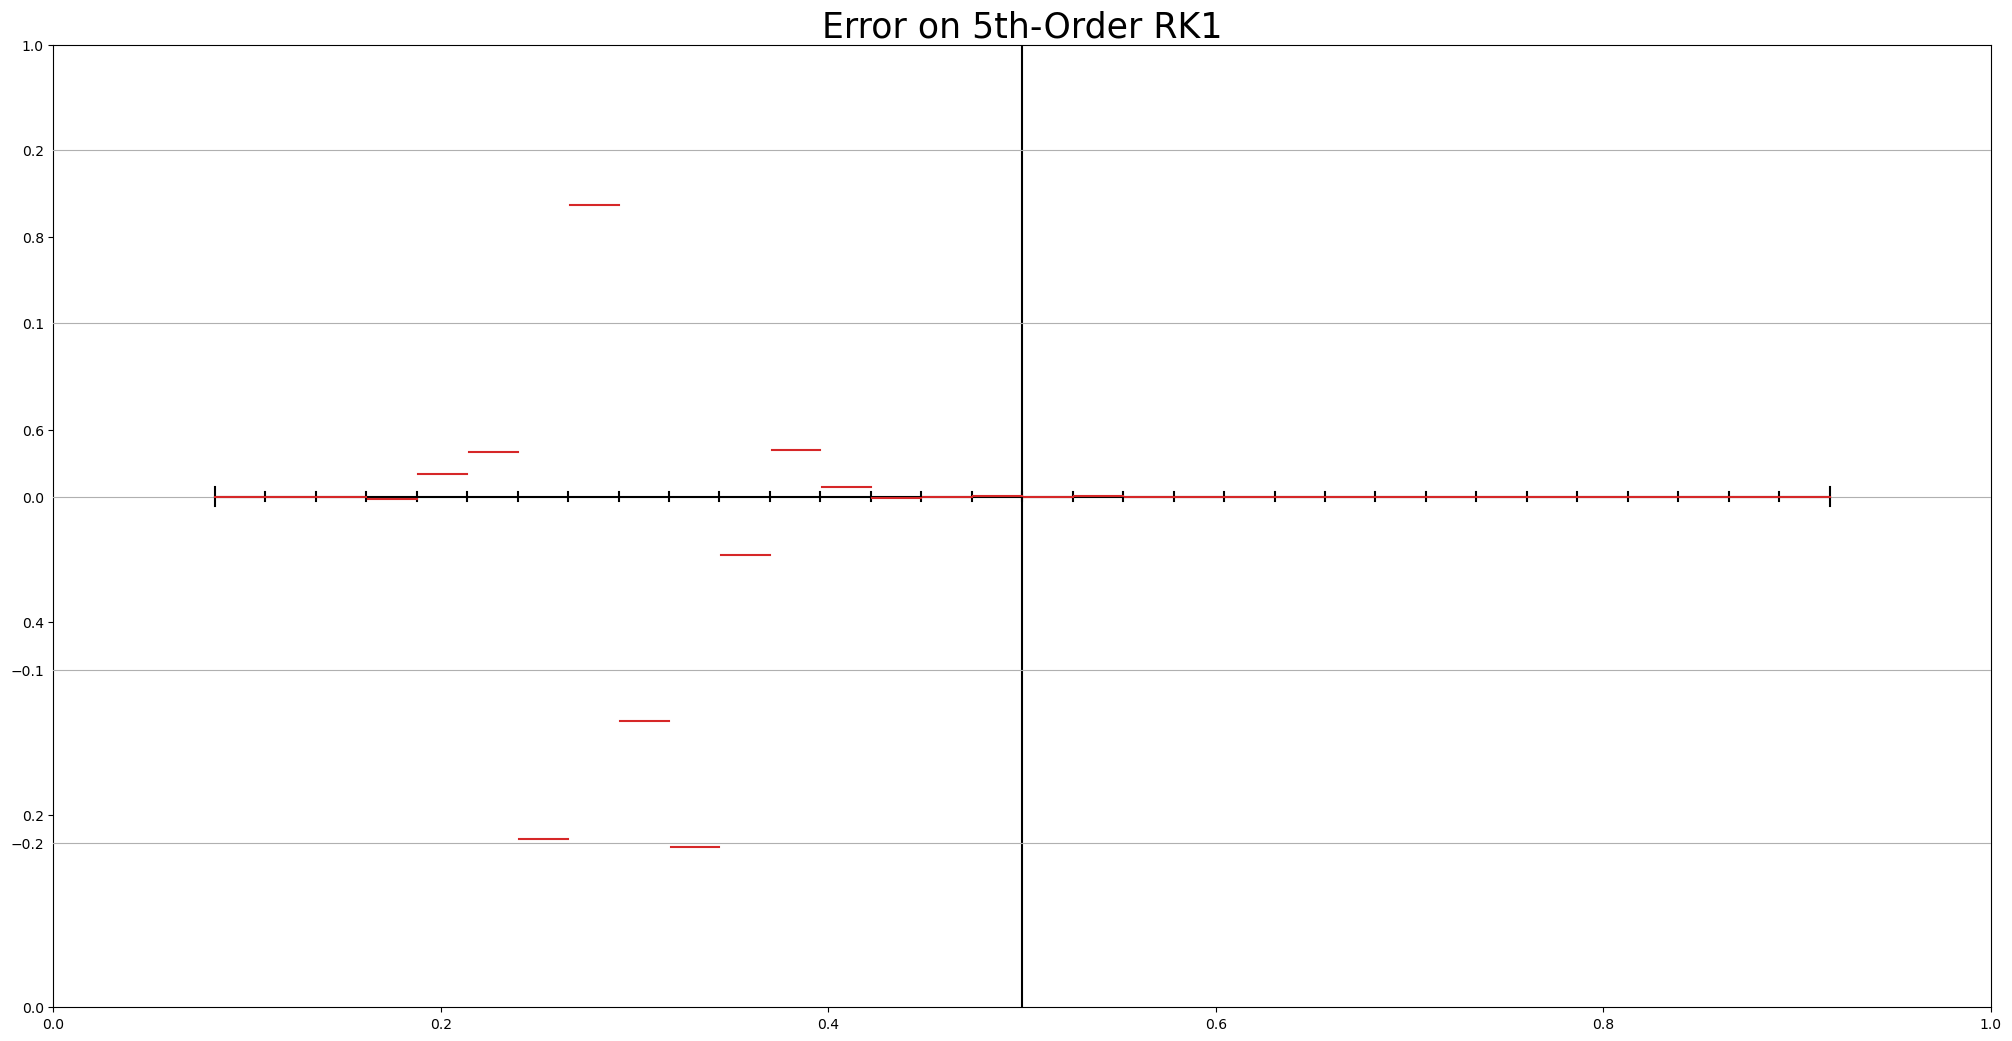

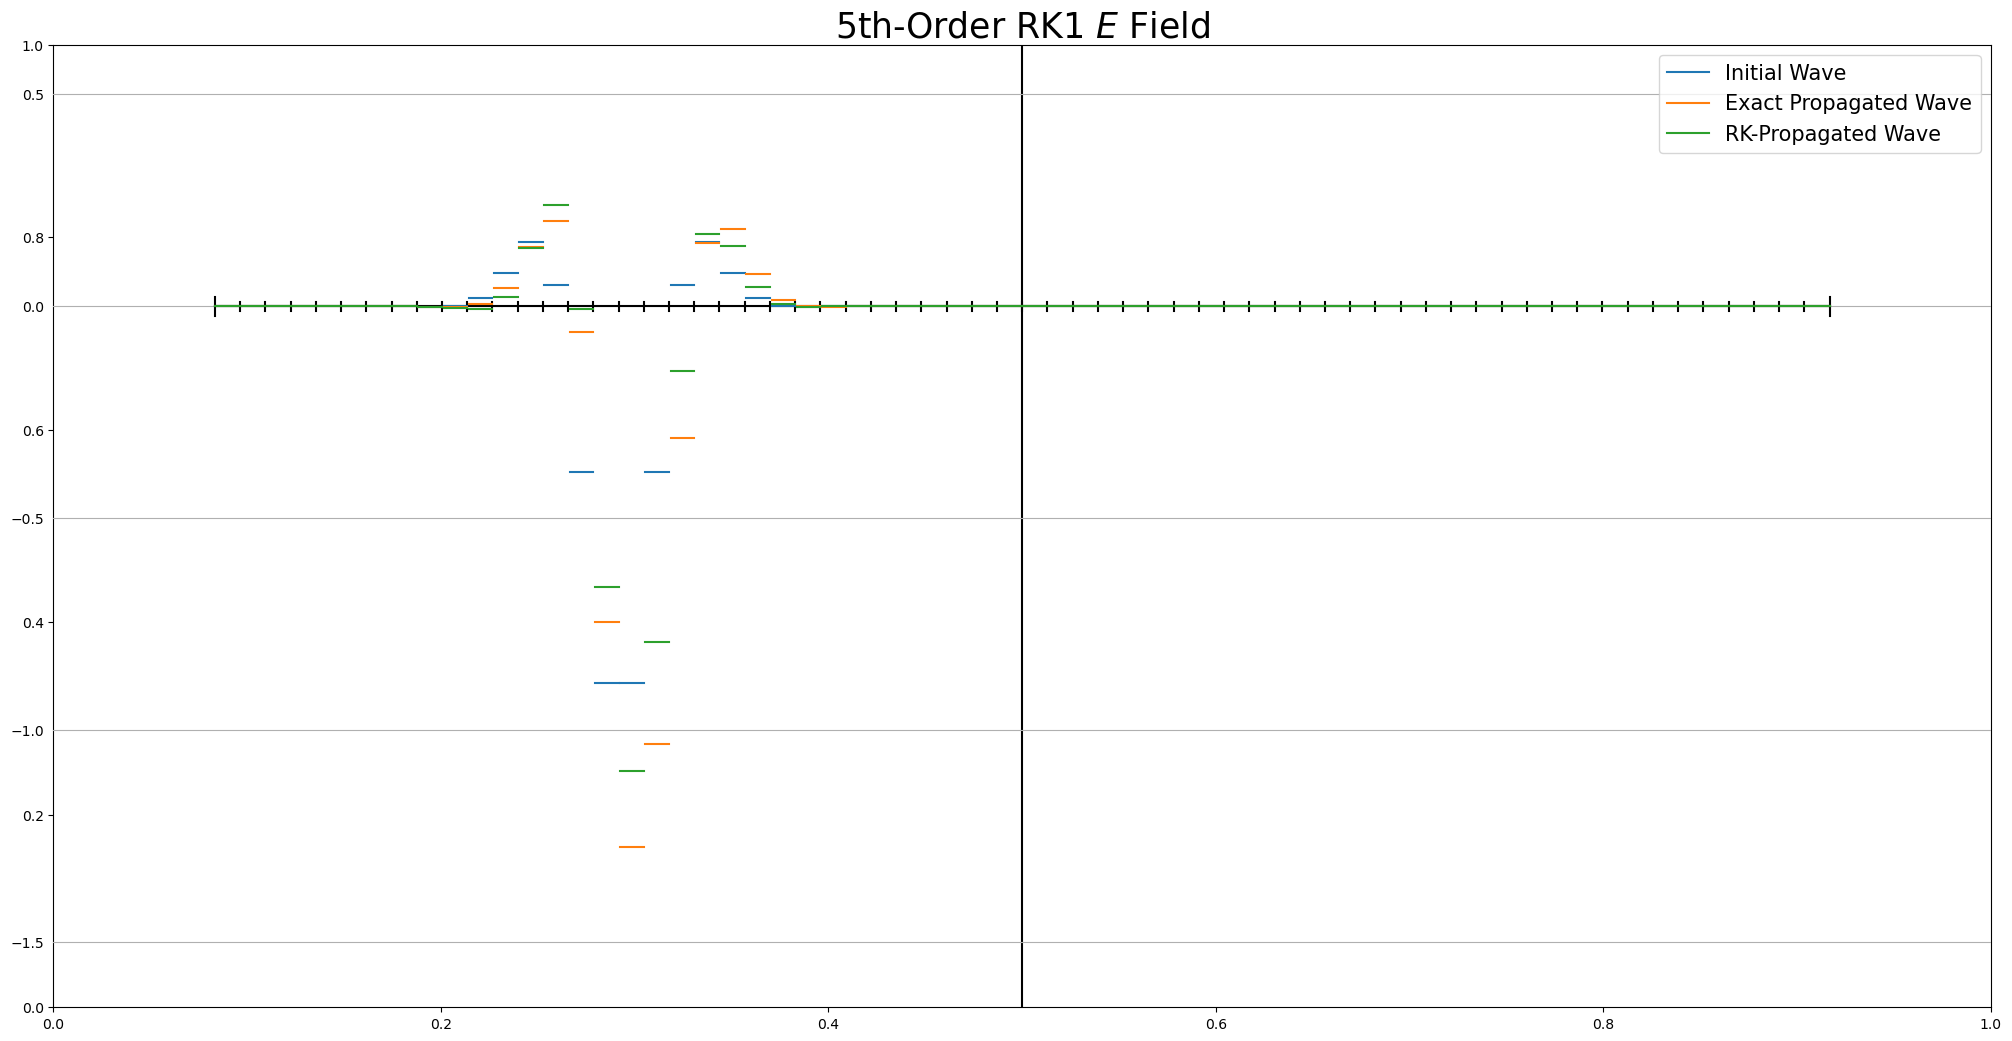

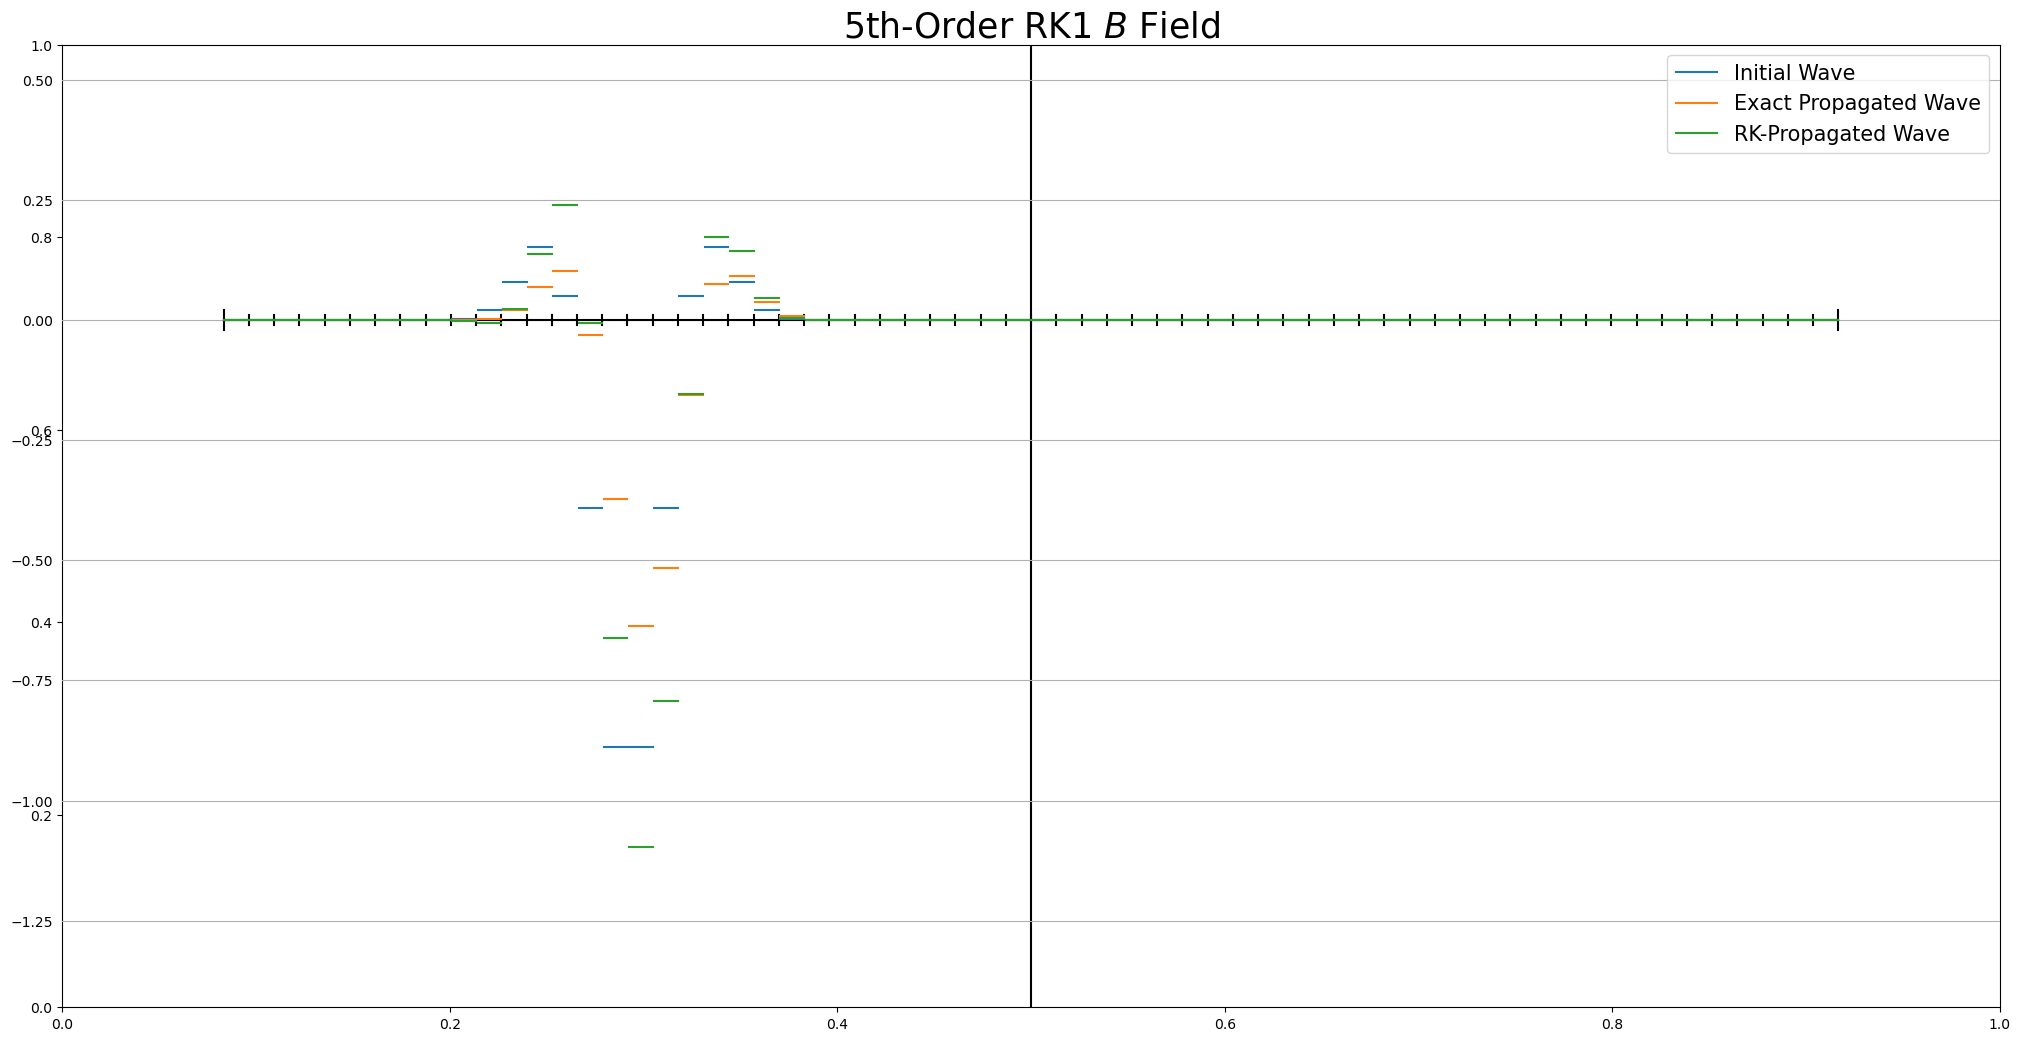

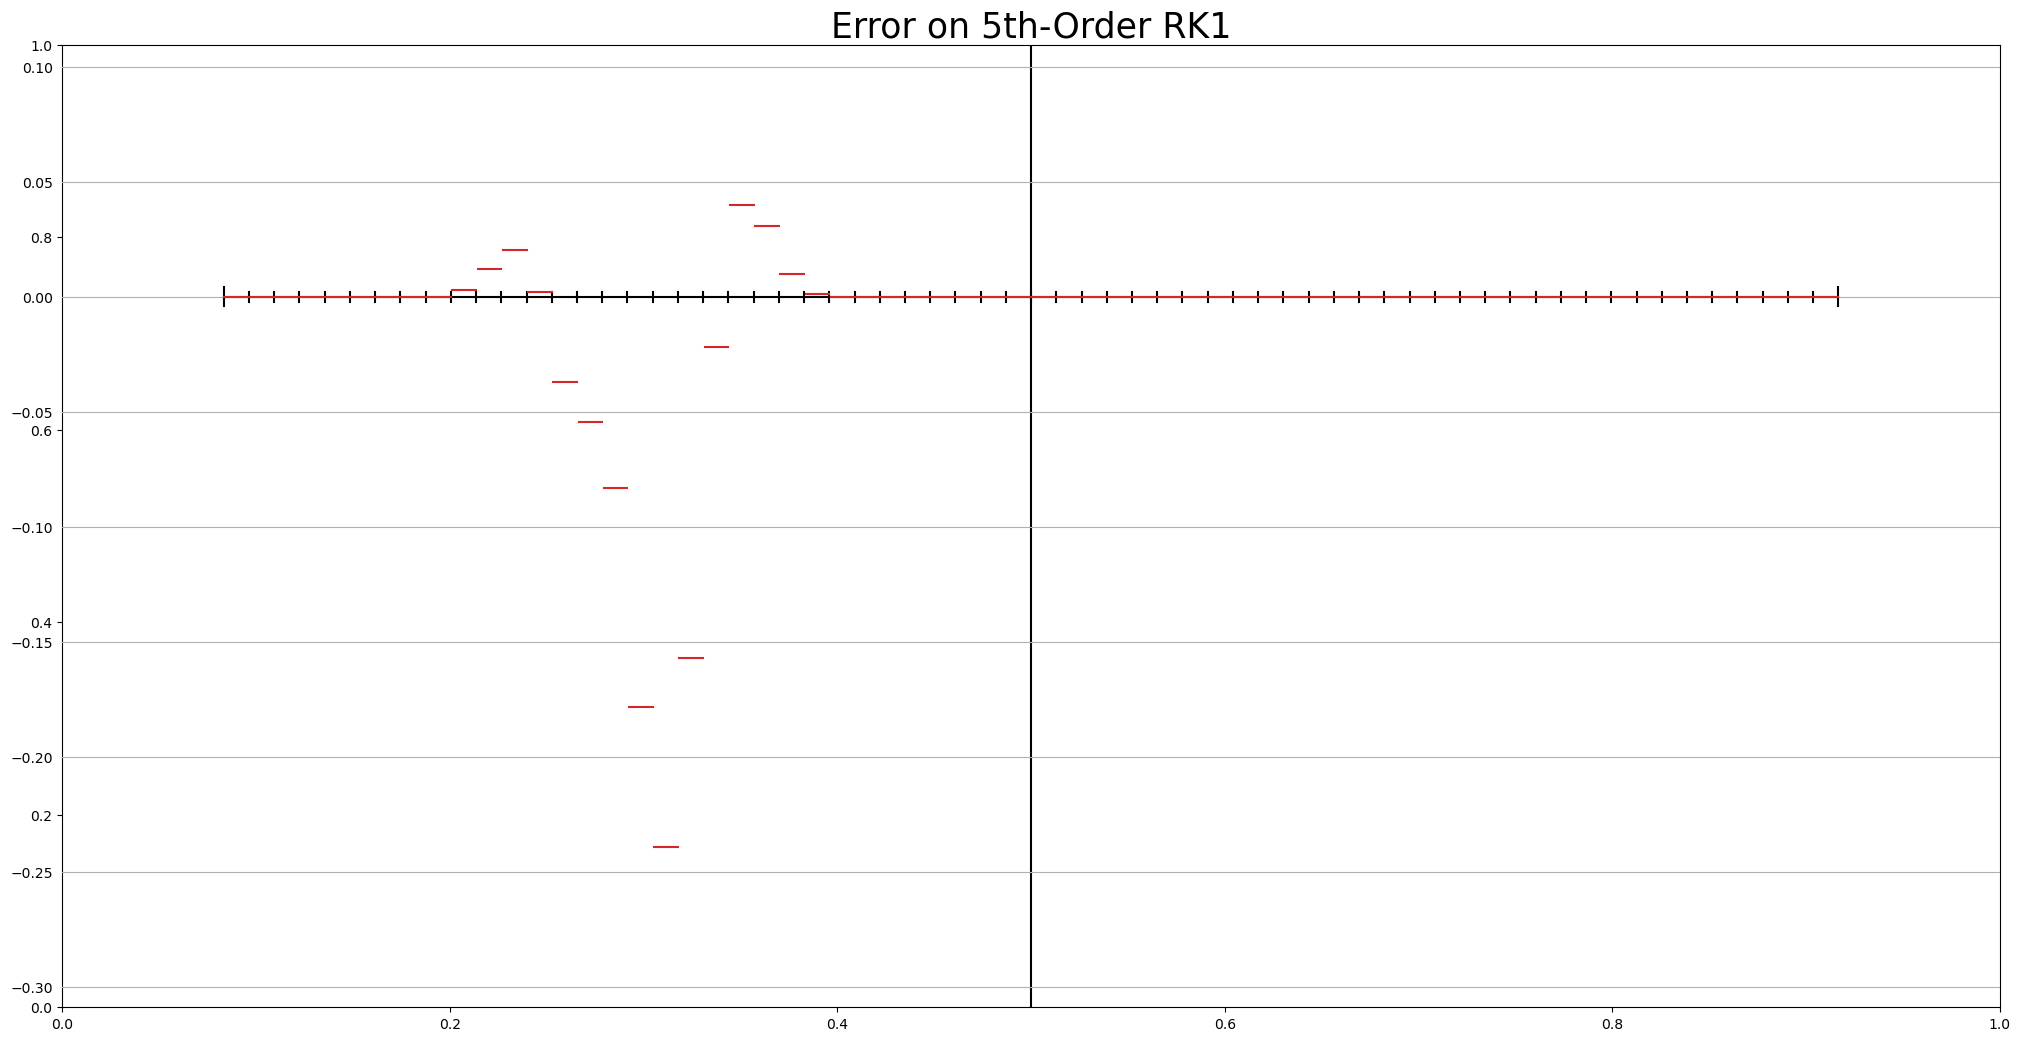

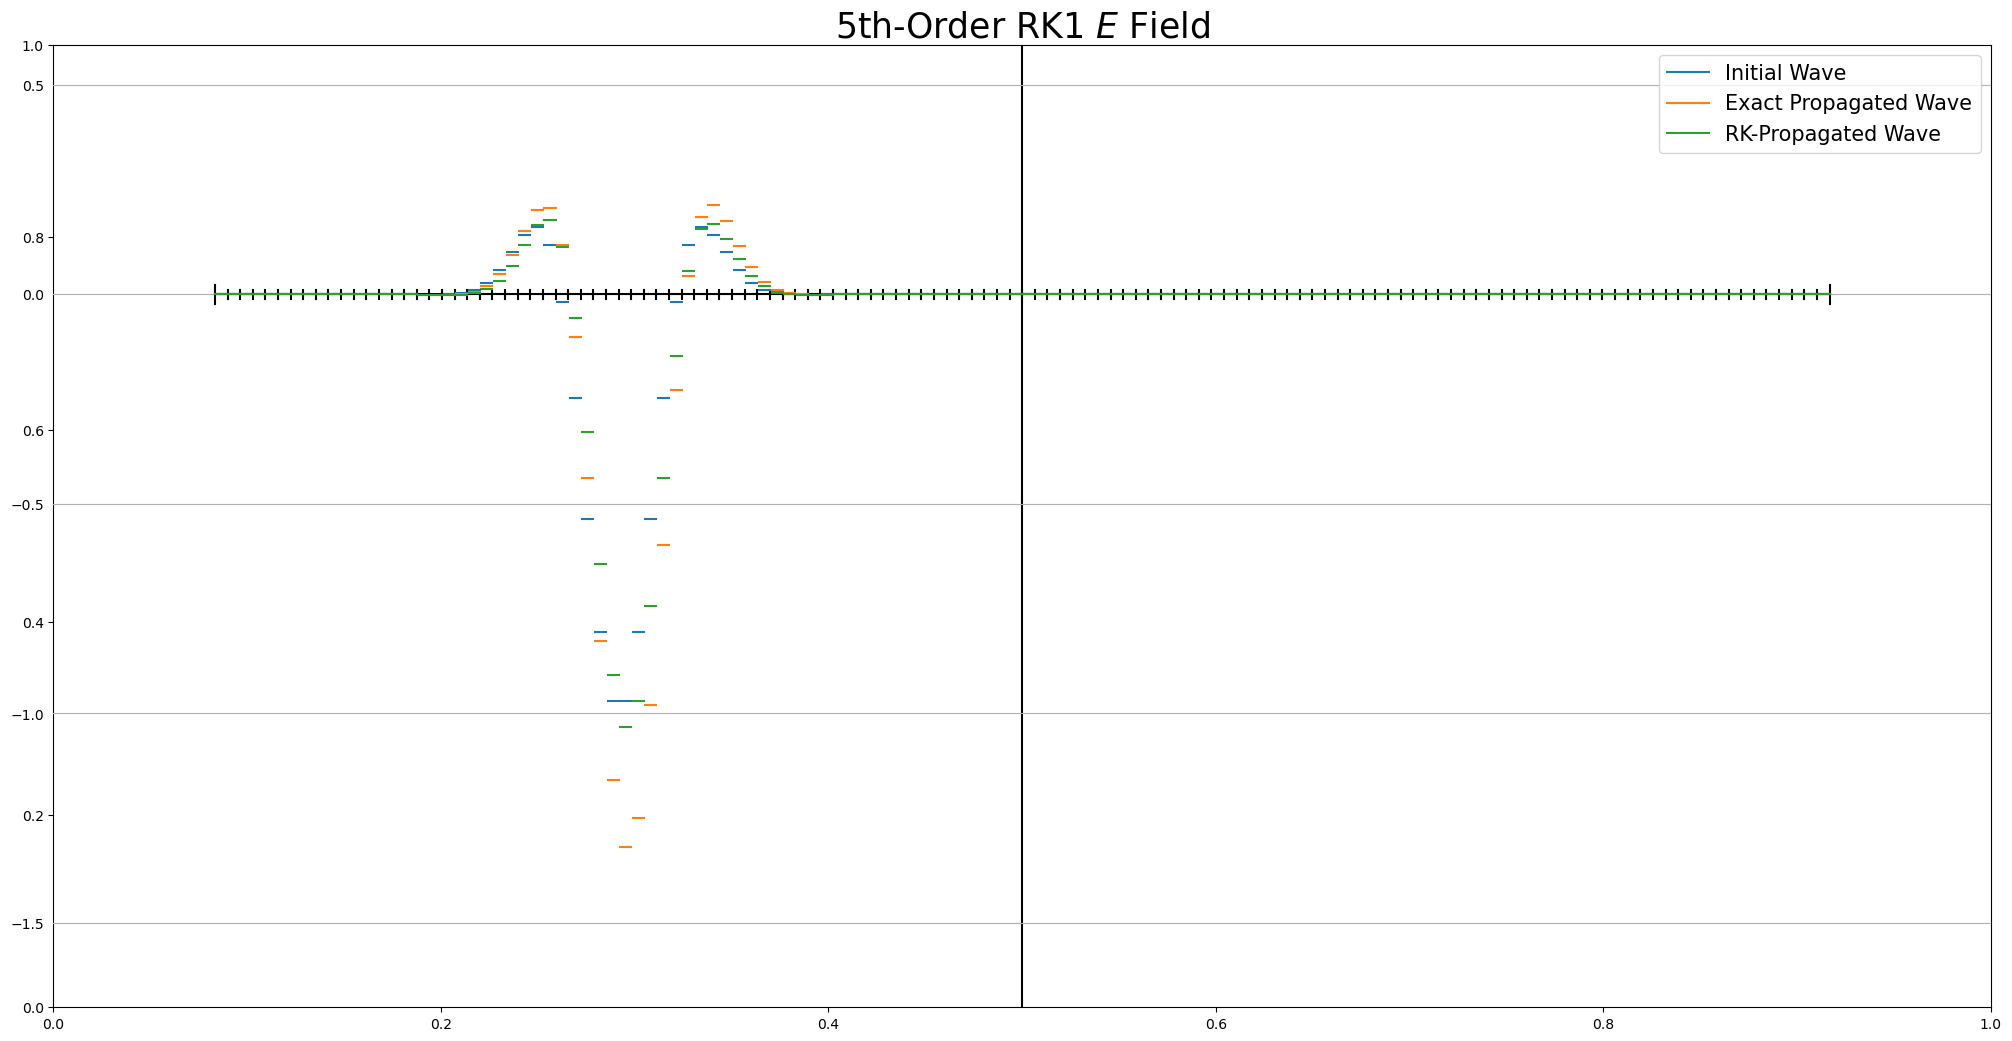

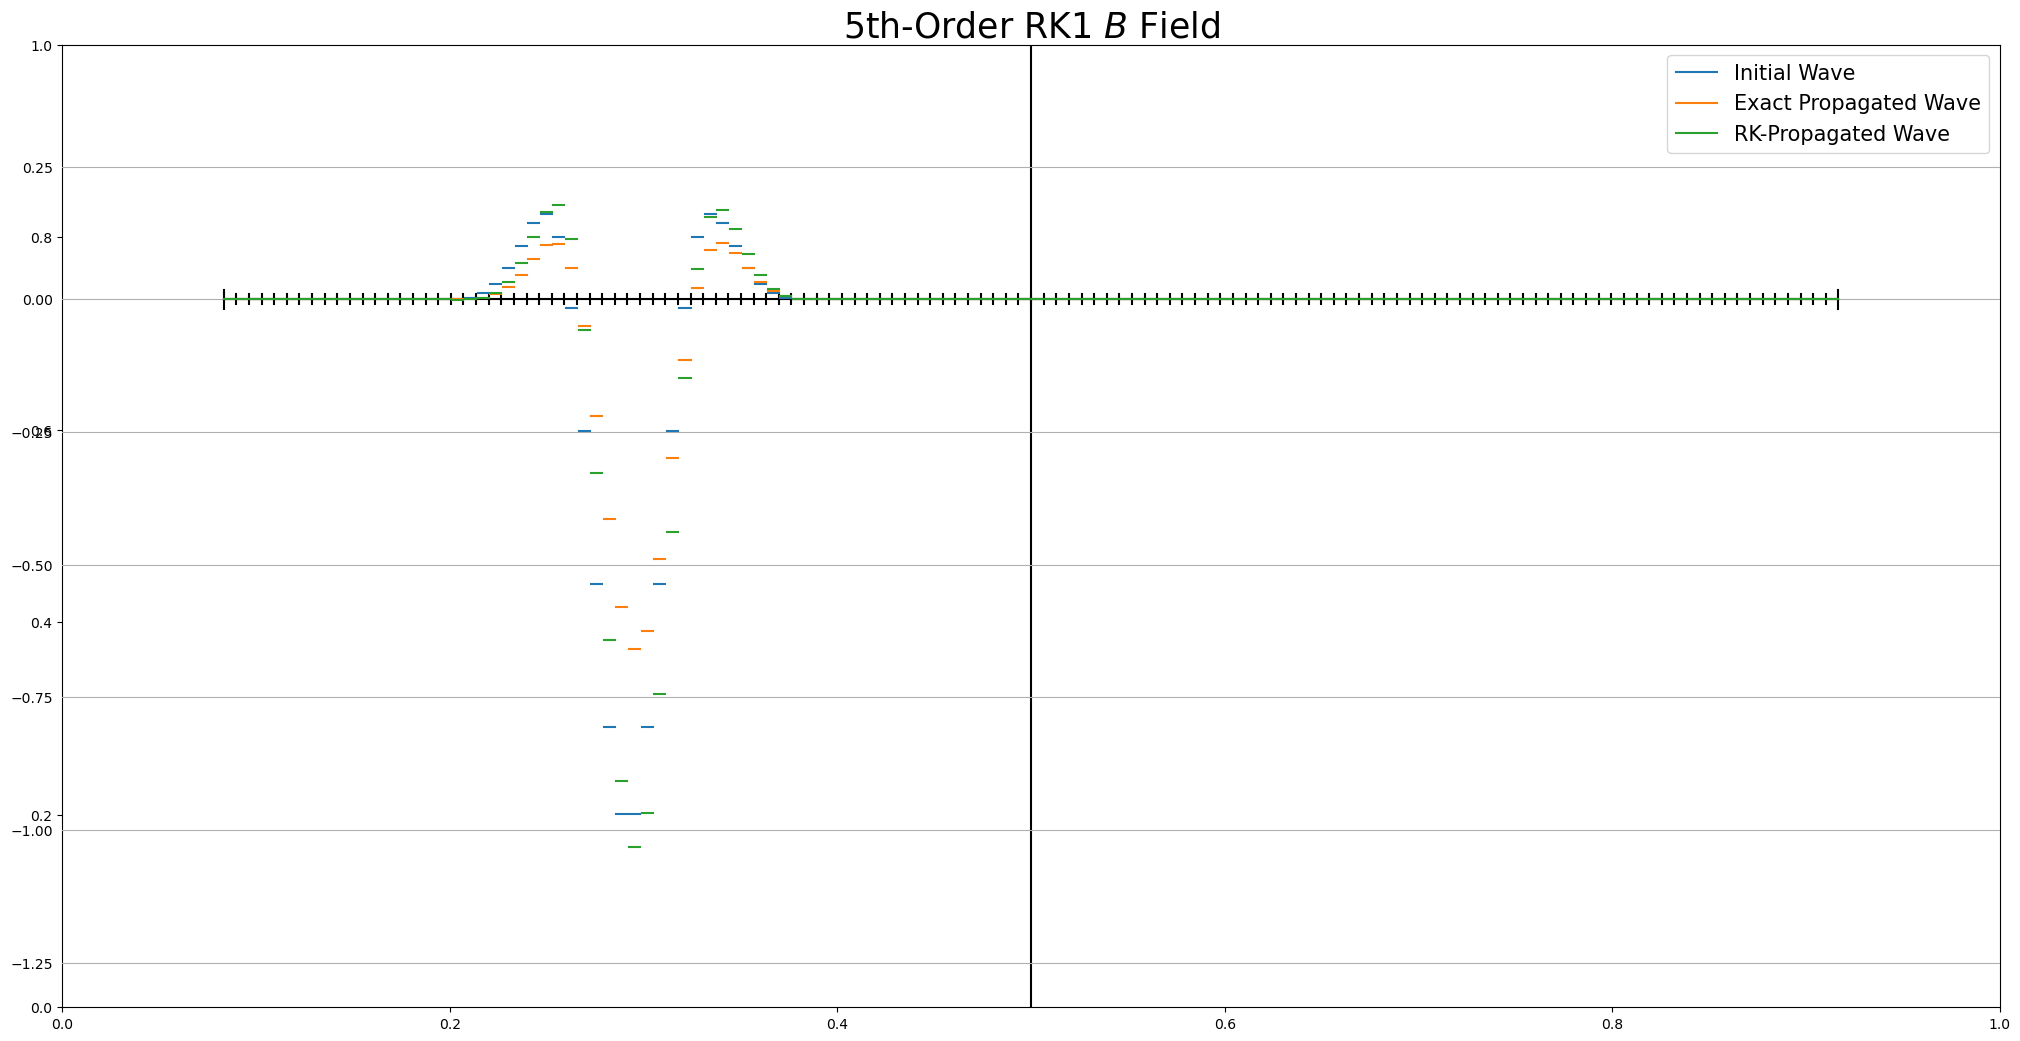

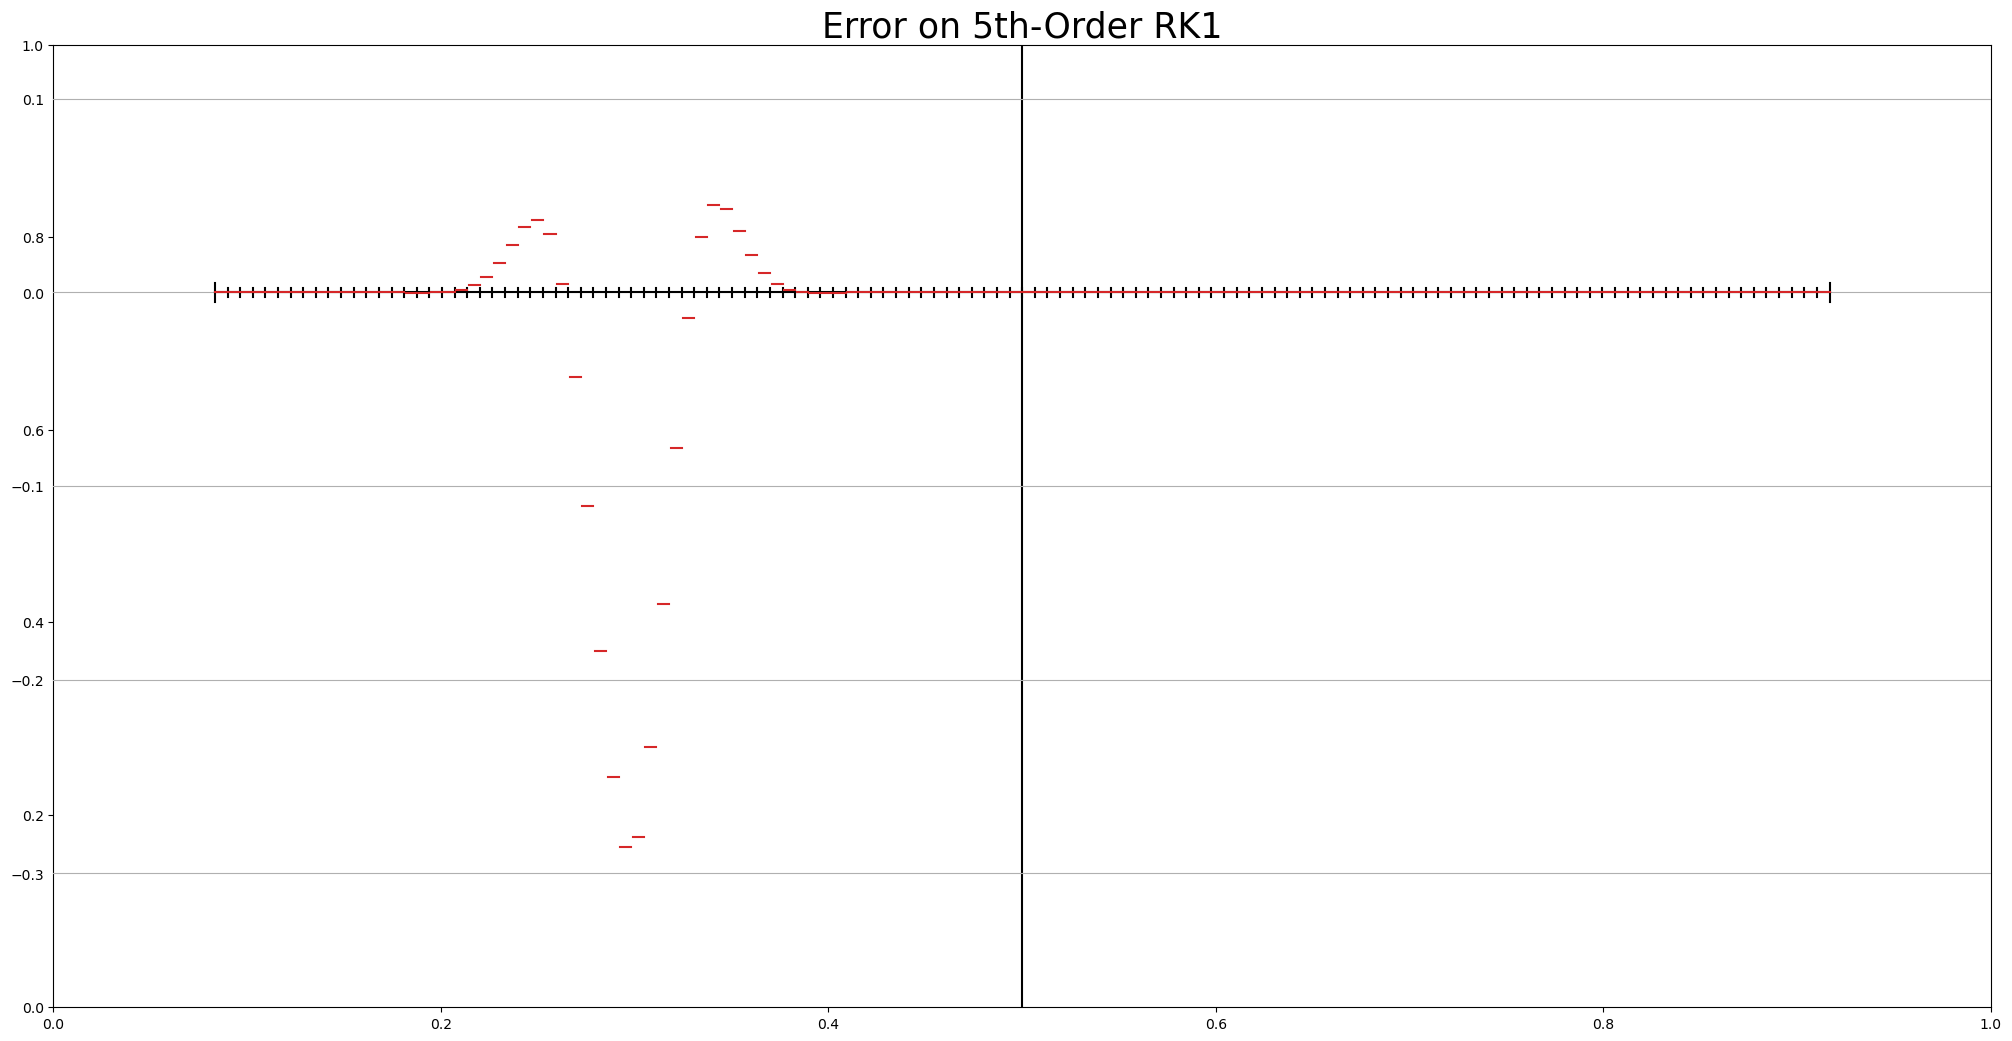

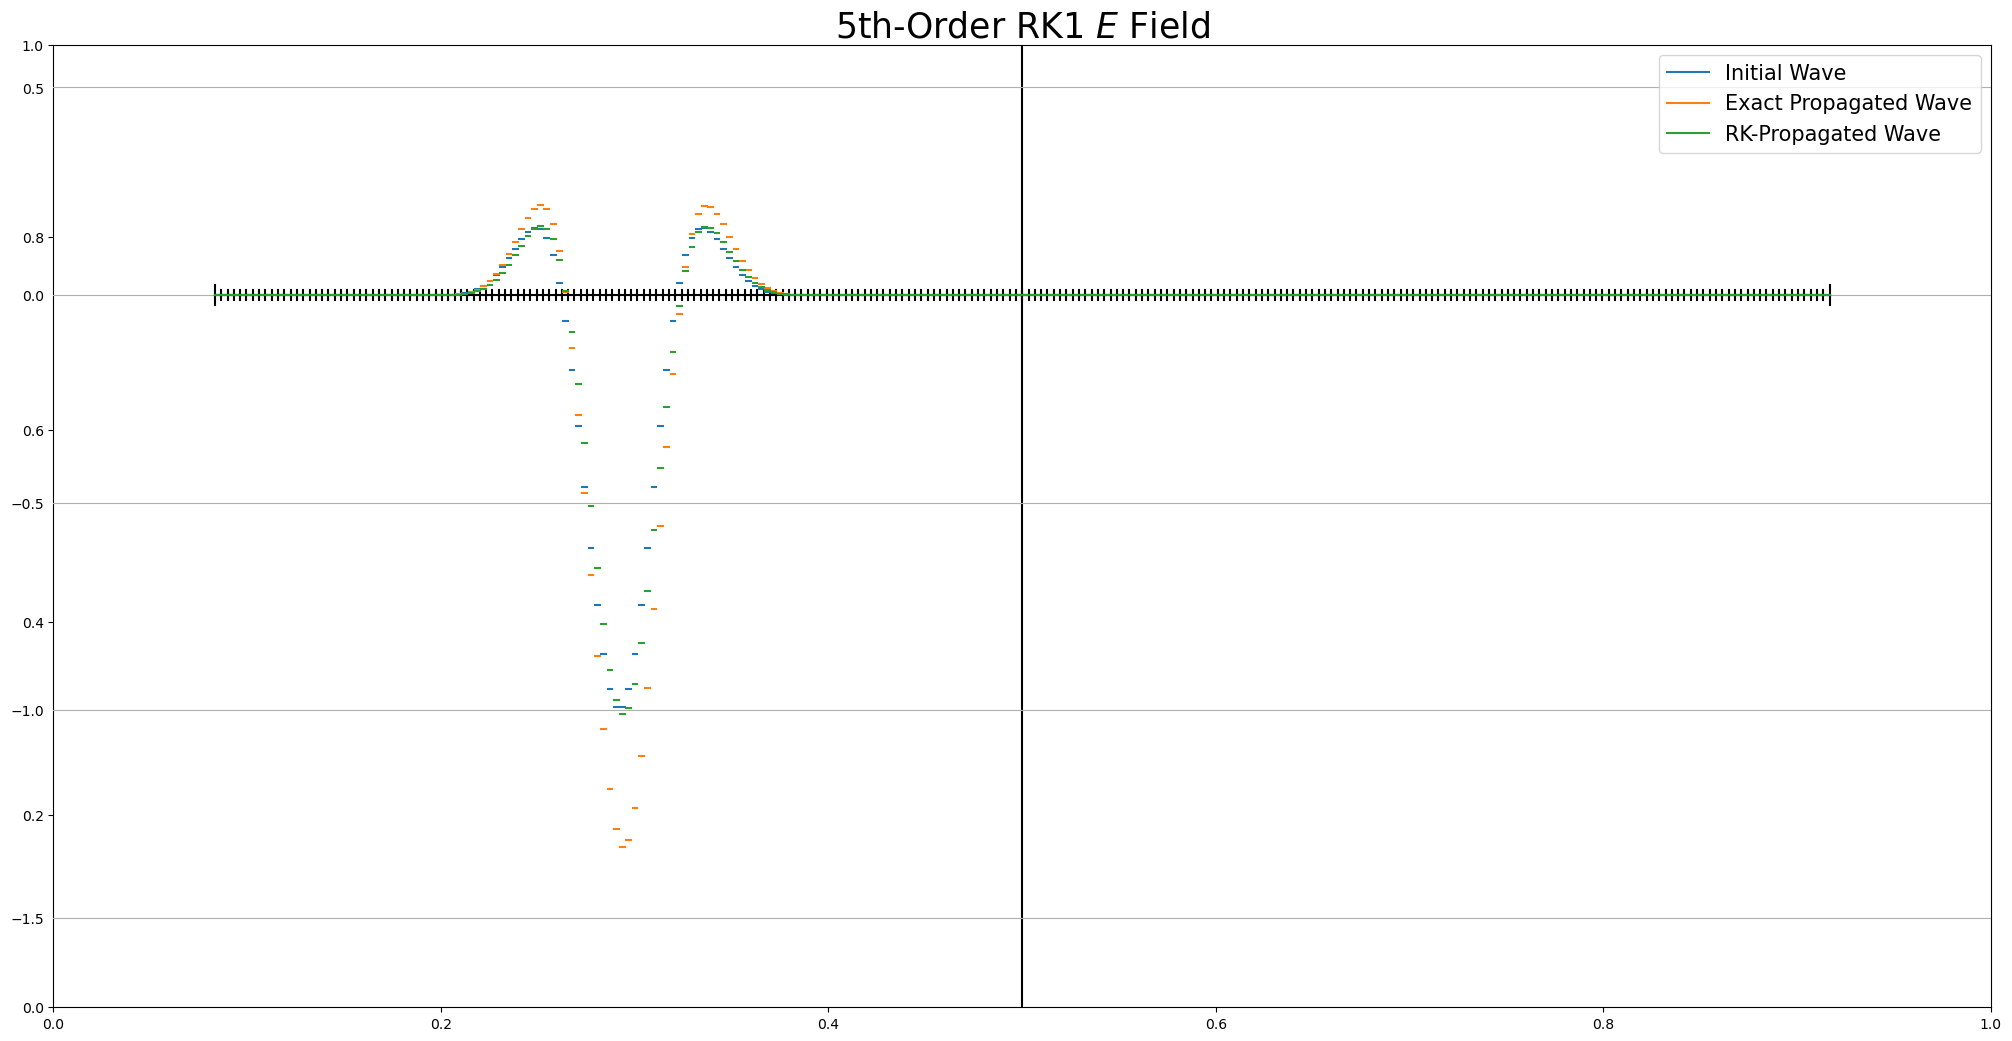

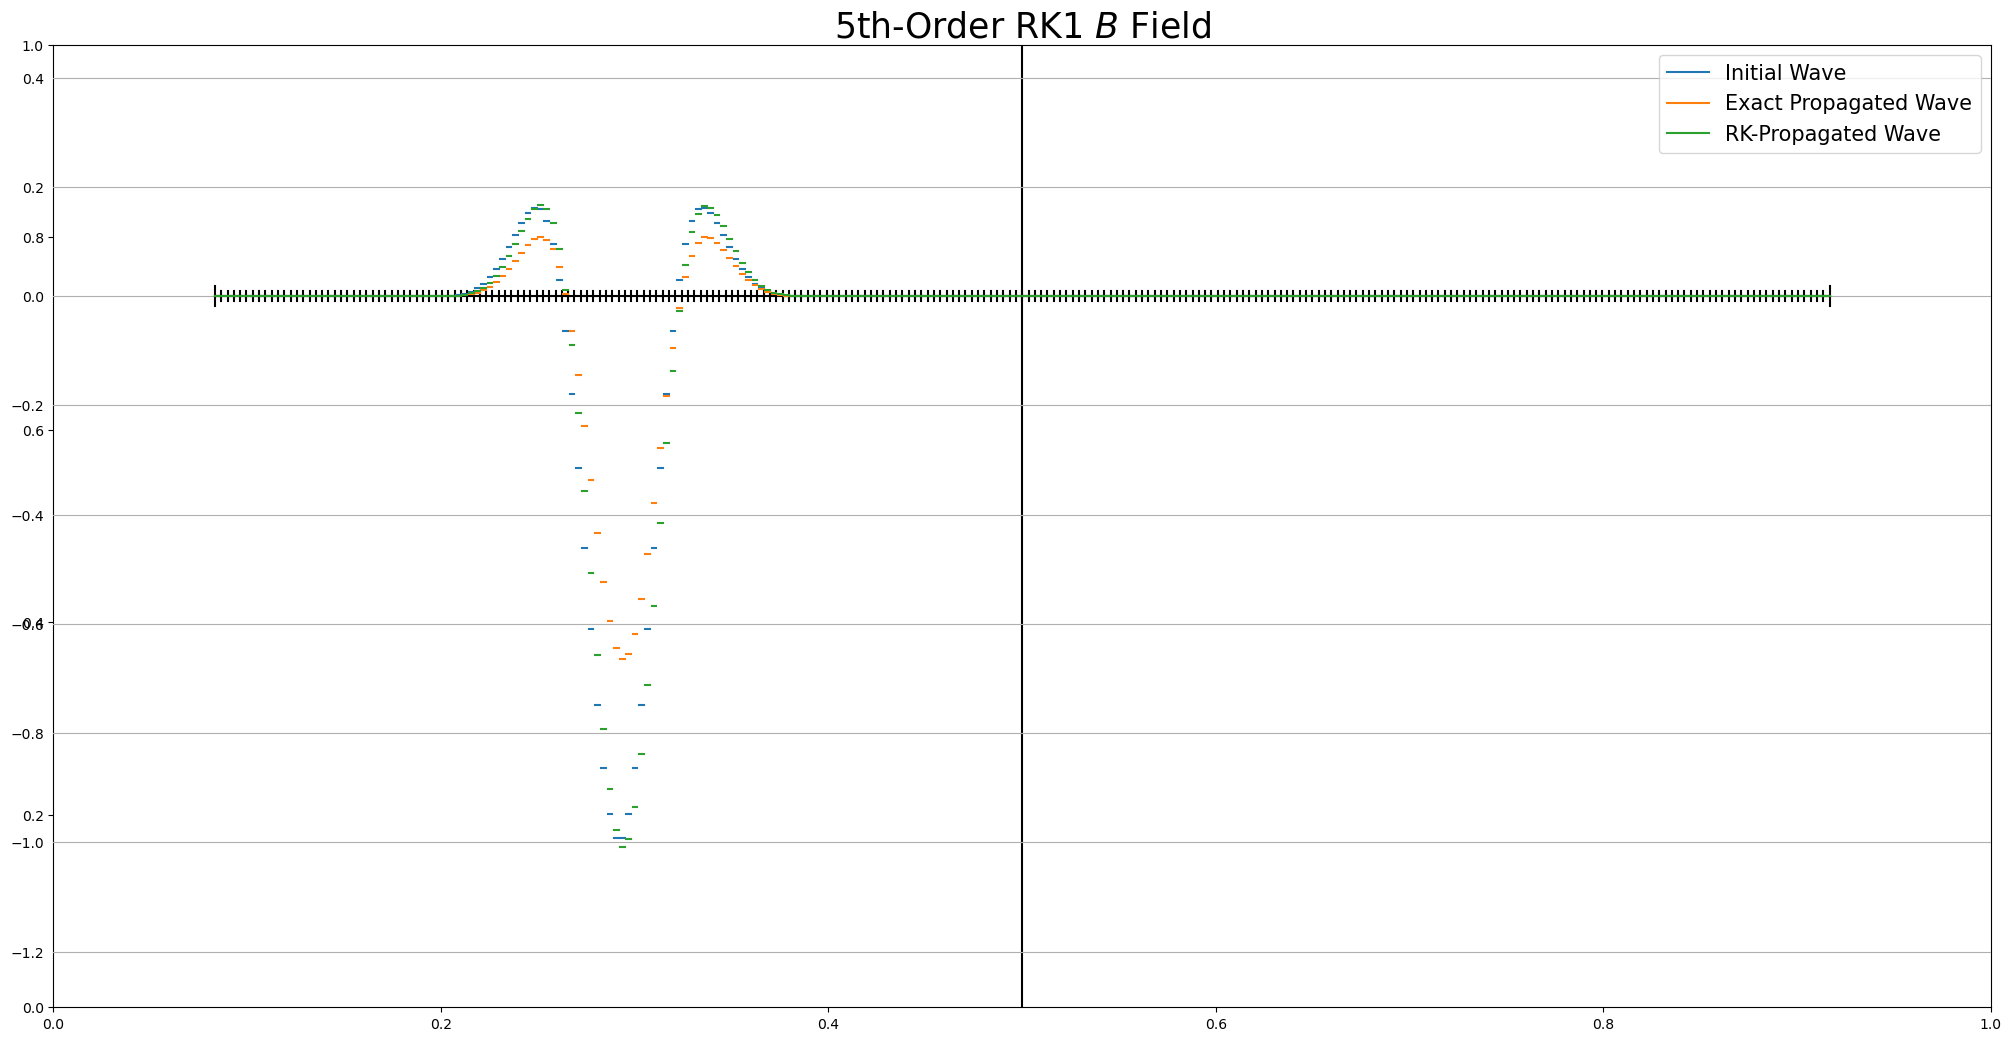

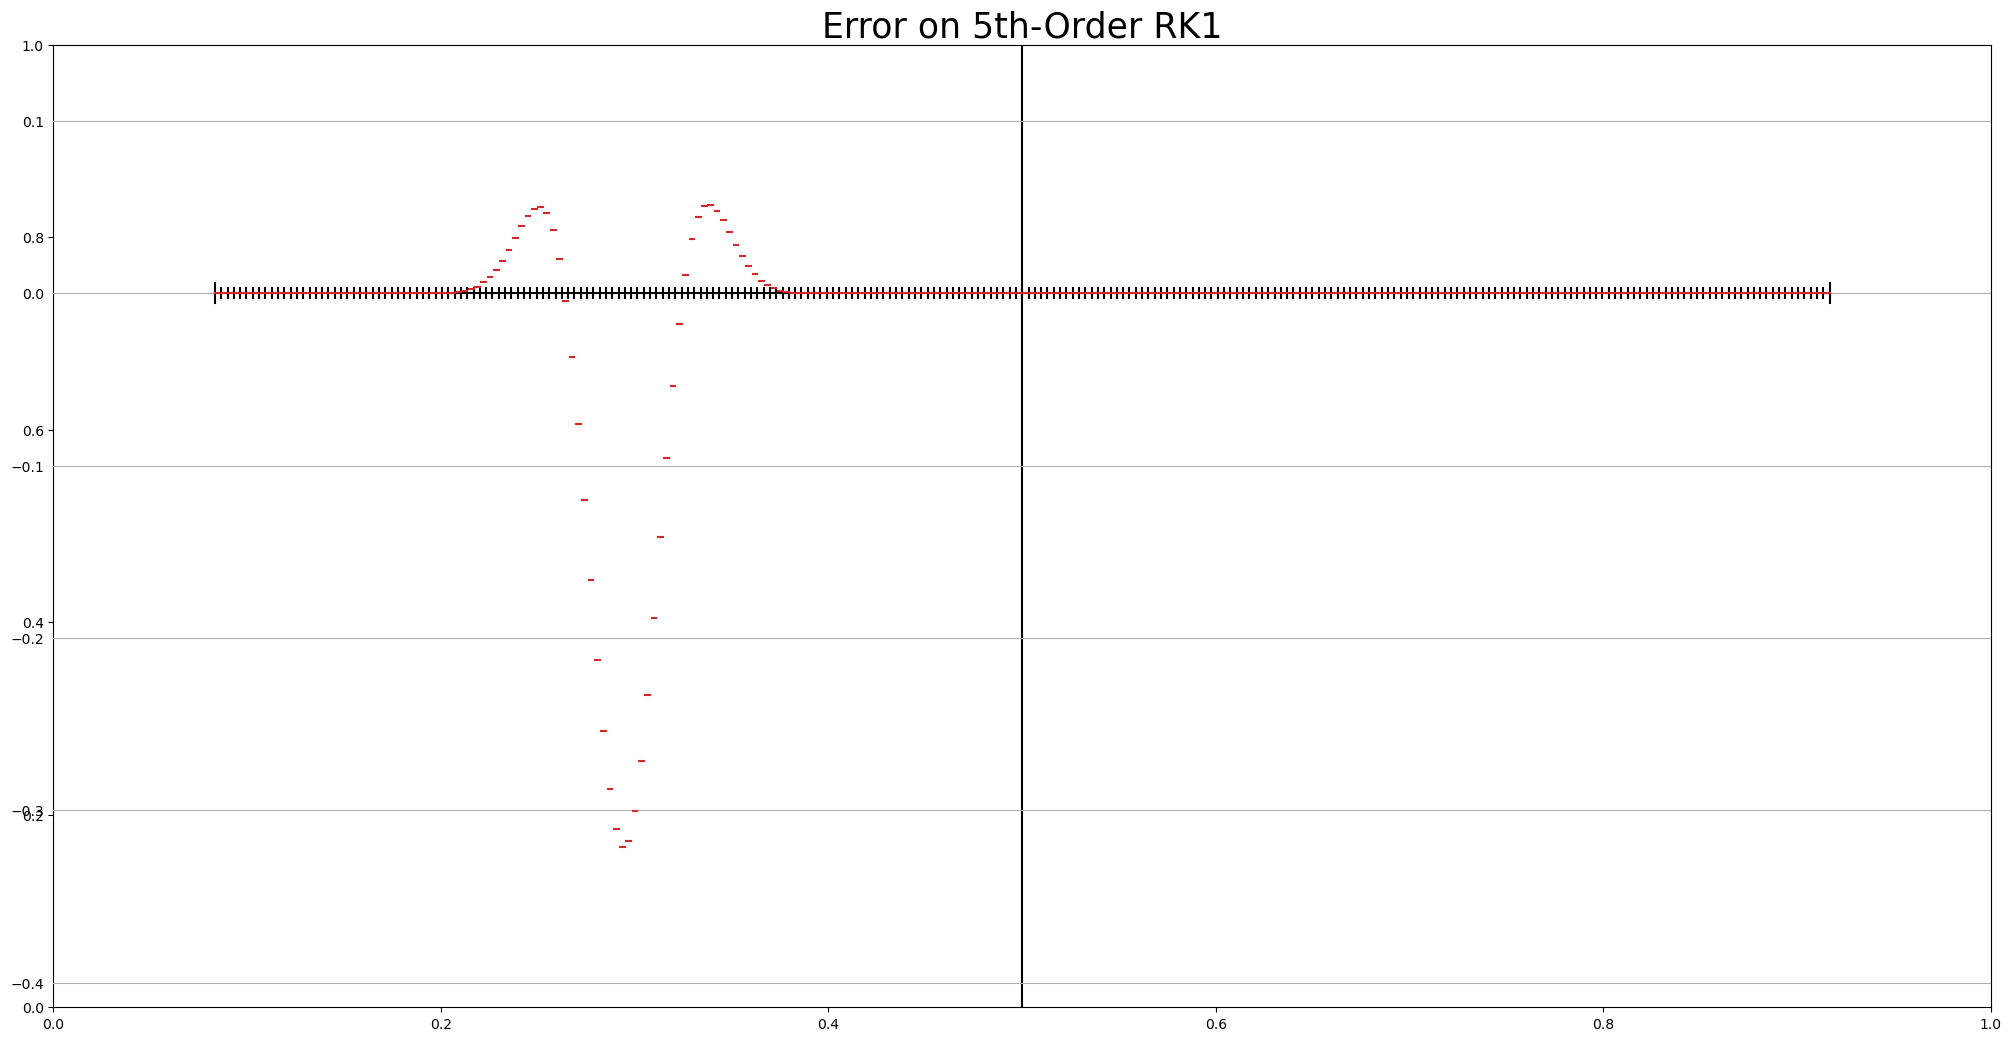

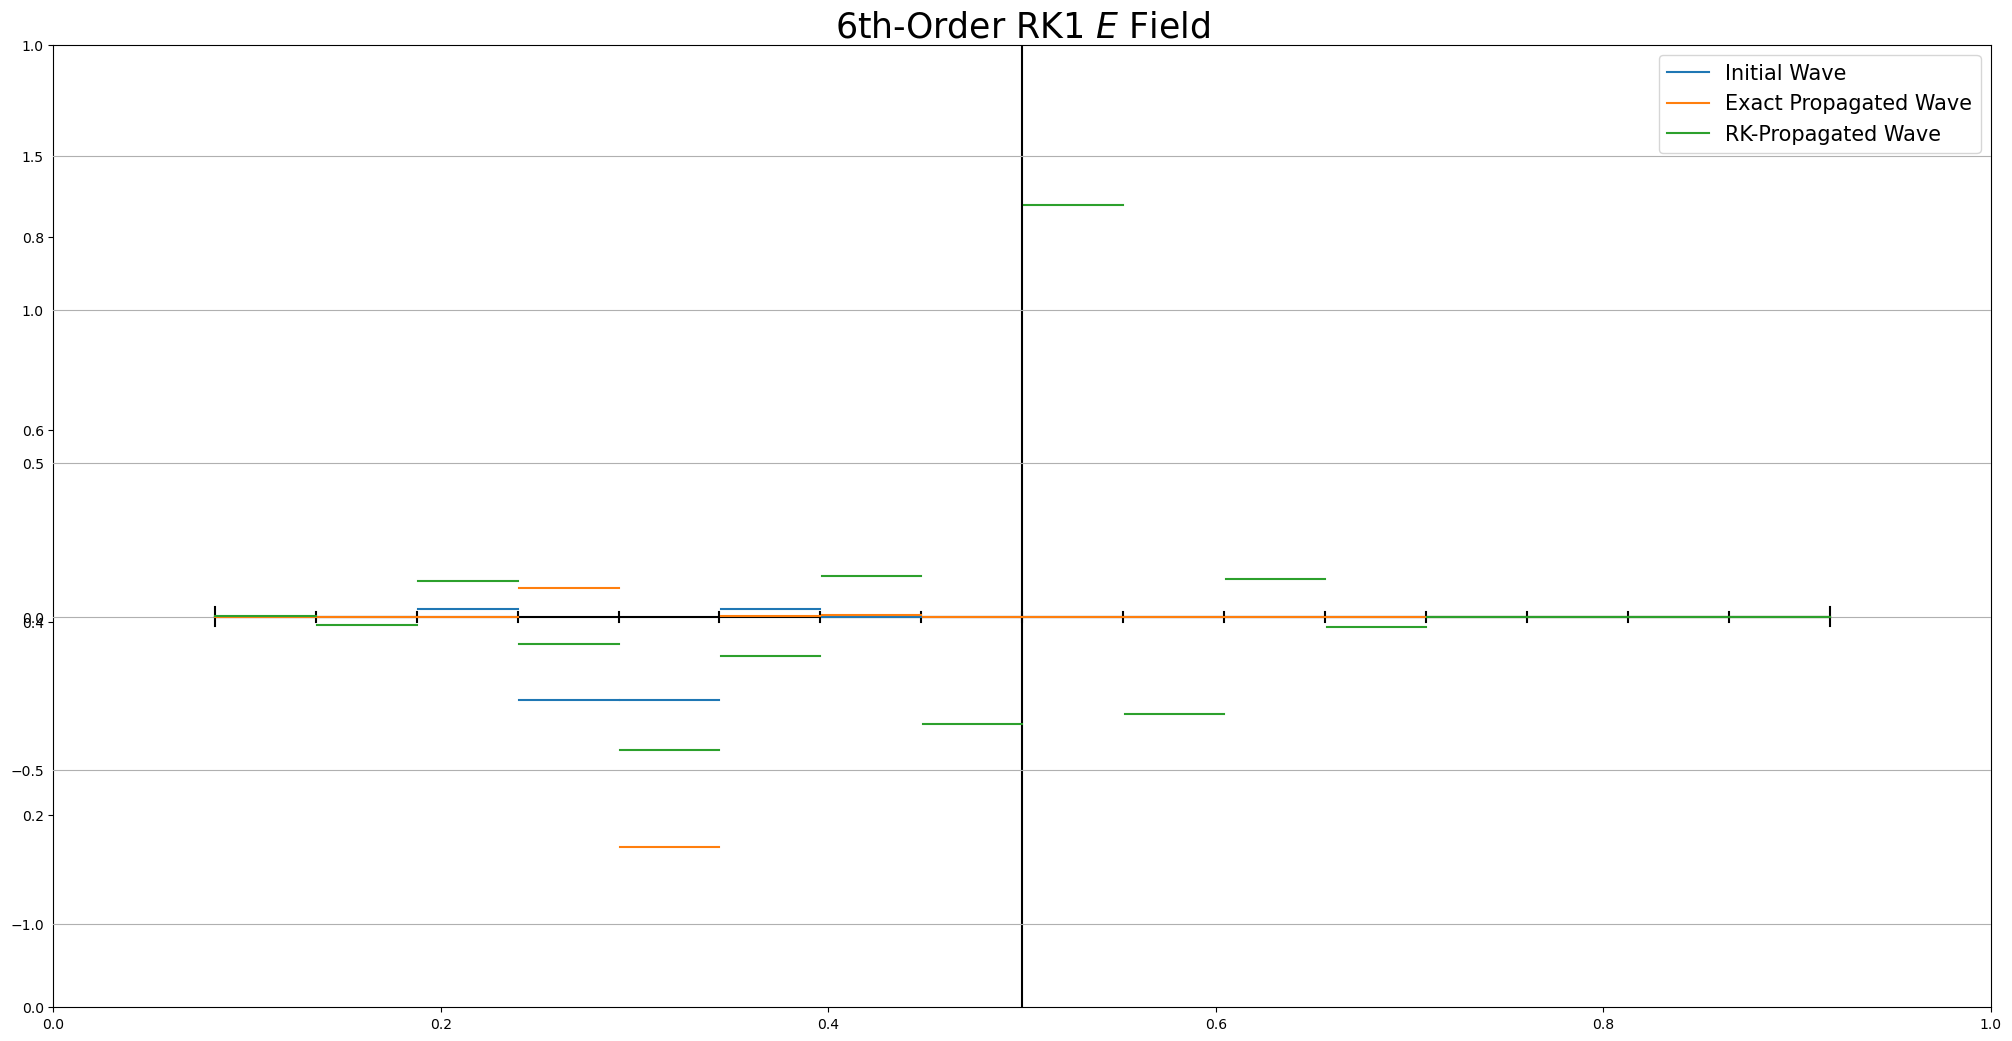

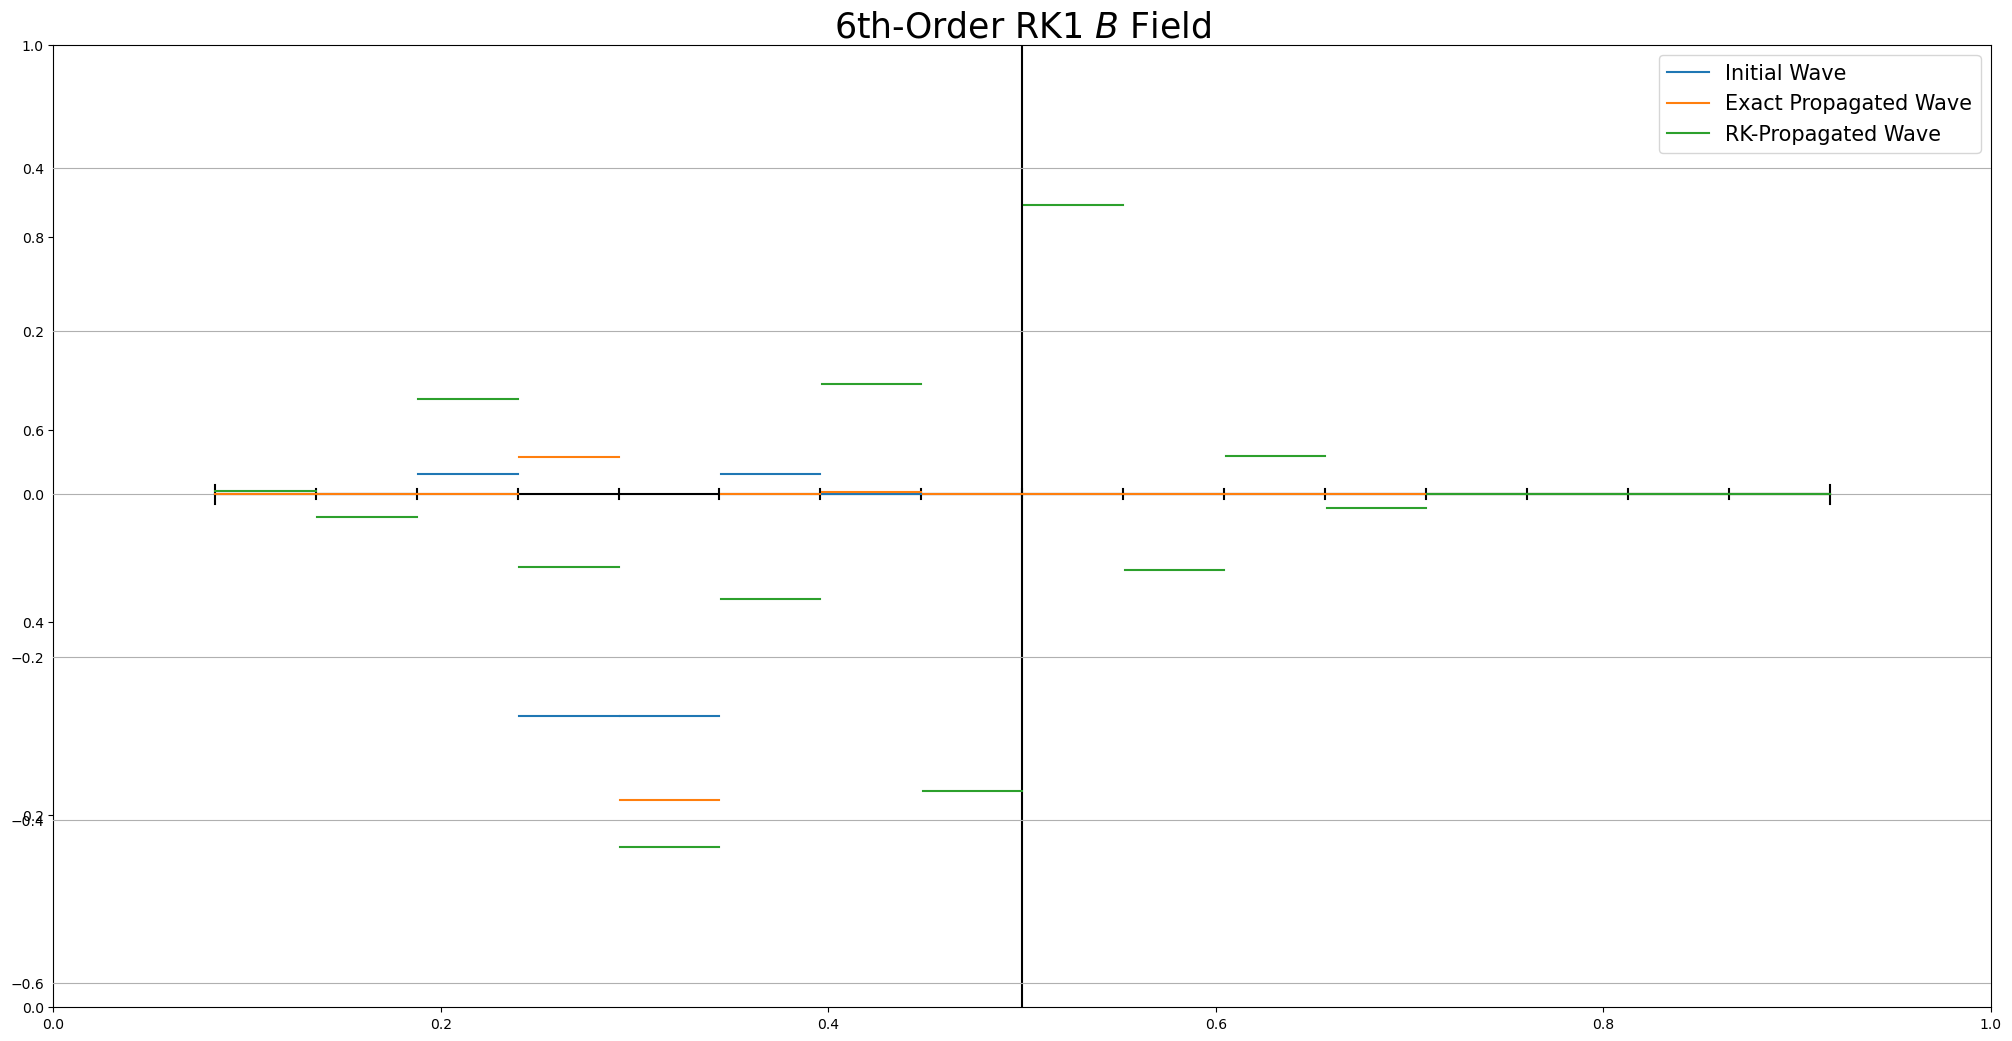

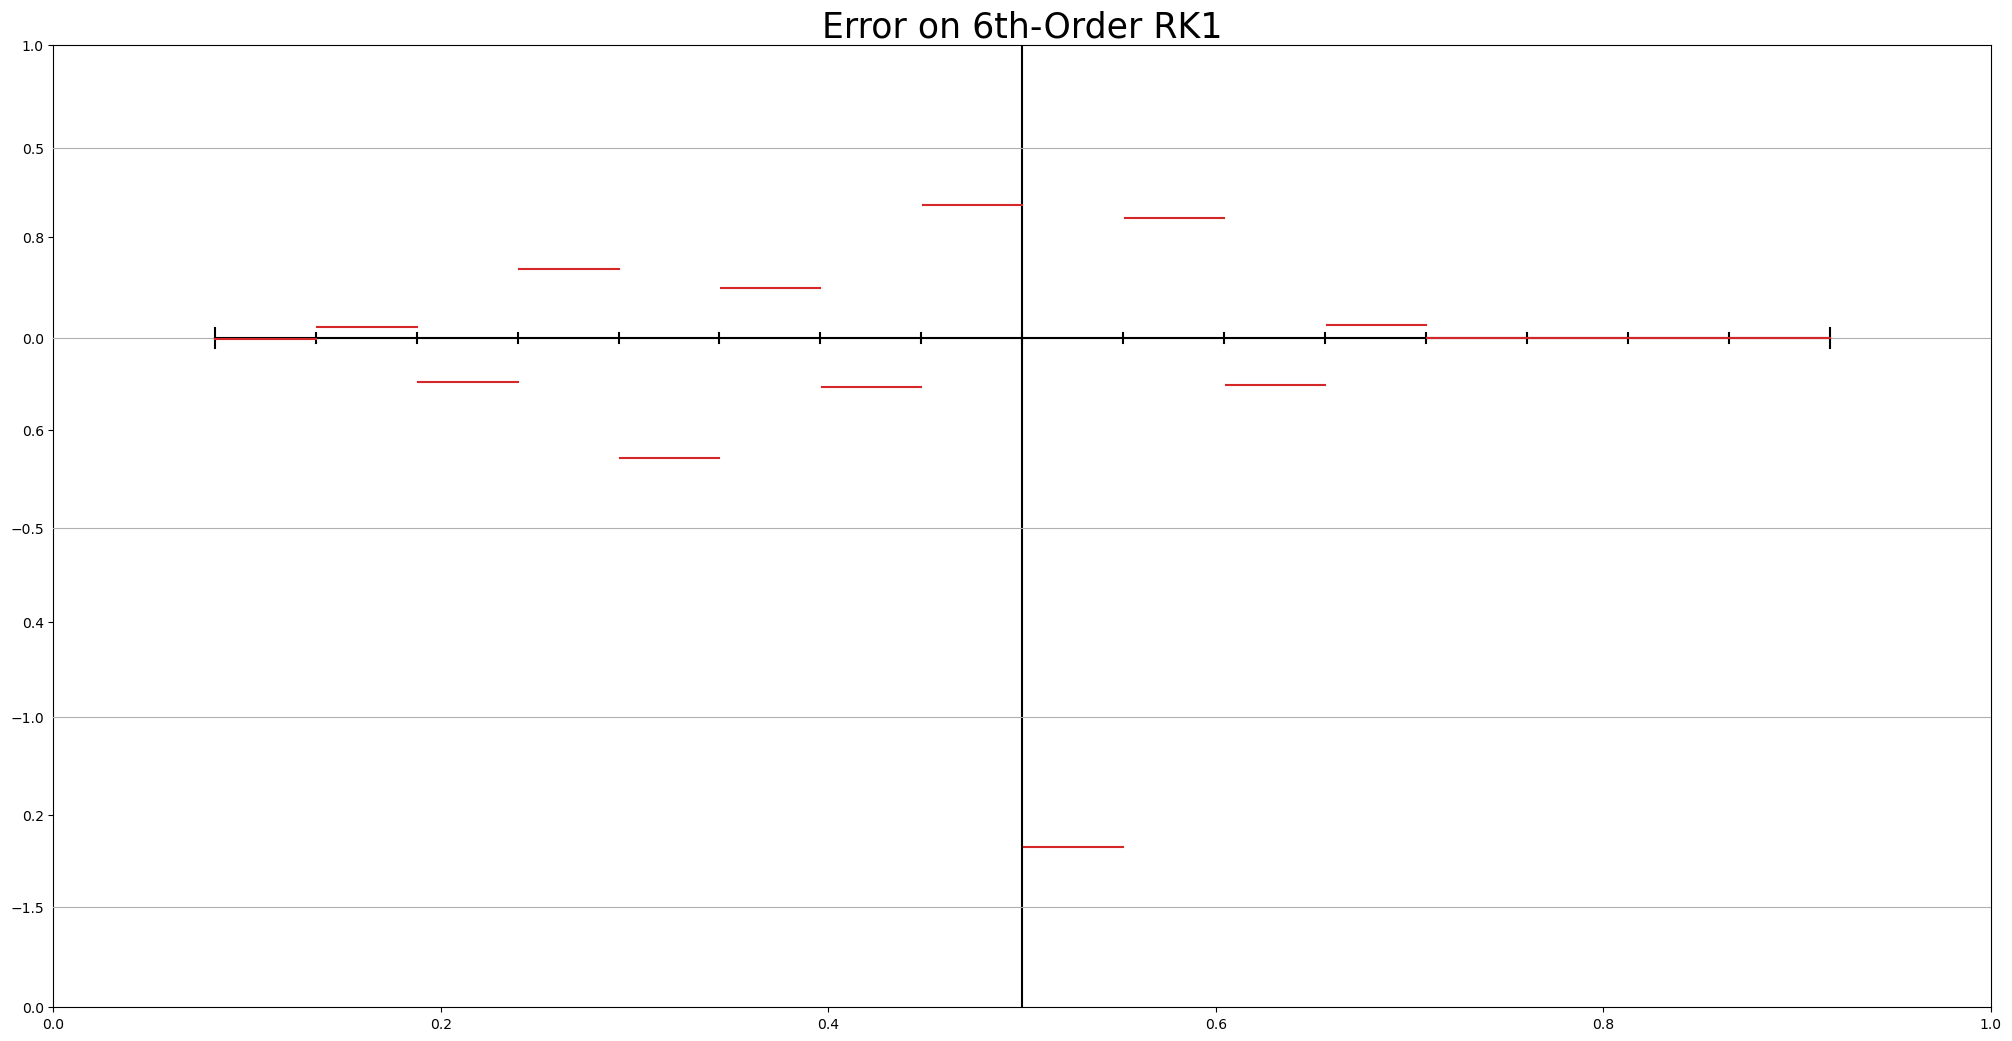

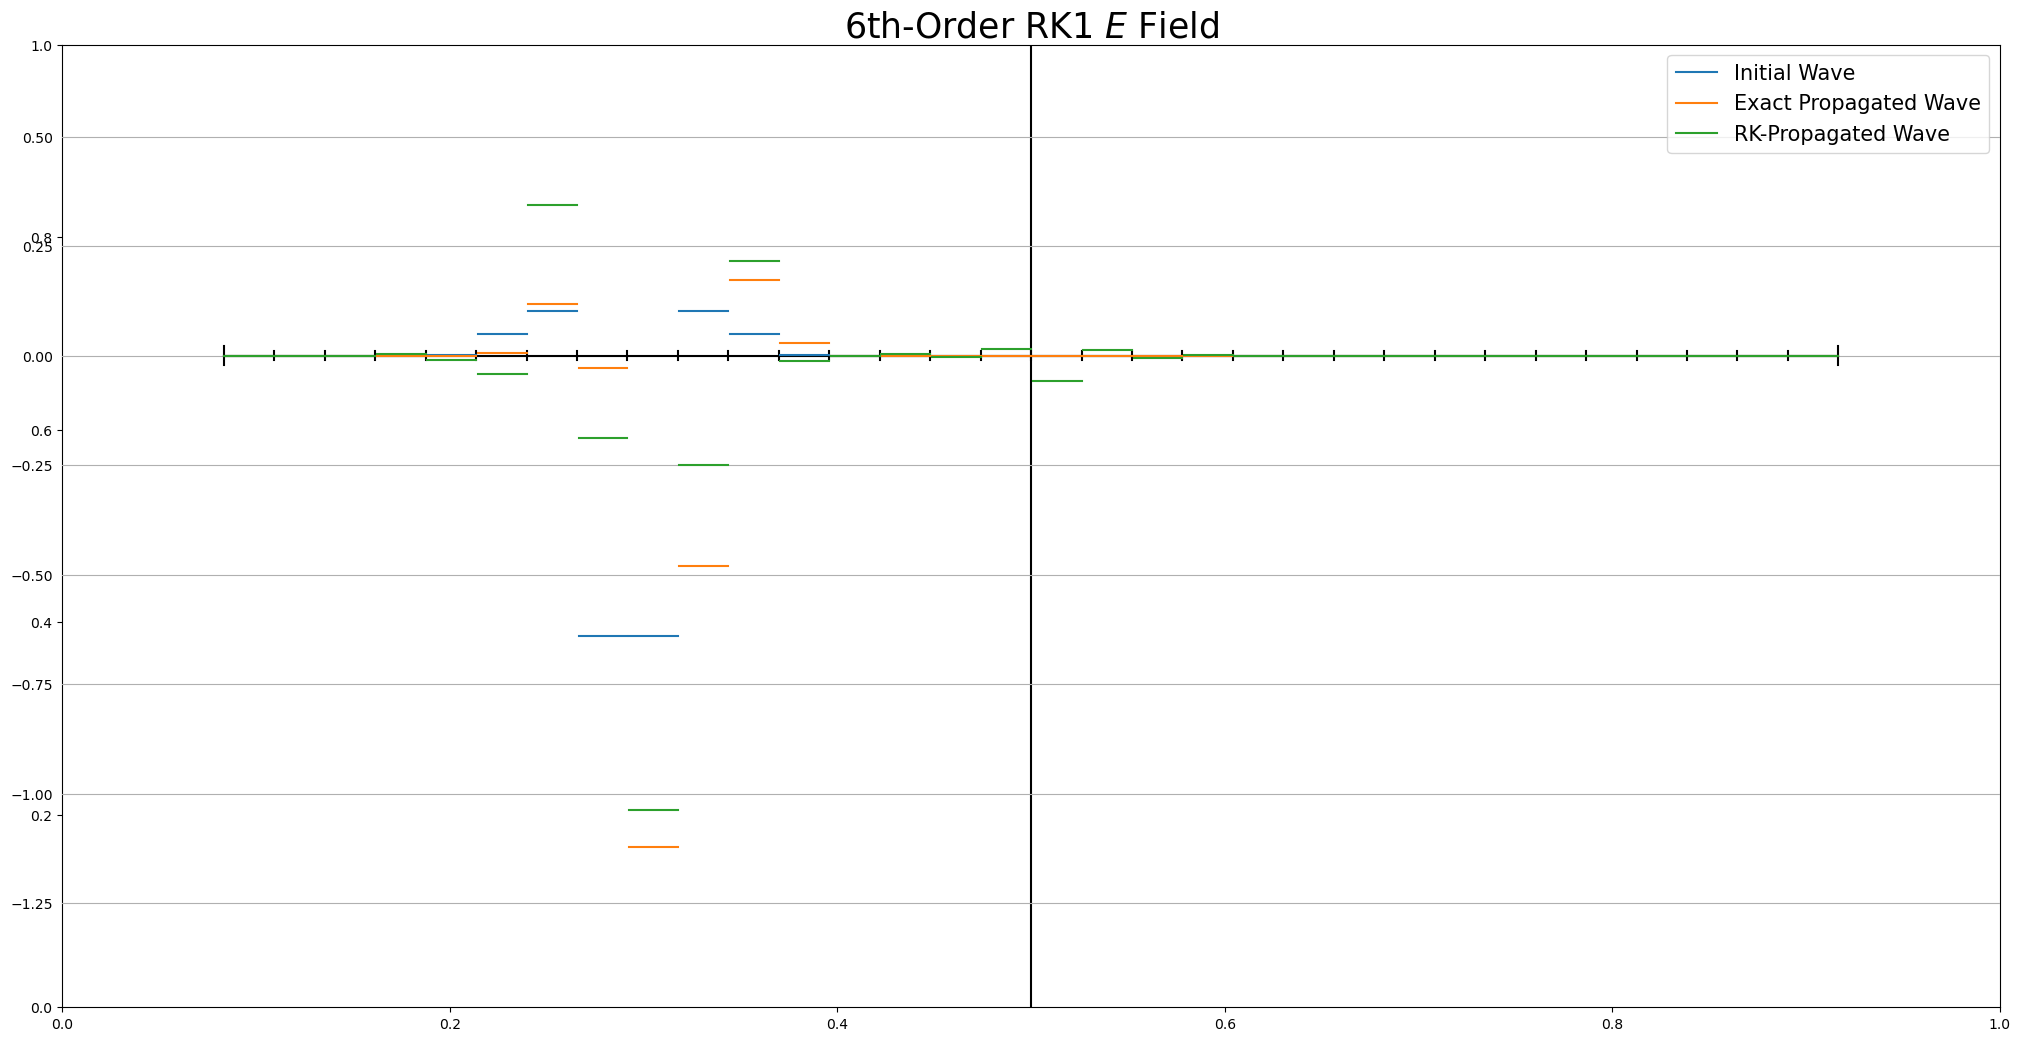

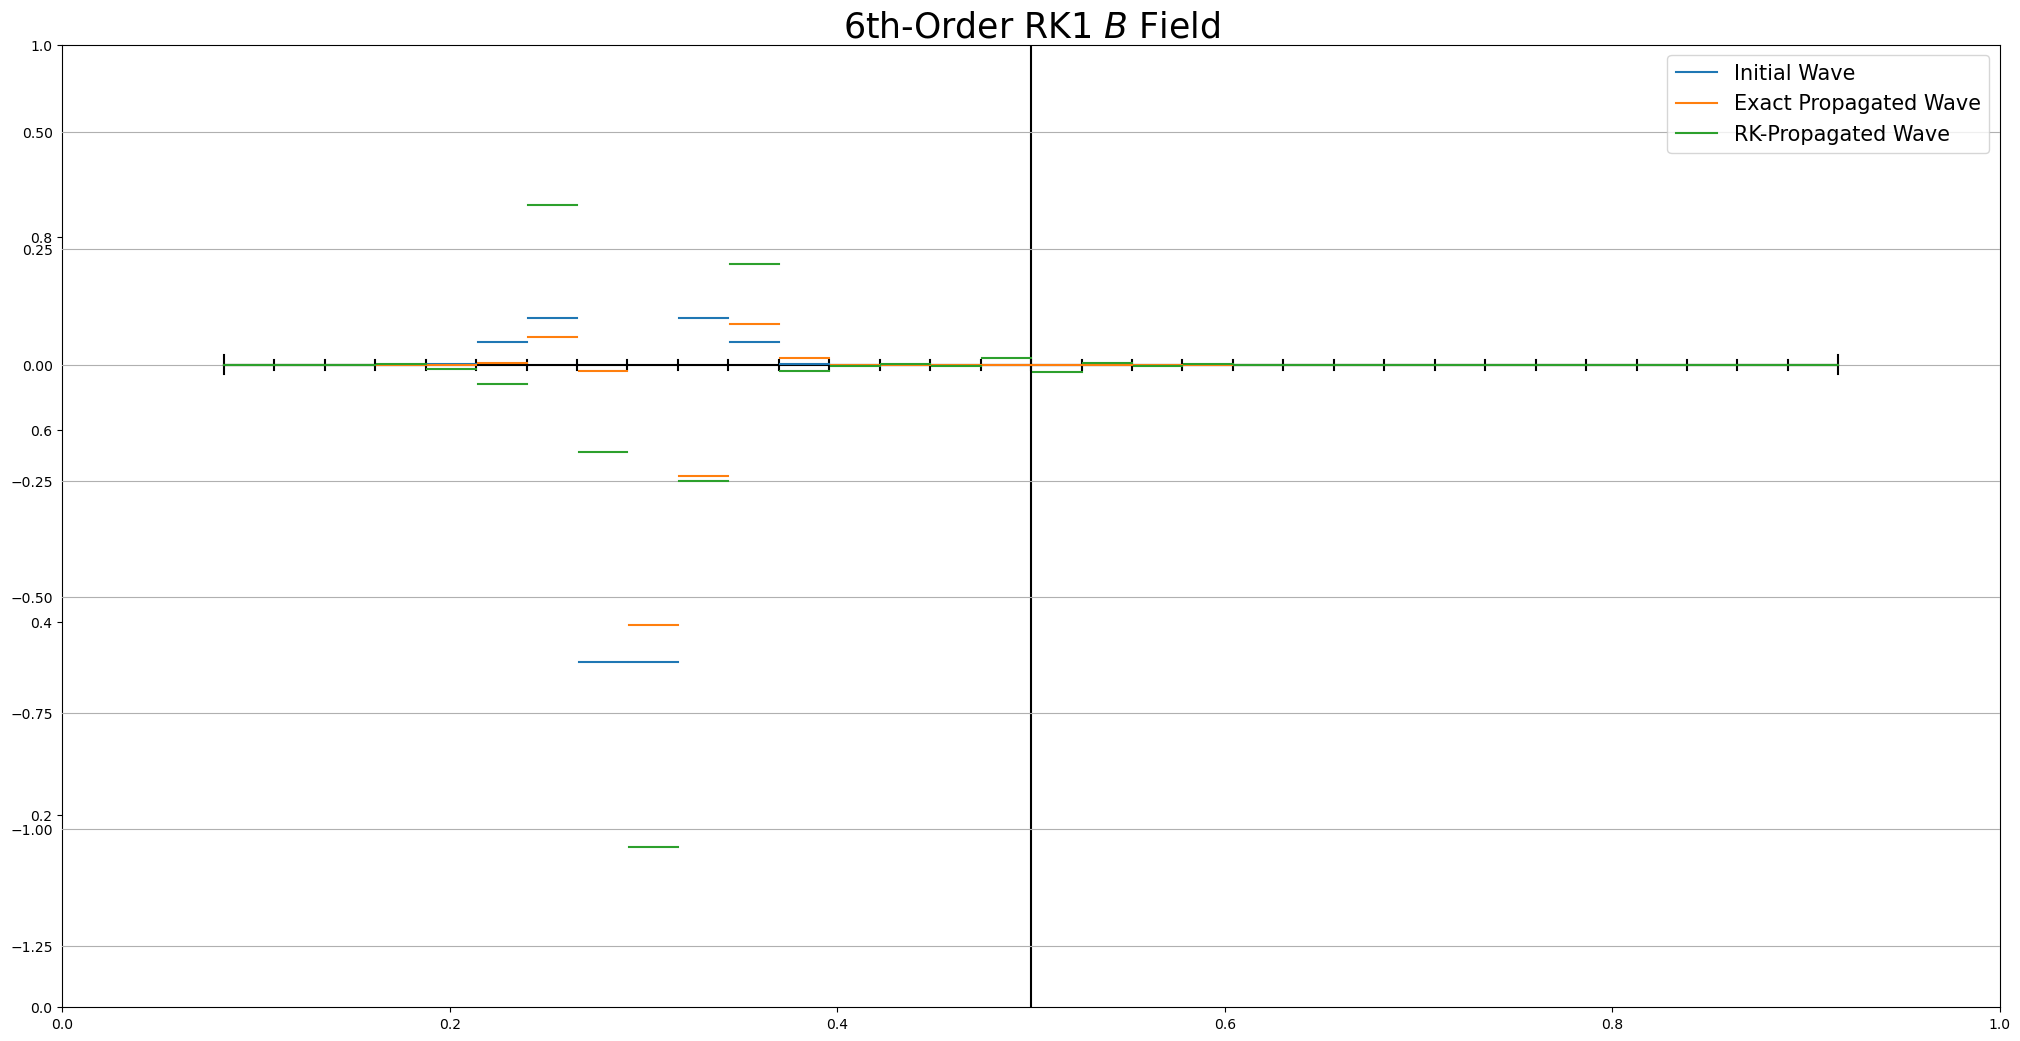

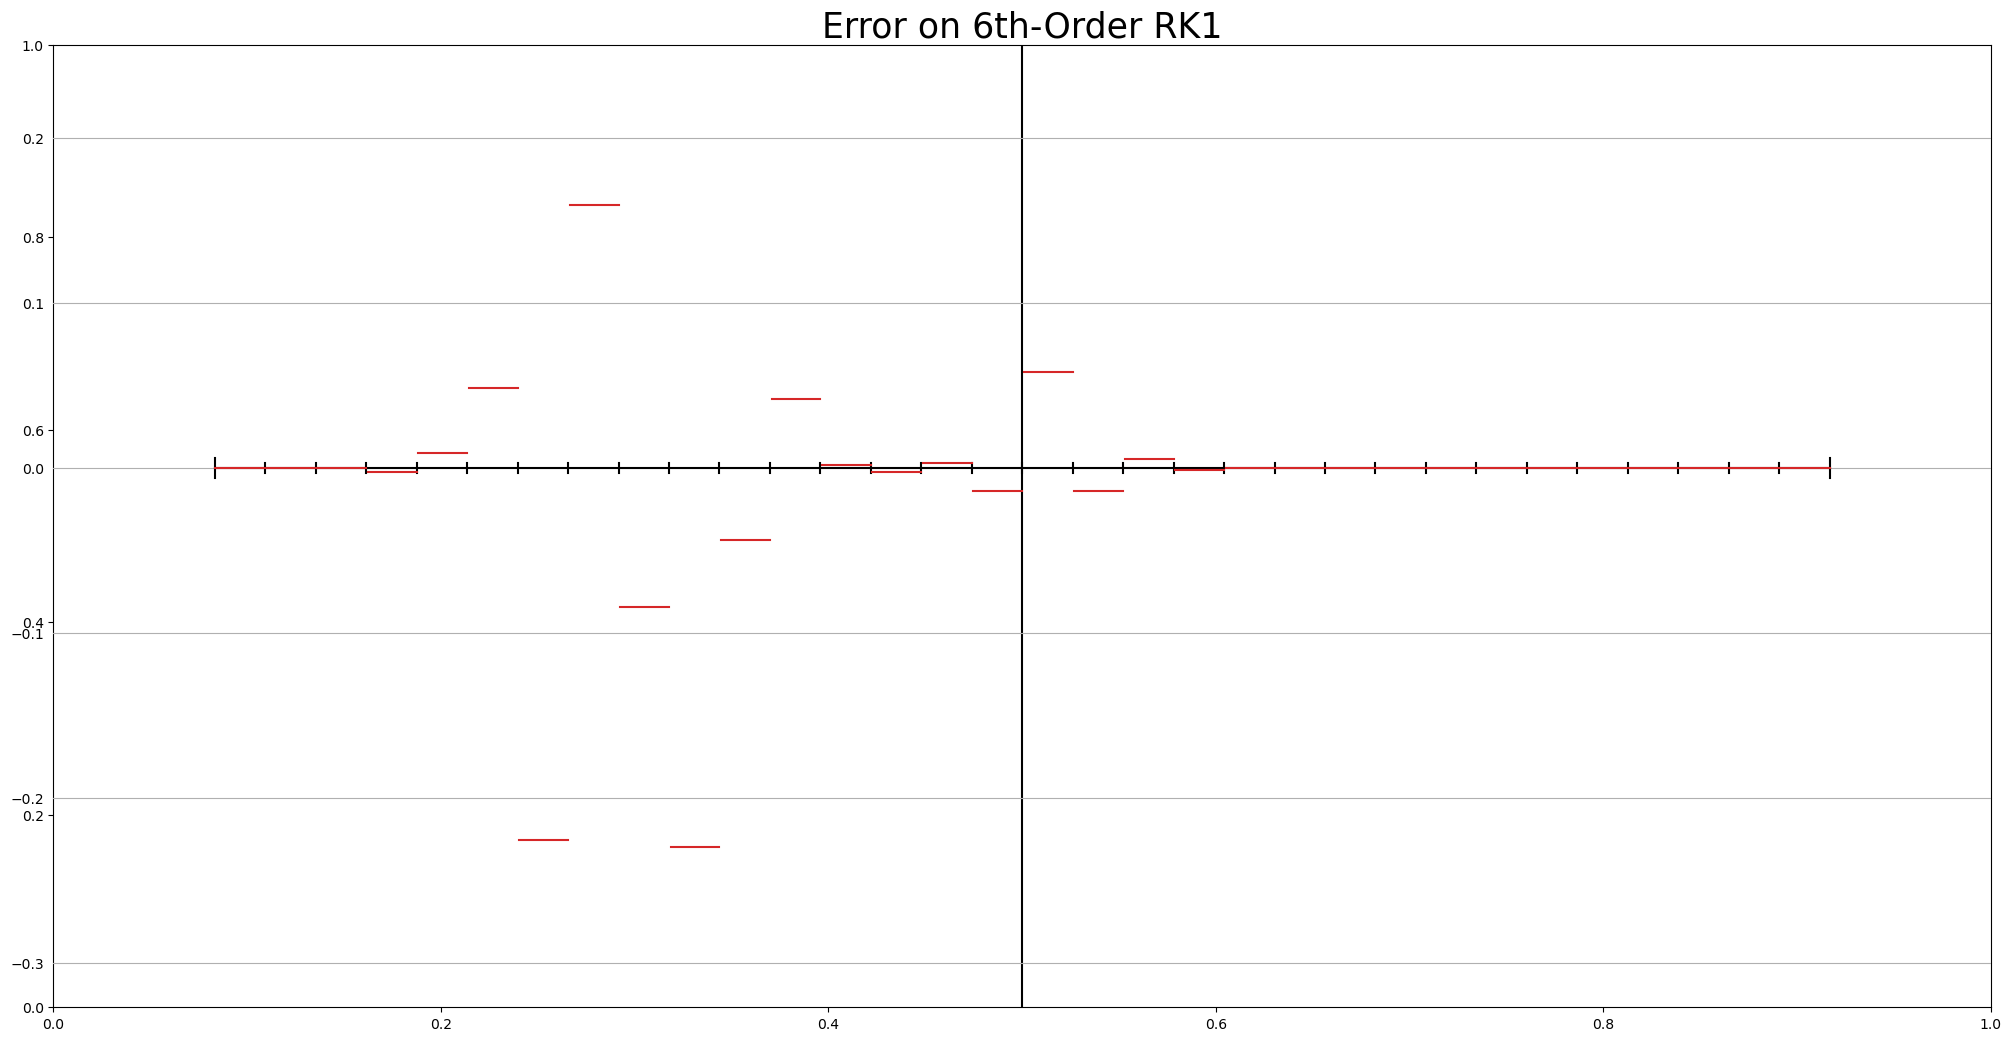

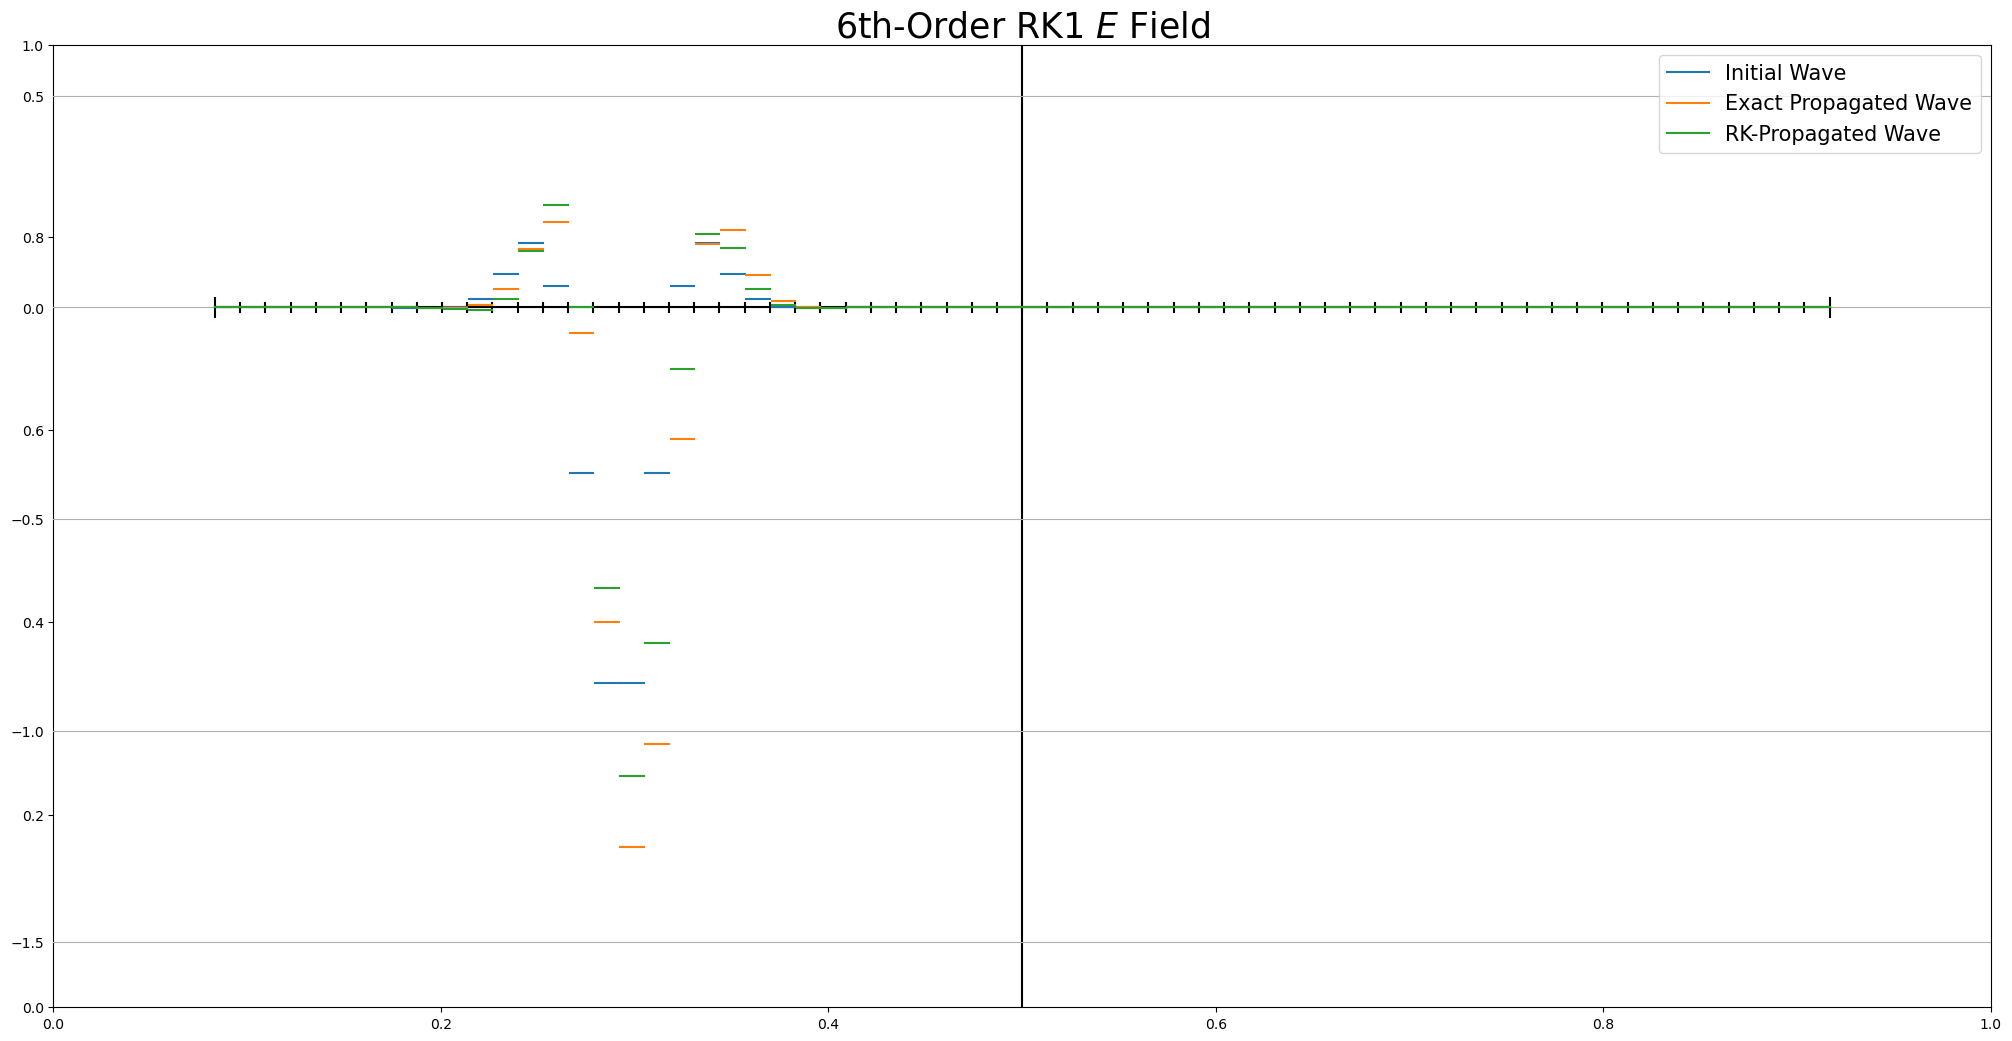

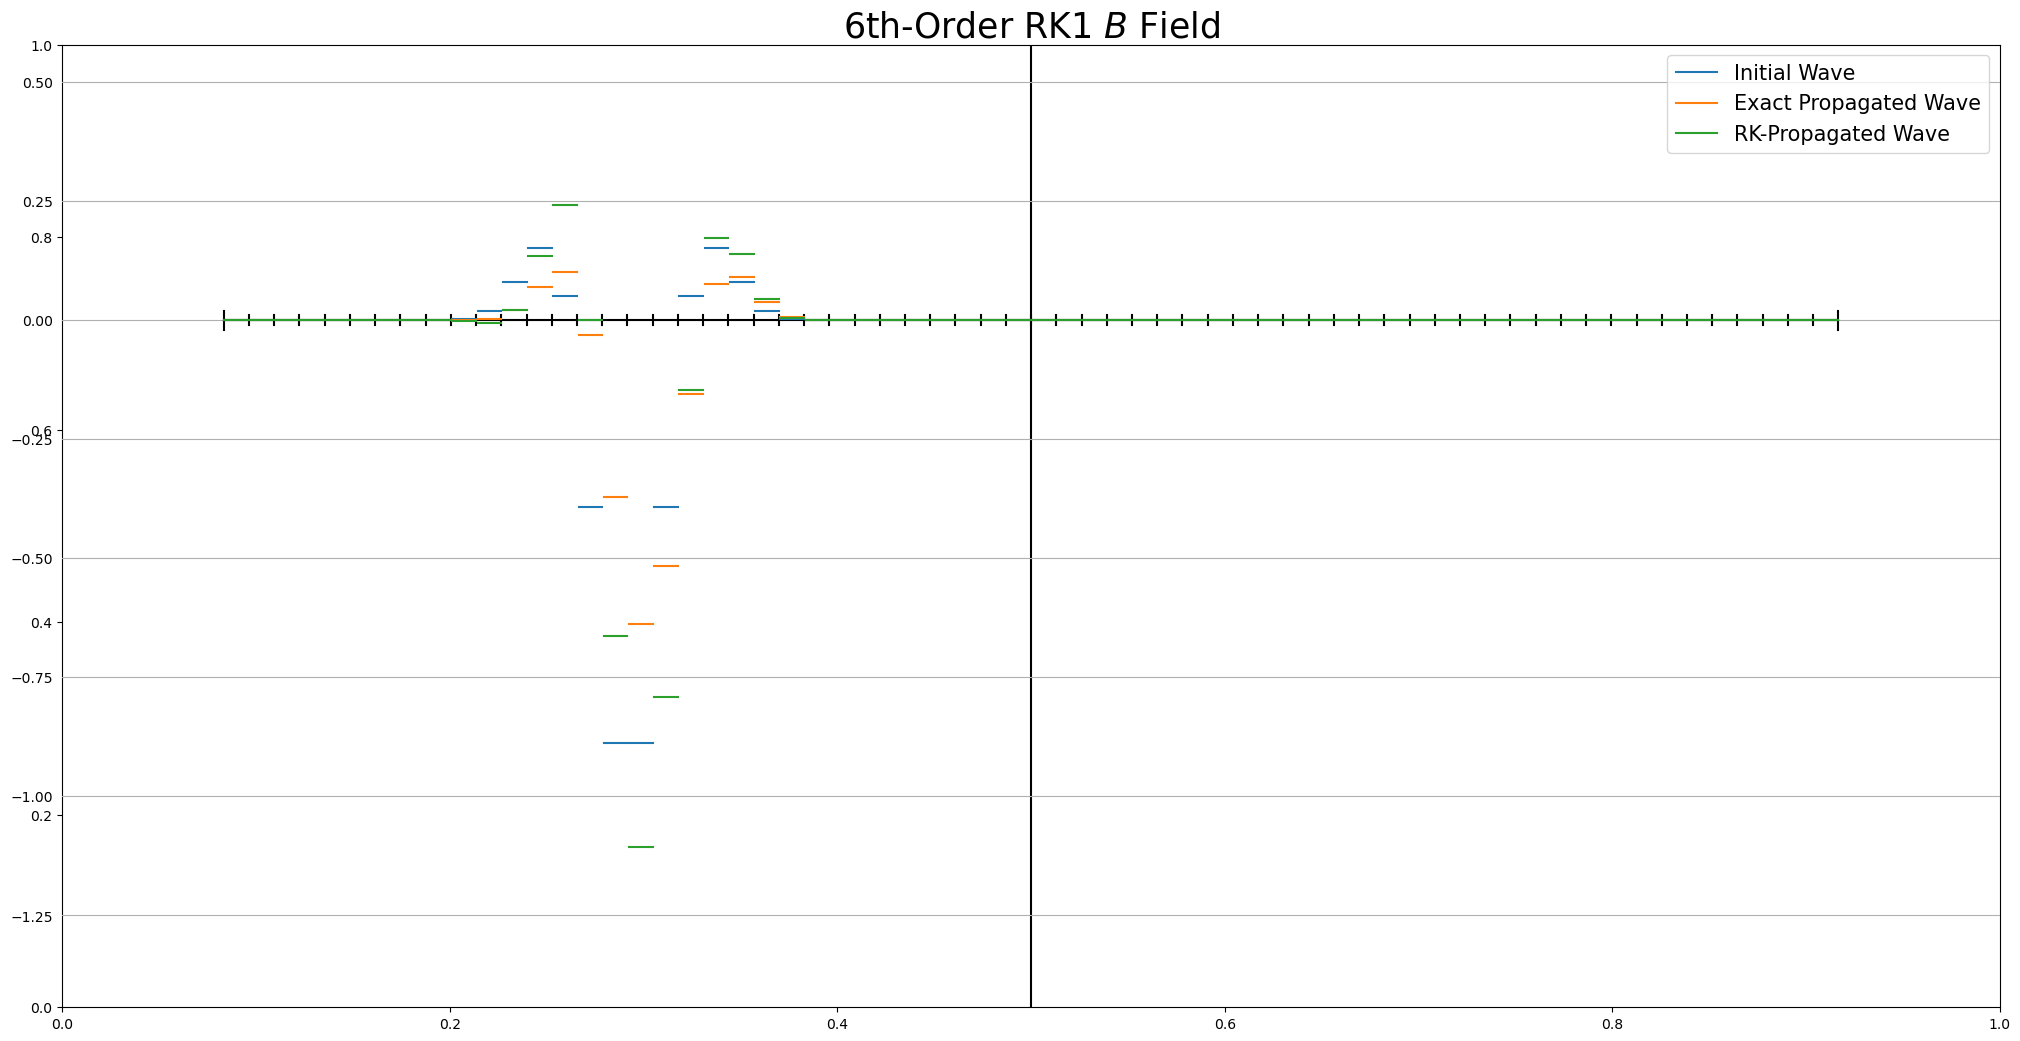

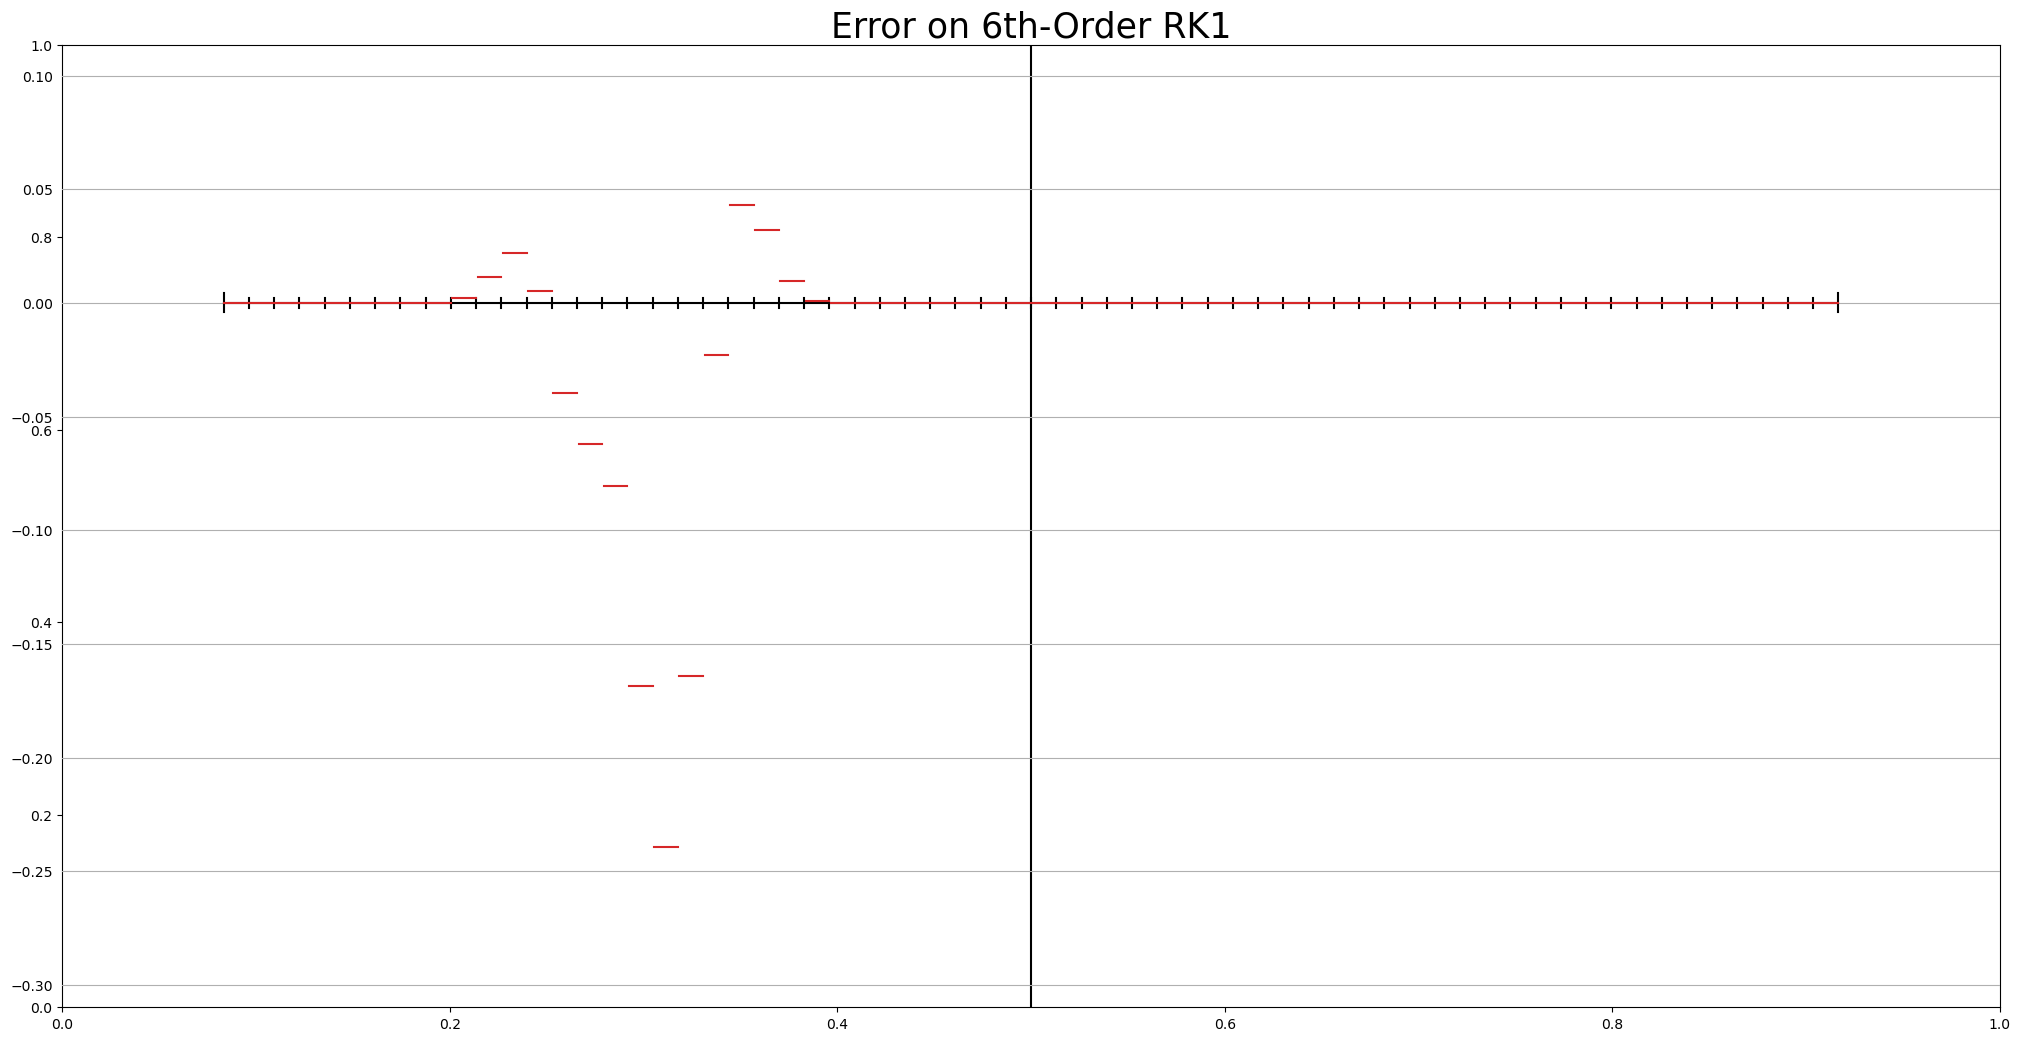

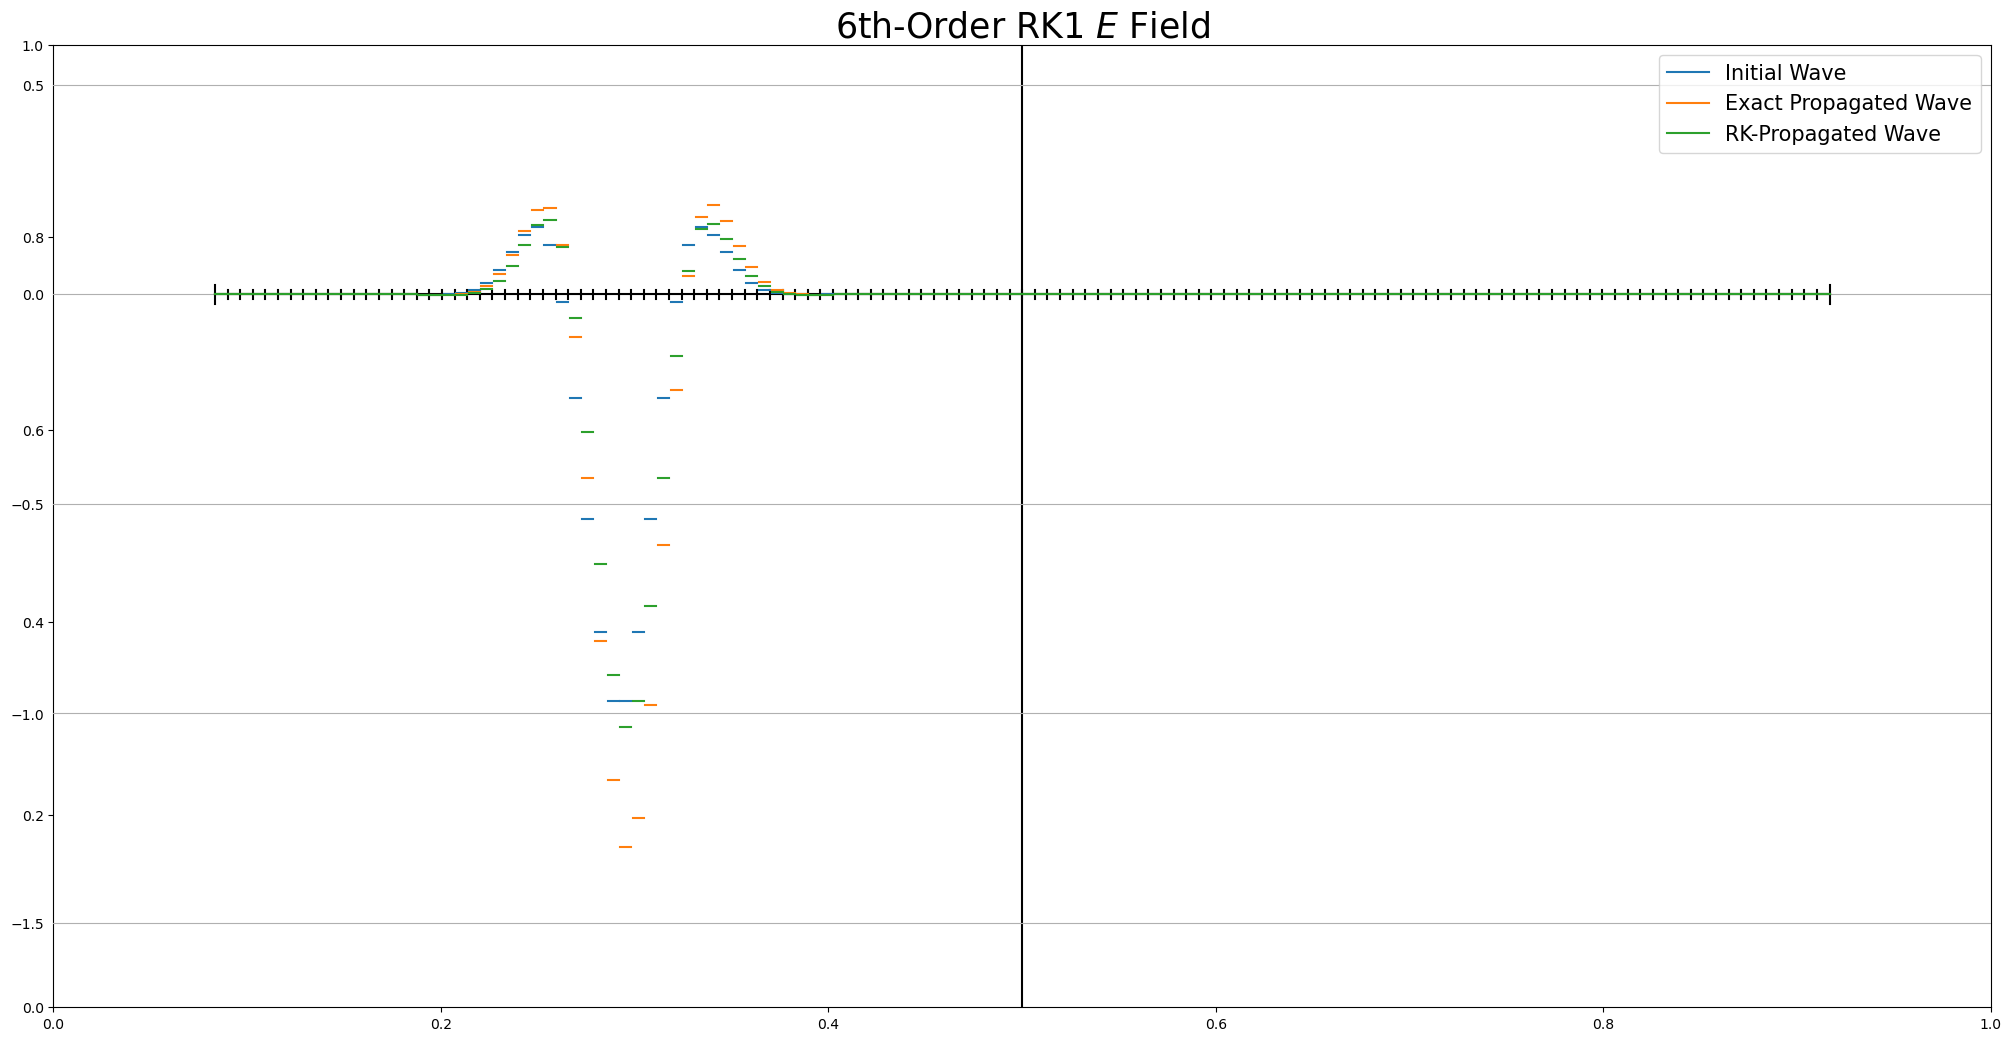

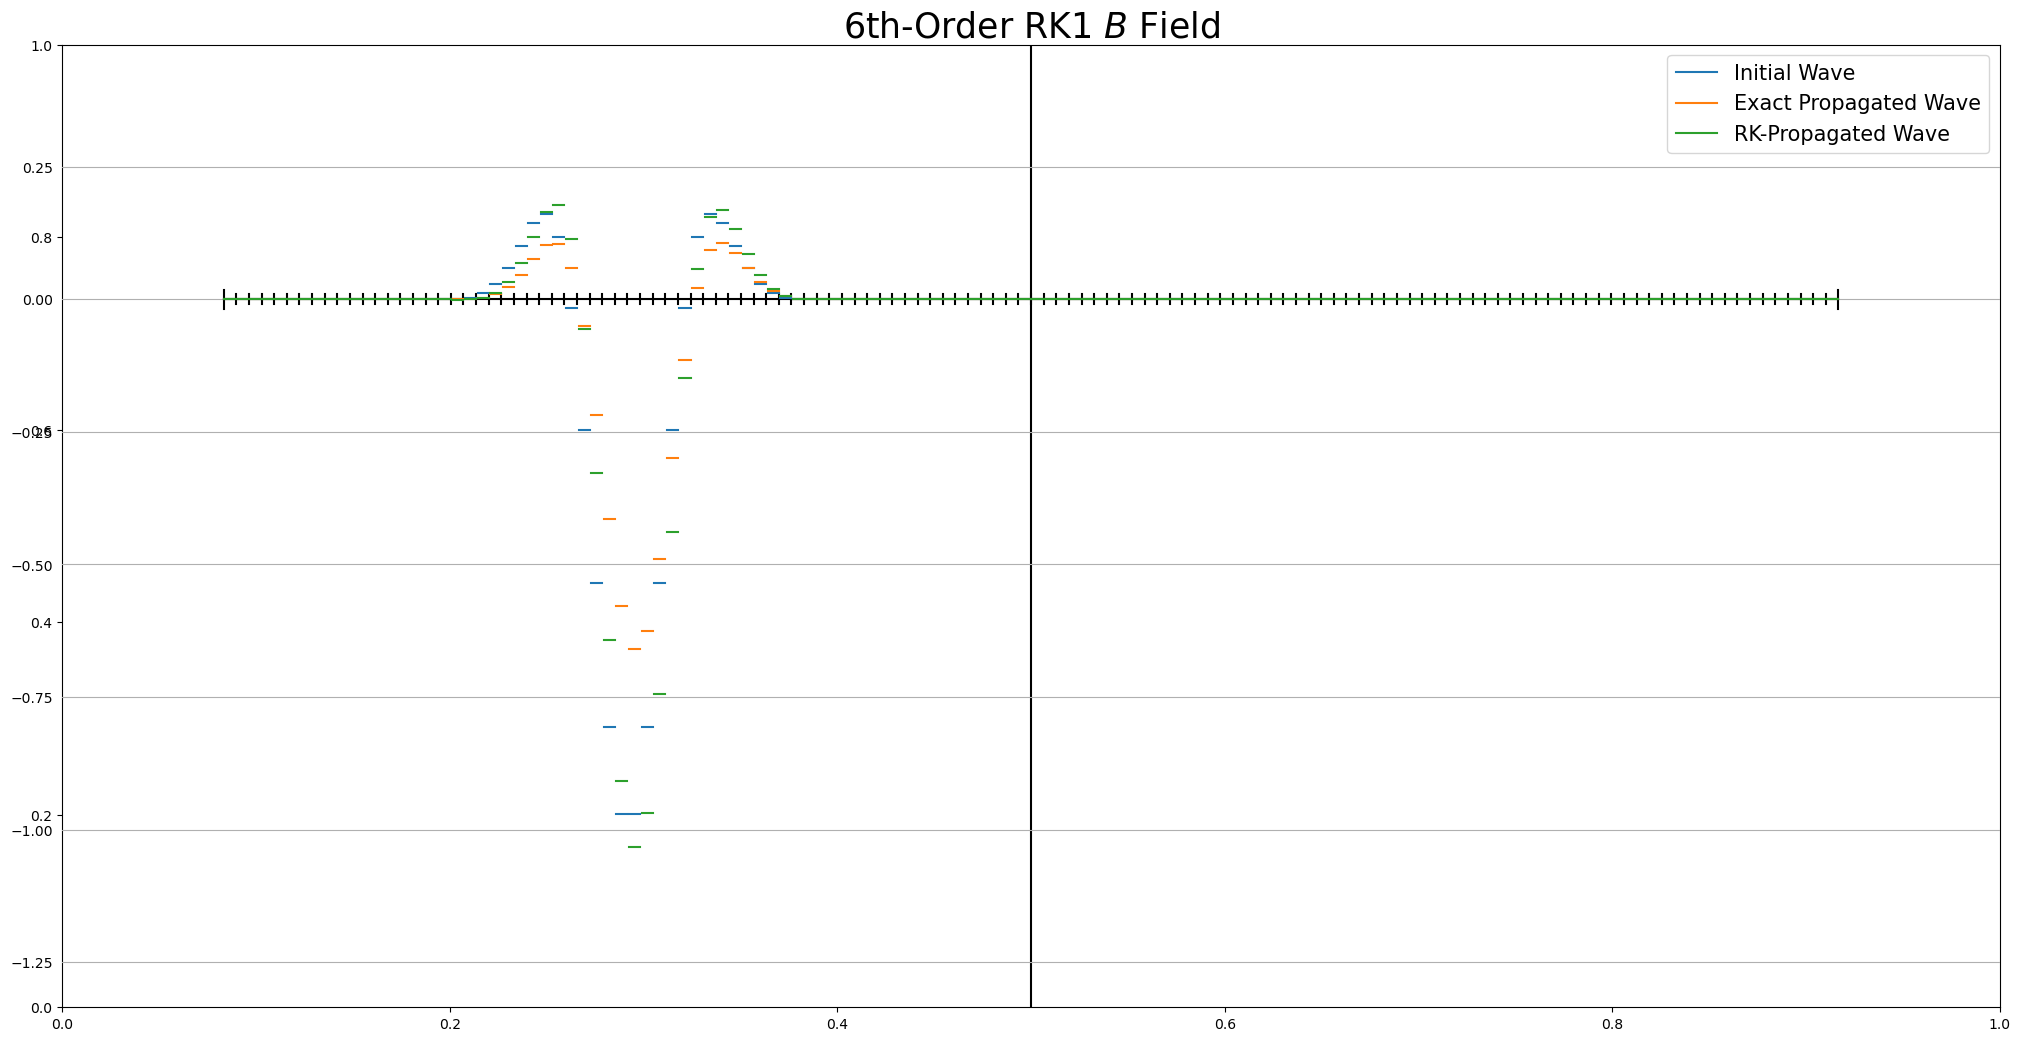

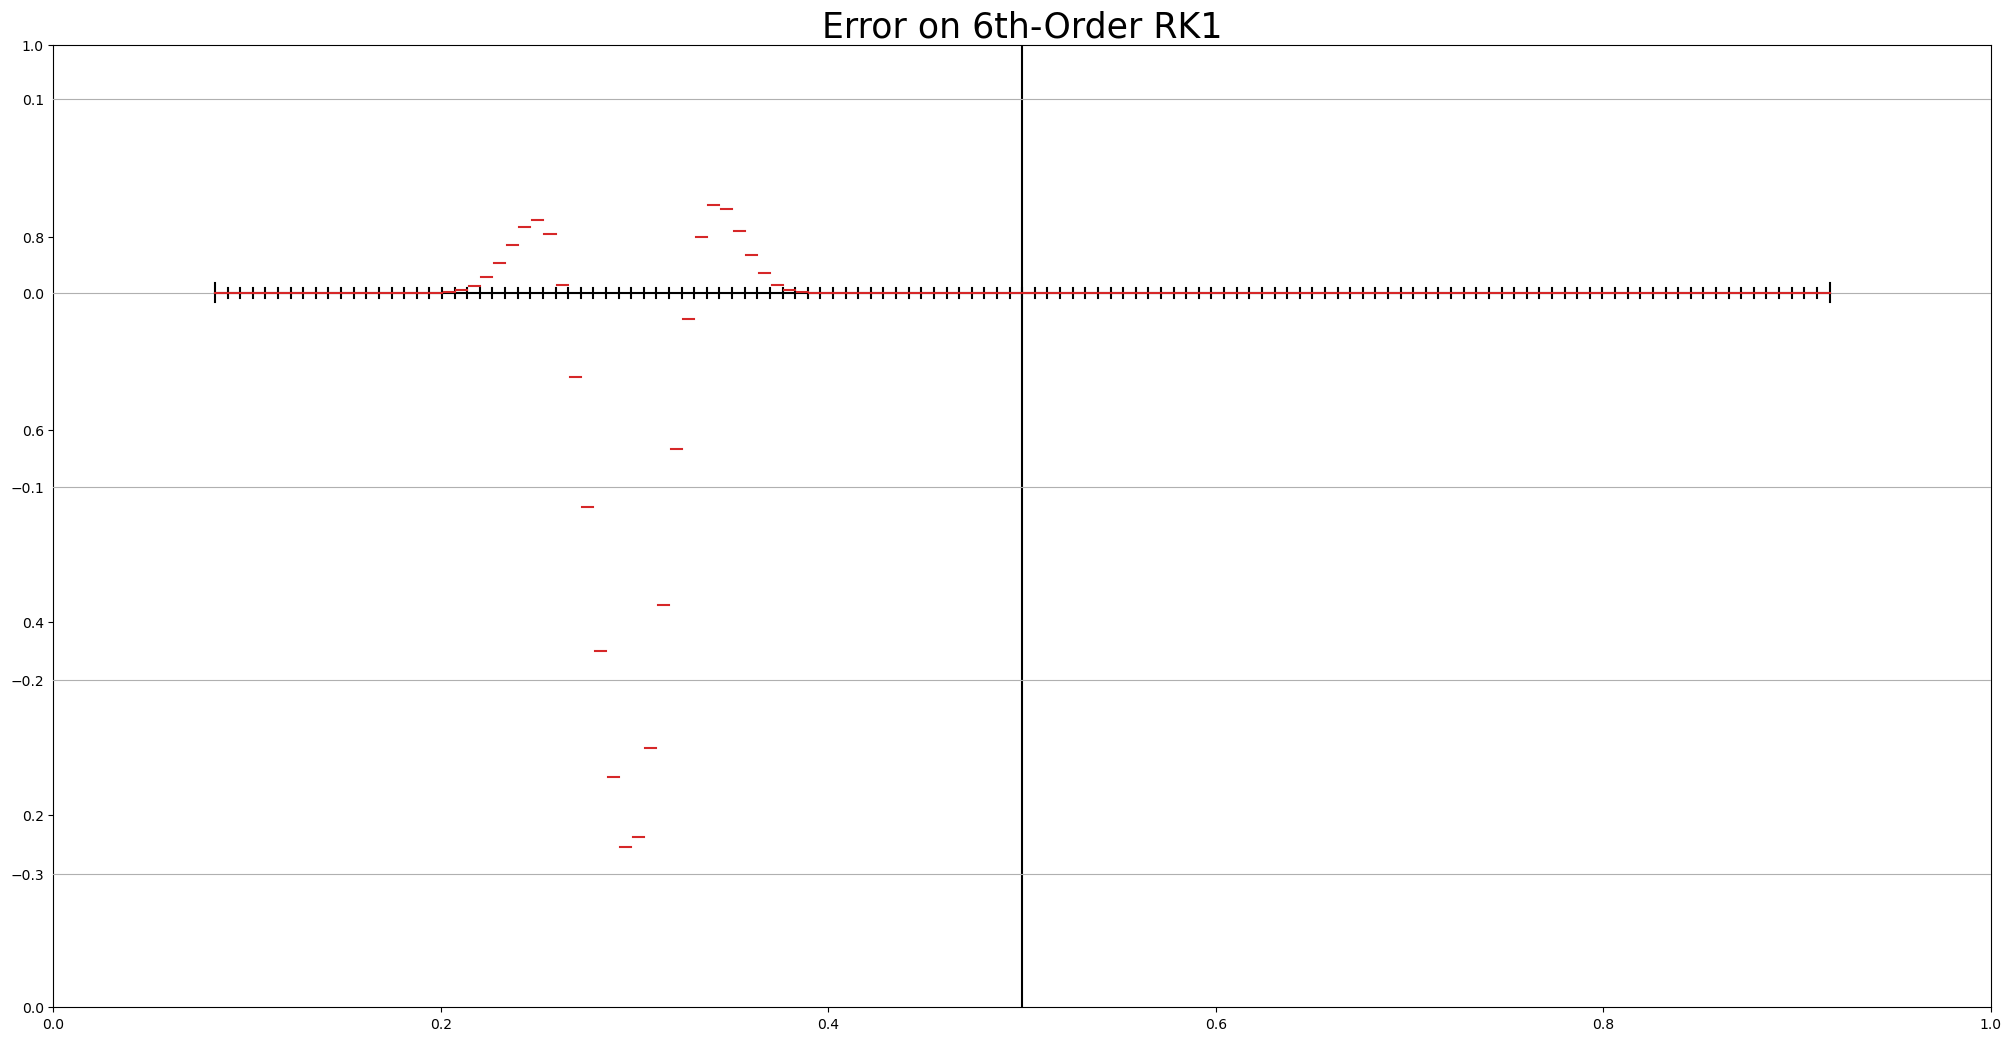

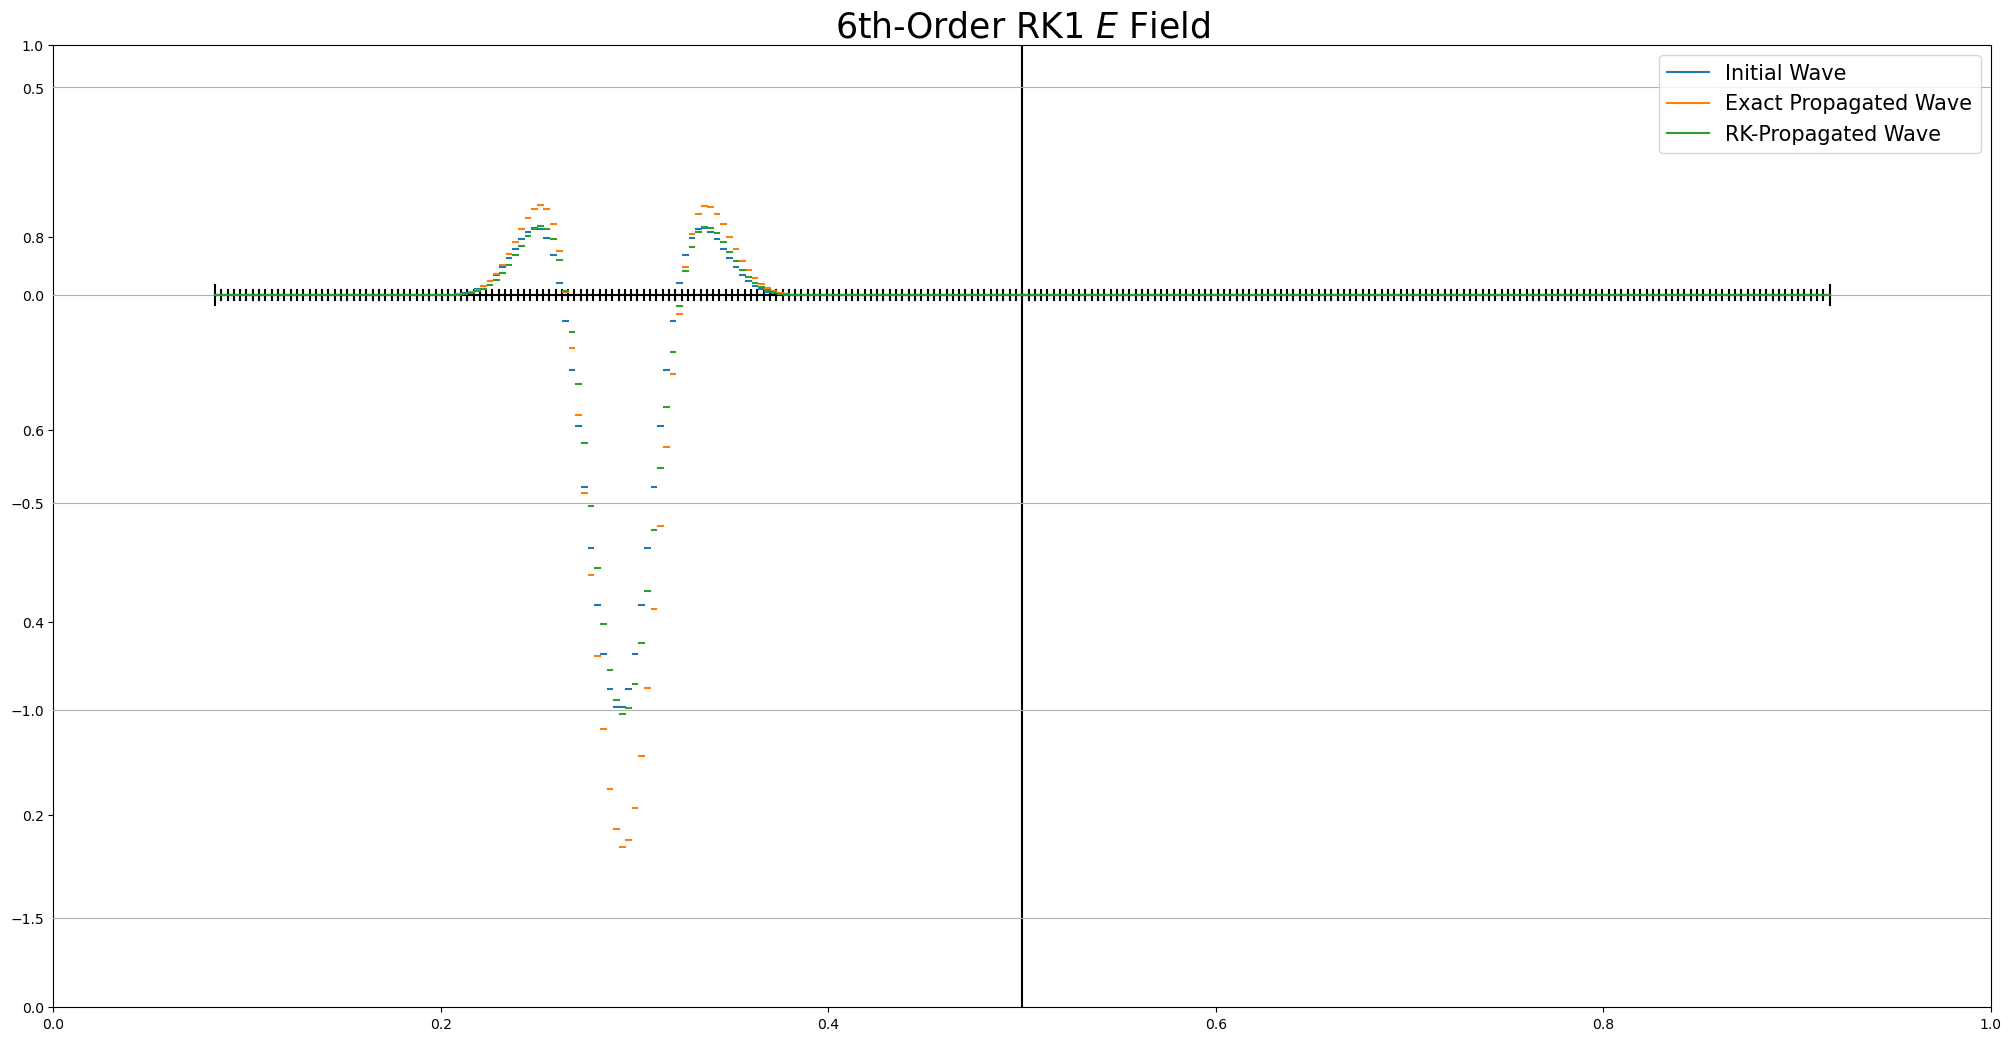

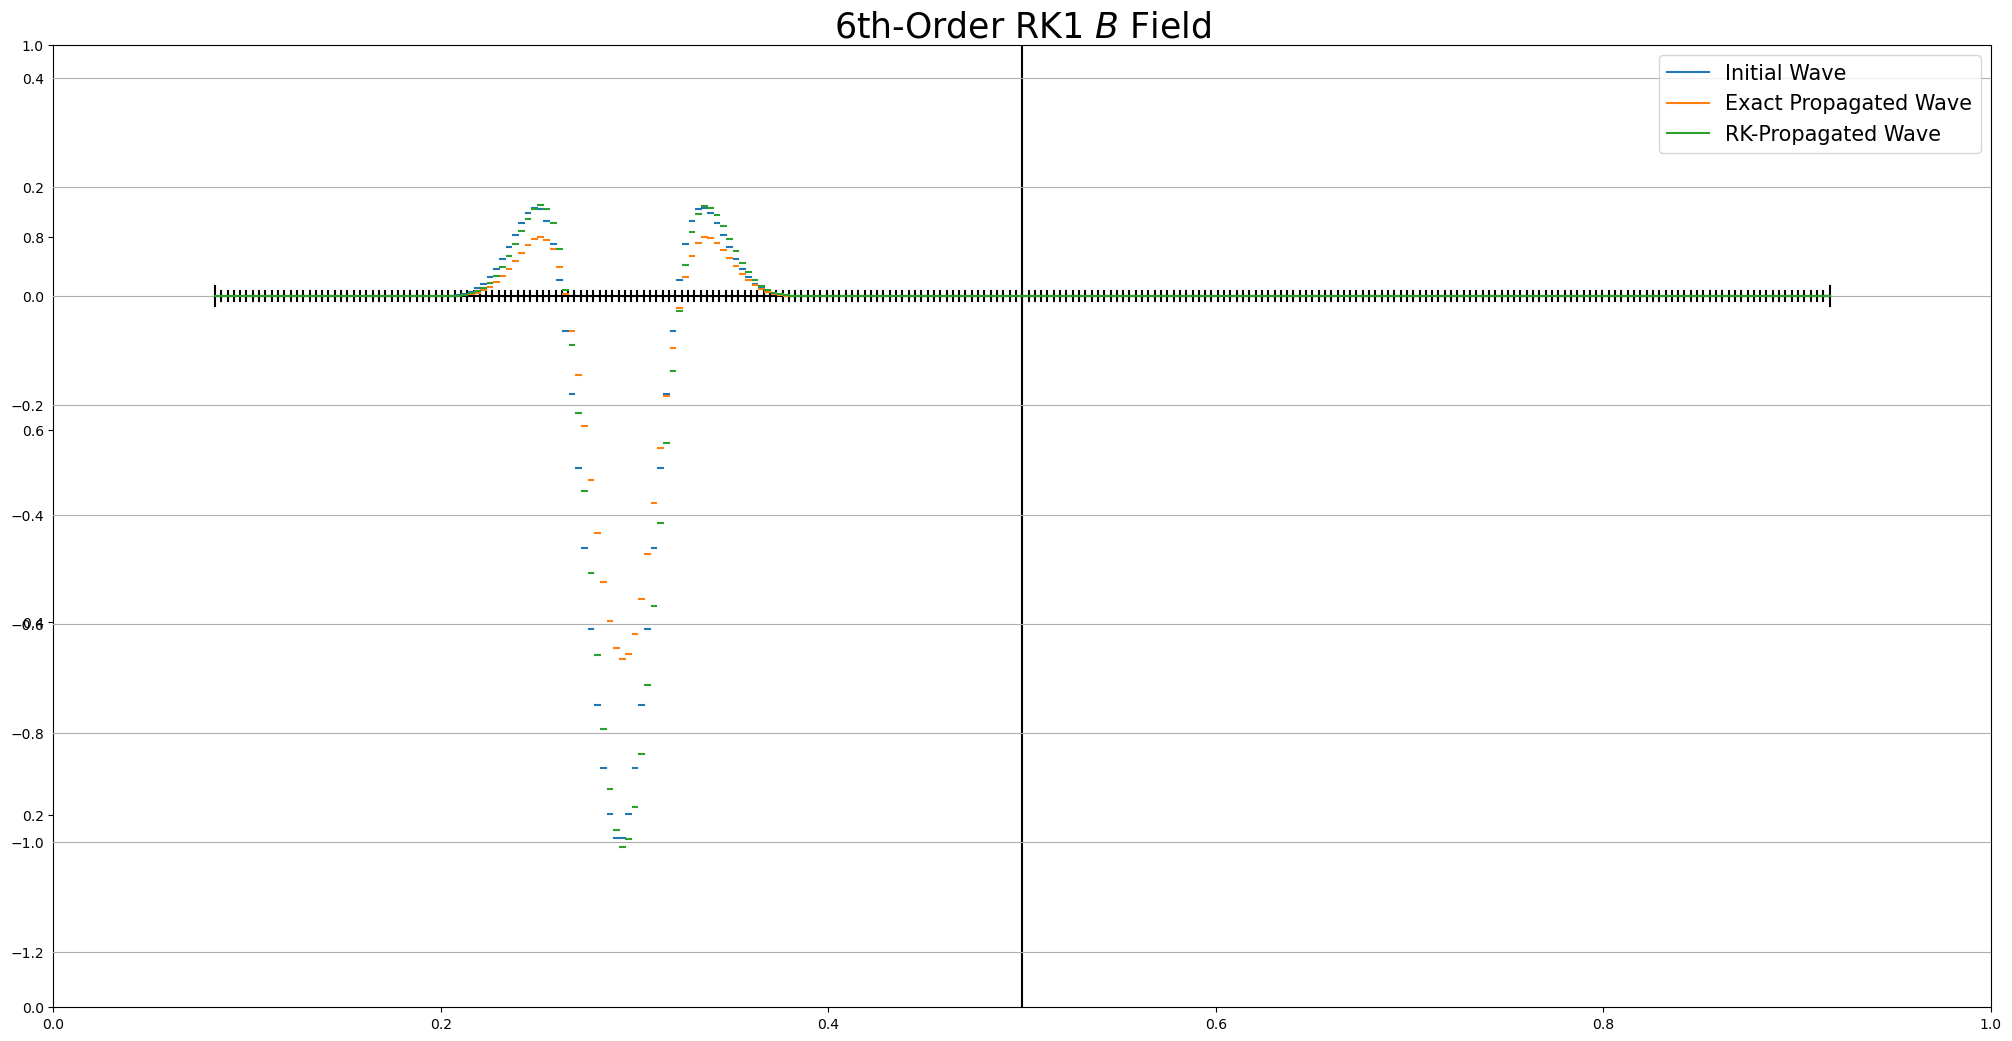

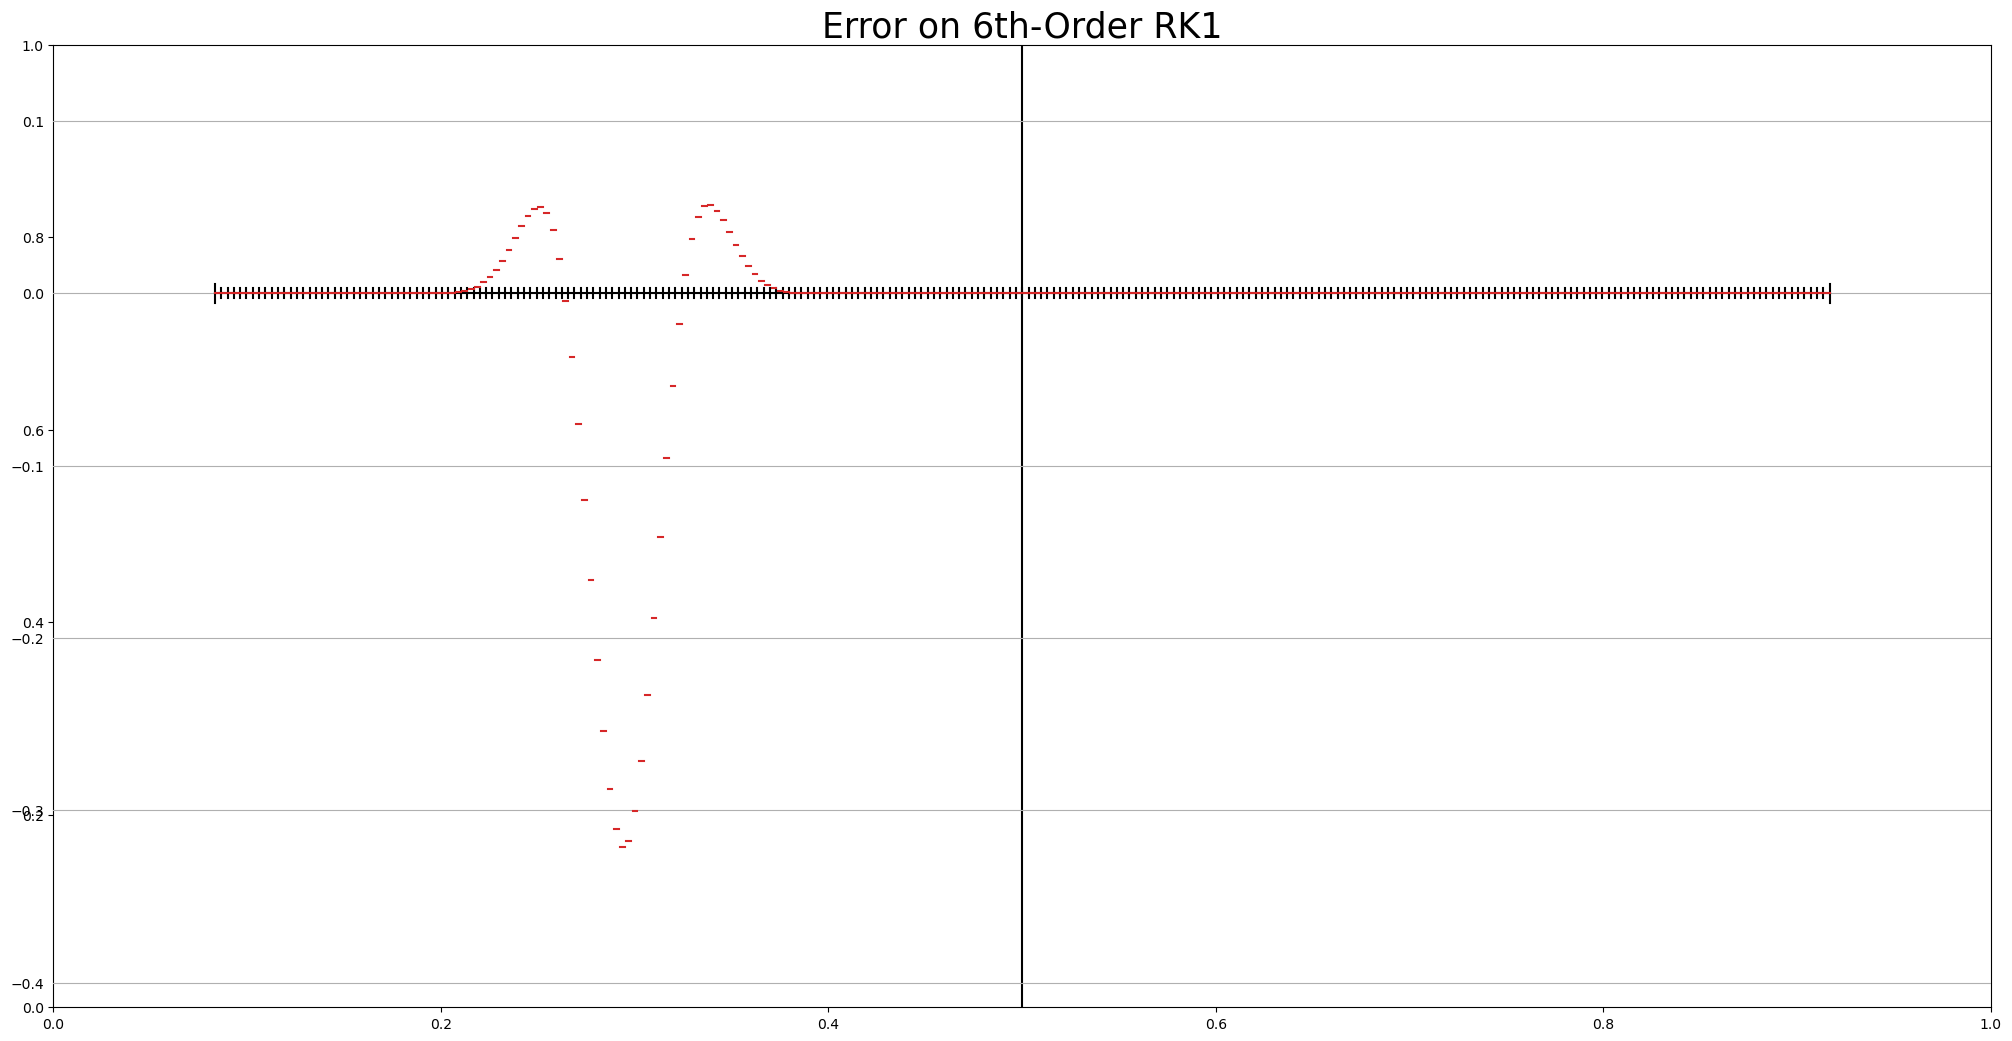

In [14]:
# DO NOT TOUCH!!!!!!!

scale = 0.8
figsize = list(scale * np.asarray([8, 10]))

fig, ax = plt.subplots(figsize = figsize)
plt.title(title)
plt.ylabel('Max Norm of Error')
plt.xlabel(xLabel)
plt.grid(True)
plt.xscale('log')
plt.yscale('log')
plt.ylim([10**-8, 1])

for b in range(UA):
    if (b == 0):
        
        if (not Uniform):
            # Skip first iteration if not using uniform grid. [v]
            continue
        
        # Then run uniform grid protocol. [v]
        AMR = False
        linestyle = '-'
        gridLab = ' Uniform'
    
        for a in range(AM):
            if (a == 0):
                
                if (not Advect):
                    # Skip first iteration if not advecting. [v]
                    continue
                
                physics, methLab, alpha = GetPhysInfo(omega0, 'Advection', Two)
                
                for o in range(6):
                    print('')
                    print ('B A O:', b, a, o)
                    print('')
                    order, diff, color, marker, zorder, linewidth = GetOrderInfo(o)
                    label = 'Order-' + str(order) + gridLab + methLab
                    # Run convergence test. [v]
                    nhVec, errGrid[b][a][order - 1] = WaveEqConvergenceTest(omega0, physics, CFL, RK, order, diff, func, args, dataPts, AMR, numRefCel = 4, plot = plot, derivative = derivative, scale = factor)
                    print('VALUES:')
                    print(errGrid[b][a][order - 1])
                    print(errGrid[b][a][order - 1][-3], errGrid[b][a][order - 1][-2], errGrid[b][a][order - 1][-1], nhVec[-3], nhVec[-2], nhVec[-1])
                    print(slopes1)
                    print(slopes2)
                    slopes1[b][a][order - 1] = np.log(errGrid[b][a][order - 1][-3] / errGrid[b][a][order - 1][-2]) / np.log(nhVec[-3] / nhVec[-2])
                    slopes2[b][a][order - 1] = np.log(errGrid[b][a][order - 1][-2] / errGrid[b][a][order - 1][-1]) / np.log(nhVec[-2] / nhVec[-1])
                    slopes[b][a][order - 1] = 0.5 * (slopes1[b][a][order - 1] + slopes2[b][a][order - 1])
                    line, = ax.plot(nhVec, errGrid[b][a][order - 1], zorder = zorder, linestyle = linestyle, color = color, alpha = alpha, linewidth = linewidth, marker = marker)
                    legends.append(line)
                    labels.append(label)

            else:
                
                physics, methLab, alpha = GetPhysInfo(omega0, 'Maxwell', Two)
                    
                for o in range(6):
                    print('')
                    print ('B A O:', b, a, o)
                    print('')
                    order, diff, color, marker, zorder, linewidth = GetOrderInfo(o)
                    label = 'Order-' + str(order) + gridLab + methLab
                    # Run convergence test. [v]
                    nhVec, errGrid[b][a][order - 1] = WaveEqConvergenceTest(omega0, physics, CFL, RK, order, diff, func, args, dataPts, AMR, numRefCel = 4, plot = plot, derivative = derivative, scale = factor)
                    print('VALUES:')
                    print(errGrid[b][a][order - 1])
                    print(errGrid[b][a][order - 1][dataPts - 3], errGrid[b][a][order - 1][dataPts - 2], errGrid[b][a][order - 1][dataPts - 1])
                    slopes1[b][a][order - 1] = np.log(errGrid[b][a][order - 1][-3] / errGrid[b][a][order - 1][-2]) / np.log(nhVec[-3] / nhVec[-2])
                    slopes2[b][a][order - 1] = np.log(errGrid[b][a][order - 1][-2] / errGrid[b][a][order - 1][-1]) / np.log(nhVec[-2] / nhVec[-1])
                    slopes[b][a][order - 1] = 0.5 * (slopes1[b][a][order - 1] + slopes2[b][a][order - 1])
                    line, = ax.plot(nhVec, errGrid[b][a][order - 1], zorder = zorder, linestyle = linestyle, color = color, alpha = alpha, linewidth = linewidth, marker = marker)#, label = label)
                    legends.append(line)
                    labels.append(label)
    else:
        # Then run AMR grid protocol. [v]
        AMR = True
        linestyle = '--'
        gridLab = ' Localized Mesh'
        
        for a in range(AM):
            if (a == 0):
                if (not Advect):
                    # Skip first iteration if not advecting. [v]
                    continue
                
                physics, methLab, alpha = GetPhysInfo(omega0, 'Advection', Two)
                
                for o in range(6):
                    print('')
                    print ('B A O:', b, a, o)
                    print('')
                    order, diff, color, marker, zorder, linewidth = GetOrderInfo(o)
                    label = 'Order-' + str(order) + gridLab + methLab
                    # Run convergence test. [v]
                    nhVec, errGrid[b][a][order - 1] = WaveEqConvergenceTest(omega0, physics, CFL, RK, order, diff, func, args, dataPts, AMR, numRefCel = 4, plot = plot, derivative = derivative, scale = factor)
                    print('VALUES:')
                    print(errGrid[b][a][order - 1])
                    print(errGrid[b][a][order - 1][dataPts - 3], errGrid[b][a][order - 1][dataPts - 2], errGrid[b][a][order - 1][dataPts - 1])
                    slopes1[b][a][order - 1] = np.log(errGrid[b][a][order - 1][-3] / errGrid[b][a][order - 1][-2]) / np.log(nhVec[-3] / nhVec[-2])
                    slopes2[b][a][order - 1] = np.log(errGrid[b][a][order - 1][-2] / errGrid[b][a][order - 1][-1]) / np.log(nhVec[-2] / nhVec[-1])
                    slopes[b][a][order - 1] = 0.5 * (slopes1[b][a][order - 1] + slopes2[b][a][order - 1])
                    line, = ax.plot(nhVec, errGrid[b][a][order - 1], zorder = zorder, linestyle = linestyle, color = color, alpha = alpha, linewidth = linewidth, marker = marker)#, label = label)
                    legends.append(line)
                    labels.append(label)
            else:
                
                physics, methLab, alpha = GetPhysInfo(omega0, 'Maxwell', Two)
                
                for o in range(6):
                    print('')
                    print ('B A O:', b, a, o)
                    print('')
                    order, diff, color, marker, zorder, linewidth = GetOrderInfo(o)
                    label = 'Order-' + str(order) + gridLab + methLab
                    # Run convergence test. [v]
                    nhVec, errGrid[b][a][order - 1] = WaveEqConvergenceTest(omega0, physics, CFL, RK, order, diff, func, args, dataPts, AMR, numRefCel = 4, plot = plot, derivative = derivative, scale = factor)
                    print('VALUES:')
                    print(errGrid[b][a][order - 1])
                    print(errGrid[b][a][order - 1][dataPts - 3], errGrid[b][a][order - 1][dataPts - 2], errGrid[b][a][order - 1][dataPts - 1])
                    slopes1[b][a][order - 1] = np.log(errGrid[b][a][order - 1][-3] / errGrid[b][a][order - 1][-2]) / np.log(nhVec[-3] / nhVec[-2])
                    slopes2[b][a][order - 1] = np.log(errGrid[b][a][order - 1][-2] / errGrid[b][a][order - 1][-1]) / np.log(nhVec[-2] / nhVec[-1])
                    slopes[b][a][order - 1] = 0.5 * (slopes1[b][a][order - 1] + slopes2[b][a][order - 1])
                    line, = ax.plot(nhVec, errGrid[b][a][order - 1], zorder = zorder, linestyle = linestyle, color = color, alpha = alpha, linewidth = linewidth, marker = marker)#, label = label)
                    legends.append(line)
                    labels.append(label)



saveName = savePath + 'ConvergenceRK' + str(RK) # + appendage
fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 600, transparent = True)
plt.show()
                    

In [15]:
legFig = plt.figure()
legFig.legend(legends, labels, loc='center')
saveName = savePath + 'Legend'
legFig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 600, transparent = True)
plt.show()
print(legends)
print(labels)

<Figure size 640x480 with 0 Axes>

[<matplotlib.lines.Line2D object at 0x7fbfca3e8610>, <matplotlib.lines.Line2D object at 0x7fbfcad96070>, <matplotlib.lines.Line2D object at 0x7fbf9ad92130>, <matplotlib.lines.Line2D object at 0x7fbfbc04f820>, <matplotlib.lines.Line2D object at 0x7fbf9c2a6af0>, <matplotlib.lines.Line2D object at 0x7fbfbdaf8d00>]
['Order-1 Uniform Maxwell', 'Order-2 Uniform Maxwell', 'Order-3 Uniform Maxwell', 'Order-4 Uniform Maxwell', 'Order-5 Uniform Maxwell', 'Order-6 Uniform Maxwell']


In [16]:
slopeAves = []
slopesX = []
slopesY = []


In [17]:
# # If Gauss!!!

# if (RK == 1):
#     for o in range(6):
#         if (o == 0):
#             slopeAves.append(slopes[UA - 1][AM - 1][o])
#             slopesX.append(0.5 * (nhVec[-2] + nhVec[-1]))
#             slopesY.append((errGrid[UA - 1][AM - 1][o][-1] * errGrid[UA - 1][AM - 1][o][-2]) ** 0.5)
#         else:
#             if (o == 5):
#                 if (Uniform):
#                     slopesY[0] = (errGrid[UA - 1][AM - 1][o][-1] * errGrid[UA - 1][AM - 1][o][-2]) ** 0.5
#             slopeAves[0] = slopeAves[0] + slopes[UA - 1][AM - 1][o]
#     slopeAves[0] = slopeAves[0] / 6
# else:
#     if (RK == 2):
#         for o in range(6):
#             if (o == 0):
#                 slopeAves.append(slopes[UA - 1][AM - 1][o])
#                 slopesX.append(0.5 * (nhVec[-2] + nhVec[-1]))
#                 slopesY.append((errGrid[UA - 1][AM - 1][o][-1] * errGrid[UA - 1][AM - 1][o][-2]) ** 0.5)
#             else:
#                 if (o == 1):
#                     slopeAves.append(slopes[UA - 1][AM - 1][o])
#                     slopesX.append(0.5 * (nhVec[-2] + nhVec[-1]))
#                     slopesY.append((errGrid[UA - 1][AM - 1][o][-1] * errGrid[UA - 1][AM - 1][o][-2]) ** 0.5)
#                 else:
#                     if (o == 2):
#                         slopeAves[1] = slopeAves[1] + slopes[UA - 1][AM - 1][o]
#                     else:
#                         if (o == 3):
#                             slopeAves.append(slopes[UA - 1][AM - 1][o])
#                             shiftX = 10**-0.075
#                             shiftY = 10**-0.4
#                             slopesX.append(0.5 * shiftX * (nhVec[-2] + nhVec[-1]))
#                             slopesY.append(shiftY * (errGrid[UA - 1][AM - 1][o][-1] * errGrid[UA - 1][AM - 1][o][-2]) ** 0.5)
#                         else:
#                             slopeAves[2] = slopeAves[2] + slopes[UA - 1][AM - 1][o]
#         slopeAves[1] = slopeAves[1] / 2
#         slopeAves[2] = slopeAves[2] / 3
#     else:
#         for o in range(6):
#             if (o == 0):
#                 slopeAves.append(slopes[UA - 1][AM - 1][o])
#                 slopesX.append(0.5 * (nhVec[-2] + nhVec[-1]))
#                 slopesY.append((errGrid[UA - 1][AM - 1][o][-1] * errGrid[UA - 1][AM - 1][o][-2]) ** 0.5) # Change!
#             else:
#                 if (o == 1):
#                     slopeAves.append(slopes[UA - 1][AM - 1][o]) # Change!
#                     slopesX.append(0.5 * (nhVec[-2] + nhVec[-1]))
#                     slopesY.append((errGrid[UA - 1][AM - 1][o][-1] * errGrid[UA - 1][AM - 1][o][-2]) ** 0.5) # Change!
#                 else:
#                     if (o == 2):
#                         slopeAves[1] = slopeAves[1] + slopes[UA - 1][AM - 1][o] # Change!
#                     else:
#                         if (o == 3):
#                             slopeAves.append(slopes[UA - 1][AM - 1][o]) # Change!
#                             slopesX.append(0.5 * (nhVec[-2] + nhVec[-1]))
#                             slopesY.append((errGrid[UA - 1][AM - 1][o][-1] * errGrid[UA - 1][AM - 1][o][-2]) ** 0.5) # Change!
#                         else:
#                             if (o == 5):
#                                 slopeAves.append(slopes[UA - 1][AM - 1][o]) # Change!
#                                 shiftX = 10**-0.1
#                                 shiftY = 10**-0.5
#                                 slopesX.append(0.5 * shiftX * (nhVec[-2] + nhVec[-1]))
#                                 slopesY.append(shiftY * (errGrid[UA - 1][AM - 1][o][-1] * errGrid[UA - 1][AM - 1][o][-2]) ** 0.5) # Change!
#                             else:
#                                 slopeAves[2] = slopeAves[2] + slopes[UA - 1][AM - 1][o] # Change!     
#         slopeAves[1] = slopeAves[1] / 2
#         slopeAves[2] = slopeAves[2] / 2


# # print('')      
# # print(slopeAves)
# # print(slopesX)
# # print(slopesY)
# # print('')

# if ((RK == 2) and Uniform):
#     slopeVal = (0.4 * slopeAves[-2]) + (0.6 * slopeAves[-1])
#     xVal = slopesX[-1]
#     yVal = slopesY[-1]
#     slopesX = slopesX[:-1]
#     slopesY = slopesY[:-1]
#     slopeAves = slopeAves[:-1]
#     slopesX[-1] = xVal
#     slopesY[-1] = yVal
#     slopeAves[-1] = slopeVal

    
# # print('')      
# # print(slopeAves)
# # print(slopesX)
# # print(slopesY)
# # print('')

In [18]:
# If Gauss Derivative!!!

if (RK == 1):
    for o in range(6):
        if (o == 0):
            slopeAves.append(slopes[UA - 1][AM - 1][o])
            slopesX.append(0.5 * (nhVec[-2] + nhVec[-1]))
            slopesY.append((errGrid[UA - 1][AM - 1][o][-1] * errGrid[UA - 1][AM - 1][o][-2]) ** 0.5)
        else:
            if (o == 1):
                slopeAves.append(slopes[UA - 1][AM - 1][o])
                shiftX = 10**-0.075
                shiftY = 10**-0.4
                slopesX.append(0.5 * shiftX * (nhVec[-2] + nhVec[-1]))
                slopesY.append(shiftY * (errGrid[UA - 1][AM - 1][o][-1] * errGrid[UA - 1][AM - 1][o][-2]) ** 0.5)
            else:
                if (o == 5):
                    if (Uniform):
                        slopesY[0] = (errGrid[UA - 1][AM - 1][o][-1] * errGrid[UA - 1][AM - 1][o][-2]) ** 0.5
                slopeAves[1] = slopeAves[1] + slopes[UA - 1][AM - 1][o]
    slopeAves[1] = slopeAves[1] / 5
else:
    if (RK == 2):
        for o in range(6):
            if (o == 0):
                slopeAves.append(slopes[UA - 1][AM - 1][o])
                slopesX.append(0.5 * (nhVec[-2] + nhVec[-1]))
                slopesY.append((errGrid[UA - 1][AM - 1][o][-1] * errGrid[UA - 1][AM - 1][o][-2]) ** 0.5)
            else:
                if (o == 1):
                    slopeAves.append(slopes[UA - 1][AM - 1][o])
                    if (Uniform):
                        shiftX = 10**-0.075
                        shiftY = 10**-0.4
                    else:
                        shiftX = 1
                        shiftY = 1
                    slopesX.append(0.5 * shiftX * (nhVec[-2] + nhVec[-1]))
                    slopesY.append(shiftY * (errGrid[UA - 1][AM - 1][o][-1] * errGrid[UA - 1][AM - 1][o][-2]) ** 0.5)
                else:
                    if (o == 2):
                        slopeAves.append(slopes[UA - 1][AM - 1][o])
                        shiftX = 10**-0.11
                        shiftY = 10**-0.11
                        slopesX.append(0.5 * shiftX * (nhVec[-3] + nhVec[-2]))
                        slopesY.append(shiftY * (errGrid[UA - 1][AM - 1][o][-2] * errGrid[UA - 1][AM - 1][o][-3]) ** 0.5)
                    else:
                        if (o == 3):
                            slopeAves.append(slopes[UA - 1][AM - 1][o])
                            if (AMR and Advect):
                                shiftX = 10**-0.1
                                shiftY = 10**-0.5
                            else:
                                if (k != 0):
                                    shiftX = 10**-0.4
                                    shiftY = 10**1.27
                                else:
                                    shiftX = 1
                                    shiftY = 1
                            slopesX.append(0.5 * shiftX * (nhVec[-2] + nhVec[-1]))
                            slopesY.append(shiftY * (errGrid[UA - 1][AM - 1][o][-1] * errGrid[UA - 1][AM - 1][o][-2]) ** 0.5)
                        else:
                            if (o == 5):
                                slopeAves.append(slopes[UA - 1][AM - 1][o]) # Change!
                                shiftX = 10**-0.075
                                shiftY = 10**-0.4
                                slopesX.append(0.5 * shiftX * (nhVec[-2] + nhVec[-1]))
                                slopesY.append(shiftY * (errGrid[UA - 1][AM - 1][o][-1] * errGrid[UA - 1][AM - 1][o][-2]) ** 0.5) # Change!
                            else:
                                slopeAves[3] = slopeAves[3] + slopes[UA - 1][AM - 1][o]
        slopeAves[3] = slopeAves[3] / 2
    else:
        for o in range(6):
            if (o == 0):
                slopeAves.append(slopes[UA - 1][AM - 1][o])
                slopesX.append(0.5 * (nhVec[-2] + nhVec[-1]))
                slopesY.append((errGrid[UA - 1][AM - 1][o][-1] * errGrid[UA - 1][AM - 1][o][-2]) ** 0.5) # Change!
            else:
                if (o == 1):
                    slopeAves.append(slopes[UA - 1][AM - 1][o]) # Change!
                    slopesX.append(0.5 * (nhVec[-2] + nhVec[-1]))
                    slopesY.append((errGrid[UA - 1][AM - 1][o][-1] * errGrid[UA - 1][AM - 1][o][-2]) ** 0.5) # Change!
                else:
                    if (o == 2):
                        slopeAves.append(slopes[UA - 1][AM - 1][o]) # Change!
                        shiftX = 10**-0.075
                        shiftY = 10**-0.4
                        slopesX.append(0.5 * shiftX * (nhVec[-2] + nhVec[-1]))
                        slopesY.append(shiftY * (errGrid[UA - 1][AM - 1][o][-1] * errGrid[UA - 1][AM - 1][o][-2]) ** 0.5) # Change!
                    else:
                        if (o == 3):
                            slopeAves.append(slopes[UA - 1][AM - 1][o]) # Change!
                            slopesX.append(0.5 * (nhVec[-2] + nhVec[-1]))
                            slopesY.append((errGrid[UA - 1][AM - 1][o][-1] * errGrid[UA - 1][AM - 1][o][-2]) ** 0.5) # Change!
                        else:
                            if (o == 5):
                                slopeAves.append(slopes[UA - 1][AM - 1][o]) # Change!
                                shiftX = 10**-0.1
                                shiftY = 10**-0.5
                                slopesX.append(0.5 * shiftX * (nhVec[-2] + nhVec[-1]))
                                slopesY.append(shiftY * (errGrid[UA - 1][AM - 1][o][-1] * errGrid[UA - 1][AM - 1][o][-2]) ** 0.5) # Change!
                            else:
                                slopeAves[3] = slopeAves[3] + slopes[UA - 1][AM - 1][o]    
        slopeAves[3] = slopeAves[3] / 2


print('')      
print(slopeAves)
print(slopesX)
print(slopesY)
print('')

if ((RK == 1) and ((not Two) or Uniform)):
    slopeVal = (slopeAves[0] + (5 * slopeAves[1])) / 6
    xVal = slopesX[0]
    yVal = slopesY[0]
    slopesX = slopesX[:-1]
    slopesY = slopesY[:-1]
    slopeAves = slopeAves[:-1]
    slopesX[0] = xVal
    slopesY[0] = yVal
    slopeAves[0] = slopeVal


if (RK == 2):
    if (Uniform):
        slopeVal = (slopeAves[1] + slopeAves[2] + (2 * slopeAves[3]) + slopeAves[4]) / 5
        xVal = slopesX[1]
        yVal = slopesY[1]
        slopesX = slopesX[:-3]
        slopesY = slopesY[:-3]
        slopeAves = slopeAves[:-3]
        slopesX[1] = xVal
        slopesY[1] = yVal
        slopeAves[1] = slopeVal
    else:
        if (Advect):
            slopeVal = ((2 * slopeAves[3]) + slopeAves[4]) / 3
            xVal = slopesX[-1]
            yVal = slopesY[-1]
            slopesX = slopesX[:-1]
            slopesY = slopesY[:-1]
            slopeAves = slopeAves[:-1]
            slopesX[-1] = xVal
            slopesY[-1] = yVal
            slopeAves[-1] = slopeVal
        else:
            if (Maxwell):
                slopeVal = (slopeAves[1] + slopeAves[2]) / 2
                del slopesX[2]
                del slopesY[2]
                del slopeAves[2]
                slopeAves[1] = slopeVal

if ((RK == 4) and (Uniform or Maxwell)):
    slopeVal = (slopeAves[1] + slopeAves[2]) / 2
    del slopesX[2]
    del slopesY[2]
    del slopeAves[2]
    slopeAves[1] = slopeVal
    

    
print('')      
print(slopeAves)
print(slopesX)
print(slopesY)
print('')


[-0.09850984021052858, 0.20858866156195557]
[192.0, 161.54786719587747]
[0.3030326594193713, 0.1214856278804984]


[0.15740557793320822]
[192.0]
[0.3030326594193713]




B A O: 0 1 0


B A O: 0 1 1


B A O: 0 1 2


B A O: 0 1 3


B A O: 0 1 4


B A O: 0 1 5



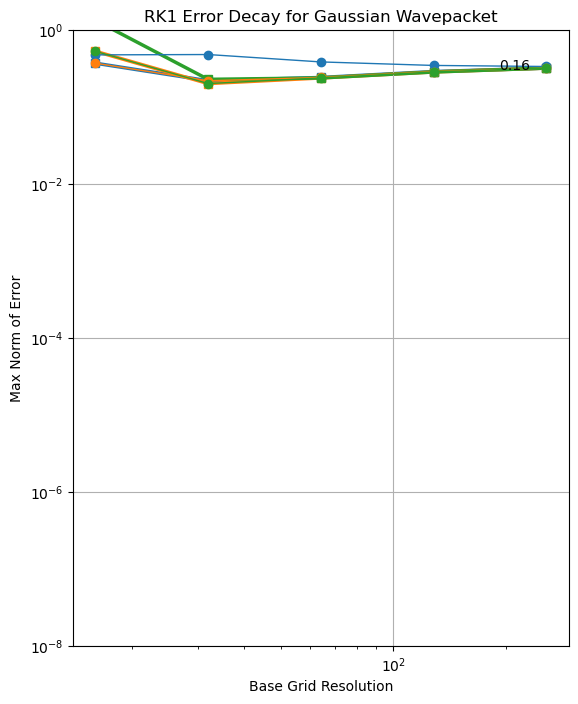

In [19]:
fig, ax = plt.subplots(figsize = figsize)
plt.title(title)
plt.ylabel('Max Norm of Error')
plt.xlabel(xLabel)
plt.grid(True)
plt.xscale('log')
plt.yscale('log')
plt.ylim([10**-8, 1])

with open(tableName + '.csv', 'w', encoding='UTF8', newline='') as g:
    writer = csv.writer(g)

    for b in range(UA):
        if (b == 0):

            if (not Uniform):
                # Skip first iteration if not using uniform grid. [v]
                continue

            # Then run uniform grid protocol. [v]
            AMR = False
            linestyle = '-'
            gridLab = ' Uniform'

            for a in range(AM):
                if (a == 0):

                    if (not Advect):
                        # Skip first iteration if not advecting. [v]
                        continue

                    physics, methLab, alpha = GetPhysInfo(omega0, 'Advection', Two)
                    writer.writerow(['Uniform Advection', '', '', ''])
                    for o in range(6):
                        print('')
                        print ('B A O:', b, a, o)
                        print('')
                        order, diff, color, marker, zorder, linewidth = GetOrderInfo(o)
                        label = 'Order-' + str(order) + gridLab + methLab
                        # Run convergence test. [v]
                        writer.writerow(errGrid[b][a][order - 1])
                        writer.writerow(['', '', '', slopes1[b][a][order - 1], slopes2[b][a][order - 1]])
                        line, = ax.plot(nhVec, errGrid[b][a][order - 1], zorder = zorder, linestyle = linestyle, color = color, alpha = alpha, linewidth = linewidth, marker = marker)
                        legends.append(line)
                        labels.append(label)

                else:

                    physics, methLab, alpha = GetPhysInfo(omega0, 'Maxwell', Two)
                    writer.writerow(['Uniform Maxwell', '', '', ''])
                    for o in range(6):
                        print('')
                        print ('B A O:', b, a, o)
                        print('')
                        order, diff, color, marker, zorder, linewidth = GetOrderInfo(o)
                        label = 'Order-' + str(order) + gridLab + methLab
                        # Run convergence test. [v]
                        writer.writerow(errGrid[b][a][order - 1])
                        writer.writerow(['', '', '', slopes1[b][a][order - 1], slopes2[b][a][order - 1]])
                        line, = ax.plot(nhVec, errGrid[b][a][order - 1], zorder = zorder, linestyle = linestyle, color = color, alpha = alpha, linewidth = linewidth, marker = marker)#, label = label)
                        legends.append(line)
                        labels.append(label)
        else:
            # Then run AMR grid protocol. [v]
            AMR = True
            linestyle = '--'
            gridLab = ' Localized Mesh'

            for a in range(AM):
                if (a == 0):
                    if (not Advect):
                        # Skip first iteration if not advecting. [v]
                        continue

                    physics, methLab, alpha = GetPhysInfo(omega0, 'Advection', Two)
                    writer.writerow(['AMR Advection', '', '', ''])

                    for o in range(6):
                        print('')
                        print ('B A O:', b, a, o)
                        print('')
                        order, diff, color, marker, zorder, linewidth = GetOrderInfo(o)
                        label = 'Order-' + str(order) + gridLab + methLab
                        # Run convergence test. [v]
                        writer.writerow(errGrid[b][a][order - 1])
                        writer.writerow(['', '', '', slopes1[b][a][order - 1], slopes2[b][a][order - 1]])
                        line, = ax.plot(nhVec, errGrid[b][a][order - 1], zorder = zorder, linestyle = linestyle, color = color, alpha = alpha, linewidth = linewidth, marker = marker)#, label = label)
                        legends.append(line)
                        labels.append(label)
                else:

                    physics, methLab, alpha = GetPhysInfo(omega0, 'Maxwell', Two)
                    writer.writerow(['AMR Maxwell', '', '', ''])

                    for o in range(6):
                        print('')
                        print ('B A O:', b, a, o)
                        print('')
                        order, diff, color, marker, zorder, linewidth = GetOrderInfo(o)
                        label = 'Order-' + str(order) + gridLab + methLab
                        # Run convergence test. [v]
                        writer.writerow(errGrid[b][a][order - 1])
                        writer.writerow(['', '', '', slopes1[b][a][order - 1], slopes2[b][a][order - 1]])
                        line, = ax.plot(nhVec, errGrid[b][a][order - 1], zorder = zorder, linestyle = linestyle, color = color, alpha = alpha, linewidth = linewidth, marker = marker)#, label = label)
                        legends.append(line)
                        labels.append(label)

if (text):
    for (xi, yi, si) in zip(slopesX, slopesY, slopeAves):
        ax.text(xi, yi, str(abs(round(si, 2))))

saveName = savePath + 'ConvergenceRK' + str(RK) + 'B' # + appendage
fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 600, transparent = True)
plt.show()

In [20]:
print(slopeAves)
print('')

[0.15740557793320822]



In [21]:
A = list(np.arange(10))
print(A)
del A[2]
print(A)
print('')

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[0, 1, 3, 4, 5, 6, 7, 8, 9]

